## Adaptive Scaffolding in Intelligent Tutoring Systems

This notebook implements the complete experimental pipeline for a ZPD-aware adaptive scaffolding framework using Bayesian Knowledge Tracing (BKT), a problem-aware Long Short-Term Memory (LSTM) learner model and Deep Reinforcement Learning (DRL).

The analysis progresses from learner modelling to scaffold decision-making. Historical support behaviour is treated as observational rather than causal, so policy evaluation is performed within an explicitly semi-synthetic sequential environment.

### Reproducibility and Environment Setup

In [ ]:
!pip install datasets
#my token can not be shared

In [ ]:
!pip install -q --upgrade huggingface_hub pandas

In [ ]:
from huggingface_hub import login, list_repo_files

login("token_code_was_placed_here")

files = list_repo_files(
    repo_id="ASSISTments/FoundationalASSIST",
    repo_type="dataset",
    token=True
)

files[:20]

['.gitattributes',
 'Code/LICENSE',
 'Code/clean_utils.py',
 'Code/cleantext.py',
 'Code/evaluate_kt.py',
 'Code/evaluate_kt_by_context.py',
 'Code/gptoss120bvllmmcq.py',
 'Code/kt_inference_base.py',
 'Code/llama33_70b_instruct_vllm.py',
 'Code/qwen3next80bvllm_instruct.py',
 'Code/qwen3next80bvllm_thinking.py',
 'Data/Interactions.csv',
 'Data/Problems.csv',
 'Data/Skills.csv',
 'README.md',
 'Results/inference_data_kt_results.zip',
 'Results/pedagogical_grounding/batch_evaluate.py',
 'Results/pedagogical_grounding/distractor_analysis.py',
 'Results/pedagogical_grounding/evaluate_pedagogical.py',
 'Results/pedagogical_grounding/gptoss120b_pedagogical.py']

In [ ]:
from huggingface_hub import hf_hub_download

interactions_path = hf_hub_download(
    repo_id="ASSISTments/FoundationalASSIST",
    repo_type="dataset",
    filename="Data/Interactions.csv",
    token=True
)

print(interactions_path)

/root/.cache/huggingface/hub/datasets--ASSISTments--FoundationalASSIST/snapshots/82b29188dffd2fd6bd3abc5a3de0db1ef1df12b9/Data/Interactions.csv


In [ ]:
import os

size_gb = os.path.getsize(interactions_path)/(1024**3)
print(size_gb)

0.22830966487526894


### Dataset Loading and Initial Processing

In [ ]:
import pandas as pd

df = pd.read_csv(interactions_path)

df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1753384 entries, 0 to 1753383
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Unnamed: 0      int64  
 1   id              int64  
 2   problem_id      int64  
 3   hint_count      int64  
 4   answer_text     str    
 5   saw_answer      bool   
 6   discrete_score  float64
 7   end_time        str    
 8   user_id         str    
dtypes: bool(1), float64(1), int64(4), str(3)
memory usage: 276.6 MB


,Unnamed: 0,id,problem_id,hint_count,answer_text,saw_answer,discrete_score,end_time,user_id
0,0,773433,405080,0,Yes,False,1.0,2019-08-25 22:52:54.873+00,b34bb0f7d3a24539d45dfb6979309f75cd53e2b0f84ae2...
1,1,775026,405080,0,Yes,False,1.0,2019-08-26 02:07:21.189+00,e59085feb91fd79f8c6a08dc4783298aa6564534c98db4...
2,2,786672,405080,0,No,False,0.0,2019-09-05 00:54:03.194+00,4a7dabc04bdd8e7d774bfd3a81de3d9027b90f97a64198...
3,3,794549,405080,0,Yes,False,1.0,2019-08-26 20:03:59.061+00,489cbc65dbbf9949b0b915bef323203982ca9aad4f1c01...
4,4,801301,405080,0,Yes,False,1.0,2019-08-26 23:47:55.481+00,972590492ab577b6a767430b6b25fabc509c8d8d8649fd...


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

df.head()


,id,problem_id,hint_count,answer_text,saw_answer,discrete_score,end_time,user_id
0,773433,405080,0,Yes,False,1.0,2019-08-25 22:52:54.873+00,b34bb0f7d3a24539d45dfb6979309f75cd53e2b0f84ae2...
1,775026,405080,0,Yes,False,1.0,2019-08-26 02:07:21.189+00,e59085feb91fd79f8c6a08dc4783298aa6564534c98db4...
2,786672,405080,0,No,False,0.0,2019-09-05 00:54:03.194+00,4a7dabc04bdd8e7d774bfd3a81de3d9027b90f97a64198...
3,794549,405080,0,Yes,False,1.0,2019-08-26 20:03:59.061+00,489cbc65dbbf9949b0b915bef323203982ca9aad4f1c01...
4,801301,405080,0,Yes,False,1.0,2019-08-26 23:47:55.481+00,972590492ab577b6a767430b6b25fabc509c8d8d8649fd...


### Data Cleaning and Outcome Definition

In [ ]:
#checks missing values and duplicate interactions
important_columns = [
    "id",
    "user_id",
    "problem_id",
    "discrete_score",
    "end_time",
    "hint_count",
    "saw_answer"
]

missing_audit = pd.DataFrame({
    "missing_count": df[important_columns].isna().sum(),
    "missing_percent": (
        df[important_columns].isna().mean() * 100
    ).round(4),
    "unique_values": df[important_columns].nunique(dropna=True)
})

display(missing_audit)

print("Total rows:", len(df))
print("Duplicated interaction IDs:", df["id"].duplicated().sum())
print(
    "Rows missing at least one important value:",
    df[important_columns].isna().any(axis=1).sum()
)

,missing_count,missing_percent,unique_values
id,0,0.0000,1721943
user_id,0,0.0000,5000
problem_id,0,0.0000,3368
discrete_score,8952,0.5106,2
end_time,3445,0.1965,1718486
hint_count,0,0.0000,5
saw_answer,0,0.0000,2


Total rows: 1753384
Duplicated interaction IDs: 31441
Rows missing at least one important value: 12397


In [ ]:
#stores the original number of rows
original_rows = len(df)

#converts columns to the correct formats
df["discrete_score"] = pd.to_numeric(
    df["discrete_score"],
    errors="coerce"
)

df["end_time"] = pd.to_datetime(
    df["end_time"],
    utc=True,
    errors="coerce"
)

#keeps valid correct and incorrect outcomes
df = df[
    df["discrete_score"].isin([0, 1])
].copy()

#removes rows missing required values
required_columns = [
    "id",
    "user_id",
    "problem_id",
    "discrete_score",
    "end_time"
]

df = df.dropna(subset=required_columns).copy()

#checks duplicate ids for conflicting values
duplicate_rows = df[df["id"].duplicated(keep=False)]

comparison_columns = [
    "problem_id",
    "hint_count",
    "answer_text",
    "saw_answer",
    "discrete_score",
    "end_time",
    "user_id"
]

duplicate_conflicts = (
    duplicate_rows
    .groupby("id")[comparison_columns]
    .nunique(dropna=False)
    .gt(1)
    .any(axis=1)
    .sum()
)

print("Duplicate IDs with conflicts:", duplicate_conflicts)

#removes duplicate ids if checked values match
if duplicate_conflicts == 0:
    df = df.drop_duplicates(
        subset="id",
        keep="first"
    ).copy()
else:
    raise ValueError(
        "Some duplicated IDs contain different information. "
        "Inspect them before removing duplicates."
    )

df["discrete_score"] = df["discrete_score"].astype("int8")
df = df.reset_index(drop=True)

print("Original rows:", f"{original_rows:,}")
print("Rows kept:", f"{len(df):,}")
print("Rows removed:", f"{original_rows - len(df):,}")

print("\nMissing required values:")
print(df[required_columns].isna().sum())

print("\nDuplicate IDs remaining:")
print(df["id"].duplicated().sum())

Duplicate IDs with conflicts: 0
Original rows: 1,753,384
Rows kept: 1,707,893
Rows removed: 45,491

Missing required values:
id                0
user_id           0
problem_id        0
discrete_score    0
end_time          0
dtype: int64

Duplicate IDs remaining:
0


In [ ]:
df.isnull().sum()
df.duplicated().sum()

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("Students:", df["user_id"].nunique())

print("Problems:", df["problem_id"].nunique())

Rows: 1707893
Columns: 8
Students: 5000
Problems: 3359


### Exploratory Data Analysis

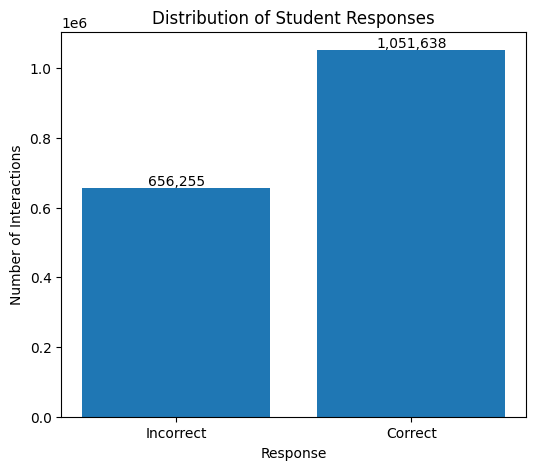

In [ ]:
#plots the distribution of correct and incorrect responses
import matplotlib.pyplot as plt

score_counts = df["discrete_score"].value_counts().sort_index()

plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Incorrect", "Correct"],
    score_counts.values
)

plt.title("Distribution of Student Responses")
plt.xlabel("Response")
plt.ylabel("Number of Interactions")

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:,}",
        ha="center",
        va="bottom"
    )

plt.show()

In [ ]:
df["hint_count"].describe()
df["hint_count"].value_counts().head(20)

hint_count
0    1619546
1      36017
2      28149
3      24129
4         52
Name: count, dtype: int64

In [ ]:
(df["hint_count"] == 0).mean() * 100

np.float64(94.82713495517577)

In [ ]:
hint_vs_score = (
    df.groupby("hint_count")["discrete_score"]
      .mean()
)

print(hint_vs_score)

hint_count
0    0.649239
1    0.002582
2    0.001599
3    0.001119
4    0.000000
Name: discrete_score, dtype: float64


In [ ]:
student_attempts = df.groupby("user_id").size()

student_attempts.describe()

count    5000.000000
mean      341.578600
std        34.479472
min       171.000000
25%       314.000000
50%       339.000000
75%       369.000000
max       420.000000
dtype: float64

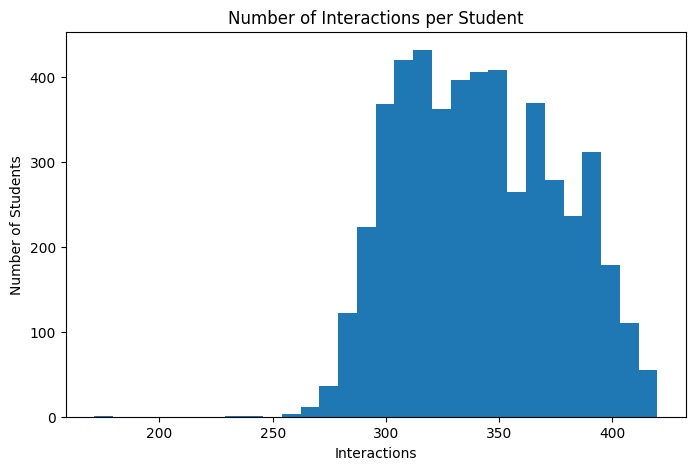

In [ ]:
#plots the number of interactions per student
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(student_attempts, bins=30)

plt.title("Number of Interactions per Student")
plt.xlabel("Interactions")
plt.ylabel("Number of Students")

plt.show()

In [ ]:
#calculates the average accuracy for each problem
problem_accuracy = (
    df.groupby("problem_id")["discrete_score"]
      .mean()
)

problem_accuracy.describe()

count    3359.000000
mean        0.601104
std         0.205879
min         0.000000
25%         0.470479
50%         0.617424
75%         0.750000
max         1.000000
Name: discrete_score, dtype: float64

In [ ]:
#calculates the average accuracy for each student
student_accuracy = (
    df.groupby("user_id")["discrete_score"]
      .mean()
)

student_accuracy.describe()

count    5000.000000
mean        0.615275
std         0.172303
min         0.059006
25%         0.512894
50%         0.638518
75%         0.741842
max         0.985075
Name: discrete_score, dtype: float64

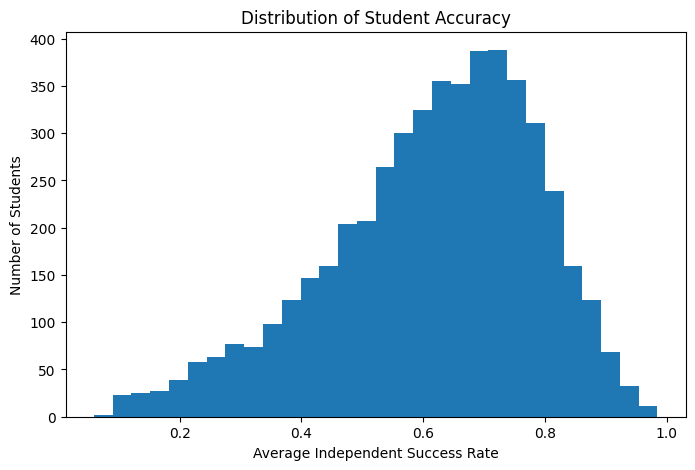

In [ ]:
#plots the distribution of student accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(student_accuracy, bins=30)

plt.title("Distribution of Student Accuracy")

plt.xlabel("Average Independent Success Rate")

plt.ylabel("Number of Students")

plt.show()

In [ ]:
#calculates average accuracy and hint use for each student
student_stats = (
    df.groupby("user_id")
      .agg({
          "discrete_score": "mean",
          "hint_count": "mean"
      })
)

student_stats.head()

,discrete_score,hint_count
user_id,,
00173df52c65a9c13b45978c5a56ea2db67b17deded674486f7af64f7c5fd9ac,0.610526,0.176316
001849d40d6bf1e2ed5826e4420e291e54655a2b6b77a9ab701faaeb4e899abe,0.694286,0.000000
002962cbf0e46ef52ff9e5f6c5a05b150257d094c37debfa4166da9253f19f92,0.433249,0.332494
004b03b56ddd84ef6fd1e7067bb92693cbcc41a719b8cc5afb0ce9823b036c7c,0.757106,0.002584
004d6e78fcc3d1c5943f98665611257b29ce1cc9f1e6bce9fc4235e2593f6951,0.711111,0.101587


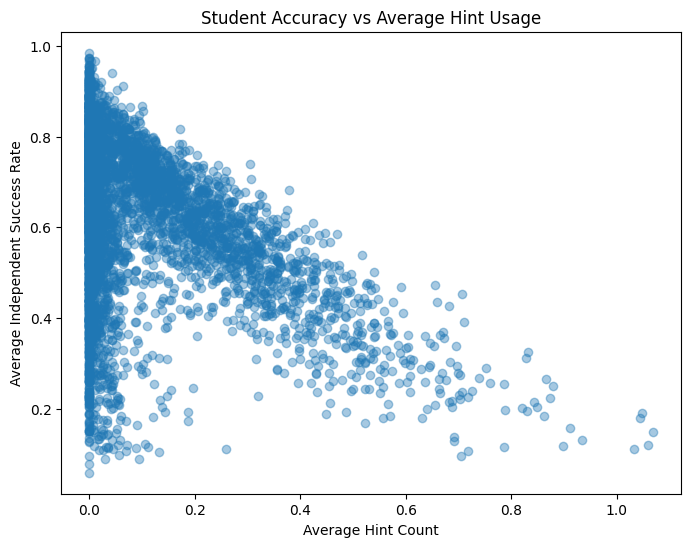

In [ ]:
#plots student accuracy against average hint use
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    student_stats["hint_count"],
    student_stats["discrete_score"],
    alpha=0.4
)

plt.xlabel("Average Hint Count")
plt.ylabel("Average Independent Success Rate")
plt.title("Student Accuracy vs Average Hint Usage")

plt.show()

In [ ]:
#groups students into three clusters
from sklearn.cluster import KMeans

X = student_stats[["discrete_score", "hint_count"]]

kmeans = KMeans(n_clusters=3, random_state=42)
student_stats["cluster"] = kmeans.fit_predict(X)

student_stats.head()

,discrete_score,hint_count,cluster
user_id,,,
00173df52c65a9c13b45978c5a56ea2db67b17deded674486f7af64f7c5fd9ac,0.610526,0.176316,1
001849d40d6bf1e2ed5826e4420e291e54655a2b6b77a9ab701faaeb4e899abe,0.694286,0.000000,1
002962cbf0e46ef52ff9e5f6c5a05b150257d094c37debfa4166da9253f19f92,0.433249,0.332494,2
004b03b56ddd84ef6fd1e7067bb92693cbcc41a719b8cc5afb0ce9823b036c7c,0.757106,0.002584,1
004d6e78fcc3d1c5943f98665611257b29ce1cc9f1e6bce9fc4235e2593f6951,0.711111,0.101587,1


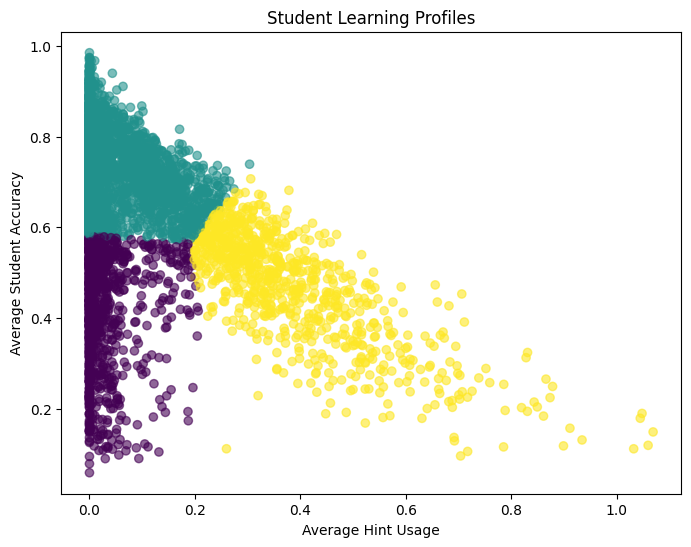

In [ ]:
#plots the student clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    student_stats["hint_count"],
    student_stats["discrete_score"],
    c=student_stats["cluster"],
    alpha=0.6
)

plt.xlabel("Average Hint Usage")
plt.ylabel("Average Student Accuracy")
plt.title("Student Learning Profiles")

plt.show()

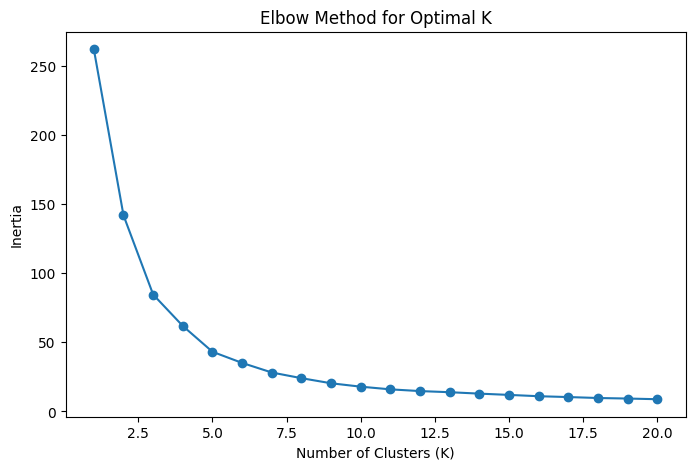

In [ ]:
#calculates inertia for different numbers of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = student_stats[["discrete_score", "hint_count"]]

inertia = []

for k in range(1, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

#plots the elbow method
plt.figure(figsize=(8,5))
plt.plot(range(1,21), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

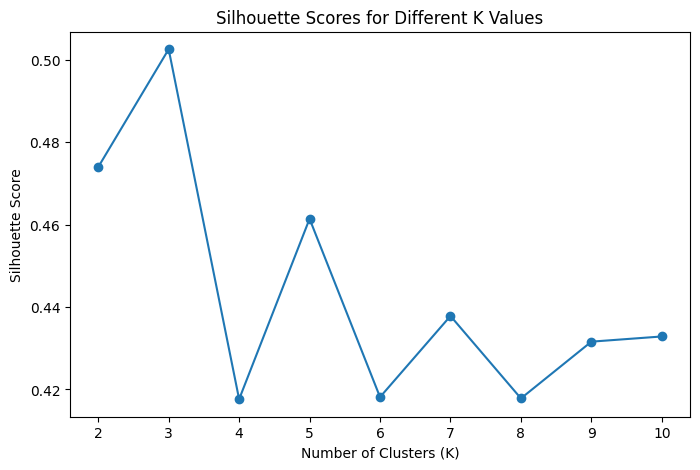

In [ ]:
#calculates silhouette scores for different numbers of clusters
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    scores.append(silhouette_score(X, labels))

#plots the silhouette scores
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different K Values")
plt.show()

In [ ]:
#converts end time to datetime
df["end_time"] = pd.to_datetime(
    df["end_time"],
    format="mixed",
    utc=True
)

#sorts interactions by student and time
df = df.sort_values(["user_id", "end_time"])

df[["user_id", "end_time"]].head(20)

,user_id,end_time
807946,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-09 18:21:41.065000+00:00
1197489,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-11 18:18:54.258000+00:00
424750,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-12 18:02:57.301000+00:00
51296,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-18 18:13:28.362000+00:00
53152,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-18 18:16:29.429000+00:00
54673,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-18 18:17:41.633000+00:00
91275,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-20 19:02:21.265000+00:00
92347,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-20 19:03:24.559000+00:00
93415,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-20 19:06:06.858000+00:00
94471,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,2021-08-20 19:15:35.867000+00:00


In [ ]:
#gets interactions for one student
student = df["user_id"].iloc[0]

student_data = df[df["user_id"] == student]

student_data[[
    "problem_id",
    "discrete_score",
    "hint_count",
    "end_time"
]].head(30)

,problem_id,discrete_score,hint_count,end_time
807946,69785,0,0,2021-08-09 18:21:41.065000+00:00
1197489,569234,0,0,2021-08-11 18:18:54.258000+00:00
424750,290885,0,0,2021-08-12 18:02:57.301000+00:00
51296,230204,1,0,2021-08-18 18:13:28.362000+00:00
53152,230683,0,0,2021-08-18 18:16:29.429000+00:00
54673,231026,0,0,2021-08-18 18:17:41.633000+00:00
91275,26892,0,0,2021-08-20 19:02:21.265000+00:00
92347,27332,0,0,2021-08-20 19:03:24.559000+00:00
93415,27571,0,0,2021-08-20 19:06:06.858000+00:00
94471,27844,0,3,2021-08-20 19:15:35.867000+00:00


In [ ]:
#gets the features used for clustering
from scipy.spatial.distance import cdist
import numpy as np

X = student_stats[["discrete_score", "hint_count"]]

centroid_students = []

for cluster in sorted(student_stats["cluster"].unique()):

    #gets students in the cluster
    cluster_data = student_stats[student_stats["cluster"] == cluster]

    #calculates the cluster centre
    centre = cluster_data[["discrete_score", "hint_count"]].mean().values.reshape(1, -1)

    #calculates each students distance from the centre
    distances = cdist(
        cluster_data[["discrete_score", "hint_count"]],
        centre,
        metric="euclidean"
    )

    #finds the closest student
    closest_student = cluster_data.iloc[np.argmin(distances)]

    centroid_students.append(closest_student)

centroid_students = pd.DataFrame(centroid_students)

centroid_students

,discrete_score,hint_count,cluster
33d124b682055dccefceecc70626c7f7b80725e0009bf77c864993e5681fc363,0.428571,0.027950,0.0
79ced2cb976320cd7a1b935fb79e17e9c144179919ee518d05f9792cd61fae57,0.731343,0.044776,1.0
38ac8a42a24f2b89b2edb9d2d2681ccde7f5a148d8bac72853739c8f12a747fa,0.463291,0.387342,2.0


In [ ]:
#selects one random student from each cluster
random_students = (
    student_stats
    .groupby("cluster")
    .sample(n=1, random_state=42)
)

random_students

,discrete_score,hint_count,cluster
user_id,,,
30a2c29dd8f6438110c92c38bd4e481e4d62080e1158c79d8d177ec2ae336663,0.400000,0.013699,0
1dd0094c5d2e6c9f598ea8345cf6bd8fac1a6457a8f1c04c09151a4233901836,0.709091,0.006061,1
80284b728ae6d388a33fb61aee5999be2a26b3e8c2a62b938ff7a00d9b384bc1,0.426934,0.681948,2


In [ ]:
print("Representative Students")
display(centroid_students)

print("\nRandom Students")
display(random_students)

Representative Students


,discrete_score,hint_count,cluster
33d124b682055dccefceecc70626c7f7b80725e0009bf77c864993e5681fc363,0.428571,0.027950,0.0
79ced2cb976320cd7a1b935fb79e17e9c144179919ee518d05f9792cd61fae57,0.731343,0.044776,1.0
38ac8a42a24f2b89b2edb9d2d2681ccde7f5a148d8bac72853739c8f12a747fa,0.463291,0.387342,2.0



Random Students


,discrete_score,hint_count,cluster
user_id,,,
30a2c29dd8f6438110c92c38bd4e481e4d62080e1158c79d8d177ec2ae336663,0.400000,0.013699,0
1dd0094c5d2e6c9f598ea8345cf6bd8fac1a6457a8f1c04c09151a4233901836,0.709091,0.006061,1
80284b728ae6d388a33fb61aee5999be2a26b3e8c2a62b938ff7a00d9b384bc1,0.426934,0.681948,2


In [ ]:
#compares the centroid and random students from each cluster
comparison = pd.DataFrame({
    "Cluster": centroid_students["cluster"].values,
    "Centroid Student": centroid_students.index,
    "Centroid Accuracy": centroid_students["discrete_score"].round(3).values,
    "Centroid Hints": centroid_students["hint_count"].round(3).values,
    "Random Student": random_students.index,
    "Random Accuracy": random_students["discrete_score"].round(3).values,
    "Random Hints": random_students["hint_count"].round(3).values,
})

comparison

,Cluster,Centroid Student,Centroid Accuracy,Centroid Hints,Random Student,Random Accuracy,Random Hints
0,0.0,33d124b682055dccefceecc70626c7f7b80725e0009bf7...,0.429,0.028,30a2c29dd8f6438110c92c38bd4e481e4d62080e1158c7...,0.400,0.014
1,1.0,79ced2cb976320cd7a1b935fb79e17e9c144179919ee51...,0.731,0.045,1dd0094c5d2e6c9f598ea8345cf6bd8fac1a6457a8f1c0...,0.709,0.006
2,2.0,38ac8a42a24f2b89b2edb9d2d2681ccde7f5a148d8bac7...,0.463,0.387,80284b728ae6d388a33fb61aee5999be2a26b3e8c2a62b...,0.427,0.682


In [ ]:
#gets the interactions for the first centroid student
student = centroid_students.index[0]

student_data = (
    df[df["user_id"] == student]
    .sort_values("end_time")
)

student_data.head()

,id,problem_id,hint_count,answer_text,saw_answer,discrete_score,end_time,user_id
374939,44440004,46209,0,Medium,False,0,2020-09-17 15:27:36.370000+00:00,33d124b682055dccefceecc70626c7f7b80725e0009bf7...
342283,44443968,47557,0,5,False,0,2020-09-17 15:31:26.640000+00:00,33d124b682055dccefceecc70626c7f7b80725e0009bf7...
1512437,45327372,103748,0,D. (5 × 6) + (3 × 2),False,0,2020-09-18 14:55:38.367000+00:00,33d124b682055dccefceecc70626c7f7b80725e0009bf7...
1533747,45327966,103860,0,B. 4.5 × 3.25,False,1,2020-09-18 14:56:47.072000+00:00,33d124b682055dccefceecc70626c7f7b80725e0009bf7...
1533942,45330907,104131,0,"A , E",False,1,2020-09-18 15:01:08.021000+00:00,33d124b682055dccefceecc70626c7f7b80725e0009bf7...


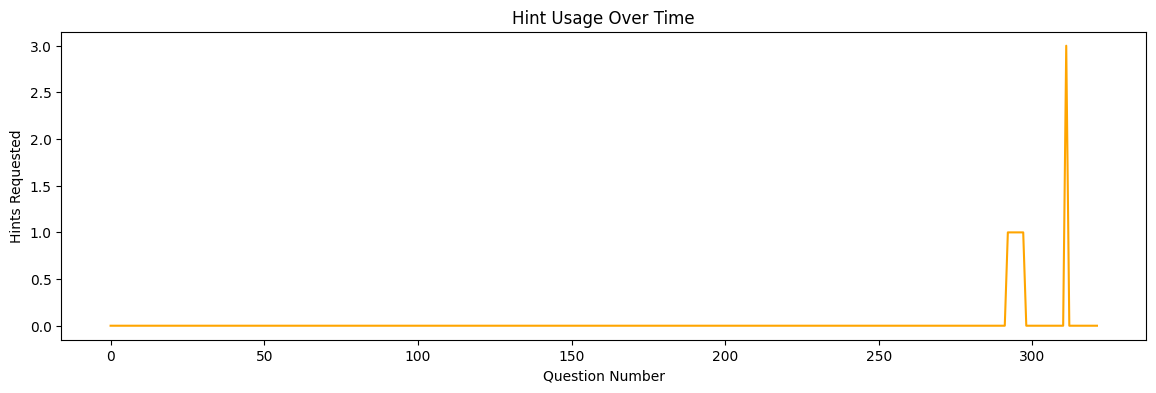

In [ ]:
#plots hint use over time for one student
plt.figure(figsize=(14,4))

plt.plot(
    student_data["hint_count"].values,
    color="orange"
)

plt.title("Hint Usage Over Time")
plt.xlabel("Question Number")
plt.ylabel("Hints Requested")

plt.show()

In [ ]:
df.columns

Index(['id', 'problem_id', 'hint_count', 'answer_text', 'saw_answer',
       'discrete_score', 'end_time', 'user_id'],
      dtype='str')

In [ ]:
#loads the skills and problems data
skills_path = hf_hub_download(
    repo_id="ASSISTments/FoundationalASSIST",
    repo_type="dataset",
    filename="Data/Skills.csv",
    token=True
)

problems_path = hf_hub_download(
    repo_id="ASSISTments/FoundationalASSIST",
    repo_type="dataset",
    filename="Data/Problems.csv",
    token=True
)

skills = pd.read_csv(skills_path)
problems = pd.read_csv(problems_path)

print(skills.columns)
print(problems.columns)

Index(['problem_id', 'skill_id', 'node_code', 'node_name'], dtype='str')
Index(['Problem Set Id', 'Problem Part', 'Problem Type', 'Answer Types',
       'Problem Body', 'Fill-in Options', 'Fill-in Answers',
       'Multiple Choice Options', 'Multiple Choice Answers', 'problem_id'],
      dtype='str')


In [ ]:
#merges the skills data with the interactions
df = df.merge(
    skills,
    on="problem_id",
    how="left"
)

print(df.columns)

Index(['id', 'problem_id', 'hint_count', 'answer_text', 'saw_answer',
       'discrete_score', 'end_time', 'user_id', 'skill_id', 'node_code',
       'node_name'],
      dtype='str')


In [ ]:
df["node_name"].nunique()

163

In [ ]:
df["node_name"].value_counts().head(20)

node_name
Use Proportional Relationships to Solve Ratio & Percent Problems       132158
Solve Unit Rate Problems                                                97354
Solve Problems Involving Area & Circumference of Circles                90613
Solve Scale Drawing Problems                                            90289
Solve 2-Step Equations                                                  82064
Solve Problems Involving Percents                                       81087
Identify Proportional Relationships                                     69595
Interpret & Compute using Division of Fractions                         68263
Find the Area of Triangles, Quadrilaterals & Polygons                   65389
Apply Properties of Operations to Multiply/Divide Rational Numbers      57469
Represent Proportional Relationships with Equations                     56696
Add, Subtract, Multiply & Divide Multi-Digit Decimals                   51309
Find Area, Volume & Surface Area of 2D/3D Objects     

In [ ]:
#calculates statistics for each skill
skill_stats = (
    df.groupby(["skill_id", "node_name"])
      .agg(
          attempts=("discrete_score", "count"),
          accuracy=("discrete_score", "mean"),
          avg_hints=("hint_count", "mean"),
          saw_answer_rate=("saw_answer", "mean")
      )
      .reset_index()
)

skill_stats.head()

,skill_id,node_name,attempts,accuracy,avg_hints,saw_answer_rate
0,1,Interpret Products of Whole Numbers,58,0.327586,0.0,0.224138
1,4,Determine the Unknown Whole Number in a Multip...,58,0.327586,0.0,0.224138
2,5,Apply Properties of Operations To Multiply & D...,57,0.315789,0.0,0.245614
3,15,Represent Unit Fractions on a Number Line,16,0.250000,0.0,0.625000
4,16,Represent Fractions on a Number Line,26,0.269231,0.0,0.384615


In [ ]:
skill_stats.sort_values("accuracy").head(20)

,skill_id,node_name,attempts,accuracy,avg_hints,saw_answer_rate
165,251,Know & Apply Properties of Exponents,1,0.000000,0.000000,1.000000
10,34,Find Area of Rectangles by Decomposing,198,0.141414,0.000000,0.080808
27,81,Write & Interpret Simple Expressions,198,0.141414,0.000000,0.080808
48,115,Understand that Unit Cubes Can be Used to Cons...,648,0.245370,0.268519,0.618827
24,77,Draw & Identify Types of Lines and Angles,195,0.246154,0.000000,0.051282
11,35,Solve Word Problems Involving Perimeter of Pol...,88,0.250000,0.227273,0.284091
3,15,Represent Unit Fractions on a Number Line,16,0.250000,0.000000,0.625000
5,19,Recognize & Generate Simple Equivalent Fractions,16,0.250000,0.000000,0.625000
36,96,Solve Word Problems Involving Addition/Subtrac...,341,0.258065,0.041056,0.401760
4,16,Represent Fractions on a Number Line,26,0.269231,0.000000,0.384615


In [ ]:
skill_stats_filtered = skill_stats[skill_stats["attempts"] >= 500]

skill_stats_filtered.sort_values("accuracy").head(20)

,skill_id,node_name,attempts,accuracy,avg_hints,saw_answer_rate
48,115,Understand that Unit Cubes Can be Used to Cons...,648,0.245370,0.268519,0.618827
193,284,Describe the Effect of Transformations on 2D F...,706,0.371105,0.171388,0.417847
20,66,Convert Measurements Within a System & Display...,3948,0.373860,0.201114,0.399189
183,271,Use Functions to Model Relationships Between Q...,742,0.374663,0.285714,0.545822
51,119,Find the Volume of a Rectangular Prism With a ...,800,0.375000,0.145000,0.433750
181,269,Use Functions to Model Relationships Between Q...,1538,0.378414,0.358908,0.394668
103,181,"Display Numerical Data Using Dot Plots, Histog...",1448,0.381906,0.257597,0.345304
187,277,Use Functions to Model Relationships Between Q...,1391,0.404026,0.148095,0.491014
144,227,Use Facts About Angles to Write & Solve Equations,817,0.422277,0.215422,0.461444
98,175,Use Coordinates on a Graph to Create Polygons ...,2307,0.437365,0.156047,0.454270


In [ ]:
skill_stats_filtered.sort_values("accuracy", ascending=False).head(20)

,skill_id,node_name,attempts,accuracy,avg_hints,saw_answer_rate
32,90,Divide Whole Numbers (Up to 4-Digit Dividends ...,910,0.879121,0.024176,0.041758
73,147,Identify Opposites of Integers,4389,0.862839,0.002506,0.028252
106,187,Describe the Attributes of a Data Set,2007,0.857997,0.002491,0.053812
129,211,Convert a Rational Number to a Decimal,3911,0.809767,0.018665,0.039632
84,161,Evaluate Expression in Real-World Context,12314,0.804856,0.058632,0.096394
78,154,Understand & Interpret Absolute Value in Real-...,959,0.791449,0.054223,0.111575
72,145,Use Positive & Negative Numbers to Represent Q...,15377,0.788580,0.025883,0.092281
101,178,Understand Properties of Distribution with (or...,1447,0.785764,0.007602,0.044921
155,240,Develop a Probability Model of a Single Event,2081,0.782316,0.035560,0.137914
125,207,Understand Applied Context for Dividing Ration...,1178,0.779287,0.005093,0.059423


In [ ]:
skill_stats_filtered.sort_values("avg_hints", ascending=False).head(20)

,skill_id,node_name,attempts,accuracy,avg_hints,saw_answer_rate
181,269,Use Functions to Model Relationships Between Q...,1538,0.378414,0.358908,0.394668
183,271,Use Functions to Model Relationships Between Q...,742,0.374663,0.285714,0.545822
48,115,Understand that Unit Cubes Can be Used to Cons...,648,0.245370,0.268519,0.618827
103,181,"Display Numerical Data Using Dot Plots, Histog...",1448,0.381906,0.257597,0.345304
144,227,Use Facts About Angles to Write & Solve Equations,817,0.422277,0.215422,0.461444
97,174,Find the Volume of Rectangular Prisms with Fra...,6985,0.482176,0.212169,0.343880
20,66,Convert Measurements Within a System & Display...,3948,0.373860,0.201114,0.399189
146,229,"Find Area, Volume & Surface Area of 2D/3D Objects",17087,0.486627,0.196465,0.385673
156,242,Understand Probability of a Compound Event,1882,0.456429,0.196068,0.399044
147,230,"Find Area, Volume & Surface Area of 2D/3D Objects",22720,0.523460,0.183891,0.340361


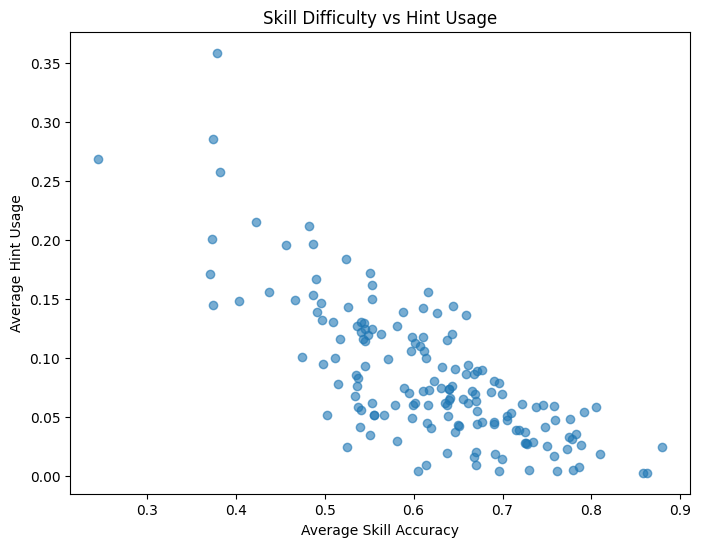

In [ ]:
#plots skill accuracy against average hint use
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    skill_stats_filtered["accuracy"],
    skill_stats_filtered["avg_hints"],
    alpha=0.6
)

plt.xlabel("Average Skill Accuracy")
plt.ylabel("Average Hint Usage")
plt.title("Skill Difficulty vs Hint Usage")

plt.show()

In [ ]:
#selects one random student and sorts their interactions by time
student = df["user_id"].sample(1, random_state=42).iloc[0]

student_data = (
    df[df["user_id"] == student]
    .sort_values("end_time")
)

student_data[["end_time", "node_name"]].head(30)

,end_time,node_name
1141745,2022-08-29 15:05:18.058000+00:00,Solve Scale Drawing Problems
1141746,2022-08-29 15:17:15.361000+00:00,Create Tables to Compare Equivalent Ratios
1141747,2022-08-31 15:10:44.345000+00:00,Create Tables to Compare Equivalent Ratios
1141748,2022-09-06 15:09:41.638000+00:00,Represent Proportional Relationships with Equa...
1141749,2022-09-06 15:12:56.300000+00:00,Represent Proportional Relationships with Equa...
1141750,2022-09-06 15:27:34.649000+00:00,Identify the Constant of Proportionality
1141751,2022-09-06 15:27:34.649000+00:00,Represent Proportional Relationships with Equa...
1141752,2022-09-06 15:28:12.237000+00:00,Identify the Constant of Proportionality
1141753,2022-09-06 15:28:12.237000+00:00,Represent Proportional Relationships with Equa...
1141754,2022-09-06 15:34:01.700000+00:00,Solve Scale Drawing Problems


In [ ]:
#counts skill changes for each student

student_skill_changes = (
    df.sort_values(["user_id", "end_time"])
      .groupby("user_id")["node_name"]
      .apply(lambda x: (x != x.shift()).sum())
)

#counts interactions for each student
student_attempts = df.groupby("user_id").size()

#creates a summary table
transition_summary = (
    pd.DataFrame({
        "attempts": student_attempts,
        "skill_changes": student_skill_changes
    })
)

#calculates average attempts per skill
transition_summary["attempts_per_skill"] = (
    transition_summary["attempts"] /
    transition_summary["skill_changes"]
)

transition_summary["attempts_per_skill"].describe()

count    5000.000000
mean        2.423134
std         0.320754
min         1.054745
25%         2.223513
50%         2.372158
75%         2.581052
max         4.457831
Name: attempts_per_skill, dtype: float64

In [ ]:
#checks interaction and skill counts
print("Total rows:", len(df))
print("Unique interaction IDs:", df["id"].nunique())
print("Duplicated interaction rows:", len(df) - df["id"].nunique())

print("\nSkills per interaction:")
print(df.groupby("id")["skill_id"].nunique().describe())

Total rows: 1832220
Unique interaction IDs: 1707893
Duplicated interaction rows: 124327

Skills per interaction:
count    1.707893e+06
mean     1.072796e+00
std      3.137642e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: skill_id, dtype: float64


In [ ]:
#creates one row for each interaction
interaction_columns = [
    "id",
    "problem_id",
    "hint_count",
    "answer_text",
    "saw_answer",
    "discrete_score",
    "end_time",
    "user_id"
]

interactions_df = (
    df[interaction_columns]
    .drop_duplicates(subset="id")
    .sort_values(["user_id", "end_time"])
    .reset_index(drop=True)
)

In [ ]:
#creates one row for each interaction and skill
skill_columns = interaction_columns + [
    "skill_id",
    "node_code",
    "node_name"
]

skill_interactions_df = (
    df[skill_columns]
    .drop_duplicates(subset=["id", "skill_id"])
    .sort_values(["user_id", "end_time"])
    .reset_index(drop=True)
)

In [ ]:
print("Interaction-level rows:", len(interactions_df))
print("Unique interaction IDs:", interactions_df["id"].nunique())

print("\nSkill-level rows:", len(skill_interactions_df))
print("Unique interaction IDs:", skill_interactions_df["id"].nunique())

Interaction-level rows: 1707893
Unique interaction IDs: 1707893

Skill-level rows: 1832220
Unique interaction IDs: 1707893


In [ ]:
#calculates the independent success rate
accuracy_rate = interactions_df["discrete_score"].mean() * 100

#calculates how often hints were used
hint_usage_rate = (
    interactions_df["hint_count"].gt(0).mean() * 100
)

print(f"Independent success rate: {accuracy_rate:.2f}%")
print(f"Interactions using hints: {hint_usage_rate:.2f}%")

Independent success rate: 61.58%
Interactions using hints: 5.17%


In [ ]:
#compares accuracy with hint use
pd.crosstab(
    interactions_df["discrete_score"],
    interactions_df["hint_count"] > 0,
    normalize="all"
).mul(100).round(2)

hint_count,False,True
discrete_score,,
0,33.26,5.16
1,61.57,0.01


In [ ]:
#creates a skill map for each problem
problem_skill_map = (
    skill_interactions_df[
        ["problem_id", "skill_id", "node_name"]
    ]
    .drop_duplicates()
    .groupby("problem_id", sort=False)
    .agg(
        skill_ids=("skill_id", tuple),
        skill_names=("node_name", tuple)
    )
    .reset_index()
)

#adds the skill information to each interaction
interactions_with_skills = interactions_df.merge(
    problem_skill_map,
    on="problem_id",
    how="left",
    validate="many_to_one"
)

print("Rows:", len(interactions_with_skills))
print("Unique interactions:", interactions_with_skills["id"].nunique())

interactions_with_skills[
    ["id", "user_id", "problem_id", "discrete_score", "skill_names"]
].head(10)

Rows: 1707893
Unique interactions: 1707893


,id,user_id,problem_id,discrete_score,skill_names
0,128246151,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,69785,0,"(Solve Scale Drawing Problems,)"
1,128299957,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,569234,0,"(Solve Scale Drawing Problems,)"
2,128328208,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,290885,0,"(Solve Scale Drawing Problems,)"
3,128560666,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,230204,1,"(Solve Scale Drawing Problems,)"
4,128561052,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,230683,0,"(Solve Scale Drawing Problems,)"
5,128561547,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,231026,0,"(Solve Scale Drawing Problems,)"
6,128711599,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,26892,0,"(Solve Scale Drawing Problems,)"
7,128712068,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,27332,0,"(Solve Scale Drawing Problems,)"
8,128712183,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,27571,0,"(Solve Scale Drawing Problems,)"
9,128712495,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,27844,0,"(Solve Scale Drawing Problems,)"


In [ ]:
#counts the number of skills for each interaction
interactions_with_skills["number_of_skills"] = (
    interactions_with_skills["skill_names"]
    .apply(lambda x: len(x) if isinstance(x, tuple) else 0)
)

#calculates the percentage of interactions by number of skills
skill_count_percentages = (
    interactions_with_skills["number_of_skills"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

skill_count_percentages

number_of_skills
1    94.27
2     4.18
3     1.55
Name: proportion, dtype: float64

In [ ]:
#keeps interactions with one skill
single_skill_df = interactions_with_skills[
    interactions_with_skills["number_of_skills"] == 1
].copy()

#gets the skill name
single_skill_df["skill_name"] = single_skill_df["skill_names"].str[0]

#sorts interactions by student and time
single_skill_df = single_skill_df.sort_values(
    ["user_id", "end_time", "id"]
)

#calculates average interactions before changing skill
student_skill_runs = (
    single_skill_df
    .groupby("user_id")["skill_name"]
    .apply(lambda x: len(x) / (x != x.shift()).sum())
)

student_skill_runs.describe()

count    5000.000000
mean        2.741057
std         0.361781
min         1.054745
25%         2.516003
50%         2.692308
75%         2.884956
max         4.931034
Name: skill_name, dtype: float64

In [ ]:
#sorts interactions by student and time
single_skill_df = single_skill_df.sort_values(
    ["user_id", "end_time", "id"]
).copy()

#marks the start of each new skill run
single_skill_df["new_skill_run"] = (
    single_skill_df["user_id"].ne(single_skill_df["user_id"].shift())
    |
    single_skill_df["skill_name"].ne(single_skill_df["skill_name"].shift())
)

#creates an id for each skill run
single_skill_df["skill_run_id"] = (
    single_skill_df["new_skill_run"].cumsum()
)

#counts the attempt number within each skill run
single_skill_df["attempt_in_run"] = (
    single_skill_df.groupby("skill_run_id").cumcount() + 1
)

#calculates accuracy for the first 10 attempts
accuracy_by_attempt = (
    single_skill_df[
        single_skill_df["attempt_in_run"] <= 10
    ]
    .groupby("attempt_in_run")["discrete_score"]
    .agg(["mean", "count"])
)

accuracy_by_attempt["accuracy_percent"] = (
    accuracy_by_attempt["mean"] * 100
).round(2)

accuracy_by_attempt[["accuracy_percent", "count"]]

,accuracy_percent,count
attempt_in_run,,
1,60.19,596354
2,63.33,310189
3,63.88,192819
4,63.27,125230
5,63.99,80943
6,60.97,54726
7,62.77,41061
8,61.19,31293
9,60.41,24803


In [ ]:
#gets the previous score within each skill run
single_skill_df["previous_score"] = (
    single_skill_df
    .groupby("skill_run_id")["discrete_score"]
    .shift(1)
)

#calculates next accuracy based on the previous score
previous_outcome_effect = (
    single_skill_df
    .dropna(subset=["previous_score"])
    .groupby("previous_score")["discrete_score"]
    .agg(["mean", "count"])
)

previous_outcome_effect["next_accuracy_percent"] = (
    previous_outcome_effect["mean"] * 100
).round(2)

previous_outcome_effect[
    ["next_accuracy_percent", "count"]
].rename(index={
    0.0: "Previous answer incorrect",
    1.0: "Previous answer correct"
})

,next_accuracy_percent,count
previous_score,,
Previous answer incorrect,43.49,373609
Previous answer correct,73.35,640034


In [ ]:
#gets the score from two attempts before
single_skill_df["previous_2_score"] = (
    single_skill_df
    .groupby("skill_run_id")["discrete_score"]
    .shift(2)
)

#creates patterns from the previous two scores
two_answer_patterns = (
    single_skill_df
    .dropna(subset=["previous_score", "previous_2_score"])
    .assign(
        previous_pattern=lambda x:
            x["previous_2_score"].astype(int).astype(str)
            + x["previous_score"].astype(int).astype(str)
    )
    .groupby("previous_pattern")["discrete_score"]
    .agg(["mean", "count"])
)

#calculates next accuracy for each pattern
two_answer_patterns["next_accuracy_percent"] = (
    two_answer_patterns["mean"] * 100
).round(2)

two_answer_patterns[["next_accuracy_percent", "count"]]

,next_accuracy_percent,count
previous_pattern,,
00,32.13,143614
01,62.09,115929
10,56.45,115565
11,76.80,328346


In [ ]:
#gets the next score within each skill run
single_skill_df["next_score"] = (
    single_skill_df
    .groupby("skill_run_id")["discrete_score"]
    .shift(-1)
)

#checks whether a hint was used
single_skill_df["used_hint"] = (
    single_skill_df["hint_count"] > 0
)

#compares the next score after an incorrect answer
hint_followup = (
    single_skill_df[
        (single_skill_df["discrete_score"] == 0) &
        (single_skill_df["next_score"].notna())
    ]
    .groupby("used_hint")["next_score"]
    .agg(["mean", "count"])
)

#calculates next accuracy
hint_followup["next_accuracy_percent"] = (
    hint_followup["mean"] * 100
).round(2)

hint_followup[
    ["next_accuracy_percent", "count"]
].rename(index={
    False: "Wrong without hint",
    True: "Wrong with hint"
})

,next_accuracy_percent,count
used_hint,,
Wrong without hint,45.02,323067
Wrong with hint,33.75,50542


In [ ]:
#checks hint use with the previous two scores
hint_history_check = (
    single_skill_df[
        (single_skill_df["discrete_score"] == 0) &
        (single_skill_df["next_score"].notna()) &
        (single_skill_df["previous_score"].notna()) &
        (single_skill_df["previous_2_score"].notna())
    ]
    .assign(
        recent_correct_count=lambda x:
            x["previous_score"] + x["previous_2_score"]
    )
    .groupby(
        ["recent_correct_count", "used_hint"]
    )["next_score"]
    .agg(["mean", "count"])
    .reset_index()
)

#calculates next accuracy
hint_history_check["next_accuracy_percent"] = (
    hint_history_check["mean"] * 100
).round(2)

hint_history_check[
    ["recent_correct_count", "used_hint",
     "next_accuracy_percent", "count"]
]

,recent_correct_count,used_hint,next_accuracy_percent,count
0,0.0,False,25.78,59244
1,0.0,True,21.85,11391
2,1.0,False,47.36,59011
3,1.0,True,38.20,8901
4,2.0,False,61.95,48647
5,2.0,True,49.51,5264


In [ ]:
#calculates how often students saw the answer
single_skill_df["saw_answer"].value_counts(
    normalize=True,
    dropna=False
).mul(100).round(2)

saw_answer
False    78.03
True     21.97
Name: proportion, dtype: float64

In [ ]:
#compares hint use with viewing the answer
support_overlap = pd.crosstab(
    single_skill_df["hint_count"].gt(0),
    single_skill_df["saw_answer"].fillna(False),
    normalize="all"
).mul(100).round(2)

support_overlap.rename(
    index={
        False: "No hint",
        True: "Used hint"
    },
    columns={
        False: "Did not view answer",
        True: "Viewed answer"
    }
)

saw_answer,Did not view answer,Viewed answer
hint_count,,
No hint,76.84,17.94
Used hint,1.19,4.03


In [ ]:
#creates support types
single_skill_df["support_type"] = np.select(
    [
        (~single_skill_df["used_hint"]) & (~single_skill_df["saw_answer"]),
        (single_skill_df["used_hint"]) & (~single_skill_df["saw_answer"]),
        (~single_skill_df["used_hint"]) & (single_skill_df["saw_answer"]),
        (single_skill_df["used_hint"]) & (single_skill_df["saw_answer"])
    ],
    [
        "No hint or answer view",
        "Hint only",
        "Viewed answer only",
        "Hint and viewed answer"
    ],
    default="Unknown"
)

#calculates next accuracy for each support type
support_followup = (
    single_skill_df[
        (single_skill_df["discrete_score"] == 0) &
        (single_skill_df["next_score"].notna())
    ]
    .groupby("support_type")["next_score"]
    .agg(["mean", "count"])
)

support_followup["next_accuracy_percent"] = (
    support_followup["mean"] * 100
).round(2)

support_followup[
    ["next_accuracy_percent", "count"]
].sort_values("next_accuracy_percent", ascending=False)

,next_accuracy_percent,count
support_type,,
No hint or answer view,60.26,146256
Hint only,41.44,11960
Viewed answer only,32.41,176811
Hint and viewed answer,31.37,38582


In [ ]:
#calculates accuracy for each skill
skill_difficulty = (
    single_skill_df
    .groupby("skill_name")["discrete_score"]
    .agg(
        attempts="count",
        accuracy="mean"
    )
)

skill_difficulty["accuracy_percent"] = (
    skill_difficulty["accuracy"] * 100
).round(2)

#keeps skills with at least 1000 attempts
reliable_skills = skill_difficulty[
    skill_difficulty["attempts"] >= 1000
]

print("Overall variation:")
display(reliable_skills["accuracy_percent"].describe())

print("\n10 hardest skills:")
display(
    reliable_skills
    .sort_values("accuracy_percent")
    [["accuracy_percent", "attempts"]]
    .head(10)
)

print("\n10 easiest skills:")
display(
    reliable_skills
    .sort_values("accuracy_percent", ascending=False)
    [["accuracy_percent", "attempts"]]
    .head(10)
)

Overall variation:


count    96.000000
mean     62.826979
std       9.634116
min      37.700000
25%      56.362500
50%      62.915000
75%      70.082500
max      85.800000
Name: accuracy_percent, dtype: float64


10 hardest skills:


,accuracy_percent,attempts
skill_name,,
Convert Measurements Within a System & Display in Two-Column Tables,37.70,3825
Use Coordinates on a Graph to Create Polygons & Find Side Lengths,43.86,1931
Write & Analyze Relationships Between Dependent & Independent Variables,44.96,5151
Understand Probability of a Compound Event,45.64,1882
Apply Properties of Operations to Create Equivalent Expressions,46.63,17136
Find the Volume of Rectangular Prisms with Fractional Sides,47.94,6733
Describe 2D Cross Sections of 3D figures,48.64,1733
Design & Use a Simulation for Compound Events,49.04,2345
Identify Solutions to Systems of Equations Using Graphs,49.55,5021



10 easiest skills:


,accuracy_percent,attempts
skill_name,,
Describe the Attributes of a Data Set,85.80,2007
Convert a Rational Number to a Decimal,80.97,3904
Evaluate Expression in Real-World Context,80.49,12314
Divide Multi-Digit Whole Numbers,79.58,8704
Develop a Probability Model of a Single Event,78.22,2080
Measure Volumes with Unit Cubes,77.49,1115
Interpret & Compare Rational Numbers in Real-World Contexts,76.95,4898
Construct & Interpret Scatter Plots,75.84,3460
Interpret Sums of Rational Numbers,75.11,7714


In [ ]:
#creates a copy for time analysis
temporal_df = single_skill_df.copy()

#converts end time to datetime
temporal_df["end_time"] = pd.to_datetime(
    temporal_df["end_time"],
    utc=True,
    errors="coerce"
)

#sorts interactions by student, skill and time
temporal_df = temporal_df.sort_values(
    ["user_id", "skill_name", "end_time", "id"]
)

#calculates hours since the same skill was last attempted
temporal_df["hours_since_same_skill"] = (
    temporal_df
    .groupby(["user_id", "skill_name"])["end_time"]
    .diff()
    .dt.total_seconds()
    .div(3600)
)

#groups time gaps into ranges
temporal_df["time_gap"] = pd.cut(
    temporal_df["hours_since_same_skill"],
    bins=[-0.01, 1, 24, 168, float("inf")],
    labels=[
        "Within 1 hour",
        "1 to 24 hours",
        "1 to 7 days",
        "Over 7 days"
    ]
)

#calculates accuracy for each time gap
time_gap_results = (
    temporal_df
    .dropna(subset=["time_gap"])
    .groupby("time_gap", observed=True)["discrete_score"]
    .agg(["mean", "count"])
)

time_gap_results["accuracy_percent"] = (
    time_gap_results["mean"] * 100
).round(2)

time_gap_results[["accuracy_percent", "count"]]

,accuracy_percent,count
time_gap,,
Within 1 hour,63.29,923423
1 to 24 hours,57.69,109254
1 to 7 days,58.94,223347
Over 7 days,58.18,177280


In [ ]:
#gets the previous score for the same skill
temporal_df["previous_same_skill_score"] = (
    temporal_df
    .groupby(["user_id", "skill_name"])["discrete_score"]
    .shift(1)
)

#compares time gaps with the previous score
time_previous_check = (
    temporal_df
    .dropna(subset=["time_gap", "previous_same_skill_score"])
    .groupby(
        ["previous_same_skill_score", "time_gap"],
        observed=True
    )["discrete_score"]
    .agg(["mean", "count"])
    .reset_index()
)

#calculates accuracy for each group
time_previous_check["accuracy_percent"] = (
    time_previous_check["mean"] * 100
).round(2)

time_previous_check[
    ["previous_same_skill_score", "time_gap",
     "accuracy_percent", "count"]
]

,previous_same_skill_score,time_gap,accuracy_percent,count
0,0.0,Within 1 hour,43.13,333632
1,0.0,1 to 24 hours,48.29,47417
2,0.0,1 to 7 days,48.35,91464
3,0.0,Over 7 days,48.71,76521
4,1.0,Within 1 hour,74.70,589791
5,1.0,1 to 24 hours,64.89,61837
6,1.0,1 to 7 days,66.28,131883
7,1.0,Over 7 days,65.37,100759


In [ ]:
#sorts interactions by student, skill and time
opportunity_df = single_skill_df.sort_values(
    ["user_id", "skill_name", "end_time", "id"]
).copy()

#counts how many times each student attempted the skill
opportunity_df["skill_opportunity"] = (
    opportunity_df
    .groupby(["user_id", "skill_name"])
    .cumcount() + 1
)

#calculates accuracy for the first 10 skill attempts
opportunity_results = (
    opportunity_df[
        opportunity_df["skill_opportunity"] <= 10
    ]
    .groupby("skill_opportunity")["discrete_score"]
    .agg(["mean", "count"])
)

opportunity_results["accuracy_percent"] = (
    opportunity_results["mean"] * 100
).round(2)

opportunity_results[["accuracy_percent", "count"]]

,accuracy_percent,count
skill_opportunity,,
1,61.49,176693
2,62.42,138164
3,63.09,118045
4,64.01,99356
5,62.99,87184
6,62.96,76384
7,63.56,67097
8,62.56,59896
9,62.16,53988


In [ ]:
#counts attempts for each student and skill
pair_attempt_counts = (
    opportunity_df
    .groupby(["user_id", "skill_name"])
    .size()
)

#keeps student and skill pairs with at least 6 attempts
eligible_pairs = pair_attempt_counts[
    pair_attempt_counts >= 6
].index

#creates a dataframe with eligible pairs
eligible_df = (
    opportunity_df
    .set_index(["user_id", "skill_name"])
    .loc[eligible_pairs]
    .reset_index()
)

#keeps the first two and attempts five and six
early_late_df = eligible_df[
    eligible_df["skill_opportunity"].isin([1, 2, 5, 6])
].copy()

#creates the early and later groups
early_late_df["period"] = np.where(
    early_late_df["skill_opportunity"] <= 2,
    "First two attempts",
    "Attempts five and six"
)

#calculates accuracy for each period
early_late_results = (
    early_late_df
    .groupby("period")["discrete_score"]
    .agg(["mean", "count"])
)

early_late_results["accuracy_percent"] = (
    early_late_results["mean"] * 100
).round(2)

early_late_results[["accuracy_percent", "count"]]

,accuracy_percent,count
period,,
Attempts five and six,63.09,152768
First two attempts,62.24,152768


In [ ]:
#gets the problem information
problem_metadata = (
    problems[
        ["problem_id", "Problem Type", "Answer Types"]
    ]
    .drop_duplicates(subset="problem_id")
)

#adds problem information to the interactions
problem_eda_df = single_skill_df.merge(
    problem_metadata,
    on="problem_id",
    how="left",
    validate="many_to_one"
)

#calculates accuracy for each problem type
problem_type_results = (
    problem_eda_df
    .groupby("Problem Type")["discrete_score"]
    .agg(["mean", "count"])
)

problem_type_results["accuracy_percent"] = (
    problem_type_results["mean"] * 100
).round(2)

problem_type_results[
    problem_type_results["count"] >= 1000
][["accuracy_percent", "count"]].sort_values(
    "accuracy_percent"
)

,accuracy_percent,count
Problem Type,,
Multiple Choice (select all),47.55,193759
Order / Sort,47.77,14568
Fill-in-the-blank(s),61.71,1093269
Multiple Choice (select 1),70.42,308401


In [ ]:
#calculates accuracy for each answer type
answer_type_results = (
    problem_eda_df
    .groupby("Answer Types")["discrete_score"]
    .agg(["mean", "count"])
)

answer_type_results["accuracy_percent"] = (
    answer_type_results["mean"] * 100
).round(2)

answer_type_results[
    answer_type_results["count"] >= 1000
][["accuracy_percent", "count"]].sort_values(
    "accuracy_percent"
)

,accuracy_percent,count
Answer Types,,
Exact Fraction,40.50,2625
Check All That Apply,47.55,193759
Ordering,47.77,14568
Algebraic Expression,52.51,52726
Exact Match,52.57,9805
Numeric,62.08,1013097
Numeric Expression,68.05,2485
Multiple Choice,70.42,308401
Drop Down,81.23,12001


In [ ]:
#calculates accuracy for each fill in the blank answer type
fill_blank_answer_results = (
    problem_eda_df[
        problem_eda_df["Problem Type"] == "Fill-in-the-blank(s)"
    ]
    .groupby("Answer Types")["discrete_score"]
    .agg(["mean", "count"])
)

fill_blank_answer_results["accuracy_percent"] = (
    fill_blank_answer_results["mean"] * 100
).round(2)

fill_blank_answer_results[
    fill_blank_answer_results["count"] >= 1000
][["accuracy_percent", "count"]].sort_values(
    "accuracy_percent"
)

,accuracy_percent,count
Answer Types,,
Exact Fraction,40.50,2625
Algebraic Expression,52.51,52726
Exact Match,52.57,9805
Numeric,62.08,1013097
Numeric Expression,68.05,2485
Drop Down,81.23,12001


In [ ]:
#calculates accuracy for each problem within each skill
problem_difficulty = (
    problem_eda_df
    .groupby(["skill_name", "problem_id"])
    .agg(
        attempts=("discrete_score", "count"),
        problem_accuracy=("discrete_score", "mean")
    )
    .reset_index()
)

#calculates average accuracy for each skill
skill_average = (
    problem_eda_df
    .groupby("skill_name")["discrete_score"]
    .mean()
    .rename("skill_accuracy")
    .reset_index()
)

problem_difficulty = problem_difficulty.merge(
    skill_average,
    on="skill_name",
    how="left"
)

#keeps problems with at least 100 attempts
reliable_problems = problem_difficulty[
    problem_difficulty["attempts"] >= 100
].copy()

#calculates how different each problem is from its skill average
reliable_problems["difference_from_skill_percent"] = (
    (
        reliable_problems["problem_accuracy"]
        - reliable_problems["skill_accuracy"]
    ) * 100
).round(2)

reliable_problems["difference_from_skill_percent"].describe()

count    2100.000000
mean       -0.437290
std        14.937131
min       -48.100000
25%        -9.840000
50%         0.310000
75%        10.202500
max        37.830000
Name: difference_from_skill_percent, dtype: float64

In [ ]:
#creates a copy for the skill network
network_df = single_skill_df.copy()

#converts end time to datetime
network_df["end_time"] = pd.to_datetime(
    network_df["end_time"],
    utc=True,
    errors="coerce"
)

#sorts interactions by student and time
network_df = network_df.sort_values(
    ["user_id", "end_time", "id"]
)

#gets the next skill and next interaction time
network_df["next_skill"] = (
    network_df.groupby("user_id")["skill_name"].shift(-1)
)

network_df["next_time"] = (
    network_df.groupby("user_id")["end_time"].shift(-1)
)

network_df["gap_hours"] = (
    network_df["next_time"] - network_df["end_time"]
).dt.total_seconds() / 3600

#keeps skill changes within 24 hours
skill_changes = network_df[
    network_df["next_skill"].notna()
    & network_df["skill_name"].ne(network_df["next_skill"])
    & network_df["gap_hours"].between(0, 24)
].copy()

#creates the skill transitions
skill_edges = (
    skill_changes
    .groupby(["skill_name", "next_skill"])
    .agg(
        transition_count=("user_id", "size"),
        unique_students=("user_id", "nunique")
    )
    .reset_index()
    .rename(columns={
        "skill_name": "source",
        "next_skill": "target"
    })
)

#calculates the transition percentage
skill_edges["transition_probability"] = (
    skill_edges["transition_count"]
    / skill_edges.groupby("source")["transition_count"].transform("sum")
)

skill_edges["transition_probability"] = (
    skill_edges["transition_probability"] * 100
).round(2)

#shows the strongest skill transitions
skill_edges.sort_values(
    ["unique_students", "transition_count"],
    ascending=False
).head(20)

,source,target,transition_count,unique_students,transition_probability
2775,Use Proportional Relationships to Solve Ratio ...,Understand Equivalent Expressions in Context,5749,2377,22.91
1231,Identify Proportional Relationships,Identify the Constant of Proportionality,4257,2353,21.79
1260,Identify Proportional Relationships,Use Proportional Relationships to Solve Ratio ...,5057,2313,25.89
1303,Identify the Constant of Proportionality,Represent Proportional Relationships with Equa...,3944,2282,41.49
142,Apply Properties of Operations to Multiply/Div...,Identify Proportional Relationships,2810,2100,25.72
2195,Solve Unit Rate Problems,Create Tables to Compare Equivalent Ratios,6132,2079,31.30
2031,Solve Problems Involving Percents,Solve Unit Rate Problems,6678,2060,42.48
2760,Use Proportional Relationships to Solve Ratio ...,Solve 2-Step Equations,3629,2016,14.46
70,Apply Properties of Operations to Add/Subtract...,Identify Proportional Relationships,3119,2001,39.49
2123,Solve Scale Drawing Problems,Solve 1-Step Equations & Inequalities Using Su...,3326,1992,26.41


In [ ]:
#creates the reverse transitions
reverse_edges = (
    skill_edges[
        ["source", "target", "transition_count", "unique_students"]
    ]
    .rename(columns={
        "source": "target",
        "target": "source",
        "transition_count": "reverse_transition_count",
        "unique_students": "reverse_unique_students"
    })
)

#adds the reverse transitions
directed_edges = skill_edges.merge(
    reverse_edges,
    on=["source", "target"],
    how="left"
)

directed_edges[
    ["reverse_transition_count", "reverse_unique_students"]
] = directed_edges[
    ["reverse_transition_count", "reverse_unique_students"]
].fillna(0)

#calculates how strongly the transition goes in one direction
directed_edges["direction_score"] = (
    directed_edges["transition_count"]
    /
    (
        directed_edges["transition_count"]
        + directed_edges["reverse_transition_count"]
    )
)

#keeps strong directional transitions
strong_direction_edges = (
    directed_edges[
        (directed_edges["unique_students"] >= 500) &
        (directed_edges["direction_score"] >= 0.65)
    ]
    .sort_values(
        ["unique_students", "direction_score"],
        ascending=False
    )
)

strong_direction_edges[
    [
        "source",
        "target",
        "transition_count",
        "reverse_transition_count",
        "unique_students",
        "direction_score"
    ]
].head(20)

,source,target,transition_count,reverse_transition_count,unique_students,direction_score
2775,Use Proportional Relationships to Solve Ratio ...,Understand Equivalent Expressions in Context,5749,1848.0,2377,0.756746
1231,Identify Proportional Relationships,Identify the Constant of Proportionality,4257,1834.0,2353,0.698900
1260,Identify Proportional Relationships,Use Proportional Relationships to Solve Ratio ...,5057,1861.0,2313,0.730992
1303,Identify the Constant of Proportionality,Represent Proportional Relationships with Equa...,3944,1999.0,2282,0.663638
2031,Solve Problems Involving Percents,Solve Unit Rate Problems,6678,2738.0,2060,0.709218
70,Apply Properties of Operations to Add/Subtract...,Identify Proportional Relationships,3119,191.0,2001,0.942296
2123,Solve Scale Drawing Problems,Solve 1-Step Equations & Inequalities Using Su...,3326,1125.0,1992,0.747248
1360,Interpret & Compare Rational Numbers in Real-W...,Interpret Sums of Rational Numbers,1910,71.0,1840,0.964160
1238,Identify Proportional Relationships,Represent Proportional Relationships with Equa...,2174,548.0,1840,0.798677
2730,Use Proportional Relationships to Solve Ratio ...,Convert a Rational Number to a Decimal,1857,119.0,1810,0.939777


In [ ]:
#keeps strong and common transitions
gephi_edges = strong_direction_edges[
    (strong_direction_edges["unique_students"] >= 1000) &
    (strong_direction_edges["direction_score"] >= 0.70)
].copy()

#creates the gephi edge table
gephi_edges = gephi_edges.rename(columns={
    "source": "Source",
    "target": "Target",
    "unique_students": "Weight",
    "transition_count": "TransitionCount",
    "direction_score": "DirectionScore"
})

gephi_edges["Type"] = "Directed"

gephi_edges = gephi_edges[
    [
        "Source",
        "Target",
        "Type",
        "Weight",
        "TransitionCount",
        "DirectionScore"
    ]
]

#creates the gephi node table
gephi_nodes = (
    single_skill_df
    .groupby("skill_name")
    .agg(
        Interactions=("id", "count"),
        UniqueStudents=("user_id", "nunique"),
        Accuracy=("discrete_score", "mean")
    )
    .reset_index()
    .rename(columns={
        "skill_name": "Id"
    })
)

gephi_nodes["Label"] = gephi_nodes["Id"]
gephi_nodes["AccuracyPercent"] = (
    gephi_nodes["Accuracy"] * 100
).round(2)

gephi_nodes = gephi_nodes[
    [
        "Id",
        "Label",
        "Interactions",
        "UniqueStudents",
        "AccuracyPercent"
    ]
]

#saves the gephi files
gephi_edges.to_csv("skill_network_edges.csv", index=False)
gephi_nodes.to_csv("skill_network_nodes.csv", index=False)

print("Edges exported:", len(gephi_edges))
print("Nodes exported:", len(gephi_nodes))

display(gephi_edges.head())

Edges exported: 42
Nodes exported: 140


,Source,Target,Type,Weight,TransitionCount,DirectionScore
2775,Use Proportional Relationships to Solve Ratio ...,Understand Equivalent Expressions in Context,Directed,2377,5749,0.756746
1260,Identify Proportional Relationships,Use Proportional Relationships to Solve Ratio ...,Directed,2313,5057,0.730992
2031,Solve Problems Involving Percents,Solve Unit Rate Problems,Directed,2060,6678,0.709218
70,Apply Properties of Operations to Add/Subtract...,Identify Proportional Relationships,Directed,2001,3119,0.942296
2123,Solve Scale Drawing Problems,Solve 1-Step Equations & Inequalities Using Su...,Directed,1992,3326,0.747248


In [ ]:
#gets all skills used in the network
connected_skills = set(gephi_edges["Source"]).union(
    set(gephi_edges["Target"])
)

#keeps only connected skills
gephi_nodes_connected = gephi_nodes[
    gephi_nodes["Id"].isin(connected_skills)
].copy()

#saves the connected nodes
gephi_nodes_connected.to_csv(
    "skill_network_nodes_connected.csv",
    index=False
)

print("Connected nodes exported:", len(gephi_nodes_connected))
print("Edges exported:", len(gephi_edges))

Connected nodes exported: 41
Edges exported: 42


In [ ]:
#sorts the data by student, skill and time
model_df = problem_eda_df.sort_values(
    ["user_id", "skill_name", "end_time", "id"]
).copy()

#gets previous scores for the same skill
model_df["previous_score"] = (
    model_df
    .groupby(["user_id", "skill_name"])["discrete_score"]
    .shift(1)
)

model_df["previous_2_score"] = (
    model_df
    .groupby(["user_id", "skill_name"])["discrete_score"]
    .shift(2)
)

#gets previous support use for the same skill
model_df["previous_hint_count"] = (
    model_df
    .groupby(["user_id", "skill_name"])["hint_count"]
    .shift(1)
)

model_df["previous_saw_answer"] = (
    model_df
    .groupby(["user_id", "skill_name"])["saw_answer"]
    .shift(1)
)

#gets the previous time the skill was attempted
model_df["previous_skill_time"] = (
    model_df
    .groupby(["user_id", "skill_name"])["end_time"]
    .shift(1)
)

#calculates hours since the same skill was attempted
model_df["hours_since_same_skill"] = (
    (
        pd.to_datetime(model_df["end_time"], utc=True)
        - pd.to_datetime(model_df["previous_skill_time"], utc=True)
    )
    .dt.total_seconds()
    .div(3600)
)

#counts previous attempts for the same skill
model_df["previous_skill_attempts"] = (
    model_df
    .groupby(["user_id", "skill_name"])
    .cumcount()
)

#keeps the columns used for modelling
model_columns = [
    "id",
    "user_id",
    "problem_id",
    "skill_name",
    "Problem Type",
    "Answer Types",
    "previous_score",
    "previous_2_score",
    "previous_hint_count",
    "previous_saw_answer",
    "hours_since_same_skill",
    "previous_skill_attempts",
    "discrete_score"
]

model_df = model_df[model_columns]

print("Rows:", len(model_df))
display(model_df.head(10))

Rows: 1609997


,id,user_id,problem_id,skill_name,Problem Type,Answer Types,previous_score,previous_2_score,previous_hint_count,previous_saw_answer,hours_since_same_skill,previous_skill_attempts,discrete_score
133,138274936,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,119645,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,NaN,NaN,NaN,NaN,NaN,0,0
134,138289297,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,120094,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,0.0,NaN,1.0,False,0.014598,1,1
136,138291160,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,119645,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,1.0,0.0,0.0,False,0.057341,2,1
137,138291213,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,120094,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,1.0,1.0,0.0,False,0.001060,3,1
140,138502307,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,585630,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,1.0,1.0,0.0,False,23.861647,4,0
141,138502493,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,585877,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,0.0,1.0,0.0,False,0.014169,5,0
142,138502865,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,586044,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,0.0,0.0,0.0,False,0.008001,6,1
143,138503067,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,586212,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,1.0,0.0,0.0,False,0.003795,7,1
174,141482985,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,87614,Apply Properties of Operations to Add/Subtract...,Fill-in-the-blank(s),Numeric,1.0,1.0,0.0,False,692.299599,8,0
179,142131888,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,69320,Apply Properties of Operations to Add/Subtract...,Multiple Choice (select all),Check All That Apply,0.0,1.0,3.0,True,123.266634,9,1


### Student-Disjoint Experimental Split

In [ ]:
#gets all unique students
from sklearn.model_selection import train_test_split

all_users = model_df["user_id"].drop_duplicates()

#splits 80% for training and keeps 20%
train_users, remaining_users = train_test_split(
    all_users,
    test_size=0.20,
    random_state=42
)

#splits the remaining students into validation and test
validation_users, test_users = train_test_split(
    remaining_users,
    test_size=0.50,
    random_state=42
)

#creates the training data
train_df = model_df[
    model_df["user_id"].isin(train_users)
].copy()

#creates the validation data
validation_df = model_df[
    model_df["user_id"].isin(validation_users)
].copy()

#creates the test data
test_df = model_df[
    model_df["user_id"].isin(test_users)
].copy()

print("Training students:", train_df["user_id"].nunique())
print("Validation students:", validation_df["user_id"].nunique())
print("Testing students:", test_df["user_id"].nunique())

print("\nTraining rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Testing rows:", len(test_df))

print(
    "\nStudent overlap:",
    len(set(train_users) & set(validation_users)),
    len(set(train_users) & set(test_users)),
    len(set(validation_users) & set(test_users))
)

Training students: 4000
Validation students: 500
Testing students: 500

Training rows: 1287261
Validation rows: 161666
Testing rows: 161070

Student overlap: 0 0 0


In [ ]:
#gets the interaction times
time_lookup = (
    problem_eda_df[["id", "end_time"]]
    .drop_duplicates(subset="id")
)

#prepares the data for BKT
def prepare_bkt_data(split_df):
    bkt_df = split_df.merge(
        time_lookup,
        on="id",
        how="left",
        validate="one_to_one"
    )

    #converts end time to datetime
    bkt_df["end_time"] = pd.to_datetime(
        bkt_df["end_time"],
        utc=True,
        errors="coerce"
    )

    #converts scores to integers
    bkt_df["discrete_score"] = (
        bkt_df["discrete_score"].astype(int)
    )

    #sorts interactions in order
    return (
        bkt_df[
            [
                "id",
                "user_id",
                "skill_name",
                "end_time",
                "discrete_score"
            ]
        ]
        .sort_values(["user_id", "end_time", "id"])
        .reset_index(drop=True)
    )

#creates the BKT datasets
bkt_train = prepare_bkt_data(train_df)
bkt_validation = prepare_bkt_data(validation_df)
bkt_test = prepare_bkt_data(test_df)

print("BKT training rows:", len(bkt_train))
print("BKT validation rows:", len(bkt_validation))
print("BKT testing rows:", len(bkt_test))

display(bkt_train.head())

BKT training rows: 1287261
BKT validation rows: 161666
BKT testing rows: 161070


,id,user_id,skill_name,end_time,discrete_score
0,128246151,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,Solve Scale Drawing Problems,2021-08-09 18:21:41.065000+00:00,0
1,128299957,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,Solve Scale Drawing Problems,2021-08-11 18:18:54.258000+00:00,0
2,128328208,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,Solve Scale Drawing Problems,2021-08-12 18:02:57.301000+00:00,0
3,128560666,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,Solve Scale Drawing Problems,2021-08-18 18:13:28.362000+00:00,1
4,128561052,00173df52c65a9c13b45978c5a56ea2db67b17deded674...,Solve Scale Drawing Problems,2021-08-18 18:16:29.429000+00:00,0


In [ ]:
#checks the BKT datasets
bkt_splits = {
    "Training": bkt_train,
    "Validation": bkt_validation,
    "Testing": bkt_test
}

for name, data in bkt_splits.items():
    print(f"\n{name}")
    print("Rows:", len(data))
    print("Students:", data["user_id"].nunique())
    print("Skills:", data["skill_name"].nunique())
    print("Missing times:", data["end_time"].isna().sum())
    print("Missing scores:", data["discrete_score"].isna().sum())
    print("Score values:", sorted(data["discrete_score"].unique()))
    print("Duplicate IDs:", data["id"].duplicated().sum())


Training
Rows: 1287261
Students: 4000
Skills: 138
Missing times: 0
Missing scores: 0
Score values: [np.int64(0), np.int64(1)]
Duplicate IDs: 0

Validation
Rows: 161666
Students: 500
Skills: 140
Missing times: 0
Missing scores: 0
Score values: [np.int64(0), np.int64(1)]
Duplicate IDs: 0

Testing
Rows: 161070
Students: 500
Skills: 136
Missing times: 0
Missing scores: 0
Score values: [np.int64(0), np.int64(1)]
Duplicate IDs: 0


In [ ]:
#gets the skills in each BKT dataset
train_skills = set(bkt_train["skill_name"])
validation_skills = set(bkt_validation["skill_name"])
test_skills = set(bkt_test["skill_name"])

#finds skills not seen in training
validation_only_skills = validation_skills - train_skills
test_only_skills = test_skills - train_skills

print("Skills in training:", len(train_skills))

print("\nValidation skills missing from training:")
print(len(validation_only_skills))
print(sorted(validation_only_skills))

print("\nTesting skills missing from training:")
print(len(test_only_skills))
print(sorted(test_only_skills))

Skills in training: 138

Validation skills missing from training:
2
['Compare Decimals to Thousandths', 'Understand Components of the Coordinate Plane']

Testing skills missing from training:
0
[]


In [ ]:
#keeps a copy of the full validation data
bkt_validation_full = bkt_validation.copy()

#keeps only skills seen during training
bkt_validation_seen = bkt_validation[
    bkt_validation["skill_name"].isin(train_skills)
].copy()

print(
    "Validation rows removed:",
    len(bkt_validation_full) - len(bkt_validation_seen)
)

print("Validation rows remaining:", len(bkt_validation_seen))

print(
    "Validation students remaining:",
    bkt_validation_seen["user_id"].nunique()
)

print(
    "Unseen skills remaining:",
    len(set(bkt_validation_seen["skill_name"]) - train_skills)
)

Validation rows removed: 7
Validation rows remaining: 161659
Validation students remaining: 500
Unseen skills remaining: 0


In [ ]:
#installs the tools needed for pyBKT
import sys
import time
import subprocess
import importlib.machinery
import pandas as pd

subprocess.run(
    [
        "apt-get",
        "update",
        "-qq"
    ],
    check=True
)

subprocess.run(
    [
        "apt-get",
        "install",
        "-y",
        "-qq",
        "build-essential",
        "python3-dev",
        "libgomp1"
    ],
    check=True
)

#removes the current pyBKT installation
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "pyBKT"
    ],
    check=False,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

#reinstalls pyBKT from source
installation_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "--force-reinstall",
        "--no-deps",
        "--no-binary=pyBKT",
        "pyBKT"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

installation_log = installation_result.stdout

if installation_result.returncode != 0:
    print(installation_log[-8000:])
    raise RuntimeError("pyBKT installation failed.")

#removes old pyBKT modules from memory
for module_name in list(sys.modules):
    if (
        module_name == "pyBKT"
        or module_name.startswith("pyBKT.")
    ):
        del sys.modules[module_name]

#checks the C++ backend is active
import pyBKT

from pyBKT.models import Model
from pyBKT.fit import E_step as pybkt_e_step

extension_suffixes = tuple(
    importlib.machinery.EXTENSION_SUFFIXES
)

e_step_location = str(
    pybkt_e_step.__file__
)

cpp_backend_active = (
    e_step_location.endswith(
        extension_suffixes
    )
)

print("Fast C++ backend active:", cpp_backend_active)

if not cpp_backend_active:
    print(installation_log[-8000:])
    raise RuntimeError(
        "pyBKT installed the slow pure-Python backend."
    )

#converts the data into pyBKT format
def convert_to_pybkt(data):

    pybkt_df = (
        data
        .sort_values(
            [
                "user_id",
                "end_time",
                "id"
            ]
        )
        .copy()
    )

    pybkt_df["order_id"] = (
        pybkt_df
        .groupby(
            "user_id",
            sort=False
        )
        .cumcount()
        + 1
    )

    return pybkt_df[
        [
            "order_id",
            "user_id",
            "skill_name",
            "discrete_score"
        ]
    ].copy()

#creates the pyBKT datasets
pybkt_train = convert_to_pybkt(
    bkt_train
)

pybkt_validation = convert_to_pybkt(
    bkt_validation_seen
)

pybkt_test = convert_to_pybkt(
    bkt_test
)

print("Training rows:", f"{len(pybkt_train):,}")
print("Validation rows:", f"{len(pybkt_validation):,}")
print("Testing rows:", f"{len(pybkt_test):,}")

#maps the columns for pyBKT
bkt_defaults = {
    "order_id": "order_id",
    "user_id": "user_id",
    "skill_name": "skill_name",
    "correct": "discrete_score"
}

#fits the baseline BKT model
fit_start_time = time.perf_counter()

bkt_model = Model(
    seed=42,
    num_fits=1,
    parallel=True
)

bkt_model.fit(
    data=pybkt_train,
    defaults=bkt_defaults
)

fit_elapsed_seconds = (
    time.perf_counter()
    - fit_start_time
)

print(
    "Fit time:",
    round(
        fit_elapsed_seconds / 60,
        2
    ),
    "minutes"
)

#saves the baseline model
bkt_model.save(
    "/content/bkt_baseline_1fit.pkl"
)

print("BKT model saved")

#gets the learned parameters
bkt_parameters = (
    bkt_model.params()
)

print(
    "Number of fitted skills:",
    bkt_parameters
    .reset_index()["skill"]
    .nunique()
)

display(
    bkt_parameters.head(20)
)

Fast C++ backend active: True
Training rows: 1,287,261
Validation rows: 161,659
Testing rows: 161,070
Fit time: 0.09 minutes
BKT model saved
Number of fitted skills: 138


value
skill                                      param   class          
Solve Scale Drawing Problems               prior   default 0.46245
                                           learns  default 0.00856
                                           guesses default 0.33744
                                           slips   default 0.31330
                                           forgets default 0.00000
Identify Proportional Relationships        prior   default 0.51877
                                           learns  default 0.02976
                                           guesses default 0.37100
                                           slips   default 0.24371
                                           forgets default 0.00000
Identify the Constant of Proportionality   prior   default 0.65268
                                           learns  default 0.04582
                                           guesses default 0.28217
                                           slips   default 0.27687
                                           forgets default 0.00000
Create Tables to Compare Equivalent Ratios prior   default 0.63042
                                           learns  default 0.00346
                                           guesses default 0.32522
                                           slips   default 0.28439
                                           forgets default 0.00000

In [ ]:
#evaluates the BKT model
import numpy as np

validation_auc = bkt_model.evaluate(
    data=pybkt_validation,
    metric="auc"
)

validation_rmse = bkt_model.evaluate(
    data=pybkt_validation,
    metric="rmse"
)

validation_accuracy = bkt_model.evaluate(
    data=pybkt_validation,
    metric="accuracy"
)

#calculates the simple baseline
training_success_rate = pybkt_train["discrete_score"].mean()

baseline_accuracy = max(
    training_success_rate,
    1 - training_success_rate
)

baseline_rmse = np.sqrt(
    np.mean(
        (
            pybkt_validation["discrete_score"]
            - training_success_rate
        ) ** 2
    )
)

print("BKT validation AUC:", round(validation_auc, 4))
print("BKT validation RMSE:", round(validation_rmse, 4))
print("BKT validation accuracy:", round(validation_accuracy, 4))

print("\nSimple baseline accuracy:", round(baseline_accuracy, 4))
print("Simple baseline RMSE:", round(baseline_rmse, 4))
print("Simple baseline AUC: 0.5000")

BKT validation AUC: 0.682
BKT validation RMSE: 0.4624
BKT validation accuracy: 0.6692

Simple baseline accuracy: 0.6171
Simple baseline RMSE: 0.488
Simple baseline AUC: 0.5000


In [ ]:
#trains the five fit BKT model
bkt_model_5fits = Model(
    seed=42,
    num_fits=5
)

bkt_model_5fits.fit(
    data=pybkt_train,
    defaults=bkt_defaults
)

#evaluates the model on validation data
five_fit_auc = bkt_model_5fits.evaluate(
    data=pybkt_validation,
    metric="auc"
)

five_fit_rmse = bkt_model_5fits.evaluate(
    data=pybkt_validation,
    metric="rmse"
)

five_fit_accuracy = bkt_model_5fits.evaluate(
    data=pybkt_validation,
    metric="accuracy"
)

print("\nOne-fit BKT:")
print("AUC:", round(validation_auc, 4))
print("RMSE:", round(validation_rmse, 4))
print("Accuracy:", round(validation_accuracy, 4))

print("\nFive-fit BKT:")
print("AUC:", round(five_fit_auc, 4))
print("RMSE:", round(five_fit_rmse, 4))
print("Accuracy:", round(five_fit_accuracy, 4))


One-fit BKT:
AUC: 0.682
RMSE: 0.4624
Accuracy: 0.6692

Five-fit BKT:
AUC: 0.6823
RMSE: 0.4623
Accuracy: 0.6696


In [ ]:
#selects the final BKT model
bkt_final_model = bkt_model_5fits

#stores the validation comparison
bkt_model_comparison = pd.DataFrame({
    "Model": [
        "Simple majority baseline",
        "BKT one fit",
        "BKT five fits"
    ],
    "AUC": [
        0.5000,
        validation_auc,
        five_fit_auc
    ],
    "RMSE": [
        baseline_rmse,
        validation_rmse,
        five_fit_rmse
    ],
    "Accuracy": [
        baseline_accuracy,
        validation_accuracy,
        five_fit_accuracy
    ]
})

display(
    bkt_model_comparison.round(4)
)

#stores the learned BKT parameters
bkt_final_parameters = (
    bkt_final_model
    .params()
    .reset_index()
)

print("Final BKT model selected: five-fit BKT")
print("Number of learned parameter rows:",
      len(bkt_final_parameters))

display(bkt_final_parameters.head(20))

,Model,AUC,RMSE,Accuracy
0,Simple majority baseline,0.50000,0.48800,0.61710
1,BKT one fit,0.68200,0.46240,0.66920
2,BKT five fits,0.68230,0.46230,0.66960


Final BKT model selected: five-fit BKT
Number of learned parameter rows: 690


,skill,param,class,value
0,Solve Scale Drawing Problems,prior,default,0.46245
1,Solve Scale Drawing Problems,learns,default,0.00856
2,Solve Scale Drawing Problems,guesses,default,0.33744
3,Solve Scale Drawing Problems,slips,default,0.31330
4,Solve Scale Drawing Problems,forgets,default,0.00000
5,Identify Proportional Relationships,prior,default,0.50199
6,Identify Proportional Relationships,learns,default,0.03036
7,Identify Proportional Relationships,guesses,default,0.37555
8,Identify Proportional Relationships,slips,default,0.24052
9,Identify Proportional Relationships,forgets,default,0.00000


In [ ]:
#adds problem ids to the BKT data
problem_lookup = (
    problem_eda_df[
        ["id", "problem_id"]
    ]
    .drop_duplicates(subset="id")
)

def add_problem_id(data):
    return data.merge(
        problem_lookup,
        on="id",
        how="left",
        validate="one_to_one"
    )

bkt_train_item = add_problem_id(bkt_train)

bkt_validation_item = add_problem_id(
    bkt_validation_seen
)

bkt_test_item = add_problem_id(
    bkt_test
)

print("Missing training problem IDs:",
      bkt_train_item["problem_id"].isna().sum())

print("Missing validation problem IDs:",
      bkt_validation_item["problem_id"].isna().sum())

print("Missing testing problem IDs:",
      bkt_test_item["problem_id"].isna().sum())

#calculates problem difficulty using training data
training_correctness_rate = (
    bkt_train_item["discrete_score"].mean()
)

problem_difficulty_table = (
    bkt_train_item
    .groupby("problem_id")
    .agg(
        attempts=("discrete_score", "size"),
        correct_answers=("discrete_score", "sum")
    )
    .reset_index()
)

#smooths problem accuracy
smoothing_strength = 20

problem_difficulty_table[
    "smoothed_accuracy"
] = (
    problem_difficulty_table["correct_answers"]
    + smoothing_strength * training_correctness_rate
) / (
    problem_difficulty_table["attempts"]
    + smoothing_strength
)

#creates five difficulty groups
difficulty_labels = [
    "very_hard",
    "hard",
    "medium",
    "easy",
    "very_easy"
]

problem_difficulty_table[
    "difficulty_class"
] = pd.qcut(
    problem_difficulty_table[
        "smoothed_accuracy"
    ].rank(method="first"),
    q=5,
    labels=difficulty_labels
)

#maps each problem to its difficulty group
difficulty_map = (
    problem_difficulty_table
    .set_index("problem_id")[
        "difficulty_class"
    ]
)

def attach_difficulty_class(data):
    result = data.copy()

    result["difficulty_class"] = (
        result["problem_id"]
        .map(difficulty_map)
        .astype("object")
        .fillna("medium")
    )

    return result

bkt_train_item = attach_difficulty_class(
    bkt_train_item
)

bkt_validation_item = attach_difficulty_class(
    bkt_validation_item
)

bkt_test_item = attach_difficulty_class(
    bkt_test_item
)

print("\nTraining difficulty classes:")
print(
    bkt_train_item[
        "difficulty_class"
    ].value_counts()
)

print(
    "\nValidation problems unseen during training:",
    (
        ~bkt_validation_item["problem_id"]
        .isin(problem_difficulty_table["problem_id"])
    ).sum()
)

print(
    "Testing problems unseen during training:",
    (
        ~bkt_test_item["problem_id"]
        .isin(problem_difficulty_table["problem_id"])
    ).sum()
)

Missing training problem IDs: 0
Missing validation problem IDs: 0
Missing testing problem IDs: 0

Training difficulty classes:
difficulty_class
very_easy    307763
very_hard    295089
easy         247287
hard         232313
medium       204809
Name: count, dtype: int64

Validation problems unseen during training: 19
Testing problems unseen during training: 3


In [ ]:
#converts the data for difficulty aware BKT
def convert_to_difficulty_pybkt(data):
    result = (
        data
        .sort_values(["user_id", "end_time", "id"])
        .copy()
    )

    #creates the interaction order
    result["order_id"] = (
        result
        .groupby("user_id")
        .cumcount() + 1
    )

    #stores difficulty classes as text
    result["difficulty_class"] = (
        result["difficulty_class"].astype(str)
    )

    return result[
        [
            "order_id",
            "user_id",
            "skill_name",
            "difficulty_class",
            "discrete_score"
        ]
    ].copy()


#creates the difficulty BKT datasets
pybkt_train_difficulty = convert_to_difficulty_pybkt(
    bkt_train_item
)

pybkt_validation_difficulty = convert_to_difficulty_pybkt(
    bkt_validation_item
)

#maps the columns for pyBKT
difficulty_bkt_defaults = {
    "order_id": "order_id",
    "user_id": "user_id",
    "skill_name": "skill_name",
    "correct": "discrete_score",
    "multigs": "difficulty_class"
}

In [ ]:
#encodes the difficulty classes
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

difficulty_code_map = {
    "very_hard": 0,
    "hard": 1,
    "medium": 2,
    "easy": 3,
    "very_easy": 4
}

def encode_difficulty_classes(data, dataset_name):
    result = data.copy()

    result["difficulty_class"] = (
        result["difficulty_class"]
        .astype(str)
        .map(difficulty_code_map)
    )

    missing_codes = result["difficulty_class"].isna().sum()

    if missing_codes > 0:
        raise ValueError(
            f"{dataset_name} has "
            f"{missing_codes} unknown difficulty labels."
        )

    result["difficulty_class"] = (
        result["difficulty_class"].astype("int64")
    )

    result["order_id"] = (
        result["order_id"].astype("int64")
    )

    result["discrete_score"] = (
        result["discrete_score"].astype("int64")
    )

    return result


pybkt_train_difficulty_int = encode_difficulty_classes(
    pybkt_train_difficulty,
    "Training data"
)

pybkt_validation_difficulty_int = encode_difficulty_classes(
    pybkt_validation_difficulty,
    "Validation data"
)

#finds skill and difficulty pairs seen during training
training_pairs = (
    pybkt_train_difficulty_int[
        ["skill_name", "difficulty_class"]
    ]
    .drop_duplicates()
    .assign(pair_seen=True)
)

validation_checked = (
    pybkt_validation_difficulty_int
    .merge(
        training_pairs,
        on=["skill_name", "difficulty_class"],
        how="left",
        validate="many_to_one"
    )
)

unsupported_rows = validation_checked[
    validation_checked["pair_seen"].isna()
].copy()

pybkt_validation_difficulty_supported = (
    validation_checked[
        validation_checked["pair_seen"].notna()
    ]
    .drop(columns="pair_seen")
    .reset_index(drop=True)
)

print(
    "Validation rows with unseen skill-difficulty pairs:",
    len(unsupported_rows)
)

print(
    "Validation rows remaining:",
    len(pybkt_validation_difficulty_supported)
)

print(
    "Validation students remaining:",
    pybkt_validation_difficulty_supported[
        "user_id"
    ].nunique()
)

if len(unsupported_rows) > 0:
    print("\nUnsupported combinations:")

    display(
        unsupported_rows[
            ["skill_name", "difficulty_class"]
        ]
        .value_counts()
        .reset_index(name="rows")
        .head(20)
    )

#trains the difficulty aware BKT model
difficulty_bkt_defaults = {
    "order_id": "order_id",
    "user_id": "user_id",
    "skill_name": "skill_name",
    "correct": "discrete_score",
    "multigs": "difficulty_class"
}

bkt_difficulty_model = Model(
    seed=42,
    num_fits=5
)

bkt_difficulty_model.fit(
    data=pybkt_train_difficulty_int,
    defaults=difficulty_bkt_defaults,
    multigs=True
)

#creates the prediction data
difficulty_prediction_data = pd.concat(
    [
        pybkt_train_difficulty_int,
        pybkt_validation_difficulty_supported
    ],
    ignore_index=True
)

all_difficulty_predictions = (
    bkt_difficulty_model.predict(
        data=difficulty_prediction_data
    )
)

validation_users = set(
    pybkt_validation_difficulty_supported[
        "user_id"
    ].unique()
)

difficulty_validation_predictions = (
    all_difficulty_predictions[
        all_difficulty_predictions["user_id"].isin(
            validation_users
        )
    ][
        [
            "user_id",
            "order_id",
            "correct_predictions"
        ]
    ]
)

difficulty_evaluation = (
    pybkt_validation_difficulty_supported[
        [
            "user_id",
            "order_id",
            "discrete_score"
        ]
    ]
    .merge(
        difficulty_validation_predictions,
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
)

#evaluates standard BKT on the same rows
standard_validation_input = (
    pybkt_validation_difficulty_supported[
        [
            "order_id",
            "user_id",
            "skill_name",
            "discrete_score"
        ]
    ]
    .copy()
)

standard_validation_predictions = (
    bkt_final_model.predict(
        data=standard_validation_input
    )
)

standard_evaluation = (
    standard_validation_input[
        [
            "user_id",
            "order_id",
            "discrete_score"
        ]
    ]
    .merge(
        standard_validation_predictions[
            [
                "user_id",
                "order_id",
                "correct_predictions"
            ]
        ],
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
)

#calculates the comparison metrics
y_true = difficulty_evaluation[
    "discrete_score"
].to_numpy()

difficulty_probability = difficulty_evaluation[
    "correct_predictions"
].to_numpy()

standard_probability = standard_evaluation[
    "correct_predictions"
].to_numpy()

difficulty_auc = roc_auc_score(
    y_true,
    difficulty_probability
)

difficulty_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        difficulty_probability
    )
)

difficulty_accuracy = accuracy_score(
    y_true,
    (difficulty_probability >= 0.5).astype(int)
)

standard_same_auc = roc_auc_score(
    y_true,
    standard_probability
)

standard_same_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        standard_probability
    )
)

standard_same_accuracy = accuracy_score(
    y_true,
    (standard_probability >= 0.5).astype(int)
)

#calculates the baseline on the same rows
baseline_probability = np.full(
    len(y_true),
    training_success_rate
)

baseline_same_rmse = np.sqrt(
    mean_squared_error(
        y_true,
        baseline_probability
    )
)

baseline_same_prediction = np.full(
    len(y_true),
    int(training_success_rate >= 0.5)
)

baseline_same_accuracy = accuracy_score(
    y_true,
    baseline_same_prediction
)

#creates the model comparison
difficulty_comparison = pd.DataFrame({
    "Model": [
        "Simple majority baseline",
        "Standard BKT",
        "Difficulty-aware BKT"
    ],
    "AUC": [
        0.5000,
        standard_same_auc,
        difficulty_auc
    ],
    "RMSE": [
        baseline_same_rmse,
        standard_same_rmse,
        difficulty_rmse
    ],
    "Accuracy": [
        baseline_same_accuracy,
        standard_same_accuracy,
        difficulty_accuracy
    ]
})

print("\nFair validation comparison:")
display(difficulty_comparison.round(4))

#gets the learned parameters
difficulty_parameters = (
    bkt_difficulty_model
    .params()
    .reset_index()
)

print(
    "Number of difficulty-aware parameter rows:",
    len(difficulty_parameters)
)

print("\nParameter classes learned:")
print(
    difficulty_parameters["class"]
    .astype(str)
    .value_counts()
)

print("\nDifficulty-specific guess and slip parameters:")
display(
    difficulty_parameters[
        difficulty_parameters["param"].isin(
            ["guesses", "slips"]
        )
    ].head(30)
)

Validation rows with unseen skill-difficulty pairs: 8
Validation rows remaining: 161651
Validation students remaining: 500

Unsupported combinations:


,skill_name,difficulty_class,rows
0,Represent Fractions on a Number Line,2,3
1,Compare Fractions with Different Numerators & ...,2,3
2,Describe the Attributes of a Data Set,2,1
3,Understand & Describe Unit Rate,2,1



Fair validation comparison:


,Model,AUC,RMSE,Accuracy
0,Simple majority baseline,0.50000,0.48800,0.60920
1,Standard BKT,0.68200,0.46230,0.66970
2,Difficulty-aware BKT,0.70780,0.45620,0.67410


Number of difficulty-aware parameter rows: 1418

Parameter classes learned:
class
default    414
1          206
2          204
0          202
3          202
4          190
Name: count, dtype: int64

Difficulty-specific guess and slip parameters:


,skill,param,class,value
2,Solve Scale Drawing Problems,guesses,0,0.01517
3,Solve Scale Drawing Problems,guesses,1,0.05635
4,Solve Scale Drawing Problems,guesses,2,0.07380
5,Solve Scale Drawing Problems,guesses,3,0.12882
6,Solve Scale Drawing Problems,guesses,4,0.21687
7,Solve Scale Drawing Problems,slips,0,0.64398
8,Solve Scale Drawing Problems,slips,1,0.46173
9,Solve Scale Drawing Problems,slips,2,0.38194
10,Solve Scale Drawing Problems,slips,3,0.28731
11,Solve Scale Drawing Problems,slips,4,0.19721


In [ ]:
#tests different classification thresholds
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def test_thresholds(y_true, probabilities, model_name):
    results = []

    #tests thresholds from 0.30 to 0.70
    for threshold in np.arange(0.30, 0.705, 0.005):

        predicted_classes = (
            probabilities >= threshold
        ).astype(int)

        results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(
                y_true,
                predicted_classes
            ),
            "Balanced Accuracy": balanced_accuracy_score(
                y_true,
                predicted_classes
            ),
            "Precision": precision_score(
                y_true,
                predicted_classes,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                predicted_classes,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                predicted_classes,
                zero_division=0
            )
        })

    return pd.DataFrame(results)


#tests both models on the same validation rows
standard_threshold_results = test_thresholds(
    y_true,
    standard_probability,
    "Standard BKT"
)

difficulty_threshold_results = test_thresholds(
    y_true,
    difficulty_probability,
    "Difficulty-aware BKT"
)


#selects the threshold with the highest accuracy
best_standard_threshold = (
    standard_threshold_results
    .sort_values(
        ["Accuracy", "Balanced Accuracy", "F1"],
        ascending=False
    )
    .iloc[0]
)

best_difficulty_threshold = (
    difficulty_threshold_results
    .sort_values(
        ["Accuracy", "Balanced Accuracy", "F1"],
        ascending=False
    )
    .iloc[0]
)


#creates the threshold comparison
threshold_comparison = pd.DataFrame({
    "Model": [
        "Standard BKT at 0.50",
        "Standard BKT tuned",
        "Difficulty BKT at 0.50",
        "Difficulty BKT tuned"
    ],
    "Threshold": [
        0.50,
        best_standard_threshold["Threshold"],
        0.50,
        best_difficulty_threshold["Threshold"]
    ],
    "Accuracy": [
        standard_same_accuracy,
        best_standard_threshold["Accuracy"],
        difficulty_accuracy,
        best_difficulty_threshold["Accuracy"]
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(
            y_true,
            (standard_probability >= 0.50).astype(int)
        ),
        best_standard_threshold["Balanced Accuracy"],
        balanced_accuracy_score(
            y_true,
            (difficulty_probability >= 0.50).astype(int)
        ),
        best_difficulty_threshold["Balanced Accuracy"]
    ],
    "F1": [
        f1_score(
            y_true,
            (standard_probability >= 0.50).astype(int)
        ),
        best_standard_threshold["F1"],
        f1_score(
            y_true,
            (difficulty_probability >= 0.50).astype(int)
        ),
        best_difficulty_threshold["F1"]
    ]
})


print("Threshold comparison:")
display(threshold_comparison.round(4))


print("\nBest difficulty-aware threshold:")
print(
    round(
        float(best_difficulty_threshold["Threshold"]),
        3
    )
)

print(
    "Best difficulty-aware validation accuracy:",
    round(
        float(best_difficulty_threshold["Accuracy"]),
        4
    )
)


print("\nTop 10 difficulty-aware thresholds:")
display(
    difficulty_threshold_results
    .sort_values(
        ["Accuracy", "Balanced Accuracy"],
        ascending=False
    )
    .head(10)
    .round(4)
)


#stores the selected model and threshold
bkt_selected_model = bkt_difficulty_model

bkt_selected_threshold = float(
    best_difficulty_threshold["Threshold"]
)

print(
    "Selected threshold:",
    round(bkt_selected_threshold, 3)
)

Threshold comparison:


,Model,Threshold,Accuracy,Balanced Accuracy,F1
0,Standard BKT at 0.50,0.50000,0.66970,0.61930,0.75830
1,Standard BKT tuned,0.48000,0.67000,0.61300,0.76340
2,Difficulty BKT at 0.50,0.50000,0.67410,0.62420,0.76120
3,Difficulty BKT tuned,0.52000,0.67470,0.62830,0.75900



Best difficulty-aware threshold:
0.52
Best difficulty-aware validation accuracy: 0.6747

Top 10 difficulty-aware thresholds:


,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1
44,Difficulty-aware BKT,0.52000,0.67470,0.62830,0.69160,0.84090,0.75900
43,Difficulty-aware BKT,0.51500,0.67460,0.62710,0.69030,0.84490,0.75980
47,Difficulty-aware BKT,0.53500,0.67460,0.63440,0.69880,0.81870,0.75400
45,Difficulty-aware BKT,0.52500,0.67460,0.62940,0.69290,0.83650,0.75800
46,Difficulty-aware BKT,0.53000,0.67450,0.63240,0.69660,0.82500,0.75530
39,Difficulty-aware BKT,0.49500,0.67430,0.62340,0.68650,0.85640,0.76210
42,Difficulty-aware BKT,0.51000,0.67410,0.62530,0.68860,0.84860,0.76030
38,Difficulty-aware BKT,0.49000,0.67410,0.62300,0.68620,0.85680,0.76210
48,Difficulty-aware BKT,0.54000,0.67400,0.63720,0.70270,0.80570,0.75070
37,Difficulty-aware BKT,0.48500,0.67380,0.62250,0.68570,0.85770,0.76210


Selected threshold: 0.52


In [ ]:
#trains difficulty aware BKT with forgetting
from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

bkt_difficulty_forget_model = Model(
    seed=42,
    num_fits=5
)

bkt_difficulty_forget_model.fit(
    data=pybkt_train_difficulty_int,
    defaults=difficulty_bkt_defaults,
    multigs=True,
    forgets=True
)

#gets predictions on the supported validation data
forget_prediction_data = pd.concat(
    [
        pybkt_train_difficulty_int,
        pybkt_validation_difficulty_supported
    ],
    ignore_index=True
)

all_forget_predictions = (
    bkt_difficulty_forget_model.predict(
        data=forget_prediction_data
    )
)

validation_users = set(
    pybkt_validation_difficulty_supported[
        "user_id"
    ].unique()
)

forget_validation_predictions = (
    all_forget_predictions[
        all_forget_predictions["user_id"].isin(
            validation_users
        )
    ][
        [
            "user_id",
            "order_id",
            "correct_predictions"
        ]
    ]
)

forget_evaluation = (
    pybkt_validation_difficulty_supported[
        [
            "user_id",
            "order_id",
            "discrete_score"
        ]
    ]
    .merge(
        forget_validation_predictions,
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
)

print(
    "Expected validation rows:",
    len(pybkt_validation_difficulty_supported)
)

print(
    "Prediction rows obtained:",
    len(forget_evaluation)
)

#calculates the validation metrics
forget_y_true = (
    forget_evaluation["discrete_score"]
    .to_numpy()
)

forget_probability = (
    forget_evaluation["correct_predictions"]
    .to_numpy()
)

forget_auc = roc_auc_score(
    forget_y_true,
    forget_probability
)

forget_rmse = np.sqrt(
    mean_squared_error(
        forget_y_true,
        forget_probability
    )
)

forget_accuracy = accuracy_score(
    forget_y_true,
    (forget_probability >= 0.50).astype(int)
)

#creates the model comparison
forget_comparison = pd.DataFrame({
    "Model": [
        "Simple majority baseline",
        "Standard BKT",
        "Difficulty-aware BKT",
        "Difficulty BKT + forgetting"
    ],
    "AUC": [
        0.5000,
        standard_same_auc,
        difficulty_auc,
        forget_auc
    ],
    "RMSE": [
        baseline_same_rmse,
        standard_same_rmse,
        difficulty_rmse,
        forget_rmse
    ],
    "Accuracy": [
        baseline_same_accuracy,
        standard_same_accuracy,
        difficulty_accuracy,
        forget_accuracy
    ]
})

print("\nValidation comparison:")
display(forget_comparison.round(4))

#gets the learned forgetting parameters
forget_parameters = (
    bkt_difficulty_forget_model
    .params()
    .reset_index()
)

learned_forgetting = (
    forget_parameters[
        forget_parameters["param"] == "forgets"
    ]
    .copy()
)

print(
    "Number of forgetting parameters:",
    len(learned_forgetting)
)

print("\nForgetting parameter summary:")
display(
    learned_forgetting["value"]
    .describe()
    .to_frame()
    .round(5)
)

print("\nHighest learned forgetting probabilities:")
display(
    learned_forgetting
    .sort_values("value", ascending=False)
    .head(20)
)

Expected validation rows: 161651
Prediction rows obtained: 161651

Validation comparison:


,Model,AUC,RMSE,Accuracy
0,Simple majority baseline,0.50000,0.48800,0.60920
1,Standard BKT,0.68200,0.46230,0.66970
2,Difficulty-aware BKT,0.70780,0.45620,0.67410
3,Difficulty BKT + forgetting,0.71380,0.45430,0.67760


Number of forgetting parameters: 138

Forgetting parameter summary:


,value
count,138.00000
mean,0.11245
std,0.20698
min,0.00000
25%,0.00030
50%,0.00278
75%,0.12912
max,0.93883



Highest learned forgetting probabilities:


,skill,param,class,value
138,Apply Properties of Operations to Multiply/Div...,forgets,default,0.93883
433,Approximate Probability of an Event by Collect...,forgets,default,0.87549
919,Solve Applied Problems Using Numerical and Alg...,forgets,default,0.86971
1331,Compute Decimal Problems Involving All 4 Opera...,forgets,default,0.86360
274,Draw & Identify Types of Lines and Angles,forgets,default,0.70495
1288,Recognize Statistical Questions Account for Va...,forgets,default,0.69181
827,Interpret Methods of Sampling,forgets,default,0.59712
1362,Compare Fractions with Different Numerators & ...,forgets,default,0.59481
1132,Find the Volume of a Rectangular Prism With a ...,forgets,default,0.54775
1263,Identify Opposites of Integers,forgets,default,0.53763


In [ ]:
#checks if high forgetting comes from skills with less data

skill_training_support = (
    pybkt_train_difficulty_int
    .groupby("skill_name")
    .agg(
        interactions=("discrete_score", "size"),
        students=("user_id", "nunique"),
        observed_accuracy=("discrete_score", "mean")
    )
    .reset_index()
)

#adds training support to the forgetting values
forgetting_audit = (
    learned_forgetting[
        ["skill", "value"]
    ]
    .rename(
        columns={
            "value": "forget_probability"
        }
    )
    .merge(
        skill_training_support,
        left_on="skill",
        right_on="skill_name",
        how="left",
        validate="one_to_one"
    )
    .drop(columns="skill_name")
)

forgetting_audit["forget_percent"] = (
    forgetting_audit["forget_probability"] * 100
)

print("Skills with forgetting above 20%:",
      (forgetting_audit["forget_probability"] > 0.20).sum())

print("Skills with forgetting above 50%:",
      (forgetting_audit["forget_probability"] > 0.50).sum())

print("\nCorrelation with number of interactions:")
print(
    forgetting_audit[
        ["forget_probability", "interactions"]
    ].corr(method="spearman")
)

print("\nHighest forgetting values with training support:")

display(
    forgetting_audit
    .sort_values(
        "forget_probability",
        ascending=False
    )
    .head(25)
    .round({
        "forget_probability": 4,
        "forget_percent": 2,
        "observed_accuracy": 4
    })
)

Skills with forgetting above 20%: 28
Skills with forgetting above 50%: 10

Correlation with number of interactions:
                    forget_probability  interactions
forget_probability             1.00000      -0.23220
interactions                  -0.23220       1.00000

Highest forgetting values with training support:


,skill,forget_probability,interactions,students,observed_accuracy,forget_percent
10,Apply Properties of Operations to Multiply/Div...,0.93880,31297,2291,0.69990,93.88000
35,Approximate Probability of an Event by Collect...,0.87550,2328,1022,0.69460,87.55000
79,Solve Applied Problems Using Numerical and Alg...,0.86970,1015,600,0.74580,86.97000
123,Compute Decimal Problems Involving All 4 Opera...,0.86360,687,213,0.57790,86.36000
22,Draw & Identify Types of Lines and Angles,0.70490,404,307,0.48020,70.49000
118,Recognize Statistical Questions Account for Va...,0.69180,1604,628,0.58350,69.18000
71,Interpret Methods of Sampling,0.59710,1913,525,0.54310,59.71000
128,Compare Fractions with Different Numerators & ...,0.59480,110,56,0.40000,59.48000
98,Find the Volume of a Rectangular Prism With a ...,0.54770,654,628,0.36090,54.77000
115,Identify Opposites of Integers,0.53760,470,430,0.37230,53.76000


In [ ]:
#creates the BKT model comparison table
bkt_forgetting_comparison = pd.DataFrame({
    "Model": [
        "Simple majority baseline",
        "Standard BKT",
        "Difficulty-aware BKT",
        "Difficulty-aware BKT + forgetting"
    ],
    "AUC": [
        0.5000,
        standard_same_auc,
        difficulty_auc,
        forget_auc
    ],
    "RMSE": [
        baseline_same_rmse,
        standard_same_rmse,
        difficulty_rmse,
        forget_rmse
    ],
    "Accuracy": [
        baseline_same_accuracy,
        standard_same_accuracy,
        difficulty_accuracy,
        forget_accuracy
    ]
})

display(
    bkt_forgetting_comparison.round(4)
)

#checks the change after adding forgetting
print("Change after adding forgetting:")

print(
    "AUC:",
    round(forget_auc - difficulty_auc, 4)
)

print(
    "RMSE:",
    round(forget_rmse - difficulty_rmse, 4),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(forget_accuracy - difficulty_accuracy, 4)
)

,Model,AUC,RMSE,Accuracy
0,Simple majority baseline,0.50000,0.48800,0.60920
1,Standard BKT,0.68200,0.46230,0.66970
2,Difficulty-aware BKT,0.70780,0.45620,0.67410
3,Difficulty-aware BKT + forgetting,0.71380,0.45430,0.67760


Change after adding forgetting:
AUC: 0.006
RMSE: -0.0019 (negative is better)
Accuracy: 0.0035


In [ ]:
#gets the parameters from the forgetting BKT model
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

temporal_parameters = (
    bkt_difficulty_forget_model
    .params()
    .reset_index()
)

prior_map = (
    temporal_parameters[
        temporal_parameters["param"] == "prior"
    ]
    .set_index("skill")["value"]
    .to_dict()
)

learn_map = (
    temporal_parameters[
        temporal_parameters["param"] == "learns"
    ]
    .set_index("skill")["value"]
    .to_dict()
)

forget_map = (
    temporal_parameters[
        temporal_parameters["param"] == "forgets"
    ]
    .set_index("skill")["value"]
    .to_dict()
)

#gets difficulty specific guess parameters
guess_table = temporal_parameters[
    temporal_parameters["param"] == "guesses"
].copy()

guess_table["difficulty_code"] = pd.to_numeric(
    guess_table["class"],
    errors="coerce"
)

guess_table = guess_table.dropna(
    subset=["difficulty_code"]
)

guess_table["difficulty_code"] = (
    guess_table["difficulty_code"].astype(int)
)

guess_map = (
    guess_table
    .set_index(
        ["skill", "difficulty_code"]
    )["value"]
    .to_dict()
)

#gets difficulty specific slip parameters
slip_table = temporal_parameters[
    temporal_parameters["param"] == "slips"
].copy()

slip_table["difficulty_code"] = pd.to_numeric(
    slip_table["class"],
    errors="coerce"
)

slip_table = slip_table.dropna(
    subset=["difficulty_code"]
)

slip_table["difficulty_code"] = (
    slip_table["difficulty_code"].astype(int)
)

slip_map = (
    slip_table
    .set_index(
        ["skill", "difficulty_code"]
    )["value"]
    .to_dict()
)

print("Skills with prior parameters:", len(prior_map))
print("Skills with learning parameters:", len(learn_map))
print("Skills with forgetting parameters:", len(forget_map))

#prepares the temporal training data
temporal_train = bkt_train_item.copy()

temporal_train["difficulty_code"] = (
    temporal_train["difficulty_class"]
    .astype(str)
    .map(difficulty_code_map)
)

if temporal_train["difficulty_code"].isna().any():
    raise ValueError(
        "Training data contains an unknown difficulty class."
    )

temporal_train["difficulty_code"] = (
    temporal_train["difficulty_code"].astype(int)
)

temporal_train["end_time"] = pd.to_datetime(
    temporal_train["end_time"],
    utc=True,
    errors="coerce"
)

temporal_train = temporal_train.sort_values(
    ["user_id", "end_time", "id"]
).reset_index(drop=True)

#calculates the gap since the same skill was last attempted
temporal_train["gap_hours"] = (
    temporal_train
    .groupby(
        ["user_id", "skill_name"],
        sort=False
    )["end_time"]
    .diff()
    .dt.total_seconds()
    .div(3600)
)

positive_training_gaps = temporal_train[
    temporal_train["gap_hours"] > 0
].copy()

global_reference_gap = float(
    positive_training_gaps["gap_hours"].median()
)

skill_reference_gaps = (
    positive_training_gaps
    .groupby("skill_name")["gap_hours"]
    .median()
    .to_dict()
)

#sets a limit for very large time gaps
training_gap_cap = float(
    positive_training_gaps["gap_hours"]
    .quantile(0.99)
)

print(
    "\nGlobal median same-skill gap:",
    round(global_reference_gap, 2),
    "hours"
)

print(
    "Training-derived 99th percentile gap cap:",
    round(training_gap_cap, 2),
    "hours"
)

#prepares the supported validation data
supported_skill_difficulty_pairs = (
    pybkt_train_difficulty_int[
        ["skill_name", "difficulty_class"]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "difficulty_class": "difficulty_code"
        }
    )
)

temporal_validation = bkt_validation_item.copy()

temporal_validation["difficulty_code"] = (
    temporal_validation["difficulty_class"]
    .astype(str)
    .map(difficulty_code_map)
)

temporal_validation["difficulty_code"] = (
    temporal_validation["difficulty_code"]
    .astype(int)
)

temporal_validation = temporal_validation.merge(
    supported_skill_difficulty_pairs,
    on=["skill_name", "difficulty_code"],
    how="inner",
    validate="many_to_one"
)

temporal_validation["end_time"] = pd.to_datetime(
    temporal_validation["end_time"],
    utc=True,
    errors="coerce"
)

temporal_validation = temporal_validation.sort_values(
    ["user_id", "end_time", "id"]
).reset_index(drop=True)

print(
    "\nTemporal validation rows:",
    len(temporal_validation)
)

print(
    "Temporal validation students:",
    temporal_validation["user_id"].nunique()
)

#runs the time gap aware BKT model
def run_time_gap_bkt(
    data,
    time_scale=1.0
):
    ordered_data = (
        data
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
        .copy()
    )

    mastery_states = {}
    previous_times = {}

    correctness_predictions = []
    mastery_before_observation = []
    mastery_after_observation = []
    time_forgetting_values = []
    calculated_gaps = []

    for row in ordered_data.itertuples(index=False):

        student = row.user_id
        skill = row.skill_name
        difficulty = int(row.difficulty_code)
        observed_score = int(row.discrete_score)

        state_key = (student, skill)

        #gets the current mastery
        current_mastery = mastery_states.get(
            state_key,
            float(prior_map[skill])
        )

        #applies forgetting based on the time gap
        if state_key in previous_times:

            raw_gap_hours = (
                row.end_time
                - previous_times[state_key]
            ).total_seconds() / 3600

            gap_hours = max(
                float(raw_gap_hours),
                0.0
            )

            gap_hours = min(
                gap_hours,
                training_gap_cap
            )

            reference_gap = float(
                skill_reference_gaps.get(
                    skill,
                    global_reference_gap
                )
            )

            reference_gap = max(
                reference_gap,
                0.000001
            )

            fixed_forget = float(
                np.clip(
                    forget_map[skill],
                    0.0,
                    0.999999
                )
            )

            #calculates forgetting for the time gap
            time_exponent = (
                time_scale
                * gap_hours
                / reference_gap
            )

            temporal_forget = (
                1.0
                - (1.0 - fixed_forget)
                ** time_exponent
            )

            current_mastery = (
                current_mastery
                * (1.0 - temporal_forget)
            )

        else:
            gap_hours = 0.0
            temporal_forget = 0.0

        current_mastery = float(
            np.clip(
                current_mastery,
                0.000001,
                0.999999
            )
        )

        guess = float(
            guess_map[
                (skill, difficulty)
            ]
        )

        slip = float(
            slip_map[
                (skill, difficulty)
            ]
        )

        learn = float(
            learn_map[skill]
        )

        #calculates the probability of a correct answer
        predicted_correct = (
            current_mastery * (1.0 - slip)
            + (1.0 - current_mastery) * guess
        )

        predicted_correct = float(
            np.clip(
                predicted_correct,
                0.000001,
                0.999999
            )
        )

        #updates mastery after the answer
        if observed_score == 1:

            posterior_mastery = (
                current_mastery
                * (1.0 - slip)
                / predicted_correct
            )

        else:

            predicted_incorrect = (
                1.0 - predicted_correct
            )

            posterior_mastery = (
                current_mastery
                * slip
                / predicted_incorrect
            )

        #applies the learning transition
        updated_mastery = (
            posterior_mastery
            + (1.0 - posterior_mastery) * learn
        )

        updated_mastery = float(
            np.clip(
                updated_mastery,
                0.000001,
                0.999999
            )
        )

        correctness_predictions.append(
            predicted_correct
        )

        mastery_before_observation.append(
            current_mastery
        )

        mastery_after_observation.append(
            updated_mastery
        )

        time_forgetting_values.append(
            temporal_forget
        )

        calculated_gaps.append(
            gap_hours
        )

        mastery_states[state_key] = updated_mastery
        previous_times[state_key] = row.end_time

    ordered_data["correct_predictions"] = (
        correctness_predictions
    )

    ordered_data["mastery_before"] = (
        mastery_before_observation
    )

    ordered_data["mastery_after"] = (
        mastery_after_observation
    )

    ordered_data["temporal_forget"] = (
        time_forgetting_values
    )

    ordered_data["gap_hours_used"] = (
        calculated_gaps
    )

    return ordered_data

#runs the time gap model
time_gap_validation_results = run_time_gap_bkt(
    temporal_validation,
    time_scale=1.0
)

time_y_true = (
    time_gap_validation_results[
        "discrete_score"
    ]
    .to_numpy()
)

time_probability = (
    time_gap_validation_results[
        "correct_predictions"
    ]
    .to_numpy()
)

time_gap_auc = roc_auc_score(
    time_y_true,
    time_probability
)

time_gap_rmse = np.sqrt(
    mean_squared_error(
        time_y_true,
        time_probability
    )
)

time_gap_accuracy = accuracy_score(
    time_y_true,
    (time_probability >= 0.50).astype(int)
)

#creates the model comparison
time_gap_comparison = pd.DataFrame({
    "Model": [
        "Simple majority baseline",
        "Standard BKT",
        "Difficulty-aware BKT",
        "Difficulty BKT + fixed forgetting",
        "Time-gap-aware difficulty BKT"
    ],
    "AUC": [
        0.5000,
        standard_same_auc,
        difficulty_auc,
        forget_auc,
        time_gap_auc
    ],
    "RMSE": [
        baseline_same_rmse,
        standard_same_rmse,
        difficulty_rmse,
        forget_rmse,
        time_gap_rmse
    ],
    "Accuracy": [
        baseline_same_accuracy,
        standard_same_accuracy,
        difficulty_accuracy,
        forget_accuracy,
        time_gap_accuracy
    ]
})

print("\nTime-gap-aware validation comparison:")

display(
    time_gap_comparison.round(4)
)

#checks the change after adding time gap forgetting
print(
    "\nChange from fixed forgetting to time-gap forgetting:"
)

print(
    "AUC:",
    round(
        time_gap_auc - forget_auc,
        4
    )
)

print(
    "RMSE:",
    round(
        time_gap_rmse - forget_rmse,
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        time_gap_accuracy - forget_accuracy,
        4
    )
)

print(
    "\nTemporal forgetting summary:"
)

display(
    time_gap_validation_results[
        [
            "gap_hours_used",
            "temporal_forget",
            "mastery_before",
            "mastery_after"
        ]
    ]
    .describe()
    .round(4)
)

Skills with prior parameters: 138
Skills with learning parameters: 138
Skills with forgetting parameters: 138

Global median same-skill gap: 0.06 hours
Training-derived 99th percentile gap cap: 2304.14 hours

Temporal validation rows: 161651
Temporal validation students: 500

Time-gap-aware validation comparison:


,Model,AUC,RMSE,Accuracy
0,Simple majority baseline,0.50000,0.48800,0.60920
1,Standard BKT,0.68200,0.46230,0.66970
2,Difficulty-aware BKT,0.70780,0.45620,0.67410
3,Difficulty BKT + fixed forgetting,0.71380,0.45430,0.67760
4,Time-gap-aware difficulty BKT,0.66510,0.52330,0.62500



Change from fixed forgetting to time-gap forgetting:
AUC: -0.0487
RMSE: 0.0691 (negative is better)
Accuracy: -0.0526

Temporal forgetting summary:


,gap_hours_used,temporal_forget,mastery_before,mastery_after
count,"161,651.00000","161,651.00000","161,651.00000","161,651.00000"
mean,96.17950,0.20330,0.63600,0.76310
std,321.62900,0.36520,0.42030,0.36340
min,0.00000,0.00000,0.00000,0.00000
25%,0.00510,0.00010,0.10860,0.57290
50%,0.03440,0.00100,0.93370,0.99760
75%,23.99340,0.16550,0.99900,1.00000
max,"2,304.14370",1.00000,1.00000,1.00000


In [ ]:
#creates the time gap labels
import numpy as np
import pandas as pd


time_gap_labels = {
    0: "within_1_hour",
    1: "1_to_24_hours",
    2: "1_to_7_days",
    3: "more_than_7_days"
}


#gets skill and difficulty pairs seen during training
training_difficulty_pairs = (
    bkt_train_item[
        ["skill_name", "difficulty_class"]
    ]
    .drop_duplicates()
    .assign(difficulty_seen=True)
)


#checks validation pairs against training
bkt_validation_time_base = (
    bkt_validation_item
    .merge(
        training_difficulty_pairs,
        on=["skill_name", "difficulty_class"],
        how="left",
        validate="many_to_one"
    )
)


unsupported_difficulty_rows = (
    bkt_validation_time_base[
        bkt_validation_time_base[
            "difficulty_seen"
        ].isna()
    ]
)


#keeps supported validation rows
bkt_validation_time_base = (
    bkt_validation_time_base[
        bkt_validation_time_base[
            "difficulty_seen"
        ].notna()
    ]
    .drop(columns="difficulty_seen")
    .copy()
)


print(
    "Validation rows excluded because of unseen "
    "skill-difficulty combinations:",
    len(unsupported_difficulty_rows)
)


#prepares the data for time gap BKT
def prepare_time_resource_data(data, dataset_name):

    result = data.copy()

    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )

    result["discrete_score"] = (
        result["discrete_score"].astype("int64")
    )

    result["difficulty_code"] = (
        result["difficulty_class"]
        .astype(str)
        .map(difficulty_code_map)
    )

    if result["difficulty_code"].isna().any():
        raise ValueError(
            f"{dataset_name} contains an unknown "
            "difficulty class."
        )

    result["difficulty_code"] = (
        result["difficulty_code"].astype("int64")
    )


    #sorts each student and skill sequence
    result = result.sort_values(
        [
            "user_id",
            "skill_name",
            "end_time",
            "id"
        ]
    ).copy()


    #gets the next time the same skill was attempted
    result["next_same_skill_time"] = (
        result
        .groupby(
            ["user_id", "skill_name"],
            sort=False
        )["end_time"]
        .shift(-1)
    )


    #calculates the gap to the next attempt
    result["gap_to_next_hours"] = (
        (
            result["next_same_skill_time"]
            - result["end_time"]
        )
        .dt.total_seconds()
        .div(3600)
    )


    #checks if another attempt exists
    result["has_next_same_skill_attempt"] = (
        result["gap_to_next_hours"].notna()
    )


    #sets the default time gap class
    result["time_gap_class"] = 0


    result.loc[
        (
            result["gap_to_next_hours"] > 1
        )
        & (
            result["gap_to_next_hours"] <= 24
        ),
        "time_gap_class"
    ] = 1


    result.loc[
        (
            result["gap_to_next_hours"] > 24
        )
        & (
            result["gap_to_next_hours"] <= 168
        ),
        "time_gap_class"
    ] = 2


    result.loc[
        result["gap_to_next_hours"] > 168,
        "time_gap_class"
    ] = 3


    result["time_gap_class"] = (
        result["time_gap_class"].astype("int64")
    )


    #sorts the full student sequence by time
    result = result.sort_values(
        ["user_id", "end_time", "id"]
    ).reset_index(drop=True)


    #creates the interaction order
    result["order_id"] = (
        result
        .groupby("user_id")
        .cumcount() + 1
    ).astype("int64")


    return result[
        [
            "id",
            "order_id",
            "user_id",
            "skill_name",
            "difficulty_code",
            "time_gap_class",
            "gap_to_next_hours",
            "has_next_same_skill_attempt",
            "discrete_score"
        ]
    ].copy()


#creates the training and validation datasets
time_bkt_train = prepare_time_resource_data(
    bkt_train_item,
    "Training data"
)


time_bkt_validation = prepare_time_resource_data(
    bkt_validation_time_base,
    "Validation data"
)


#checks the training time groups
print("\nTraining observed transitions by time class:")

training_time_counts = (
    time_bkt_train[
        time_bkt_train[
            "has_next_same_skill_attempt"
        ]
    ]["time_gap_class"]
    .value_counts()
    .sort_index()
    .rename(index=time_gap_labels)
)

display(
    training_time_counts.to_frame(
        name="transitions"
    )
)


#checks the validation time groups
print("\nValidation observed transitions by time class:")

validation_time_counts = (
    time_bkt_validation[
        time_bkt_validation[
            "has_next_same_skill_attempt"
        ]
    ]["time_gap_class"]
    .value_counts()
    .sort_index()
    .rename(index=time_gap_labels)
)

display(
    validation_time_counts.to_frame(
        name="transitions"
    )
)


#gets skill and time pairs seen during training
training_skill_time_pairs = (
    time_bkt_train[
        ["skill_name", "time_gap_class"]
    ]
    .drop_duplicates()
    .assign(time_pair_seen=True)
)


#checks validation pairs against training
validation_time_pair_check = (
    time_bkt_validation
    .merge(
        training_skill_time_pairs,
        on=["skill_name", "time_gap_class"],
        how="left",
        validate="many_to_one"
    )
)


unseen_time_pair_rows = (
    validation_time_pair_check[
        validation_time_pair_check[
            "time_pair_seen"
        ].isna()
    ]
)


print(
    "\nValidation rows with unseen "
    "skill-time combinations:",
    len(unseen_time_pair_rows)
)


print(
    "Training time classes:",
    sorted(
        time_bkt_train[
            "time_gap_class"
        ].unique()
    )
)

print(
    "Validation time classes:",
    sorted(
        time_bkt_validation[
            "time_gap_class"
        ].unique()
    )
)

Validation rows excluded because of unseen skill-difficulty combinations: 8

Training observed transitions by time class:


,transitions
time_gap_class,
within_1_hour,738675
1_to_24_hours,87059
1_to_7_days,178469
more_than_7_days,141586



Validation observed transitions by time class:


,transitions
time_gap_class,
within_1_hour,92351
1_to_24_hours,11270
1_to_7_days,22249
more_than_7_days,18115



Validation rows with unseen skill-time combinations: 5
Training time classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Validation time classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
#gets the supported validation time combinations
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

training_skill_time_pairs = (
    time_bkt_train[
        ["skill_name", "time_gap_class"]
    ]
    .drop_duplicates()
    .assign(time_pair_seen=True)
)


#keeps validation rows with time combinations seen in training
def create_supported_time_validation(
    validation_base,
    training_pairs,
    maximum_rounds=10
):
    working_data = validation_base.copy()

    removed_ids = []

    for round_number in range(maximum_rounds):

        prepared_data = prepare_time_resource_data(
            working_data,
            f"Validation round {round_number + 1}"
        )

        checked_data = prepared_data.merge(
            training_pairs,
            on=["skill_name", "time_gap_class"],
            how="left",
            validate="many_to_one"
        )

        unsupported_rows = checked_data[
            checked_data["time_pair_seen"].isna()
        ].copy()

        if len(unsupported_rows) == 0:

            prepared_data = (
                checked_data
                .drop(columns="time_pair_seen")
                .reset_index(drop=True)
            )

            return prepared_data, removed_ids

        ids_to_remove = (
            unsupported_rows["id"]
            .drop_duplicates()
            .tolist()
        )

        removed_ids.extend(ids_to_remove)

        working_data = working_data[
            ~working_data["id"].isin(ids_to_remove)
        ].copy()

    raise RuntimeError(
        "Time-pair filtering did not converge."
    )


time_bkt_validation_supported, removed_time_ids = (
    create_supported_time_validation(
        bkt_validation_time_base,
        training_skill_time_pairs
    )
)


print(
    "Validation rows removed for unseen "
    "skill-time combinations:",
    len(set(removed_time_ids))
)

print(
    "Final validation rows:",
    len(time_bkt_validation_supported)
)

print(
    "Final validation students:",
    time_bkt_validation_supported[
        "user_id"
    ].nunique()
)


#checks no unsupported combinations remain
final_time_pair_check = (
    time_bkt_validation_supported
    .merge(
        training_skill_time_pairs,
        on=["skill_name", "time_gap_class"],
        how="left",
        validate="many_to_one"
    )
)

print(
    "Unsupported skill-time rows remaining:",
    final_time_pair_check[
        "time_pair_seen"
    ].isna().sum()
)


#creates the model input tables
time_model_columns = [
    "order_id",
    "user_id",
    "skill_name",
    "difficulty_code",
    "time_gap_class",
    "discrete_score"
]


categorical_time_train = (
    time_bkt_train[
        time_model_columns
    ]
    .copy()
)


categorical_time_validation = (
    time_bkt_validation_supported[
        time_model_columns
    ]
    .copy()
)


integer_columns = [
    "order_id",
    "difficulty_code",
    "time_gap_class",
    "discrete_score"
]


for column in integer_columns:

    categorical_time_train[column] = (
        categorical_time_train[column]
        .astype("int64")
    )

    categorical_time_validation[column] = (
        categorical_time_validation[column]
        .astype("int64")
    )


print("\nTraining time classes:")
print(
    categorical_time_train[
        "time_gap_class"
    ].value_counts().sort_index()
)

print("\nValidation time classes:")
print(
    categorical_time_validation[
        "time_gap_class"
    ].value_counts().sort_index()
)


#maps the columns for pyBKT
categorical_time_defaults = {
    "order_id": "order_id",
    "user_id": "user_id",
    "skill_name": "skill_name",
    "correct": "discrete_score",
    "multigs": "difficulty_code"
}


#trains the categorical time aware BKT model
bkt_categorical_time_model = Model(
    seed=42,
    num_fits=5
)


bkt_categorical_time_model.fit(
    data=categorical_time_train,
    defaults=categorical_time_defaults,

    #uses different guess and slip values for difficulty
    multigs=True,

    #allows forgetting
    forgets=True,

    #uses different transitions for time gaps
    multilearn="time_gap_class"
)


#creates the prediction data
categorical_time_prediction_data = pd.concat(
    [
        categorical_time_train,
        categorical_time_validation
    ],
    ignore_index=True
)


all_time_class_predictions = (
    bkt_categorical_time_model.predict(
        data=categorical_time_prediction_data
    )
)


validation_users = set(
    categorical_time_validation[
        "user_id"
    ].unique()
)


time_class_validation_predictions = (
    all_time_class_predictions[
        all_time_class_predictions[
            "user_id"
        ].isin(validation_users)
    ][
        [
            "user_id",
            "order_id",
            "correct_predictions"
        ]
    ]
    .rename(
        columns={
            "correct_predictions":
            "categorical_time_probability"
        }
    )
)


#gets standard BKT predictions on the same rows
standard_same_input = (
    categorical_time_validation[
        [
            "order_id",
            "user_id",
            "skill_name",
            "discrete_score"
        ]
    ]
    .copy()
)


standard_same_predictions = (
    bkt_final_model.predict(
        data=standard_same_input
    )
)[
    [
        "user_id",
        "order_id",
        "correct_predictions"
    ]
].rename(
    columns={
        "correct_predictions":
        "standard_probability"
    }
)


#gets difficulty and forgetting predictions on the same rows
difficulty_same_validation = (
    categorical_time_validation[
        [
            "order_id",
            "user_id",
            "skill_name",
            "difficulty_code",
            "discrete_score"
        ]
    ]
    .rename(
        columns={
            "difficulty_code":
            "difficulty_class"
        }
    )
    .copy()
)


difficulty_same_prediction_data = pd.concat(
    [
        pybkt_train_difficulty_int,
        difficulty_same_validation
    ],
    ignore_index=True
)


all_difficulty_same_predictions = (
    bkt_difficulty_model.predict(
        data=difficulty_same_prediction_data
    )
)


difficulty_same_predictions = (
    all_difficulty_same_predictions[
        all_difficulty_same_predictions[
            "user_id"
        ].isin(validation_users)
    ][
        [
            "user_id",
            "order_id",
            "correct_predictions"
        ]
    ]
    .rename(
        columns={
            "correct_predictions":
            "difficulty_probability"
        }
    )
)


all_fixed_forget_same_predictions = (
    bkt_difficulty_forget_model.predict(
        data=difficulty_same_prediction_data
    )
)


fixed_forget_same_predictions = (
    all_fixed_forget_same_predictions[
        all_fixed_forget_same_predictions[
            "user_id"
        ].isin(validation_users)
    ][
        [
            "user_id",
            "order_id",
            "correct_predictions"
        ]
    ]
    .rename(
        columns={
            "correct_predictions":
            "fixed_forget_probability"
        }
    )
)


#combines all model predictions
categorical_time_evaluation = (
    categorical_time_validation[
        [
            "user_id",
            "order_id",
            "discrete_score"
        ]
    ]
    .merge(
        standard_same_predictions,
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
    .merge(
        difficulty_same_predictions,
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
    .merge(
        fixed_forget_same_predictions,
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
    .merge(
        time_class_validation_predictions,
        on=["user_id", "order_id"],
        how="inner",
        validate="one_to_one"
    )
)


print(
    "\nExpected validation rows:",
    len(categorical_time_validation)
)

print(
    "Evaluation rows obtained:",
    len(categorical_time_evaluation)
)


if (
    len(categorical_time_evaluation)
    != len(categorical_time_validation)
):
    raise ValueError(
        "Some prediction rows are missing."
    )


#calculates the validation metrics
y_time_true = (
    categorical_time_evaluation[
        "discrete_score"
    ].to_numpy()
)


def calculate_model_metrics(
    y_true,
    probabilities
):
    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    return {
        "AUC": roc_auc_score(
            y_true,
            probabilities
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                probabilities
            )
        ),

        "Accuracy": accuracy_score(
            y_true,
            (
                probabilities >= 0.50
            ).astype(int)
        )
    }


standard_time_metrics = calculate_model_metrics(
    y_time_true,
    categorical_time_evaluation[
        "standard_probability"
    ]
)


difficulty_time_metrics = calculate_model_metrics(
    y_time_true,
    categorical_time_evaluation[
        "difficulty_probability"
    ]
)


fixed_forget_time_metrics = calculate_model_metrics(
    y_time_true,
    categorical_time_evaluation[
        "fixed_forget_probability"
    ]
)


categorical_time_metrics = calculate_model_metrics(
    y_time_true,
    categorical_time_evaluation[
        "categorical_time_probability"
    ]
)


#calculates the baseline on the same rows
baseline_time_probability = np.full(
    len(y_time_true),
    training_success_rate
)


baseline_time_metrics = calculate_model_metrics(
    y_time_true,
    baseline_time_probability
)


#creates the model comparison
categorical_time_comparison = pd.DataFrame({
    "Model": [
        "Simple majority baseline",
        "Standard BKT",
        "Difficulty-aware BKT",
        "Difficulty BKT + fixed forgetting",
        "Categorical time-aware difficulty BKT"
    ],

    "AUC": [
        0.5000,
        standard_time_metrics["AUC"],
        difficulty_time_metrics["AUC"],
        fixed_forget_time_metrics["AUC"],
        categorical_time_metrics["AUC"]
    ],

    "RMSE": [
        baseline_time_metrics["RMSE"],
        standard_time_metrics["RMSE"],
        difficulty_time_metrics["RMSE"],
        fixed_forget_time_metrics["RMSE"],
        categorical_time_metrics["RMSE"]
    ],

    "Accuracy": [
        baseline_time_metrics["Accuracy"],
        standard_time_metrics["Accuracy"],
        difficulty_time_metrics["Accuracy"],
        fixed_forget_time_metrics["Accuracy"],
        categorical_time_metrics["Accuracy"]
    ]
})


print(
    "\nCategorical time-aware "
    "validation comparison:"
)

display(
    categorical_time_comparison.round(4)
)


#checks the change after adding categorical time
print(
    "\nChange from fixed forgetting "
    "to categorical time-aware BKT:"
)

print(
    "AUC:",
    round(
        categorical_time_metrics["AUC"]
        - fixed_forget_time_metrics["AUC"],
        4
    )
)

print(
    "RMSE:",
    round(
        categorical_time_metrics["RMSE"]
        - fixed_forget_time_metrics["RMSE"],
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        categorical_time_metrics["Accuracy"]
        - fixed_forget_time_metrics["Accuracy"],
        4
    )
)


#gets the time specific parameters
categorical_time_parameters = (
    bkt_categorical_time_model
    .params()
    .reset_index()
)


print(
    "\nNumber of categorical time-aware "
    "parameter rows:",
    len(categorical_time_parameters)
)


print("\nParameter rows by type:")

print(
    categorical_time_parameters[
        "param"
    ].value_counts()
)


time_transition_parameters = (
    categorical_time_parameters[
        categorical_time_parameters[
            "param"
        ].isin(
            ["learns", "forgets"]
        )
    ]
    .copy()
)


time_transition_parameters[
    "time_gap_label"
] = (
    pd.to_numeric(
        time_transition_parameters["class"],
        errors="coerce"
    )
    .map(time_gap_labels)
)


print(
    "\nTime-specific learning and "
    "forgetting parameters:"
)

display(
    time_transition_parameters[
        [
            "skill",
            "param",
            "class",
            "time_gap_label",
            "value"
        ]
    ]
    .head(40)
)

Validation rows removed for unseen skill-time combinations: 6
Final validation rows: 161645
Final validation students: 500
Unsupported skill-time rows remaining: 0

Training time classes:
time_gap_class
0    880147
1     87059
2    178469
3    141586
Name: count, dtype: int64

Validation time classes:
time_gap_class
0    110016
1     11269
2     22247
3     18113
Name: count, dtype: int64

Expected validation rows: 161645
Evaluation rows obtained: 161645

Categorical time-aware validation comparison:


,Model,AUC,RMSE,Accuracy
0,Simple majority baseline,0.50000,0.48800,0.60920
1,Standard BKT,0.68200,0.46230,0.66970
2,Difficulty-aware BKT,0.70780,0.45620,0.67410
3,Difficulty BKT + fixed forgetting,0.71380,0.45430,0.67760
4,Categorical time-aware difficulty BKT,0.71300,0.45450,0.67700



Change from fixed forgetting to categorical time-aware BKT:
AUC: -0.0008
RMSE: 0.0002 (negative is better)
Accuracy: -0.0006

Number of categorical time-aware parameter rows: 2138

Parameter rows by type:
param
guesses    502
slips      502
learns     498
forgets    498
prior      138
Name: count, dtype: int64

Time-specific learning and forgetting parameters:


,skill,param,class,time_gap_label,value
1,Solve Scale Drawing Problems,learns,0,within_1_hour,0.05838
2,Solve Scale Drawing Problems,learns,1,1_to_24_hours,0.07698
3,Solve Scale Drawing Problems,learns,2,1_to_7_days,0.09254
4,Solve Scale Drawing Problems,learns,3,more_than_7_days,0.11220
15,Solve Scale Drawing Problems,forgets,0,within_1_hour,0.00237
16,Solve Scale Drawing Problems,forgets,1,1_to_24_hours,0.00225
17,Solve Scale Drawing Problems,forgets,2,1_to_7_days,0.00244
18,Solve Scale Drawing Problems,forgets,3,more_than_7_days,0.00173
20,Identify Proportional Relationships,learns,0,within_1_hour,0.03055
21,Identify Proportional Relationships,learns,1,1_to_24_hours,0.03647


In [ ]:
#uses early interactions as a prior knowledge proxy
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score,
    balanced_accuracy_score
)

EARLY_INTERACTIONS = 20


prior_analysis = (
    forget_evaluation
    .sort_values(["user_id", "order_id"])
    .copy()
)

#counts each students interaction position
prior_analysis["student_position"] = (
    prior_analysis
    .groupby("user_id")
    .cumcount() + 1
)


#gets the first 20 interactions
early_rows = prior_analysis[
    prior_analysis["student_position"]
    <= EARLY_INTERACTIONS
].copy()


#calculates early performance for each student
student_prior = (
    early_rows
    .groupby("user_id")
    .agg(
        prior_score=("discrete_score", "mean"),
        early_rows=("discrete_score", "size")
    )
    .reset_index()
)


#keeps students with all 20 early interactions
student_prior = student_prior[
    student_prior["early_rows"]
    == EARLY_INTERACTIONS
].copy()


#splits students into lower and higher prior groups
student_prior["prior_rank"] = (
    student_prior["prior_score"]
    .rank(method="first")
)

student_prior["prior_group"] = pd.qcut(
    student_prior["prior_rank"],
    q=2,
    labels=[
        "Lower early knowledge",
        "Higher early knowledge"
    ]
)


print(
    "Students included:",
    student_prior["user_id"].nunique()
)

print(
    "Median early success rate:",
    round(
        student_prior["prior_score"].median(),
        4
    )
)

print("\nPrior groups:")

display(
    student_prior
    .groupby(
        "prior_group",
        observed=True
    )
    .agg(
        students=("user_id", "nunique"),
        mean_early_score=("prior_score", "mean"),
        minimum_early_score=("prior_score", "min"),
        maximum_early_score=("prior_score", "max")
    )
    .round(4)
)


#keeps later interactions for evaluation
later_evaluation = (
    prior_analysis[
        prior_analysis["student_position"]
        > EARLY_INTERACTIONS
    ]
    .merge(
        student_prior[
            [
                "user_id",
                "prior_score",
                "prior_group"
            ]
        ],
        on="user_id",
        how="inner",
        validate="many_to_one"
    )
)


#calculates metrics for each prior group
def calculate_prior_group_metrics(group):

    y_true = (
        group["discrete_score"]
        .to_numpy()
    )

    probabilities = (
        group["correct_predictions"]
        .to_numpy()
    )

    predicted = (
        probabilities >= 0.50
    ).astype(int)

    success_rate = y_true.mean()

    majority_accuracy = max(
        success_rate,
        1 - success_rate
    )

    #calculates AUC when both outcomes are present
    if len(np.unique(y_true)) == 2:
        auc = roc_auc_score(
            y_true,
            probabilities
        )
    else:
        auc = np.nan

    accuracy = accuracy_score(
        y_true,
        predicted
    )

    return pd.Series({
        "Students": group["user_id"].nunique(),
        "Later interactions": len(group),
        "Later success rate": success_rate,
        "AUC": auc,
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                probabilities
            )
        ),
        "Accuracy": accuracy,
        "Balanced accuracy":
            balanced_accuracy_score(
                y_true,
                predicted
            ),
        "Majority baseline accuracy":
            majority_accuracy,
        "Accuracy gain over baseline":
            accuracy - majority_accuracy
    })


#calculates BKT performance for each prior group
prior_group_results = (
    later_evaluation
    .groupby(
        "prior_group",
        observed=True
    )
    .apply(
        calculate_prior_group_metrics,
        include_groups=False
    )
)


print(
    "\nFinal BKT performance on later interactions:"
)

display(
    prior_group_results.round(4)
)

Students included: 500
Median early success rate: 0.6

Prior groups:


,students,mean_early_score,minimum_early_score,maximum_early_score
prior_group,,,,
Lower early knowledge,250,0.42120,0.05000,0.60000
Higher early knowledge,250,0.76620,0.60000,1.00000



Final BKT performance on later interactions:


,Students,Later interactions,Later success rate,AUC,RMSE,Accuracy,Balanced accuracy,Majority baseline accuracy,Accuracy gain over baseline
prior_group,,,,,,,,,
Lower early knowledge,250.00000,"74,891.00000",0.52800,0.71520,0.47020,0.64160,0.62860,0.52800,0.11360
Higher early knowledge,250.00000,"76,760.00000",0.69040,0.71360,0.43860,0.71150,0.62940,0.69040,0.02110


### Bayesian Knowledge Tracing

In [ ]:
#stores the final selected BKT model

bkt_final_model = bkt_difficulty_forget_model
bkt_final_model_name = "Difficulty-aware BKT with fixed forgetting"

bkt_final_validation_results = {
    "AUC": forget_auc,
    "RMSE": forget_rmse,
    "Accuracy": forget_accuracy
}

print("Final BKT model:", bkt_final_model_name)
print(bkt_final_validation_results)

Final BKT model: Difficulty-aware BKT with fixed forgetting
{'AUC': np.float64(0.7138100151335651), 'RMSE': np.float64(0.4542589132030017), 'Accuracy': 0.6775708161409456}


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)


#gets the final BKT parameters
final_bkt_parameters = (
    bkt_final_model
    .params()
    .reset_index()
)


def extract_default_parameter(parameter_name):

    rows = final_bkt_parameters[
        final_bkt_parameters["param"] == parameter_name
    ].copy()

    return (
        rows
        .set_index("skill")["value"]
        .astype(float)
        .to_dict()
    )


bkt_prior_map = extract_default_parameter("prior")
bkt_learn_map = extract_default_parameter("learns")
bkt_forget_map = extract_default_parameter("forgets")


#gets difficulty specific guess parameters
guess_parameters = final_bkt_parameters[
    final_bkt_parameters["param"] == "guesses"
].copy()

guess_parameters["difficulty_code"] = pd.to_numeric(
    guess_parameters["class"],
    errors="coerce"
)

guess_parameters = guess_parameters.dropna(
    subset=["difficulty_code"]
)

guess_parameters["difficulty_code"] = (
    guess_parameters["difficulty_code"].astype(int)
)


#gets difficulty specific slip parameters
slip_parameters = final_bkt_parameters[
    final_bkt_parameters["param"] == "slips"
].copy()

slip_parameters["difficulty_code"] = pd.to_numeric(
    slip_parameters["class"],
    errors="coerce"
)

slip_parameters = slip_parameters.dropna(
    subset=["difficulty_code"]
)

slip_parameters["difficulty_code"] = (
    slip_parameters["difficulty_code"].astype(int)
)


#joins guess and slip parameters
emission_parameters = guess_parameters[
    ["skill", "difficulty_code", "value"]
].rename(
    columns={"value": "guess"}
).merge(
    slip_parameters[
        ["skill", "difficulty_code", "value"]
    ].rename(
        columns={"value": "slip"}
    ),
    on=["skill", "difficulty_code"],
    how="inner",
    validate="one_to_one"
)


emission_map = {
    (row.skill, int(row.difficulty_code)):
    (float(row.guess), float(row.slip))

    for row in emission_parameters.itertuples(
        index=False
    )
}

available_difficulty_classes = (
    emission_parameters
    .groupby("skill")["difficulty_code"]
    .apply(lambda values: sorted(set(values)))
    .to_dict()
)


#creates fallback parameter values
global_prior = float(
    np.median(list(bkt_prior_map.values()))
)

global_learn = float(
    np.median(list(bkt_learn_map.values()))
)

global_forget = float(
    np.median(list(bkt_forget_map.values()))
)


global_guess_by_class = (
    guess_parameters
    .groupby("difficulty_code")["value"]
    .median()
    .astype(float)
    .to_dict()
)

global_slip_by_class = (
    slip_parameters
    .groupby("difficulty_code")["value"]
    .median()
    .astype(float)
    .to_dict()
)

global_guess = float(
    guess_parameters["value"].median()
)

global_slip = float(
    slip_parameters["value"].median()
)


print("Final BKT skills:", len(bkt_prior_map))
print(
    "Skill-difficulty emission pairs:",
    len(emission_map)
)


#prepares the data for BKT features
def prepare_bkt_feature_data(data, dataset_name):

    result = data.copy()

    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )

    result["difficulty_code"] = (
        result["difficulty_class"]
        .astype(str)
        .map(difficulty_code_map)
    )

    if result["end_time"].isna().any():
        raise ValueError(
            f"{dataset_name} still contains missing times."
        )

    if result["difficulty_code"].isna().any():
        raise ValueError(
            f"{dataset_name} contains unknown "
            "difficulty labels."
        )

    result["difficulty_code"] = (
        result["difficulty_code"].astype(int)
    )

    result["discrete_score"] = (
        result["discrete_score"].astype(int)
    )

    result = result.sort_values(
        ["user_id", "end_time", "id"]
    ).reset_index(drop=True)

    return result


#gets the guess and slip parameters
def get_emission_parameters(
    skill,
    requested_difficulty
):

    requested_difficulty = int(
        requested_difficulty
    )

    exact_key = (
        skill,
        requested_difficulty
    )

    #uses the exact parameters when available
    if exact_key in emission_map:

        guess, slip = emission_map[exact_key]

        return (
            guess,
            slip,
            requested_difficulty,
            "none"
        )


    #uses the nearest difficulty class when needed
    if skill in available_difficulty_classes:

        available = (
            available_difficulty_classes[skill]
        )

        nearest_class = min(
            available,
            key=lambda value: (
                abs(value - requested_difficulty),
                value
            )
        )

        guess, slip = emission_map[
            (skill, nearest_class)
        ]

        return (
            guess,
            slip,
            nearest_class,
            "nearest_difficulty_class"
        )


    #uses fallback values for unseen skills
    guess = float(
        global_guess_by_class.get(
            requested_difficulty,
            global_guess
        )
    )

    slip = float(
        global_slip_by_class.get(
            requested_difficulty,
            global_slip
        )
    )

    return (
        guess,
        slip,
        requested_difficulty,
        "unseen_skill"
    )


#generates the BKT features
def generate_bkt_features(
    data,
    dataset_name
):

    ordered = prepare_bkt_feature_data(
        data,
        dataset_name
    )

    #stores mastery for each student and skill
    mastery_states = {}

    mastery_before_values = []
    predicted_correct_values = []
    mastery_after_values = []

    difficulty_used_values = []
    fallback_values = []


    for row in ordered.itertuples(index=False):

        student = row.user_id
        skill = row.skill_name
        score = int(row.discrete_score)

        state_key = (
            student,
            skill
        )


        #gets the learned BKT parameters
        prior = float(
            bkt_prior_map.get(
                skill,
                global_prior
            )
        )

        learn = float(
            bkt_learn_map.get(
                skill,
                global_learn
            )
        )

        forget = float(
            bkt_forget_map.get(
                skill,
                global_forget
            )
        )


        guess, slip, difficulty_used, fallback = (
            get_emission_parameters(
                skill,
                row.difficulty_code
            )
        )


        #gets mastery before the current answer
        mastery_before = float(
            mastery_states.get(
                state_key,
                prior
            )
        )

        mastery_before = float(
            np.clip(
                mastery_before,
                0.000001,
                0.999999
            )
        )


        #calculates the probability of a correct answer
        predicted_correct = (
            mastery_before * (1.0 - slip)
            + (1.0 - mastery_before) * guess
        )

        predicted_correct = float(
            np.clip(
                predicted_correct,
                0.000001,
                0.999999
            )
        )


        #updates mastery after the answer
        if score == 1:

            posterior_mastery = (
                mastery_before
                * (1.0 - slip)
                / predicted_correct
            )

        else:

            predicted_incorrect = (
                1.0 - predicted_correct
            )

            posterior_mastery = (
                mastery_before
                * slip
                / predicted_incorrect
            )


        #applies learning and forgetting
        mastery_after = (
            posterior_mastery * (1.0 - forget)
            + (1.0 - posterior_mastery) * learn
        )

        mastery_after = float(
            np.clip(
                mastery_after,
                0.000001,
                0.999999
            )
        )


        mastery_before_values.append(
            mastery_before
        )

        predicted_correct_values.append(
            predicted_correct
        )

        mastery_after_values.append(
            mastery_after
        )

        difficulty_used_values.append(
            difficulty_used
        )

        fallback_values.append(
            fallback
        )


        mastery_states[state_key] = mastery_after


    ordered["bkt_mastery_before"] = (
        np.asarray(
            mastery_before_values,
            dtype="float32"
        )
    )

    ordered["bkt_pred_correct"] = (
        np.asarray(
            predicted_correct_values,
            dtype="float32"
        )
    )

    ordered["bkt_mastery_after"] = (
        np.asarray(
            mastery_after_values,
            dtype="float32"
        )
    )

    ordered["bkt_difficulty_code_used"] = (
        np.asarray(
            difficulty_used_values,
            dtype="int8"
        )
    )

    ordered["bkt_parameter_fallback"] = (
        fallback_values
    )

    return ordered


#creates the BKT features for each dataset
bkt_train_with_features = generate_bkt_features(
    bkt_train_item,
    "Training data"
)

bkt_validation_with_features = generate_bkt_features(
    bkt_validation_item,
    "Validation data"
)

bkt_test_with_features = generate_bkt_features(
    bkt_test_item,
    "Testing data"
)


#checks the generated BKT features
def audit_bkt_features(data, dataset_name):

    print(f"\n{dataset_name}")
    print("Rows:", f"{len(data):,}")
    print(
        "Students:",
        data["user_id"].nunique()
    )

    print(
        "Missing BKT mastery:",
        data["bkt_mastery_before"]
        .isna()
        .sum()
    )

    print(
        "Missing BKT predictions:",
        data["bkt_pred_correct"]
        .isna()
        .sum()
    )

    print(
        "Duplicated IDs:",
        data["id"].duplicated().sum()
    )

    print("Fallback usage:")

    print(
        data["bkt_parameter_fallback"]
        .value_counts()
    )


audit_bkt_features(
    bkt_train_with_features,
    "Training"
)

audit_bkt_features(
    bkt_validation_with_features,
    "Validation"
)

audit_bkt_features(
    bkt_test_with_features,
    "Testing"
)


#checks the validation performance
feature_validation_auc = roc_auc_score(
    bkt_validation_with_features[
        "discrete_score"
    ],
    bkt_validation_with_features[
        "bkt_pred_correct"
    ]
)

feature_validation_rmse = np.sqrt(
    mean_squared_error(
        bkt_validation_with_features[
            "discrete_score"
        ],
        bkt_validation_with_features[
            "bkt_pred_correct"
        ]
    )
)

feature_validation_accuracy = accuracy_score(
    bkt_validation_with_features[
        "discrete_score"
    ],
    (
        bkt_validation_with_features[
            "bkt_pred_correct"
        ] >= 0.50
    ).astype(int)
)


print("\nLeakage-safe BKT feature performance:")

print(
    "AUC:",
    round(feature_validation_auc, 4)
)

print(
    "RMSE:",
    round(feature_validation_rmse, 4)
)

print(
    "Accuracy:",
    round(feature_validation_accuracy, 4)
)

Final BKT skills: 138
Skill-difficulty emission pairs: 502

Training
Rows: 1,287,261
Students: 4000
Missing BKT mastery: 0
Missing BKT predictions: 0
Duplicated IDs: 0
Fallback usage:
bkt_parameter_fallback
none    1287261
Name: count, dtype: int64

Validation
Rows: 161,659
Students: 500
Missing BKT mastery: 0
Missing BKT predictions: 0
Duplicated IDs: 0
Fallback usage:
bkt_parameter_fallback
none                        161651
nearest_difficulty_class         8
Name: count, dtype: int64

Testing
Rows: 161,070
Students: 500
Missing BKT mastery: 0
Missing BKT predictions: 0
Duplicated IDs: 0
Fallback usage:
bkt_parameter_fallback
none    161070
Name: count, dtype: int64

Leakage-safe BKT feature performance:
AUC: 0.7249
RMSE: 0.4503
Accuracy: 0.6857


In [ ]:
import numpy as np
import pandas as pd


#gets the behavioural features
history_columns = [
    "id",
    "Problem Type",
    "Answer Types",
    "previous_score",
    "previous_2_score",
    "previous_hint_count",
    "previous_saw_answer",
    "hours_since_same_skill",
    "previous_skill_attempts"
]


missing_history_columns = [
    column
    for column in history_columns
    if column not in model_df.columns
]

if missing_history_columns:
    raise ValueError(
        "These required model_df columns are missing: "
        + str(missing_history_columns)
    )


history_lookup = (
    model_df[history_columns]
    .drop_duplicates(subset="id")
    .copy()
)


if history_lookup["id"].duplicated().any():
    raise ValueError(
        "history_lookup contains duplicated interaction IDs."
    )


#adds the behavioural features to each dataset
def merge_lstm_features(bkt_data, dataset_name):

    result = (
        bkt_data
        .merge(
            history_lookup,
            on="id",
            how="left",
            validate="one_to_one"
        )
        .copy()
    )

    if len(result) != len(bkt_data):
        raise ValueError(
            f"{dataset_name} changed size during merging."
        )

    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )

    result = result.sort_values(
        ["user_id", "end_time", "id"]
    ).reset_index(drop=True)

    return result


lstm_train_raw = merge_lstm_features(
    bkt_train_with_features,
    "Training"
)

lstm_validation_raw = merge_lstm_features(
    bkt_validation_with_features,
    "Validation"
)

lstm_test_raw = merge_lstm_features(
    bkt_test_with_features,
    "Testing"
)


#creates category mappings from training data
def create_category_map(series):

    clean_values = (
        series
        .fillna("<MISSING>")
        .astype(str)
        .unique()
    )

    return {
        value: code
        for code, value in enumerate(
            sorted(clean_values),
            start=1
        )
    }


skill_code_map = create_category_map(
    lstm_train_raw["skill_name"]
)

problem_type_code_map = create_category_map(
    lstm_train_raw["Problem Type"]
)

answer_type_code_map = create_category_map(
    lstm_train_raw["Answer Types"]
)


print("Training skill categories:", len(skill_code_map))
print(
    "Training problem-type categories:",
    len(problem_type_code_map)
)
print(
    "Training answer-type categories:",
    len(answer_type_code_map)
)


#calculates the time gap limit from training data
training_hours = pd.to_numeric(
    lstm_train_raw["hours_since_same_skill"],
    errors="coerce"
)

hours_cap = float(
    training_hours
    .dropna()
    .quantile(0.995)
)

if not np.isfinite(hours_cap) or hours_cap <= 0:
    hours_cap = 24.0


print(
    "Training-derived time-gap cap:",
    round(hours_cap, 2),
    "hours"
)


#cleans and encodes each dataset
def prepare_lstm_split(data, dataset_name):

    result = data.copy()

    #encodes categorical features
    result["skill_code"] = (
        result["skill_name"]
        .fillna("<MISSING>")
        .astype(str)
        .map(skill_code_map)
        .fillna(0)
        .astype("int32")
    )

    result["problem_type_code"] = (
        result["Problem Type"]
        .fillna("<MISSING>")
        .astype(str)
        .map(problem_type_code_map)
        .fillna(0)
        .astype("int32")
    )

    result["answer_type_code"] = (
        result["Answer Types"]
        .fillna("<MISSING>")
        .astype(str)
        .map(answer_type_code_map)
        .fillna(0)
        .astype("int32")
    )

    result["difficulty_code"] = (
        result["difficulty_class"]
        .astype(str)
        .map(difficulty_code_map)
        .fillna(2)
        .astype("int32")
        + 1
    )

    #creates missing history indicators
    result["has_previous_same_skill"] = (
        result["previous_score"]
        .notna()
        .astype("float32")
    )

    result["has_previous_2_same_skill"] = (
        result["previous_2_score"]
        .notna()
        .astype("float32")
    )

    result["has_previous_time_gap"] = (
        result["hours_since_same_skill"]
        .notna()
        .astype("float32")
    )

    #cleans previous scores
    result["previous_score"] = (
        pd.to_numeric(
            result["previous_score"],
            errors="coerce"
        )
        .fillna(-1)
        .astype("float32")
    )

    result["previous_2_score"] = (
        pd.to_numeric(
            result["previous_2_score"],
            errors="coerce"
        )
        .fillna(-1)
        .astype("float32")
    )

    #cleans previous support features
    result["previous_hint_count"] = (
        pd.to_numeric(
            result["previous_hint_count"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0)
    )

    result["previous_hint_log"] = (
        np.log1p(
            result["previous_hint_count"]
        )
        .astype("float32")
    )

    result["previous_saw_answer"] = (
        result["previous_saw_answer"]
        .fillna(False)
        .astype("int8")
        .astype("float32")
    )

    #cleans time and attempt features
    result["hours_since_same_skill"] = (
        pd.to_numeric(
            result["hours_since_same_skill"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0, upper=hours_cap)
    )

    result["time_gap_log"] = (
        np.log1p(
            result["hours_since_same_skill"]
        )
        .astype("float32")
    )

    result["previous_skill_attempts"] = (
        pd.to_numeric(
            result["previous_skill_attempts"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0)
    )

    result["previous_attempts_log"] = (
        np.log1p(
            result["previous_skill_attempts"]
        )
        .astype("float32")
    )

    #prepares the BKT features and target
    result["bkt_mastery_before"] = (
        result["bkt_mastery_before"]
        .astype("float32")
    )

    result["bkt_pred_correct"] = (
        result["bkt_pred_correct"]
        .astype("float32")
    )

    result["discrete_score"] = (
        result["discrete_score"]
        .astype("float32")
    )

    return result


lstm_train_df = prepare_lstm_split(
    lstm_train_raw,
    "Training"
)

lstm_validation_df = prepare_lstm_split(
    lstm_validation_raw,
    "Validation"
)

lstm_test_df = prepare_lstm_split(
    lstm_test_raw,
    "Testing"
)


#stores the LSTM features
lstm_categorical_features = [
    "skill_code",
    "problem_type_code",
    "answer_type_code",
    "difficulty_code"
]


lstm_numeric_features = [
    "bkt_mastery_before",
    "bkt_pred_correct",
    "previous_score",
    "previous_2_score",
    "previous_hint_log",
    "previous_saw_answer",
    "time_gap_log",
    "previous_attempts_log",
    "has_previous_same_skill",
    "has_previous_2_same_skill",
    "has_previous_time_gap"
]


lstm_target = "discrete_score"


#checks the final LSTM datasets
def audit_lstm_table(data, dataset_name):

    feature_columns = (
        lstm_categorical_features
        + lstm_numeric_features
        + [lstm_target]
    )

    print(f"\n{dataset_name}")
    print("Rows:", f"{len(data):,}")
    print(
        "Students:",
        data["user_id"].nunique()
    )
    print(
        "Missing feature values:",
        int(
            data[feature_columns]
            .isna()
            .sum()
            .sum()
        )
    )
    print(
        "Duplicated IDs:",
        data["id"].duplicated().sum()
    )
    print(
        "Target values:",
        sorted(
            data[lstm_target]
            .unique()
            .tolist()
        )
    )
    print(
        "Unknown skill codes:",
        int((data["skill_code"] == 0).sum())
    )
    print(
        "Unknown problem-type codes:",
        int(
            (
                data["problem_type_code"] == 0
            ).sum()
        )
    )
    print(
        "Unknown answer-type codes:",
        int(
            (
                data["answer_type_code"] == 0
            ).sum()
        )
    )


audit_lstm_table(
    lstm_train_df,
    "LSTM training"
)

audit_lstm_table(
    lstm_validation_df,
    "LSTM validation"
)

audit_lstm_table(
    lstm_test_df,
    "LSTM testing"
)

Training skill categories: 138
Training problem-type categories: 4
Training answer-type categories: 10
Training-derived time-gap cap: 3529.35 hours

LSTM training
Rows: 1,287,261
Students: 4000
Missing feature values: 0
Duplicated IDs: 0
Target values: [0.0, 1.0]
Unknown skill codes: 0
Unknown problem-type codes: 0
Unknown answer-type codes: 0

LSTM validation
Rows: 161,659
Students: 500
Missing feature values: 0
Duplicated IDs: 0
Target values: [0.0, 1.0]
Unknown skill codes: 0
Unknown problem-type codes: 0
Unknown answer-type codes: 1

LSTM testing
Rows: 161,070
Students: 500
Missing feature values: 0
Duplicated IDs: 0
Target values: [0.0, 1.0]
Unknown skill codes: 0
Unknown problem-type codes: 0
Unknown answer-type codes: 0


In [ ]:
import numpy as np
import pandas as pd


#gets the support information
support_columns = [
    "id",
    "hint_count",
    "saw_answer"
]

missing_support_columns = [
    column
    for column in support_columns
    if column not in problem_eda_df.columns
]

if missing_support_columns:
    raise ValueError(
        "Missing support columns: "
        + str(missing_support_columns)
    )


support_lookup = (
    problem_eda_df[support_columns]
    .drop_duplicates(subset="id")
    .copy()
)


#calculates the overall time gap limit from training data
training_order = (
    lstm_train_df[
        ["user_id", "end_time", "id"]
    ]
    .sort_values(
        ["user_id", "end_time", "id"]
    )
    .copy()
)

training_overall_gaps = (
    training_order
    .groupby("user_id")["end_time"]
    .diff()
    .dt.total_seconds()
    .div(3600)
)

overall_gap_cap = float(
    training_overall_gaps
    .dropna()
    .quantile(0.995)
)

if not np.isfinite(overall_gap_cap) or overall_gap_cap <= 0:
    overall_gap_cap = 24.0


print(
    "Training-derived overall gap cap:",
    round(overall_gap_cap, 2),
    "hours"
)


#adds previous overall interaction features
def add_previous_overall_features(
    data,
    dataset_name
):

    result = (
        data
        .merge(
            support_lookup,
            on="id",
            how="left",
            validate="one_to_one",
            suffixes=("", "_current")
        )
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
        .copy()
    )


    #cleans current support values before shifting
    result["_current_hint_count"] = (
        pd.to_numeric(
            result["hint_count"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0)
    )

    result["_current_saw_answer"] = (
        result["saw_answer"]
        .replace({
            True: 1,
            False: 0,
            "True": 1,
            "False": 0
        })
    )

    result["_current_saw_answer"] = (
        pd.to_numeric(
            result["_current_saw_answer"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0, upper=1)
    )


    grouped = result.groupby(
        "user_id",
        sort=False
    )


    #gets the previous interaction outcome
    result["previous_interaction_score"] = (
        grouped["discrete_score"]
        .shift(1)
    )


    #gets the previous interaction support
    result["previous_interaction_hint_count"] = (
        grouped["_current_hint_count"]
        .shift(1)
    )

    result["previous_interaction_saw_answer"] = (
        grouped["_current_saw_answer"]
        .shift(1)
    )


    #calculates time since the previous interaction
    result["hours_since_previous_interaction"] = (
        grouped["end_time"]
        .diff()
        .dt.total_seconds()
        .div(3600)
    )


    #checks if the previous interaction used the same skill
    previous_skill = (
        grouped["skill_code"]
        .shift(1)
    )

    result["same_skill_as_previous_interaction"] = (
        (
            previous_skill
            == result["skill_code"]
        )
        & previous_skill.notna()
    ).astype("float32")


    #checks if a previous interaction exists
    result["has_previous_interaction"] = (
        result["previous_interaction_score"]
        .notna()
        .astype("float32")
    )


    #fills missing previous interaction values
    result["previous_interaction_score"] = (
        result["previous_interaction_score"]
        .fillna(-1)
        .astype("float32")
    )

    result["previous_interaction_hint_count"] = (
        result["previous_interaction_hint_count"]
        .fillna(0)
        .clip(lower=0)
    )

    result["previous_interaction_hint_log"] = (
        np.log1p(
            result["previous_interaction_hint_count"]
        )
        .astype("float32")
    )

    result["previous_interaction_saw_answer"] = (
        result["previous_interaction_saw_answer"]
        .fillna(0)
        .astype("float32")
    )

    result["hours_since_previous_interaction"] = (
        result["hours_since_previous_interaction"]
        .fillna(0)
        .clip(
            lower=0,
            upper=overall_gap_cap
        )
    )

    result["overall_time_gap_log"] = (
        np.log1p(
            result["hours_since_previous_interaction"]
        )
        .astype("float32")
    )


    #removes current support values
    result = result.drop(
        columns=[
            "hint_count",
            "saw_answer",
            "_current_hint_count",
            "_current_saw_answer",
            "previous_interaction_hint_count",
            "hours_since_previous_interaction"
        ],
        errors="ignore"
    )


    new_features = [
        "previous_interaction_score",
        "previous_interaction_hint_log",
        "previous_interaction_saw_answer",
        "overall_time_gap_log",
        "has_previous_interaction",
        "same_skill_as_previous_interaction"
    ]


    print(f"\n{dataset_name}")
    print("Rows:", f"{len(result):,}")
    print(
        "Missing new feature values:",
        int(
            result[new_features]
            .isna()
            .sum()
            .sum()
        )
    )
    print(
        "Students with no previous interaction:",
        int(
            (
                result["has_previous_interaction"]
                == 0
            ).sum()
        )
    )

    return result


#adds the new features to each dataset
lstm_train_df = add_previous_overall_features(
    lstm_train_df,
    "LSTM training"
)

lstm_validation_df = add_previous_overall_features(
    lstm_validation_df,
    "LSTM validation"
)

lstm_test_df = add_previous_overall_features(
    lstm_test_df,
    "LSTM testing"
)


#adds the new features to the numeric feature list
new_sequence_features = [
    "previous_interaction_score",
    "previous_interaction_hint_log",
    "previous_interaction_saw_answer",
    "overall_time_gap_log",
    "has_previous_interaction",
    "same_skill_as_previous_interaction"
]

lstm_numeric_features = (
    lstm_numeric_features
    + new_sequence_features
)


print("\nUpdated number of numeric features:")
print(len(lstm_numeric_features))

Training-derived overall gap cap: 576.08 hours

LSTM training
Rows: 1,287,261
Missing new feature values: 0
Students with no previous interaction: 4000

LSTM validation
Rows: 161,659
Missing new feature values: 0
Students with no previous interaction: 500

LSTM testing
Rows: 161,070
Missing new feature values: 0
Students with no previous interaction: 500

Updated number of numeric features:
17


In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display


#sets the random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


#stores the continuous features to standardise
lstm_continuous_features = [
    "bkt_mastery_before",
    "bkt_pred_correct",
    "previous_hint_log",
    "time_gap_log",
    "previous_attempts_log",
    "previous_interaction_hint_log",
    "overall_time_gap_log"
]


missing_continuous_features = [
    feature
    for feature in lstm_continuous_features
    if feature not in lstm_numeric_features
]

if missing_continuous_features:
    raise ValueError(
        "Missing continuous LSTM features: "
        + str(missing_continuous_features)
    )


#stores the columns needed for the sequences
sequence_required_columns = (
    [
        "user_id",
        "end_time",
        "id"
    ]
    + lstm_categorical_features
    + lstm_numeric_features
    + [lstm_target]
)


#creates a smaller table for each dataset
def create_minimal_sequence_table(
    data,
    dataset_name
):

    missing_columns = [
        column
        for column in sequence_required_columns
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: "
            + str(missing_columns)
        )

    result = (
        data[sequence_required_columns]
        .copy()
    )

    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )

    if result["end_time"].isna().any():
        raise ValueError(
            f"{dataset_name} contains missing timestamps."
        )

    result = (
        result
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )

    return result


sequence_train_df = create_minimal_sequence_table(
    lstm_train_df,
    "Training"
)

sequence_validation_df = create_minimal_sequence_table(
    lstm_validation_df,
    "Validation"
)

sequence_test_df = create_minimal_sequence_table(
    lstm_test_df,
    "Testing"
)


#reserves codes for padding and unknown categories
def reserve_special_category_codes(
    data
):

    result = data.copy()

    for feature in lstm_categorical_features:

        original_codes = (
            pd.to_numeric(
                result[feature],
                errors="coerce"
            )
            .fillna(0)
            .astype("int32")
        )

        result[feature] = np.where(
            original_codes == 0,
            1,
            original_codes + 1
        ).astype("int32")

    return result


sequence_train_df = reserve_special_category_codes(
    sequence_train_df
)

sequence_validation_df = reserve_special_category_codes(
    sequence_validation_df
)

sequence_test_df = reserve_special_category_codes(
    sequence_test_df
)


#calculates the embedding vocabulary sizes
lstm_vocab_sizes = {
    feature: int(
        sequence_train_df[feature].max()
    ) + 1

    for feature in lstm_categorical_features
}


print("Embedding vocabulary sizes:")

for feature, vocabulary_size in (
    lstm_vocab_sizes.items()
):
    print(
        f"{feature}:",
        vocabulary_size
    )


#checks validation and testing category codes
for dataset_name, dataset in [
    ("Validation", sequence_validation_df),
    ("Testing", sequence_test_df)
]:

    for feature in lstm_categorical_features:

        largest_code = int(
            dataset[feature].max()
        )

        if largest_code >= lstm_vocab_sizes[feature]:
            raise ValueError(
                f"{dataset_name} {feature} contains "
                "a code outside the training vocabulary."
            )


#calculates normalisation values from training data
lstm_numeric_means = (
    sequence_train_df[
        lstm_continuous_features
    ]
    .astype("float64")
    .mean()
)


lstm_numeric_stds = (
    sequence_train_df[
        lstm_continuous_features
    ]
    .astype("float64")
    .std(ddof=0)
    .replace(0, 1)
)


normalisation_summary = pd.DataFrame({
    "Training mean": lstm_numeric_means,
    "Training standard deviation":
        lstm_numeric_stds
})


print("\nTraining-derived normalisation values:")

display(
    normalisation_summary.round(4)
)


#standardises the continuous features
def standardise_sequence_numeric_features(
    data,
    dataset_name
):

    result = data.copy()

    for feature in lstm_continuous_features:

        values = pd.to_numeric(
            result[feature],
            errors="coerce"
        )

        result[feature] = (
            (
                values
                - lstm_numeric_means[feature]
            )
            / lstm_numeric_stds[feature]
        )

        #limits extreme standardised values
        result[feature] = (
            result[feature]
            .clip(lower=-8, upper=8)
            .astype("float32")
        )


    #converts the remaining numeric features
    for feature in lstm_numeric_features:

        if feature not in lstm_continuous_features:

            result[feature] = (
                pd.to_numeric(
                    result[feature],
                    errors="coerce"
                )
                .astype("float32")
            )


    result[lstm_target] = (
        pd.to_numeric(
            result[lstm_target],
            errors="coerce"
        )
        .astype("float32")
    )


    columns_to_check = (
        lstm_categorical_features
        + lstm_numeric_features
        + [lstm_target]
    )

    missing_values = int(
        result[columns_to_check]
        .isna()
        .sum()
        .sum()
    )

    if missing_values != 0:
        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_values} missing model values."
        )

    return result


sequence_train_df = (
    standardise_sequence_numeric_features(
        sequence_train_df,
        "Training"
    )
)

sequence_validation_df = (
    standardise_sequence_numeric_features(
        sequence_validation_df,
        "Validation"
    )
)

sequence_test_df = (
    standardise_sequence_numeric_features(
        sequence_test_df,
        "Testing"
    )
)


#creates one chronological sequence for each student
def build_student_sequences(
    data,
    dataset_name
):

    student_sequences = []


    for user_id, student_data in data.groupby(
        "user_id",
        sort=False
    ):

        student_data = (
            student_data
            .sort_values(
                ["end_time", "id"]
            )
        )

        categorical_values = (
            student_data[
                lstm_categorical_features
            ]
            .to_numpy(
                dtype=np.int32,
                copy=True
            )
        )

        numeric_values = (
            student_data[
                lstm_numeric_features
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )

        target_values = (
            student_data[lstm_target]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        if len(target_values) == 0:
            continue


        student_sequences.append({
            "user_id": user_id,
            "categorical": categorical_values,
            "numeric": numeric_values,
            "target": target_values
        })


    sequence_lengths = np.asarray(
        [
            len(sequence["target"])
            for sequence in student_sequences
        ],
        dtype=np.int32
    )


    if sequence_lengths.sum() != len(data):
        raise ValueError(
            f"{dataset_name} sequence rows do not "
            "match the original table."
        )


    print(f"\n{dataset_name} sequences")
    print(
        "Students:",
        f"{len(student_sequences):,}"
    )
    print(
        "Interactions:",
        f"{sequence_lengths.sum():,}"
    )
    print(
        "Minimum sequence length:",
        int(sequence_lengths.min())
    )
    print(
        "Median sequence length:",
        round(
            float(
                np.median(sequence_lengths)
            ),
            1
        )
    )
    print(
        "Mean sequence length:",
        round(
            float(sequence_lengths.mean()),
            1
        )
    )
    print(
        "Maximum sequence length:",
        int(sequence_lengths.max())
    )


    return student_sequences


train_student_sequences = (
    build_student_sequences(
        sequence_train_df,
        "Training"
    )
)

validation_student_sequences = (
    build_student_sequences(
        sequence_validation_df,
        "Validation"
    )
)

test_student_sequences = (
    build_student_sequences(
        sequence_test_df,
        "Testing"
    )
)


#creates length aware LSTM batches
class StudentSequenceBatcher(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=42
    ):

        super().__init__()

        self.sequences = sequences
        self.max_students_per_batch = (
            int(max_students_per_batch)
        )
        self.max_padded_timesteps = (
            int(max_padded_timesteps)
        )
        self.shuffle = bool(shuffle)

        self.random_generator = (
            np.random.default_rng(seed)
        )

        self.sequence_lengths = np.asarray(
            [
                len(sequence["target"])
                for sequence in sequences
            ],
            dtype=np.int32
        )

        self.batches = (
            self._create_length_aware_batches()
        )

        self.batch_order = np.arange(
            len(self.batches)
        )

        self.on_epoch_end()


    #groups sequences with similar lengths
    def _create_length_aware_batches(self):

        sorted_indices = np.argsort(
            self.sequence_lengths
        )

        batches = []
        current_batch = []
        current_max_length = 0


        for sequence_index in sorted_indices:

            sequence_length = int(
                self.sequence_lengths[
                    sequence_index
                ]
            )

            proposed_max_length = max(
                current_max_length,
                sequence_length
            )

            proposed_batch_size = (
                len(current_batch) + 1
            )

            proposed_padded_timesteps = (
                proposed_max_length
                * proposed_batch_size
            )


            batch_is_full = (
                proposed_batch_size
                > self.max_students_per_batch
            )

            token_limit_exceeded = (
                proposed_padded_timesteps
                > self.max_padded_timesteps
            )


            if (
                current_batch
                and (
                    batch_is_full
                    or token_limit_exceeded
                )
            ):

                batches.append(
                    np.asarray(
                        current_batch,
                        dtype=np.int32
                    )
                )

                current_batch = []
                current_max_length = 0


            current_batch.append(
                int(sequence_index)
            )

            current_max_length = max(
                current_max_length,
                sequence_length
            )


        if current_batch:

            batches.append(
                np.asarray(
                    current_batch,
                    dtype=np.int32
                )
            )


        return batches


    def __len__(self):

        return len(self.batches)


    #shuffles the batch order between epochs
    def on_epoch_end(self):

        self.batch_order = np.arange(
            len(self.batches)
        )

        if self.shuffle:
            self.random_generator.shuffle(
                self.batch_order
            )


    #creates one padded batch
    def __getitem__(self, batch_number):

        actual_batch_number = int(
            self.batch_order[batch_number]
        )

        sequence_indices = (
            self.batches[
                actual_batch_number
            ]
        )

        selected_sequences = [
            self.sequences[index]
            for index in sequence_indices
        ]


        batch_size = len(
            selected_sequences
        )

        maximum_length = max(
            len(sequence["target"])
            for sequence in selected_sequences
        )


        categorical_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(lstm_categorical_features)
            ),
            dtype=np.int32
        )

        numeric_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(lstm_numeric_features)
            ),
            dtype=np.float32
        )

        target_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                1
            ),
            dtype=np.float32
        )

        sample_weight_batch = np.zeros(
            (
                batch_size,
                maximum_length
            ),
            dtype=np.float32
        )


        for batch_row, sequence in enumerate(
            selected_sequences
        ):

            sequence_length = len(
                sequence["target"]
            )

            categorical_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["categorical"]

            numeric_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["numeric"]

            target_batch[
                batch_row,
                :sequence_length,
                0
            ] = sequence["target"]

            #gives real interactions a weight of one
            sample_weight_batch[
                batch_row,
                :sequence_length
            ] = 1.0


        model_inputs = {
            "skill_input":
                categorical_batch[:, :, 0],

            "problem_type_input":
                categorical_batch[:, :, 1],

            "answer_type_input":
                categorical_batch[:, :, 2],

            "difficulty_input":
                categorical_batch[:, :, 3],

            "numeric_input":
                numeric_batch
        }


        return (
            model_inputs,
            target_batch,
            sample_weight_batch
        )


#creates the training validation and testing batchers
train_sequence_batcher = StudentSequenceBatcher(
    train_student_sequences,
    max_students_per_batch=32,
    max_padded_timesteps=12000,
    shuffle=True,
    seed=SEED
)


validation_sequence_batcher = (
    StudentSequenceBatcher(
        validation_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=SEED
    )
)


test_sequence_batcher = StudentSequenceBatcher(
    test_student_sequences,
    max_students_per_batch=32,
    max_padded_timesteps=12000,
    shuffle=False,
    seed=SEED
)


#checks one training batch
sample_inputs, sample_targets, sample_weights = (
    train_sequence_batcher[0]
)


print("\nSequence batch counts:")
print(
    "Training batches:",
    len(train_sequence_batcher)
)
print(
    "Validation batches:",
    len(validation_sequence_batcher)
)
print(
    "Testing batches:",
    len(test_sequence_batcher)
)


print("\nExample training batch shapes:")

for input_name, input_values in (
    sample_inputs.items()
):
    print(
        input_name,
        input_values.shape,
        input_values.dtype
    )


print(
    "Targets:",
    sample_targets.shape,
    sample_targets.dtype
)

print(
    "Sample weights:",
    sample_weights.shape,
    sample_weights.dtype
)


real_timesteps = int(
    sample_weights.sum()
)

total_batch_positions = int(
    sample_weights.size
)


print(
    "\nReal interactions in example batch:",
    f"{real_timesteps:,}"
)

print(
    "Padded positions in example batch:",
    f"{total_batch_positions - real_timesteps:,}"
)

print(
    "Padding efficiency:",
    f"{100 * real_timesteps / total_batch_positions:.2f}%"
)


#cleans unused memory
gc.collect()

Embedding vocabulary sizes:
skill_code: 140
problem_type_code: 6
answer_type_code: 12
difficulty_code: 7

Training-derived normalisation values:


,Training mean,Training standard deviation
bkt_mastery_before,0.91690,0.20350
bkt_pred_correct,0.60700,0.18550
previous_hint_log,0.04550,0.21870
time_gap_log,1.47990,2.29740
previous_attempts_log,2.01220,1.13180
previous_interaction_hint_log,0.05130,0.23160
overall_time_gap_log,0.99280,1.73600



Training sequences
Students: 4,000
Interactions: 1,287,261
Minimum sequence length: 162
Median sequence length: 320.0
Mean sequence length: 321.8
Maximum sequence length: 401

Validation sequences
Students: 500
Interactions: 161,659
Minimum sequence length: 229
Median sequence length: 321.0
Mean sequence length: 323.3
Maximum sequence length: 399

Testing sequences
Students: 500
Interactions: 161,070
Minimum sequence length: 228
Median sequence length: 320.5
Mean sequence length: 322.1
Maximum sequence length: 399

Sequence batch counts:
Training batches: 126
Validation batches: 16
Testing batches: 16

Example training batch shapes:
skill_input (32, 328) int32
problem_type_input (32, 328) int32
answer_type_input (32, 328) int32
difficulty_input (32, 328) int32
numeric_input (32, 328, 17) float32
Targets: (32, 328, 1) float32
Sample weights: (32, 328) float32

Real interactions in example batch: 10,496
Padded positions in example batch: 0
Padding efficiency: 100.00%


0

### Problem-Aware BKT-LSTM Learner Model

In [ ]:
import os
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


#sets the random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()


print("TensorFlow version:", tf.__version__)

available_gpus = tf.config.list_physical_devices("GPU")

print(
    "GPU available:",
    len(available_gpus) > 0
)

if available_gpus:
    print("GPU device:", available_gpus[0].name)


#creates the model inputs
skill_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="skill_input"
)

problem_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_type_input"
)

answer_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="answer_type_input"
)

difficulty_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="difficulty_input"
)

numeric_input = keras.Input(
    shape=(None, len(lstm_numeric_features)),
    dtype="float32",
    name="numeric_input"
)


#creates the categorical embeddings
skill_embedding_layer = layers.Embedding(
    input_dim=lstm_vocab_sizes["skill_code"],
    output_dim=24,
    mask_zero=True,
    name="skill_embedding"
)

skill_embedding = skill_embedding_layer(
    skill_input
)


problem_type_embedding = layers.Embedding(
    input_dim=lstm_vocab_sizes["problem_type_code"],
    output_dim=3,
    mask_zero=False,
    name="problem_type_embedding"
)(
    problem_type_input
)


answer_type_embedding = layers.Embedding(
    input_dim=lstm_vocab_sizes["answer_type_code"],
    output_dim=4,
    mask_zero=False,
    name="answer_type_embedding"
)(
    answer_type_input
)


difficulty_embedding = layers.Embedding(
    input_dim=lstm_vocab_sizes["difficulty_code"],
    output_dim=3,
    mask_zero=False,
    name="difficulty_embedding"
)(
    difficulty_input
)


#creates the padding mask
sequence_mask = (
    skill_embedding_layer.compute_mask(
        skill_input
    )
)


#combines all model features
combined_features = layers.Concatenate(
    axis=-1,
    name="combined_student_state"
)(
    [
        skill_embedding,
        problem_type_embedding,
        answer_type_embedding,
        difficulty_embedding,
        numeric_input
    ]
)


combined_features = layers.LayerNormalization(
    name="input_layer_normalisation"
)(
    combined_features
)


combined_features = layers.Dropout(
    0.15,
    name="input_dropout"
)(
    combined_features
)


#creates the LSTM memory layer
lstm_output = layers.LSTM(
    units=64,
    return_sequences=True,
    recurrent_dropout=0.0,
    name="student_history_lstm"
)(
    combined_features,
    mask=sequence_mask
)


lstm_output = layers.Dropout(
    0.20,
    name="lstm_output_dropout"
)(
    lstm_output
)


#predicts correctness at each interaction
hidden_output = layers.Dense(
    units=32,
    activation="relu",
    name="prediction_hidden_layer"
)(
    lstm_output
)


hidden_output = layers.Dropout(
    0.10,
    name="prediction_dropout"
)(
    hidden_output
)


correctness_probability = layers.Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability"
)(
    hidden_output
)


bkt_enhanced_lstm = keras.Model(
    inputs={
        "skill_input": skill_input,
        "problem_type_input":
            problem_type_input,
        "answer_type_input":
            answer_type_input,
        "difficulty_input":
            difficulty_input,
        "numeric_input": numeric_input
    },
    outputs=correctness_probability,
    name="bkt_enhanced_lstm"
)


#compiles the model
bkt_enhanced_lstm.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),

    loss=keras.losses.BinaryCrossentropy(),

    weighted_metrics=[
        keras.metrics.AUC(
            name="auc",
            curve="ROC",
            num_thresholds=200
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.50
        )
    ]
)


print("\nBKT-enhanced LSTM architecture:")

bkt_enhanced_lstm.summary()


#creates the training callbacks
lstm_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=0.0001,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath="bkt_enhanced_lstm_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.TerminateOnNaN()
]


#trains the model
bkt_enhanced_lstm_history = (
    bkt_enhanced_lstm.fit(
        train_sequence_batcher,
        validation_data=
            validation_sequence_batcher,
        epochs=15,
        callbacks=lstm_callbacks,
        verbose=1
    )
)


print(
    "Best validation AUC:",
    round(
        max(
            bkt_enhanced_lstm_history
            .history["val_auc"]
        ),
        4
    )
)

print(
    "Best validation RMSE:",
    round(
        min(
            bkt_enhanced_lstm_history
            .history["val_rmse"]
        ),
        4
    )
)

print(
    "Best validation accuracy:",
    round(
        max(
            bkt_enhanced_lstm_history
            .history["val_accuracy"]
        ),
        4
    )
)

TensorFlow version: 2.20.0
GPU available: False

BKT-enhanced LSTM architecture:


Model: "bkt_enhanced_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ skill_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_input  │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_input   │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_input    │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_embedding     │ (None, None, 24)  │      3,360 │ skill_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_embed… │ (None, None, 3)   │         18 │ problem_type_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_embedd… │ (None, None, 4)   │         48 │ answer_type_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_embeddi… │ (None, None, 3)   │         21 │ difficulty_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, None, 17)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_student_s… │ (None, None, 51)  │          0 │ skill_embedding[… │
│ (Concatenate)       │                   │            │ problem_type_emb… │
│                     │                   │            │ answer_type_embe… │
│                     │                   │            │ difficulty_embed… │
│                     │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_normal… │ (None, None, 51)  │        102 │ combined_student… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropout       │ (None, None, 51)  │          0 │ input_layer_norm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ skill_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ student_history_ls… │ (None, None, 64)  │     29,696 │ input_dropout[0]… │
│ (LSTM)              │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_output_dropout │ (None, None, 64)  │          0 │ student_history_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_hidden_… │ (None, None, 32)  │      2,080 │ lstm_output_drop

 Total params: 35,358 (138.12 KB)

 Trainable params: 35,358 (138.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6837 - auc: 0.7071 - loss: 0.5932 - rmse: 0.4510
Epoch 1: val_auc improved from None to 0.79200, saving model to bkt_enhanced_lstm_best.keras

Epoch 1: finished saving model to bkt_enhanced_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 162ms/step - accuracy: 0.7114 - auc: 0.7532 - loss: 0.5646 - rmse: 0.4371 - val_accuracy: 0.7359 - val_auc: 0.7920 - val_loss: 0.5336 - val_rmse: 0.4222 - learning_rate: 0.0010
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7319 - auc: 0.7836 - loss: 0.5385 - rmse: 0.4243
Epoch 2: val_auc improved from 0.79200 to 0.79578, saving model to bkt_enhanced_lstm_best.keras

Epoch 2: finished saving model to bkt_enhanced_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - accuracy: 0.7344 - auc: 0.7867 - loss: 0.5349 - rmse: 0.4227 - val_accuracy: 0.7380 - val_auc: 0.7958 - val_loss: 0.5283 - val_rmse: 0.4199 - learning_rate: 0.0010
Epoch 3/15
126/126 ━━━━━━━━━━

### Learner-Model Evaluation

In [ ]:
import numpy as np
import pandas as pd

from tensorflow import keras

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)


#loads the best saved LSTM checkpoint
bkt_lstm_baseline_model = keras.models.load_model(
    "bkt_enhanced_lstm_best.keras"
)


#gets the Keras validation metrics
checkpoint_keras_metrics = (
    bkt_lstm_baseline_model.evaluate(
        validation_sequence_batcher,
        return_dict=True,
        verbose=1
    )
)


print("\nSaved checkpoint Keras metrics:")

for metric_name, metric_value in (
    checkpoint_keras_metrics.items()
):
    print(
        metric_name,
        round(float(metric_value), 6)
    )


#creates validation metadata for each student
validation_metadata_lookup = {}


for user_id, student_data in (
    lstm_validation_df
    .sort_values(
        ["user_id", "end_time", "id"]
    )
    .groupby(
        "user_id",
        sort=False
    )
):

    validation_metadata_lookup[user_id] = (
        student_data[
            [
                "id",
                "user_id",
                "discrete_score",
                "bkt_pred_correct"
            ]
        ]
        .reset_index(drop=True)
        .copy()
    )


#gets one LSTM prediction for each interaction
validation_prediction_records = []


for batch_position in range(
    len(validation_sequence_batcher)
):

    batch_inputs, _, batch_weights = (
        validation_sequence_batcher[
            batch_position
        ]
    )


    batch_probabilities = (
        bkt_lstm_baseline_model
        .predict_on_batch(batch_inputs)
    )[:, :, 0]


    actual_batch_number = int(
        validation_sequence_batcher
        .batch_order[batch_position]
    )


    sequence_indices = (
        validation_sequence_batcher
        .batches[actual_batch_number]
    )


    for batch_row, sequence_index in enumerate(
        sequence_indices
    ):

        sequence = (
            validation_student_sequences[
                int(sequence_index)
            ]
        )

        user_id = sequence["user_id"]

        sequence_length = len(
            sequence["target"]
        )


        student_metadata = (
            validation_metadata_lookup[user_id]
            .copy()
        )


        if len(student_metadata) != sequence_length:

            raise ValueError(
                f"Sequence length mismatch for "
                f"student {user_id}."
            )


        student_metadata[
            "student_sequence_position"
        ] = np.arange(
            1,
            sequence_length + 1
        )


        student_metadata[
            "lstm_pred_correct"
        ] = (
            batch_probabilities[
                batch_row,
                :sequence_length
            ]
            .astype("float32")
        )


        validation_prediction_records.append(
            student_metadata
        )


lstm_validation_predictions_df = (
    pd.concat(
        validation_prediction_records,
        ignore_index=True
    )
)


#checks the prediction alignment
print(
    "\nExpected validation interactions:",
    f"{len(lstm_validation_df):,}"
)

print(
    "Prediction interactions:",
    f"{len(lstm_validation_predictions_df):,}"
)

print(
    "Unique prediction IDs:",
    f"{lstm_validation_predictions_df['id'].nunique():,}"
)

print(
    "Duplicated prediction IDs:",
    lstm_validation_predictions_df[
        "id"
    ].duplicated().sum()
)

print(
    "Missing LSTM probabilities:",
    lstm_validation_predictions_df[
        "lstm_pred_correct"
    ].isna().sum()
)


if (
    len(lstm_validation_predictions_df)
    != len(lstm_validation_df)
):

    raise ValueError(
        "The number of LSTM predictions does not "
        "match the validation interactions."
    )


if (
    lstm_validation_predictions_df["id"]
    .duplicated()
    .any()
):

    raise ValueError(
        "Duplicated validation prediction IDs found."
    )


#calculates the exact validation metrics
def calculate_exact_metrics(
    true_values,
    probabilities
):

    true_values = np.asarray(
        true_values,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    return {
        "AUC": roc_auc_score(
            true_values,
            probabilities
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                true_values,
                probabilities
            )
        ),

        "Accuracy": accuracy_score(
            true_values,
            (
                probabilities >= 0.50
            ).astype(int)
        )
    }


validation_true = (
    lstm_validation_predictions_df[
        "discrete_score"
    ].to_numpy()
)


bkt_exact_metrics = calculate_exact_metrics(
    validation_true,
    lstm_validation_predictions_df[
        "bkt_pred_correct"
    ]
)


lstm_exact_metrics = calculate_exact_metrics(
    validation_true,
    lstm_validation_predictions_df[
        "lstm_pred_correct"
    ]
)


training_success_probability = float(
    lstm_train_df[
        "discrete_score"
    ].mean()
)


majority_probabilities = np.full(
    len(validation_true),
    training_success_probability
)


majority_exact_metrics = (
    calculate_exact_metrics(
        validation_true,
        majority_probabilities
    )
)


#creates the final validation comparison
bkt_lstm_validation_comparison = pd.DataFrame({
    "Model": [
        "Training majority baseline",
        "Final BKT online features",
        "BKT-enhanced LSTM"
    ],

    "AUC": [
        majority_exact_metrics["AUC"],
        bkt_exact_metrics["AUC"],
        lstm_exact_metrics["AUC"]
    ],

    "RMSE": [
        majority_exact_metrics["RMSE"],
        bkt_exact_metrics["RMSE"],
        lstm_exact_metrics["RMSE"]
    ],

    "Accuracy": [
        majority_exact_metrics["Accuracy"],
        bkt_exact_metrics["Accuracy"],
        lstm_exact_metrics["Accuracy"]
    ]
})


print(
    "\nExact validation comparison:"
)

display(
    bkt_lstm_validation_comparison.round(4)
)


#checks the LSTM improvement over BKT
print(
    "\nLSTM improvement over BKT:"
)

print(
    "AUC:",
    round(
        lstm_exact_metrics["AUC"]
        - bkt_exact_metrics["AUC"],
        4
    )
)

print(
    "RMSE:",
    round(
        lstm_exact_metrics["RMSE"]
        - bkt_exact_metrics["RMSE"],
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        lstm_exact_metrics["Accuracy"]
        - bkt_exact_metrics["Accuracy"],
        4
    )
)


#stores the baseline LSTM for later comparisons
bkt_lstm_baseline_name = (
    "BKT-enhanced chronological LSTM"
)

bkt_lstm_baseline_validation_metrics = (
    lstm_exact_metrics
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7427 - auc: 0.8027 - loss: 0.5199 - rmse: 0.4162

Saved checkpoint Keras metrics:
accuracy 0.742682
auc 0.802661
loss 0.519876
rmse 0.416181

Expected validation interactions: 161,659
Prediction interactions: 161,659
Unique prediction IDs: 161,659
Duplicated prediction IDs: 0
Missing LSTM probabilities: 0

Exact validation comparison:


,Model,AUC,RMSE,Accuracy
0,Training majority baseline,0.50000,0.48800,0.60920
1,Final BKT online features,0.72490,0.45030,0.68570
2,BKT-enhanced LSTM,0.80270,0.41580,0.74340



LSTM improvement over BKT:
AUC: 0.0778
RMSE: -0.0345 (negative is better)
Accuracy: 0.0576


In [ ]:
import os
import glob
import pandas as pd


#stores possible skill network variable names
possible_edge_variables = [
    "skill_network_edges",
    "skill_network_edges_df",
    "final_skill_network_edges",
    "filtered_skill_network_edges",
    "network_edges_df",
    "gephi_edges"
]

possible_node_variables = [
    "skill_network_nodes",
    "skill_network_nodes_df",
    "final_skill_network_nodes",
    "network_nodes_df",
    "gephi_nodes"
]


found_edge_tables = {}
found_node_tables = {}


#checks for edge tables already in memory
for variable_name in possible_edge_variables:

    if (
        variable_name in globals()
        and isinstance(
            globals()[variable_name],
            pd.DataFrame
        )
    ):

        found_edge_tables[variable_name] = (
            globals()[variable_name]
        )


#checks for node tables already in memory
for variable_name in possible_node_variables:

    if (
        variable_name in globals()
        and isinstance(
            globals()[variable_name],
            pd.DataFrame
        )
    ):

        found_node_tables[variable_name] = (
            globals()[variable_name]
        )


#checks for exported edge CSV files
matching_edge_files = sorted(
    set(
        glob.glob(
            "**/*skill*network*edge*.csv",
            recursive=True
        )
        + glob.glob(
            "**/*network*edges*.csv",
            recursive=True
        )
    )
)


#checks for exported node CSV files
matching_node_files = sorted(
    set(
        glob.glob(
            "**/*skill*network*node*.csv",
            recursive=True
        )
        + glob.glob(
            "**/*network*nodes*.csv",
            recursive=True
        )
    )
)


print("Edge DataFrames found in memory:")
print(
    list(found_edge_tables.keys())
    if found_edge_tables
    else "None"
)

print("\nNode DataFrames found in memory:")
print(
    list(found_node_tables.keys())
    if found_node_tables
    else "None"
)

print("\nMatching edge CSV files:")
print(
    matching_edge_files
    if matching_edge_files
    else "None"
)

print("\nMatching node CSV files:")
print(
    matching_node_files
    if matching_node_files
    else "None"
)


#displays the edge table structures
for table_name, table in found_edge_tables.items():

    print(f"\nEDGE TABLE: {table_name}")
    print("Shape:", table.shape)
    print("Columns:")
    print(table.columns.tolist())

    display(
        table.head(10)
    )


#displays the node table structures
for table_name, table in found_node_tables.items():

    print(f"\nNODE TABLE: {table_name}")
    print("Shape:", table.shape)
    print("Columns:")
    print(table.columns.tolist())

    display(
        table.head(10)
    )


#checks edge CSV files if no table is in memory
if not found_edge_tables:

    for file_path in matching_edge_files[:3]:

        table = pd.read_csv(file_path)

        print(f"\nEDGE FILE: {file_path}")
        print("Shape:", table.shape)
        print("Columns:")
        print(table.columns.tolist())

        display(
            table.head(10)
        )


#checks node CSV files if no table is in memory
if not found_node_tables:

    for file_path in matching_node_files[:3]:

        table = pd.read_csv(file_path)

        print(f"\nNODE FILE: {file_path}")
        print("Shape:", table.shape)
        print("Columns:")
        print(table.columns.tolist())

        display(
            table.head(10)
        )

Edge DataFrames found in memory:
['gephi_edges']

Node DataFrames found in memory:
['gephi_nodes']

Matching edge CSV files:
['skill_network_edges.csv']

Matching node CSV files:
['skill_network_nodes.csv', 'skill_network_nodes_connected.csv']

EDGE TABLE: gephi_edges
Shape: (42, 6)
Columns:
['Source', 'Target', 'Type', 'Weight', 'TransitionCount', 'DirectionScore']


,Source,Target,Type,Weight,TransitionCount,DirectionScore
2775,Use Proportional Relationships to Solve Ratio ...,Understand Equivalent Expressions in Context,Directed,2377,5749,0.75675
1260,Identify Proportional Relationships,Use Proportional Relationships to Solve Ratio ...,Directed,2313,5057,0.73099
2031,Solve Problems Involving Percents,Solve Unit Rate Problems,Directed,2060,6678,0.70922
70,Apply Properties of Operations to Add/Subtract...,Identify Proportional Relationships,Directed,2001,3119,0.94230
2123,Solve Scale Drawing Problems,Solve 1-Step Equations & Inequalities Using Su...,Directed,1992,3326,0.74725
1360,Interpret & Compare Rational Numbers in Real-W...,Interpret Sums of Rational Numbers,Directed,1840,1910,0.96416
1238,Identify Proportional Relationships,Represent Proportional Relationships with Equa...,Directed,1840,2174,0.79868
2730,Use Proportional Relationships to Solve Ratio ...,Convert a Rational Number to a Decimal,Directed,1810,1857,0.93978
139,Apply Properties of Operations to Multiply/Div...,Create Tables to Compare Equivalent Ratios,Directed,1745,1783,0.93302
1490,Interpret Sums of Rational Numbers,Use Proportional Relationships to Solve Ratio ...,Directed,1708,1827,0.91625



NODE TABLE: gephi_nodes
Shape: (140, 5)
Columns:
['Id', 'Label', 'Interactions', 'UniqueStudents', 'AccuracyPercent']


,Id,Label,Interactions,UniqueStudents,AccuracyPercent
0,"Add, Subtract, Multiply & Divide Multi-Digit D...","Add, Subtract, Multiply & Divide Multi-Digit D...",38825,2247,69.93000
1,Apply Area & Perimeter Formulas for Rectangles,Apply Area & Perimeter Formulas for Rectangles,5779,1883,74.32000
2,Apply Properties of Operations to Add/Subtract...,Apply Properties of Operations to Add/Subtract...,27911,2838,63.72000
3,Apply Properties of Operations to Create Equiv...,Apply Properties of Operations to Create Equiv...,17136,2597,46.63000
4,Apply Properties of Operations to Multiply/Div...,Apply Properties of Operations to Multiply/Div...,39421,2858,70.15000
5,Apply Properties of Transformations to Lines &...,Apply Properties of Transformations to Lines &...,905,769,61.99000
6,Apply Scientific Notation Operations,Apply Scientific Notation Operations,2173,725,68.48000
7,Apply the Properties of Transformations to Angles,Apply the Properties of Transformations to Angles,6136,1263,71.41000
8,Apply the Pythagorean Theorem to 2D & 3D FIgures,Apply the Pythagorean Theorem to 2D & 3D FIgures,9120,837,58.82000
9,Apply the Pythagorean Theorem to Find the Dist...,Apply the Pythagorean Theorem to Find the Dist...,483,425,77.64000


In [ ]:
import numpy as np
import pandas as pd

from collections import defaultdict
from IPython.display import display


#stores the baseline feature lists
baseline_lstm_numeric_features = list(
    lstm_numeric_features
)

baseline_lstm_continuous_features = list(
    lstm_continuous_features
)


#sets the training network rules
NETWORK_MAX_GAP_HOURS = 24.0
NETWORK_MIN_DIRECTION_SCORE = 0.65
NETWORK_MIN_STUDENT_FRACTION = 0.10

NETWORK_MIN_UNIQUE_STUDENTS = int(
    np.ceil(
        lstm_train_df["user_id"].nunique()
        * NETWORK_MIN_STUDENT_FRACTION
    )
)


print(
    "Training-only minimum student support:",
    NETWORK_MIN_UNIQUE_STUDENTS
)

print(
    "Minimum direction score:",
    NETWORK_MIN_DIRECTION_SCORE
)

print(
    "Maximum transition gap:",
    NETWORK_MAX_GAP_HOURS,
    "hours"
)


#builds the skill network from training students only
def build_training_only_skill_network(data):

    ordered = (
        data[
            [
                "id",
                "user_id",
                "end_time",
                "skill_name"
            ]
        ]
        .copy()
    )

    ordered["end_time"] = pd.to_datetime(
        ordered["end_time"],
        utc=True,
        errors="coerce"
    )

    ordered = (
        ordered
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )


    grouped = ordered.groupby(
        "user_id",
        sort=False
    )


    ordered["previous_skill"] = (
        grouped["skill_name"]
        .shift(1)
    )

    ordered["previous_time"] = (
        grouped["end_time"]
        .shift(1)
    )

    ordered["transition_gap_hours"] = (
        (
            ordered["end_time"]
            - ordered["previous_time"]
        )
        .dt.total_seconds()
        .div(3600)
    )


    #keeps valid skill transitions
    valid_transitions = ordered[
        ordered["previous_skill"].notna()
        & (
            ordered["previous_skill"]
            != ordered["skill_name"]
        )
        & (
            ordered["transition_gap_hours"]
            >= 0
        )
        & (
            ordered["transition_gap_hours"]
            <= NETWORK_MAX_GAP_HOURS
        )
    ].copy()


    valid_transitions = valid_transitions.rename(
        columns={
            "previous_skill": "Source",
            "skill_name": "Target"
        }
    )


    #counts each directed transition
    edge_counts = (
        valid_transitions
        .groupby(
            ["Source", "Target"],
            as_index=False
        )
        .agg(
            TransitionCount=(
                "user_id",
                "size"
            ),
            UniqueStudents=(
                "user_id",
                "nunique"
            )
        )
    )


    #calculates total transitions leaving each skill
    source_totals = (
        edge_counts
        .groupby("Source")["TransitionCount"]
        .sum()
        .rename("SourceTransitionTotal")
        .reset_index()
    )


    edge_counts = edge_counts.merge(
        source_totals,
        on="Source",
        how="left",
        validate="many_to_one"
    )


    edge_counts["TransitionProbability"] = (
        edge_counts["TransitionCount"]
        / edge_counts["SourceTransitionTotal"]
    )


    #gets the reverse transition count
    reverse_counts = (
        edge_counts[
            [
                "Source",
                "Target",
                "TransitionCount"
            ]
        ]
        .rename(
            columns={
                "Source": "Target",
                "Target": "Source",
                "TransitionCount":
                    "ReverseTransitionCount"
            }
        )
    )


    edge_counts = edge_counts.merge(
        reverse_counts,
        on=["Source", "Target"],
        how="left",
        validate="one_to_one"
    )


    edge_counts["ReverseTransitionCount"] = (
        edge_counts["ReverseTransitionCount"]
        .fillna(0)
        .astype(int)
    )


    #calculates the direction score
    edge_counts["DirectionScore"] = (
        edge_counts["TransitionCount"]
        / (
            edge_counts["TransitionCount"]
            + edge_counts["ReverseTransitionCount"]
        )
    )


    #keeps strong supported links
    filtered_edges = edge_counts[
        (
            edge_counts["UniqueStudents"]
            >= NETWORK_MIN_UNIQUE_STUDENTS
        )
        & (
            edge_counts["DirectionScore"]
            >= NETWORK_MIN_DIRECTION_SCORE
        )
    ].copy()


    #calculates edge confidence
    if len(filtered_edges) > 0:

        maximum_support = float(
            filtered_edges["UniqueStudents"].max()
        )

        filtered_edges["SupportStrength"] = (
            np.log1p(
                filtered_edges["UniqueStudents"]
            )
            / np.log1p(maximum_support)
        )

        filtered_edges["EdgeConfidence"] = (
            filtered_edges["SupportStrength"]
            * filtered_edges["DirectionScore"]
        )

    else:

        filtered_edges["SupportStrength"] = (
            pd.Series(dtype=float)
        )

        filtered_edges["EdgeConfidence"] = (
            pd.Series(dtype=float)
        )


    filtered_edges = (
        filtered_edges
        .sort_values(
            [
                "EdgeConfidence",
                "UniqueStudents",
                "TransitionCount"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )


    return (
        edge_counts,
        filtered_edges,
        valid_transitions
    )


(
    training_network_all_edges,
    training_only_network_edges,
    training_network_transition_rows
) = build_training_only_skill_network(
    lstm_train_df
)


training_connected_skills = set(
    training_only_network_edges["Source"]
).union(
    set(
        training_only_network_edges["Target"]
    )
)


print("\nTraining-only network summary:")

print(
    "Valid training transitions:",
    f"{len(training_network_transition_rows):,}"
)

print(
    "Candidate directed edges:",
    f"{len(training_network_all_edges):,}"
)

print(
    "Filtered strong edges:",
    f"{len(training_only_network_edges):,}"
)

print(
    "Connected training skills:",
    f"{len(training_connected_skills):,}"
)

print(
    "Original Gephi edges:",
    f"{len(gephi_edges):,}"
)


print("\nStrongest training-only edges:")

display(
    training_only_network_edges[
        [
            "Source",
            "Target",
            "TransitionCount",
            "UniqueStudents",
            "TransitionProbability",
            "DirectionScore",
            "EdgeConfidence"
        ]
    ]
    .head(15)
    .round(4)
)


if len(training_only_network_edges) == 0:
    raise ValueError(
        "No training-only network edges survived "
        "the filtering rules."
    )


#creates network lookup tables
network_edge_lookup = {}

network_incoming_lookup = defaultdict(list)

network_in_degree = (
    training_only_network_edges
    .groupby("Target")["Source"]
    .nunique()
    .to_dict()
)

network_out_degree = (
    training_only_network_edges
    .groupby("Source")["Target"]
    .nunique()
    .to_dict()
)


for edge in training_only_network_edges.itertuples(
    index=False
):

    edge_information = {
        "confidence":
            float(edge.EdgeConfidence),

        "transition_probability":
            float(edge.TransitionProbability),

        "direction_score":
            float(edge.DirectionScore),

        "unique_students":
            int(edge.UniqueStudents),

        "transition_count":
            int(edge.TransitionCount)
    }


    network_edge_lookup[
        (edge.Source, edge.Target)
    ] = edge_information


    network_incoming_lookup[
        edge.Target
    ].append(
        (
            edge.Source,
            float(edge.EdgeConfidence)
        )
    )


print(
    "\nNetwork edge lookup entries:",
    len(network_edge_lookup)
)

print(
    "Skills with incoming connections:",
    len(network_incoming_lookup)
)


#stores the network features
network_binary_features = [
    "network_direct_link",
    "network_reverse_link",
    "network_incoming_history_available"
]


network_continuous_features = [
    "network_direct_confidence",
    "network_direct_transition_probability",
    "network_reverse_confidence",
    "network_incoming_accuracy",
    "network_incoming_mastery",
    "network_incoming_attempts_log",
    "network_incoming_skills_log",
    "network_current_in_degree_log",
    "network_current_out_degree_log"
]


network_feature_columns = (
    network_binary_features
    + network_continuous_features
)


print(
    "\nNumber of new network features:",
    len(network_feature_columns)
)


#creates the dynamic network features
def add_dynamic_network_features(
    data,
    dataset_name
):

    required_columns = [
        "id",
        "user_id",
        "end_time",
        "skill_name",
        "discrete_score",
        "bkt_mastery_after"
    ]


    missing_columns = [
        column
        for column in required_columns
        if column not in data.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{dataset_name} is missing: "
            + str(missing_columns)
        )


    result = data.copy()

    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )

    result = (
        result
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )


    generated_values = {
        feature: []
        for feature in network_feature_columns
    }


    for user_id, student_data in result.groupby(
        "user_id",
        sort=False
    ):

        #stores previous student history
        skill_attempt_counts = defaultdict(int)
        skill_correct_counts = defaultdict(float)
        latest_skill_mastery = {}

        previous_skill = None


        for row in student_data.itertuples(
            index=False
        ):

            current_skill = row.skill_name


            #checks the direct skill relationship
            direct_edge = (
                network_edge_lookup.get(
                    (
                        previous_skill,
                        current_skill
                    )
                )
                if previous_skill is not None
                else None
            )


            reverse_edge = (
                network_edge_lookup.get(
                    (
                        current_skill,
                        previous_skill
                    )
                )
                if previous_skill is not None
                else None
            )


            if direct_edge is None:

                direct_link = 0.0
                direct_confidence = 0.0
                direct_transition_probability = 0.0

            else:

                direct_link = 1.0

                direct_confidence = float(
                    direct_edge["confidence"]
                )

                direct_transition_probability = float(
                    direct_edge[
                        "transition_probability"
                    ]
                )


            if reverse_edge is None:

                reverse_link = 0.0
                reverse_confidence = 0.0

            else:

                reverse_link = 1.0

                reverse_confidence = float(
                    reverse_edge["confidence"]
                )


            #gets previous history from connected skills
            incoming_connections = (
                network_incoming_lookup.get(
                    current_skill,
                    []
                )
            )


            weighted_correct_total = 0.0
            weighted_attempt_total = 0.0

            weighted_mastery_total = 0.0
            mastery_weight_total = 0.0

            total_connected_attempts = 0
            connected_skills_attempted = 0


            for (
                connected_skill,
                connection_confidence
            ) in incoming_connections:

                previous_attempts = int(
                    skill_attempt_counts.get(
                        connected_skill,
                        0
                    )
                )


                if previous_attempts == 0:
                    continue


                connected_skills_attempted += 1

                total_connected_attempts += (
                    previous_attempts
                )


                previous_correct = float(
                    skill_correct_counts.get(
                        connected_skill,
                        0.0
                    )
                )


                weighted_correct_total += (
                    connection_confidence
                    * previous_correct
                )

                weighted_attempt_total += (
                    connection_confidence
                    * previous_attempts
                )


                if (
                    connected_skill
                    in latest_skill_mastery
                ):

                    weighted_mastery_total += (
                        connection_confidence
                        * latest_skill_mastery[
                            connected_skill
                        ]
                    )

                    mastery_weight_total += (
                        connection_confidence
                    )


            incoming_history_available = float(
                connected_skills_attempted > 0
            )


            if weighted_attempt_total > 0:

                incoming_accuracy = (
                    weighted_correct_total
                    / weighted_attempt_total
                )

            else:

                incoming_accuracy = 0.0


            if mastery_weight_total > 0:

                incoming_mastery = (
                    weighted_mastery_total
                    / mastery_weight_total
                )

            else:

                incoming_mastery = 0.0


            #gets the current skill network structure
            current_in_degree = int(
                network_in_degree.get(
                    current_skill,
                    0
                )
            )

            current_out_degree = int(
                network_out_degree.get(
                    current_skill,
                    0
                )
            )


            #stores features before the current answer
            generated_values[
                "network_direct_link"
            ].append(
                direct_link
            )

            generated_values[
                "network_direct_confidence"
            ].append(
                direct_confidence
            )

            generated_values[
                "network_direct_transition_probability"
            ].append(
                direct_transition_probability
            )

            generated_values[
                "network_reverse_link"
            ].append(
                reverse_link
            )

            generated_values[
                "network_reverse_confidence"
            ].append(
                reverse_confidence
            )

            generated_values[
                "network_incoming_history_available"
            ].append(
                incoming_history_available
            )

            generated_values[
                "network_incoming_accuracy"
            ].append(
                incoming_accuracy
            )

            generated_values[
                "network_incoming_mastery"
            ].append(
                incoming_mastery
            )

            generated_values[
                "network_incoming_attempts_log"
            ].append(
                np.log1p(
                    total_connected_attempts
                )
            )

            generated_values[
                "network_incoming_skills_log"
            ].append(
                np.log1p(
                    connected_skills_attempted
                )
            )

            generated_values[
                "network_current_in_degree_log"
            ].append(
                np.log1p(
                    current_in_degree
                )
            )

            generated_values[
                "network_current_out_degree_log"
            ].append(
                np.log1p(
                    current_out_degree
                )
            )


            #updates student history after the current answer
            current_score = float(
                row.discrete_score
            )

            skill_attempt_counts[
                current_skill
            ] += 1

            skill_correct_counts[
                current_skill
            ] += current_score

            latest_skill_mastery[
                current_skill
            ] = float(
                row.bkt_mastery_after
            )

            previous_skill = current_skill


    #adds the generated features
    for feature in network_feature_columns:

        result[feature] = np.asarray(
            generated_values[feature],
            dtype=np.float32
        )


    if len(result) != len(data):

        raise ValueError(
            f"{dataset_name} changed row count."
        )


    return result


#creates network features for each dataset
network_lstm_train_df = (
    add_dynamic_network_features(
        lstm_train_df,
        "Training"
    )
)


network_lstm_validation_df = (
    add_dynamic_network_features(
        lstm_validation_df,
        "Validation"
    )
)


network_lstm_test_df = (
    add_dynamic_network_features(
        lstm_test_df,
        "Testing"
    )
)


#creates the enhanced LSTM feature lists
network_lstm_numeric_features = (
    baseline_lstm_numeric_features
    + network_feature_columns
)


network_lstm_continuous_features = (
    baseline_lstm_continuous_features
    + network_continuous_features
)


print(
    "\nBaseline numeric features:",
    len(baseline_lstm_numeric_features)
)

print(
    "New network features:",
    len(network_feature_columns)
)

print(
    "Enhanced numeric features:",
    len(network_lstm_numeric_features)
)


#checks the generated network features
def audit_network_features(
    data,
    dataset_name
):

    missing_values = int(
        data[network_feature_columns]
        .isna()
        .sum()
        .sum()
    )


    non_finite_values = int(
        (
            ~np.isfinite(
                data[
                    network_feature_columns
                ].to_numpy(
                    dtype=float
                )
            )
        ).sum()
    )


    print(f"\n{dataset_name}")

    print(
        "Rows:",
        f"{len(data):,}"
    )

    print(
        "Students:",
        data["user_id"].nunique()
    )

    print(
        "Missing network values:",
        missing_values
    )

    print(
        "Non-finite network values:",
        non_finite_values
    )

    print(
        "Direct linked transitions:",
        f"{int(data['network_direct_link'].sum()):,}",
        (
            f"({100 * data['network_direct_link'].mean():.2f}%)"
        )
    )

    print(
        "Reverse linked transitions:",
        f"{int(data['network_reverse_link'].sum()):,}",
        (
            f"({100 * data['network_reverse_link'].mean():.2f}%)"
        )
    )

    print(
        "Interactions with prior connected history:",
        (
            f"{int(data['network_incoming_history_available'].sum()):,}"
        ),
        (
            "("
            f"{100 * data['network_incoming_history_available'].mean():.2f}%"
            ")"
        )
    )

    print(
        "Maximum incoming accuracy:",
        round(
            float(
                data[
                    "network_incoming_accuracy"
                ].max()
            ),
            4
        )
    )

    print(
        "Maximum incoming mastery:",
        round(
            float(
                data[
                    "network_incoming_mastery"
                ].max()
            ),
            4
        )
    )


audit_network_features(
    network_lstm_train_df,
    "Network LSTM training"
)

audit_network_features(
    network_lstm_validation_df,
    "Network LSTM validation"
)

audit_network_features(
    network_lstm_test_df,
    "Network LSTM testing"
)

Training-only minimum student support: 400
Minimum direction score: 0.65
Maximum transition gap: 24.0 hours

Training-only network summary:
Valid training transitions: 326,783
Candidate directed edges: 2,884
Filtered strong edges: 116
Connected training skills: 77
Original Gephi edges: 42

Strongest training-only edges:


,Source,Target,TransitionCount,UniqueStudents,TransitionProbability,DirectionScore,EdgeConfidence
0,Interpret & Compare Rational Numbers in Real-W...,Interpret Sums of Rational Numbers,1511,1458,0.62830,0.96610,0.93250
1,Apply Area & Perimeter Formulas for Rectangles,Write & Evaluate Numerical Expressions with Ex...,1157,1114,0.39110,0.99400,0.92400
2,Understand & Describe Ratios,Apply Area & Perimeter Formulas for Rectangles,1114,1076,0.34020,0.99290,0.91840
3,Apply Properties of Operations to Add/Subtract...,Identify Proportional Relationships,2466,1593,0.39490,0.93910,0.91740
4,Convert a Rational Number to a Decimal,Solve Problems Involving Area & Circumference ...,1153,1129,0.51770,0.98210,0.91470
5,Understand Equivalent Expressions in Context,Solve Problems Involving Area & Circumference ...,1048,996,0.20330,0.98680,0.90270
6,Use Proportional Relationships to Solve Ratio ...,Convert a Rational Number to a Decimal,1460,1429,0.07360,0.93710,0.90200
7,Identify Proportional Relationships,Understand Equivalent Expressions in Context,1272,1234,0.08190,0.95350,0.89930
8,Write & Evaluate Numerical Expressions with Ex...,"Find the Area of Triangles, Quadrilaterals & P...",995,965,0.11980,0.98030,0.89260
9,Apply Properties of Operations to Multiply/Div...,Create Tables to Compare Equivalent Ratios,1410,1382,0.16270,0.92890,0.89000



Network edge lookup entries: 116
Skills with incoming connections: 55

Number of new network features: 12

Baseline numeric features: 17
New network features: 12
Enhanced numeric features: 29

Network LSTM training
Rows: 1,287,261
Students: 4000
Missing network values: 0
Non-finite network values: 0
Direct linked transitions: 137,097 (10.65%)
Reverse linked transitions: 57,435 (4.46%)
Interactions with prior connected history: 685,106 (53.22%)
Maximum incoming accuracy: 1.0
Maximum incoming mastery: 1.0

Network LSTM validation
Rows: 161,659
Students: 500
Missing network values: 0
Non-finite network values: 0
Direct linked transitions: 17,569 (10.87%)
Reverse linked transitions: 7,229 (4.47%)
Interactions with prior connected history: 87,822 (54.33%)
Maximum incoming accuracy: 1.0
Maximum incoming mastery: 1.0

Network LSTM testing
Rows: 161,070
Students: 500
Missing network values: 0
Non-finite network values: 0
Direct linked transitions: 17,004 (10.56%)
Reverse linked transitions: 7

In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

from IPython.display import display


#sets the random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


#stores the baseline validation results
baseline_validation_auc = float(
    bkt_lstm_baseline_validation_metrics["AUC"]
)

baseline_validation_rmse = float(
    bkt_lstm_baseline_validation_metrics["RMSE"]
)

baseline_validation_accuracy = float(
    bkt_lstm_baseline_validation_metrics["Accuracy"]
)


print(
    "Locked baseline LSTM AUC:",
    round(baseline_validation_auc, 4)
)

print(
    "Locked baseline LSTM RMSE:",
    round(baseline_validation_rmse, 4)
)

print(
    "Locked baseline LSTM accuracy:",
    round(baseline_validation_accuracy, 4)
)


#creates the network sequence tables
network_sequence_required_columns = (
    [
        "user_id",
        "end_time",
        "id"
    ]
    + lstm_categorical_features
    + network_lstm_numeric_features
    + [lstm_target]
)


def create_network_sequence_table(
    data,
    dataset_name
):

    missing_columns = [
        column
        for column in network_sequence_required_columns
        if column not in data.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{dataset_name} is missing columns: "
            + str(missing_columns)
        )


    result = (
        data[network_sequence_required_columns]
        .copy()
    )


    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )


    if result["end_time"].isna().any():

        raise ValueError(
            f"{dataset_name} contains missing timestamps."
        )


    result = (
        result
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )


    #reserves codes for padding and unknown categories
    for feature in lstm_categorical_features:

        original_codes = (
            pd.to_numeric(
                result[feature],
                errors="coerce"
            )
            .fillna(0)
            .astype("int32")
        )

        result[feature] = np.where(
            original_codes == 0,
            1,
            original_codes + 1
        ).astype("int32")


    return result


network_sequence_train_df = (
    create_network_sequence_table(
        network_lstm_train_df,
        "Network training"
    )
)

network_sequence_validation_df = (
    create_network_sequence_table(
        network_lstm_validation_df,
        "Network validation"
    )
)


#checks the categorical codes
for dataset_name, dataset in [
    (
        "Network training",
        network_sequence_train_df
    ),
    (
        "Network validation",
        network_sequence_validation_df
    )
]:

    for feature in lstm_categorical_features:

        maximum_code = int(
            dataset[feature].max()
        )

        vocabulary_size = int(
            lstm_vocab_sizes[feature]
        )

        if maximum_code >= vocabulary_size:

            raise ValueError(
                f"{dataset_name} {feature} contains "
                f"code {maximum_code}, but its vocabulary "
                f"size is only {vocabulary_size}."
            )


#calculates normalisation values from training data
network_numeric_means = (
    network_sequence_train_df[
        network_lstm_continuous_features
    ]
    .astype("float64")
    .mean()
)


network_numeric_stds = (
    network_sequence_train_df[
        network_lstm_continuous_features
    ]
    .astype("float64")
    .std(ddof=0)
    .replace(0, 1)
)


network_normalisation_summary = pd.DataFrame({
    "Training mean":
        network_numeric_means,

    "Training standard deviation":
        network_numeric_stds
})


print(
    "\nNetwork-enhanced training normalisation:"
)

display(
    network_normalisation_summary.round(4)
)


#standardises the network sequence features
def standardise_network_sequence_table(
    data,
    dataset_name
):

    result = data.copy()


    for feature in network_lstm_continuous_features:

        values = pd.to_numeric(
            result[feature],
            errors="coerce"
        )

        result[feature] = (
            (
                values
                - network_numeric_means[feature]
            )
            / network_numeric_stds[feature]
        )

        result[feature] = (
            result[feature]
            .clip(lower=-8, upper=8)
            .astype("float32")
        )


    #converts the remaining numeric features
    for feature in network_lstm_numeric_features:

        if feature not in network_lstm_continuous_features:

            result[feature] = (
                pd.to_numeric(
                    result[feature],
                    errors="coerce"
                )
                .astype("float32")
            )


    result[lstm_target] = (
        pd.to_numeric(
            result[lstm_target],
            errors="coerce"
        )
        .astype("float32")
    )


    columns_to_check = (
        lstm_categorical_features
        + network_lstm_numeric_features
        + [lstm_target]
    )


    missing_values = int(
        result[columns_to_check]
        .isna()
        .sum()
        .sum()
    )


    if missing_values != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_values} missing values."
        )


    return result


network_sequence_train_df = (
    standardise_network_sequence_table(
        network_sequence_train_df,
        "Network training"
    )
)

network_sequence_validation_df = (
    standardise_network_sequence_table(
        network_sequence_validation_df,
        "Network validation"
    )
)


#creates chronological sequences for each student
def build_network_student_sequences(
    data,
    dataset_name
):

    sequences = []


    for user_id, student_data in data.groupby(
        "user_id",
        sort=False
    ):

        student_data = (
            student_data
            .sort_values(
                ["end_time", "id"]
            )
        )


        categorical_values = (
            student_data[
                lstm_categorical_features
            ]
            .to_numpy(
                dtype=np.int32,
                copy=True
            )
        )


        numeric_values = (
            student_data[
                network_lstm_numeric_features
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        target_values = (
            student_data[lstm_target]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        sequences.append({
            "user_id": user_id,
            "categorical": categorical_values,
            "numeric": numeric_values,
            "target": target_values
        })


    lengths = np.asarray(
        [
            len(sequence["target"])
            for sequence in sequences
        ],
        dtype=np.int32
    )


    if lengths.sum() != len(data):

        raise ValueError(
            f"{dataset_name} sequence rows do not "
            "match the table rows."
        )


    print(f"\n{dataset_name}")

    print(
        "Students:",
        f"{len(sequences):,}"
    )

    print(
        "Interactions:",
        f"{lengths.sum():,}"
    )

    print(
        "Median sequence length:",
        round(
            float(np.median(lengths)),
            1
        )
    )

    print(
        "Maximum sequence length:",
        int(lengths.max())
    )


    return sequences


network_train_student_sequences = (
    build_network_student_sequences(
        network_sequence_train_df,
        "Network training sequences"
    )
)

network_validation_student_sequences = (
    build_network_student_sequences(
        network_sequence_validation_df,
        "Network validation sequences"
    )
)


#creates length aware network batches
class NetworkStudentSequenceBatcher(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        sequences,
        numeric_feature_count,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=42
    ):

        super().__init__()

        self.sequences = sequences

        self.numeric_feature_count = int(
            numeric_feature_count
        )

        self.max_students_per_batch = int(
            max_students_per_batch
        )

        self.max_padded_timesteps = int(
            max_padded_timesteps
        )

        self.shuffle = bool(shuffle)

        self.random_generator = (
            np.random.default_rng(seed)
        )


        self.sequence_lengths = np.asarray(
            [
                len(sequence["target"])
                for sequence in sequences
            ],
            dtype=np.int32
        )


        self.batches = (
            self._create_length_aware_batches()
        )

        self.batch_order = np.arange(
            len(self.batches)
        )

        self.on_epoch_end()


    #groups sequences with similar lengths
    def _create_length_aware_batches(self):

        sorted_indices = np.argsort(
            self.sequence_lengths
        )

        batches = []
        current_batch = []
        current_maximum_length = 0


        for sequence_index in sorted_indices:

            sequence_length = int(
                self.sequence_lengths[
                    sequence_index
                ]
            )


            proposed_maximum_length = max(
                current_maximum_length,
                sequence_length
            )

            proposed_batch_size = (
                len(current_batch) + 1
            )

            proposed_padded_timesteps = (
                proposed_maximum_length
                * proposed_batch_size
            )


            batch_limit_reached = (
                proposed_batch_size
                > self.max_students_per_batch
            )

            timestep_limit_reached = (
                proposed_padded_timesteps
                > self.max_padded_timesteps
            )


            if (
                current_batch
                and (
                    batch_limit_reached
                    or timestep_limit_reached
                )
            ):

                batches.append(
                    np.asarray(
                        current_batch,
                        dtype=np.int32
                    )
                )

                current_batch = []
                current_maximum_length = 0


            current_batch.append(
                int(sequence_index)
            )

            current_maximum_length = max(
                current_maximum_length,
                sequence_length
            )


        if current_batch:

            batches.append(
                np.asarray(
                    current_batch,
                    dtype=np.int32
                )
            )


        return batches


    def __len__(self):

        return len(self.batches)


    #shuffles the batch order between epochs
    def on_epoch_end(self):

        self.batch_order = np.arange(
            len(self.batches)
        )

        if self.shuffle:

            self.random_generator.shuffle(
                self.batch_order
            )


    #creates one padded batch
    def __getitem__(self, batch_number):

        actual_batch_number = int(
            self.batch_order[batch_number]
        )


        sequence_indices = (
            self.batches[
                actual_batch_number
            ]
        )


        selected_sequences = [
            self.sequences[index]
            for index in sequence_indices
        ]


        batch_size = len(
            selected_sequences
        )

        maximum_length = max(
            len(sequence["target"])
            for sequence in selected_sequences
        )


        categorical_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(lstm_categorical_features)
            ),
            dtype=np.int32
        )


        numeric_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                self.numeric_feature_count
            ),
            dtype=np.float32
        )


        target_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                1
            ),
            dtype=np.float32
        )


        sample_weight_batch = np.zeros(
            (
                batch_size,
                maximum_length
            ),
            dtype=np.float32
        )


        for batch_row, sequence in enumerate(
            selected_sequences
        ):

            sequence_length = len(
                sequence["target"]
            )


            categorical_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["categorical"]


            numeric_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["numeric"]


            target_batch[
                batch_row,
                :sequence_length,
                0
            ] = sequence["target"]


            sample_weight_batch[
                batch_row,
                :sequence_length
            ] = 1.0


        model_inputs = {
            "skill_input":
                categorical_batch[:, :, 0],

            "problem_type_input":
                categorical_batch[:, :, 1],

            "answer_type_input":
                categorical_batch[:, :, 2],

            "difficulty_input":
                categorical_batch[:, :, 3],

            "numeric_input":
                numeric_batch
        }


        return (
            model_inputs,
            target_batch,
            sample_weight_batch
        )


network_train_batcher = (
    NetworkStudentSequenceBatcher(
        network_train_student_sequences,
        numeric_feature_count=len(
            network_lstm_numeric_features
        ),
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=SEED
    )
)


network_validation_batcher = (
    NetworkStudentSequenceBatcher(
        network_validation_student_sequences,
        numeric_feature_count=len(
            network_lstm_numeric_features
        ),
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=SEED
    )
)


print("\nNetwork batch counts:")

print(
    "Training:",
    len(network_train_batcher)
)

print(
    "Validation:",
    len(network_validation_batcher)
)


#checks one network training batch
sample_inputs, sample_targets, sample_weights = (
    network_train_batcher[0]
)


print("\nExample network batch:")

print(
    "Numeric input:",
    sample_inputs[
        "numeric_input"
    ].shape
)

print(
    "Targets:",
    sample_targets.shape
)

print(
    "Padding efficiency:",
    (
        f"{100 * sample_weights.sum() / sample_weights.size:.2f}%"
    )
)


#builds the network enhanced LSTM
tf.keras.backend.clear_session()

np.random.seed(SEED)
tf.random.set_seed(SEED)


skill_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="skill_input"
)

problem_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_type_input"
)

answer_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="answer_type_input"
)

difficulty_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="difficulty_input"
)

numeric_input = keras.Input(
    shape=(
        None,
        len(network_lstm_numeric_features)
    ),
    dtype="float32",
    name="numeric_input"
)


skill_embedding_layer = layers.Embedding(
    input_dim=lstm_vocab_sizes["skill_code"],
    output_dim=24,
    mask_zero=True,
    name="skill_embedding"
)

skill_embedding = skill_embedding_layer(
    skill_input
)


problem_type_embedding = layers.Embedding(
    input_dim=
        lstm_vocab_sizes["problem_type_code"],
    output_dim=3,
    mask_zero=False,
    name="problem_type_embedding"
)(
    problem_type_input
)


answer_type_embedding = layers.Embedding(
    input_dim=
        lstm_vocab_sizes["answer_type_code"],
    output_dim=4,
    mask_zero=False,
    name="answer_type_embedding"
)(
    answer_type_input
)


difficulty_embedding = layers.Embedding(
    input_dim=
        lstm_vocab_sizes["difficulty_code"],
    output_dim=3,
    mask_zero=False,
    name="difficulty_embedding"
)(
    difficulty_input
)


sequence_mask = (
    skill_embedding_layer.compute_mask(
        skill_input
    )
)


#combines all model features
combined_features = layers.Concatenate(
    axis=-1,
    name="combined_student_state"
)(
    [
        skill_embedding,
        problem_type_embedding,
        answer_type_embedding,
        difficulty_embedding,
        numeric_input
    ]
)


combined_features = layers.LayerNormalization(
    name="input_layer_normalisation"
)(
    combined_features
)


combined_features = layers.Dropout(
    0.15,
    name="input_dropout"
)(
    combined_features
)


#creates the LSTM memory layer
lstm_output = layers.LSTM(
    units=64,
    return_sequences=True,
    recurrent_dropout=0.0,
    name="student_history_lstm"
)(
    combined_features,
    mask=sequence_mask
)


lstm_output = layers.Dropout(
    0.20,
    name="lstm_output_dropout"
)(
    lstm_output
)


#predicts correctness at each interaction
hidden_output = layers.Dense(
    units=32,
    activation="relu",
    name="prediction_hidden_layer"
)(
    lstm_output
)


hidden_output = layers.Dropout(
    0.10,
    name="prediction_dropout"
)(
    hidden_output
)


correctness_probability = layers.Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability"
)(
    hidden_output
)


network_enhanced_lstm = keras.Model(
    inputs={
        "skill_input":
            skill_input,

        "problem_type_input":
            problem_type_input,

        "answer_type_input":
            answer_type_input,

        "difficulty_input":
            difficulty_input,

        "numeric_input":
            numeric_input
    },
    outputs=correctness_probability,
    name="network_enhanced_bkt_lstm"
)


#compiles the model
network_enhanced_lstm.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),

    loss=keras.losses.BinaryCrossentropy(),

    weighted_metrics=[
        keras.metrics.AUC(
            name="auc",
            curve="ROC",
            num_thresholds=200
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.50
        )
    ]
)


print(
    "\nNetwork-enhanced LSTM architecture:"
)

network_enhanced_lstm.summary()


#creates the training callbacks
network_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=0.0001,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=(
            "network_enhanced_lstm_best.keras"
        ),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.TerminateOnNaN()
]


#trains the network enhanced LSTM
network_lstm_history = (
    network_enhanced_lstm.fit(
        network_train_batcher,
        validation_data=
            network_validation_batcher,
        epochs=15,
        callbacks=network_callbacks,
        verbose=1
    )
)


#loads the best saved checkpoint
network_lstm_best_model = (
    keras.models.load_model(
        "network_enhanced_lstm_best.keras"
    )
)


network_keras_metrics = (
    network_lstm_best_model.evaluate(
        network_validation_batcher,
        return_dict=True,
        verbose=1
    )
)


print("\nBest checkpoint Keras metrics:")

for metric_name, metric_value in (
    network_keras_metrics.items()
):

    print(
        metric_name,
        round(float(metric_value), 6)
    )


#creates validation metadata for each student
network_validation_metadata = {}


for user_id, student_data in (
    network_lstm_validation_df
    .sort_values(
        ["user_id", "end_time", "id"]
    )
    .groupby(
        "user_id",
        sort=False
    )
):

    network_validation_metadata[user_id] = (
        student_data[
            [
                "id",
                "user_id",
                "discrete_score",
                "bkt_pred_correct"
            ]
        ]
        .reset_index(drop=True)
        .copy()
    )


#gets one prediction for each validation interaction
network_prediction_records = []


for batch_position in range(
    len(network_validation_batcher)
):

    batch_inputs, _, batch_weights = (
        network_validation_batcher[
            batch_position
        ]
    )


    batch_probabilities = (
        network_lstm_best_model
        .predict_on_batch(batch_inputs)
    )[:, :, 0]


    actual_batch_number = int(
        network_validation_batcher
        .batch_order[batch_position]
    )


    sequence_indices = (
        network_validation_batcher
        .batches[actual_batch_number]
    )


    for batch_row, sequence_index in enumerate(
        sequence_indices
    ):

        sequence = (
            network_validation_student_sequences[
                int(sequence_index)
            ]
        )

        user_id = sequence["user_id"]

        sequence_length = len(
            sequence["target"]
        )


        student_metadata = (
            network_validation_metadata[user_id]
            .copy()
        )


        if len(student_metadata) != sequence_length:

            raise ValueError(
                f"Length mismatch for student "
                f"{user_id}."
            )


        student_metadata[
            "network_lstm_pred_correct"
        ] = (
            batch_probabilities[
                batch_row,
                :sequence_length
            ]
            .astype("float32")
        )


        network_prediction_records.append(
            student_metadata
        )


network_lstm_validation_predictions_df = (
    pd.concat(
        network_prediction_records,
        ignore_index=True
    )
)


#checks the prediction alignment
print(
    "\nExpected validation rows:",
    f"{len(network_lstm_validation_df):,}"
)

print(
    "Network prediction rows:",
    f"{len(network_lstm_validation_predictions_df):,}"
)

print(
    "Unique prediction IDs:",
    f"{network_lstm_validation_predictions_df['id'].nunique():,}"
)

print(
    "Duplicated prediction IDs:",
    network_lstm_validation_predictions_df[
        "id"
    ].duplicated().sum()
)

print(
    "Missing predictions:",
    network_lstm_validation_predictions_df[
        "network_lstm_pred_correct"
    ].isna().sum()
)


if (
    len(network_lstm_validation_predictions_df)
    != len(network_lstm_validation_df)
):

    raise ValueError(
        "Network prediction count does not match "
        "the validation data."
    )


#calculates the exact validation metrics
def calculate_network_exact_metrics(
    true_values,
    probabilities
):

    true_values = np.asarray(
        true_values,
        dtype=int
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )


    return {
        "AUC": roc_auc_score(
            true_values,
            probabilities
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                true_values,
                probabilities
            )
        ),

        "Accuracy": accuracy_score(
            true_values,
            (
                probabilities >= 0.50
            ).astype(int)
        )
    }


network_true_values = (
    network_lstm_validation_predictions_df[
        "discrete_score"
    ].to_numpy()
)


network_exact_metrics = (
    calculate_network_exact_metrics(
        network_true_values,
        network_lstm_validation_predictions_df[
            "network_lstm_pred_correct"
        ]
    )
)


#creates the network ablation comparison
network_lstm_comparison = pd.DataFrame({
    "Model": [
        "BKT-enhanced chronological LSTM",
        "Network-enhanced BKT-LSTM"
    ],

    "AUC": [
        baseline_validation_auc,
        network_exact_metrics["AUC"]
    ],

    "RMSE": [
        baseline_validation_rmse,
        network_exact_metrics["RMSE"]
    ],

    "Accuracy": [
        baseline_validation_accuracy,
        network_exact_metrics["Accuracy"]
    ]
})


print(
    "\nExact network ablation comparison:"
)

display(
    network_lstm_comparison.round(4)
)


#checks the change after adding network features
print(
    "\nChange after adding explicit network features:"
)

print(
    "AUC:",
    round(
        network_exact_metrics["AUC"]
        - baseline_validation_auc,
        4
    )
)

print(
    "RMSE:",
    round(
        network_exact_metrics["RMSE"]
        - baseline_validation_rmse,
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        network_exact_metrics["Accuracy"]
        - baseline_validation_accuracy,
        4
    )
)


#cleans unused memory
gc.collect()

Locked baseline LSTM AUC: 0.8027
Locked baseline LSTM RMSE: 0.4158
Locked baseline LSTM accuracy: 0.7434

Network-enhanced training normalisation:


,Training mean,Training standard deviation
bkt_mastery_before,0.91690,0.20350
bkt_pred_correct,0.60700,0.18550
previous_hint_log,0.04550,0.21870
time_gap_log,1.47990,2.29740
previous_attempts_log,2.01220,1.13180
previous_interaction_hint_log,0.05130,0.23160
overall_time_gap_log,0.99280,1.73600
network_direct_confidence,0.07970,0.23310
network_direct_transition_probability,0.03140,0.11240
network_reverse_confidence,0.03070,0.14330



Network training sequences
Students: 4,000
Interactions: 1,287,261
Median sequence length: 320.0
Maximum sequence length: 401

Network validation sequences
Students: 500
Interactions: 161,659
Median sequence length: 321.0
Maximum sequence length: 399

Network batch counts:
Training: 126
Validation: 16

Example network batch:
Numeric input: (32, 328, 29)
Targets: (32, 328, 1)
Padding efficiency: 100.00%

Network-enhanced LSTM architecture:


Model: "network_enhanced_bkt_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ skill_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_input  │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_input   │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_input    │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_embedding     │ (None, None, 24)  │      3,360 │ skill_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_embed… │ (None, None, 3)   │         18 │ problem_type_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_embedd… │ (None, None, 4)   │         48 │ answer_type_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_embeddi… │ (None, None, 3)   │         21 │ difficulty_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, None, 29)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_student_s… │ (None, None, 63)  │          0 │ skill_embedding[… │
│ (Concatenate)       │                   │            │ problem_type_emb… │
│                     │                   │            │ answer_type_embe… │
│                     │                   │            │ difficulty_embed… │
│                     │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_normal… │ (None, None, 63)  │        126 │ combined_student… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropout       │ (None, None, 63)  │          0 │ input_layer_norm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ skill_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ student_history_ls… │ (None, None, 64)  │     32,768 │ input_dropout[0]… │
│ (LSTM)              │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_output_dropout │ (None, None, 64)  │          0 │ student_history_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_hidden_… │ (None, None, 32)  │      2,080 │ lstm_output_drop

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6609 - auc: 0.6832 - loss: 0.6094 - rmse: 0.4591
Epoch 1: val_auc improved from None to 0.79104, saving model to network_enhanced_lstm_best.keras

Epoch 1: finished saving model to network_enhanced_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 164ms/step - accuracy: 0.7020 - auc: 0.7438 - loss: 0.5725 - rmse: 0.4412 - val_accuracy: 0.7340 - val_auc: 0.7910 - val_loss: 0.5362 - val_rmse: 0.4234 - learning_rate: 0.0010
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7325 - auc: 0.7859 - loss: 0.5376 - rmse: 0.4240
Epoch 2: val_auc improved from 0.79104 to 0.79538, saving model to network_enhanced_lstm_best.keras

Epoch 2: finished saving model to network_enhanced_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.7339 - auc: 0.7859 - loss: 0.5357 - rmse: 0.4231 - val_accuracy: 0.7384 - val_auc: 0.7954 - val_loss: 0.5289 - val_rmse: 0.4202 - learning_rate: 0.0010
Epoch 3/15
12

,Model,AUC,RMSE,Accuracy
0,BKT-enhanced chronological LSTM,0.80270,0.41580,0.74340
1,Network-enhanced BKT-LSTM,0.80250,0.41580,0.74310



Change after adding explicit network features:
AUC: -0.0002
RMSE: 0.0 (negative is better)
Accuracy: -0.0003


1342

In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

from IPython.display import display


#sets the random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


#stores the baseline features and results
problem_numeric_features = list(
    globals().get(
        "baseline_lstm_numeric_features",
        lstm_numeric_features
    )
)

problem_continuous_features = list(
    globals().get(
        "baseline_lstm_continuous_features",
        lstm_continuous_features
    )
)


problem_validation_baseline = {
    "AUC": float(
        bkt_lstm_baseline_validation_metrics["AUC"]
    ),
    "RMSE": float(
        bkt_lstm_baseline_validation_metrics["RMSE"]
    ),
    "Accuracy": float(
        bkt_lstm_baseline_validation_metrics["Accuracy"]
    )
}


print("Locked baseline metrics:")
print(problem_validation_baseline)


#checks problem ID exists
for dataset_name, dataset in [
    ("Training", lstm_train_df),
    ("Validation", lstm_validation_df)
]:

    if "problem_id" not in dataset.columns:

        raise ValueError(
            f"{dataset_name} does not contain problem_id."
        )


#creates problem codes from training data
training_problem_values = (
    lstm_train_df["problem_id"]
    .astype("string")
    .fillna("<MISSING>")
)


unique_training_problems = sorted(
    training_problem_values
    .unique()
    .tolist()
)


problem_code_map = {
    problem_value: problem_code

    for problem_code, problem_value in enumerate(
        unique_training_problems,
        start=2
    )
}


problem_vocab_size = (
    max(problem_code_map.values()) + 1
)


print(
    "\nTraining problem categories:",
    len(problem_code_map)
)

print(
    "Problem embedding vocabulary size:",
    problem_vocab_size
)


#stores the problem model features
problem_categorical_features = [
    "skill_code",
    "problem_type_code",
    "answer_type_code",
    "difficulty_code",
    "problem_code"
]


existing_categorical_features = [
    "skill_code",
    "problem_type_code",
    "answer_type_code",
    "difficulty_code"
]


problem_required_columns = (
    [
        "id",
        "user_id",
        "end_time",
        "problem_id"
    ]
    + existing_categorical_features
    + problem_numeric_features
    + [lstm_target]
)


#prepares the problem embedding data
def prepare_problem_embedding_table(
    data,
    dataset_name
):

    missing_columns = [
        column
        for column in problem_required_columns
        if column not in data.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{dataset_name} is missing columns: "
            + str(missing_columns)
        )


    result = (
        data[problem_required_columns]
        .copy()
    )


    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )


    if result["end_time"].isna().any():

        raise ValueError(
            f"{dataset_name} contains missing timestamps."
        )


    result = (
        result
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )


    #reserves codes for padding and unknown categories
    for feature in existing_categorical_features:

        original_codes = (
            pd.to_numeric(
                result[feature],
                errors="coerce"
            )
            .fillna(0)
            .astype("int32")
        )

        result[feature] = np.where(
            original_codes == 0,
            1,
            original_codes + 1
        ).astype("int32")


    #encodes the exact problem
    problem_values = (
        result["problem_id"]
        .astype("string")
        .fillna("<MISSING>")
    )

    result["problem_code"] = (
        problem_values
        .map(problem_code_map)
        .fillna(1)
        .astype("int32")
    )


    #standardises continuous features
    for feature in problem_continuous_features:

        values = pd.to_numeric(
            result[feature],
            errors="coerce"
        )

        result[feature] = (
            (
                values
                - lstm_numeric_means[feature]
            )
            / lstm_numeric_stds[feature]
        )

        result[feature] = (
            result[feature]
            .clip(lower=-8, upper=8)
            .astype("float32")
        )


    #converts the remaining numeric features
    for feature in problem_numeric_features:

        if feature not in problem_continuous_features:

            result[feature] = (
                pd.to_numeric(
                    result[feature],
                    errors="coerce"
                )
                .astype("float32")
            )


    result[lstm_target] = (
        pd.to_numeric(
            result[lstm_target],
            errors="coerce"
        )
        .astype("float32")
    )


    model_columns = (
        problem_categorical_features
        + problem_numeric_features
        + [lstm_target]
    )


    missing_model_values = int(
        result[model_columns]
        .isna()
        .sum()
        .sum()
    )


    if missing_model_values != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_model_values} missing model values."
        )


    return result


problem_sequence_train_df = (
    prepare_problem_embedding_table(
        lstm_train_df,
        "Problem training"
    )
)


problem_sequence_validation_df = (
    prepare_problem_embedding_table(
        lstm_validation_df,
        "Problem validation"
    )
)


print(
    "\nUnknown training problem rows:",
    int(
        (
            problem_sequence_train_df[
                "problem_code"
            ] == 1
        ).sum()
    )
)

print(
    "Unknown validation problem rows:",
    int(
        (
            problem_sequence_validation_df[
                "problem_code"
            ] == 1
        ).sum()
    )
)

print(
    "Unique unknown validation problems:",
    problem_sequence_validation_df.loc[
        problem_sequence_validation_df[
            "problem_code"
        ] == 1,
        "problem_id"
    ].nunique()
)


#stores the vocabulary sizes
problem_vocab_sizes = {
    "skill_code":
        lstm_vocab_sizes["skill_code"],

    "problem_type_code":
        lstm_vocab_sizes["problem_type_code"],

    "answer_type_code":
        lstm_vocab_sizes["answer_type_code"],

    "difficulty_code":
        lstm_vocab_sizes["difficulty_code"],

    "problem_code":
        problem_vocab_size
}


#checks the category codes
for dataset_name, dataset in [
    ("Training", problem_sequence_train_df),
    ("Validation", problem_sequence_validation_df)
]:

    for feature in problem_categorical_features:

        largest_code = int(
            dataset[feature].max()
        )

        if largest_code >= problem_vocab_sizes[feature]:

            raise ValueError(
                f"{dataset_name} {feature} contains "
                f"code {largest_code}, but vocabulary "
                f"size is {problem_vocab_sizes[feature]}."
            )


#creates chronological sequences for each student
def build_problem_student_sequences(
    data,
    dataset_name
):

    sequences = []


    for user_id, student_data in data.groupby(
        "user_id",
        sort=False
    ):

        student_data = (
            student_data
            .sort_values(
                ["end_time", "id"]
            )
        )


        categorical_values = (
            student_data[
                problem_categorical_features
            ]
            .to_numpy(
                dtype=np.int32,
                copy=True
            )
        )


        numeric_values = (
            student_data[
                problem_numeric_features
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        target_values = (
            student_data[lstm_target]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        interaction_ids = (
            student_data["id"]
            .to_numpy(copy=True)
        )


        sequences.append({
            "user_id": user_id,
            "categorical": categorical_values,
            "numeric": numeric_values,
            "target": target_values,
            "ids": interaction_ids
        })


    sequence_lengths = np.asarray(
        [
            len(sequence["target"])
            for sequence in sequences
        ],
        dtype=np.int32
    )


    if sequence_lengths.sum() != len(data):

        raise ValueError(
            f"{dataset_name} sequence count mismatch."
        )


    print(f"\n{dataset_name}")

    print(
        "Students:",
        f"{len(sequences):,}"
    )

    print(
        "Interactions:",
        f"{sequence_lengths.sum():,}"
    )

    print(
        "Median length:",
        float(
            np.median(sequence_lengths)
        )
    )

    print(
        "Maximum length:",
        int(sequence_lengths.max())
    )


    return sequences


problem_train_student_sequences = (
    build_problem_student_sequences(
        problem_sequence_train_df,
        "Problem training sequences"
    )
)


problem_validation_student_sequences = (
    build_problem_student_sequences(
        problem_sequence_validation_df,
        "Problem validation sequences"
    )
)


#stores the categorical input names
problem_input_names = [
    "skill_input",
    "problem_type_input",
    "answer_type_input",
    "difficulty_input",
    "problem_input"
]


#creates length aware problem batches
class ProblemSequenceBatcher(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=42
    ):

        super().__init__()

        self.sequences = sequences

        self.max_students_per_batch = int(
            max_students_per_batch
        )

        self.max_padded_timesteps = int(
            max_padded_timesteps
        )

        self.shuffle = bool(shuffle)

        self.random_generator = (
            np.random.default_rng(seed)
        )


        self.sequence_lengths = np.asarray(
            [
                len(sequence["target"])
                for sequence in sequences
            ],
            dtype=np.int32
        )


        self.batches = self._create_batches()

        self.batch_order = np.arange(
            len(self.batches)
        )

        self.on_epoch_end()


    #groups sequences with similar lengths
    def _create_batches(self):

        sorted_indices = np.argsort(
            self.sequence_lengths
        )

        batches = []
        current_batch = []
        current_maximum_length = 0


        for sequence_index in sorted_indices:

            sequence_length = int(
                self.sequence_lengths[
                    sequence_index
                ]
            )

            proposed_maximum = max(
                current_maximum_length,
                sequence_length
            )

            proposed_size = (
                len(current_batch) + 1
            )

            proposed_positions = (
                proposed_maximum
                * proposed_size
            )


            exceeds_student_limit = (
                proposed_size
                > self.max_students_per_batch
            )

            exceeds_timestep_limit = (
                proposed_positions
                > self.max_padded_timesteps
            )


            if (
                current_batch
                and (
                    exceeds_student_limit
                    or exceeds_timestep_limit
                )
            ):

                batches.append(
                    np.asarray(
                        current_batch,
                        dtype=np.int32
                    )
                )

                current_batch = []
                current_maximum_length = 0


            current_batch.append(
                int(sequence_index)
            )

            current_maximum_length = max(
                current_maximum_length,
                sequence_length
            )


        if current_batch:

            batches.append(
                np.asarray(
                    current_batch,
                    dtype=np.int32
                )
            )


        return batches


    def __len__(self):

        return len(self.batches)


    #shuffles the batch order between epochs
    def on_epoch_end(self):

        self.batch_order = np.arange(
            len(self.batches)
        )

        if self.shuffle:

            self.random_generator.shuffle(
                self.batch_order
            )


    #creates one padded batch
    def __getitem__(self, batch_number):

        actual_batch_number = int(
            self.batch_order[batch_number]
        )

        sequence_indices = (
            self.batches[
                actual_batch_number
            ]
        )

        selected_sequences = [
            self.sequences[index]
            for index in sequence_indices
        ]


        batch_size = len(selected_sequences)

        maximum_length = max(
            len(sequence["target"])
            for sequence in selected_sequences
        )


        categorical_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(problem_categorical_features)
            ),
            dtype=np.int32
        )


        numeric_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(problem_numeric_features)
            ),
            dtype=np.float32
        )


        target_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                1
            ),
            dtype=np.float32
        )


        weight_batch = np.zeros(
            (
                batch_size,
                maximum_length
            ),
            dtype=np.float32
        )


        for batch_row, sequence in enumerate(
            selected_sequences
        ):

            sequence_length = len(
                sequence["target"]
            )


            categorical_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["categorical"]


            numeric_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["numeric"]


            target_batch[
                batch_row,
                :sequence_length,
                0
            ] = sequence["target"]


            weight_batch[
                batch_row,
                :sequence_length
            ] = 1.0


        model_inputs = {
            input_name:
                categorical_batch[:, :, column_index]

            for column_index, input_name in enumerate(
                problem_input_names
            )
        }


        model_inputs["numeric_input"] = (
            numeric_batch
        )


        return (
            model_inputs,
            target_batch,
            weight_batch
        )


problem_train_batcher = ProblemSequenceBatcher(
    problem_train_student_sequences,
    max_students_per_batch=32,
    max_padded_timesteps=12000,
    shuffle=True,
    seed=SEED
)


problem_validation_batcher = (
    ProblemSequenceBatcher(
        problem_validation_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=SEED
    )
)


#checks one training batch
sample_inputs, sample_targets, sample_weights = (
    problem_train_batcher[0]
)


print("\nProblem batch counts:")

print(
    "Training:",
    len(problem_train_batcher)
)

print(
    "Validation:",
    len(problem_validation_batcher)
)

print(
    "Problem input shape:",
    sample_inputs["problem_input"].shape
)

print(
    "Numeric input shape:",
    sample_inputs["numeric_input"].shape
)

print(
    "Padding efficiency:",
    (
        f"{100 * sample_weights.sum() / sample_weights.size:.2f}%"
    )
)


#builds the problem embedding LSTM
tf.keras.backend.clear_session()

np.random.seed(SEED)
tf.random.set_seed(SEED)


skill_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="skill_input"
)

problem_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_type_input"
)

answer_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="answer_type_input"
)

difficulty_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="difficulty_input"
)

problem_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_input"
)

numeric_input = keras.Input(
    shape=(
        None,
        len(problem_numeric_features)
    ),
    dtype="float32",
    name="numeric_input"
)


skill_embedding_layer = layers.Embedding(
    input_dim=problem_vocab_sizes["skill_code"],
    output_dim=24,
    mask_zero=True,
    name="skill_embedding"
)

skill_embedding = skill_embedding_layer(
    skill_input
)


problem_type_embedding = layers.Embedding(
    input_dim=problem_vocab_sizes[
        "problem_type_code"
    ],
    output_dim=3,
    name="problem_type_embedding"
)(
    problem_type_input
)


answer_type_embedding = layers.Embedding(
    input_dim=problem_vocab_sizes[
        "answer_type_code"
    ],
    output_dim=4,
    name="answer_type_embedding"
)(
    answer_type_input
)


difficulty_embedding = layers.Embedding(
    input_dim=problem_vocab_sizes[
        "difficulty_code"
    ],
    output_dim=3,
    name="difficulty_embedding"
)(
    difficulty_input
)


#creates the exact problem embedding
exact_problem_embedding = layers.Embedding(
    input_dim=problem_vocab_sizes[
        "problem_code"
    ],
    output_dim=32,
    name="exact_problem_embedding"
)(
    problem_input
)


sequence_mask = (
    skill_embedding_layer.compute_mask(
        skill_input
    )
)


#combines all model features
combined_features = layers.Concatenate(
    axis=-1,
    name="combined_student_state"
)(
    [
        skill_embedding,
        problem_type_embedding,
        answer_type_embedding,
        difficulty_embedding,
        exact_problem_embedding,
        numeric_input
    ]
)


combined_features = layers.LayerNormalization(
    name="input_layer_normalisation"
)(
    combined_features
)


combined_features = layers.Dropout(
    0.15,
    name="input_dropout"
)(
    combined_features
)


#creates the LSTM memory layer
lstm_output = layers.LSTM(
    units=64,
    return_sequences=True,
    recurrent_dropout=0.0,
    name="student_history_lstm"
)(
    combined_features,
    mask=sequence_mask
)


lstm_output = layers.Dropout(
    0.20,
    name="lstm_output_dropout"
)(
    lstm_output
)


#predicts correctness at each interaction
hidden_output = layers.Dense(
    units=32,
    activation="relu",
    name="prediction_hidden_layer"
)(
    lstm_output
)


hidden_output = layers.Dropout(
    0.10,
    name="prediction_dropout"
)(
    hidden_output
)


correctness_probability = layers.Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability"
)(
    hidden_output
)


problem_embedding_lstm = keras.Model(
    inputs={
        "skill_input": skill_input,
        "problem_type_input":
            problem_type_input,
        "answer_type_input":
            answer_type_input,
        "difficulty_input":
            difficulty_input,
        "problem_input":
            problem_input,
        "numeric_input":
            numeric_input
    },
    outputs=correctness_probability,
    name="problem_embedding_bkt_lstm"
)


#compiles the model
problem_embedding_lstm.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),

    loss=keras.losses.BinaryCrossentropy(),

    weighted_metrics=[
        keras.metrics.AUC(
            name="auc",
            curve="ROC",
            num_thresholds=200
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.50
        )
    ]
)


print("\nProblem-embedding architecture:")

problem_embedding_lstm.summary()


#creates the training callbacks
problem_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=0.0001,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath="problem_embedding_lstm_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.TerminateOnNaN()
]


#trains the problem embedding LSTM
problem_embedding_history = (
    problem_embedding_lstm.fit(
        problem_train_batcher,
        validation_data=
            problem_validation_batcher,
        epochs=15,
        callbacks=problem_callbacks,
        verbose=1
    )
)


#loads the best saved checkpoint
problem_embedding_best_model = (
    keras.models.load_model(
        "problem_embedding_lstm_best.keras"
    )
)


problem_keras_metrics = (
    problem_embedding_best_model.evaluate(
        problem_validation_batcher,
        return_dict=True,
        verbose=1
    )
)


print("\nBest checkpoint Keras metrics:")

for metric_name, metric_value in (
    problem_keras_metrics.items()
):

    print(
        metric_name,
        round(float(metric_value), 6)
    )


#gets one prediction for each validation interaction
problem_prediction_records = []


for batch_position in range(
    len(problem_validation_batcher)
):

    batch_inputs, _, _ = (
        problem_validation_batcher[
            batch_position
        ]
    )


    batch_probabilities = (
        problem_embedding_best_model
        .predict_on_batch(batch_inputs)
    )[:, :, 0]


    actual_batch_number = int(
        problem_validation_batcher
        .batch_order[batch_position]
    )


    sequence_indices = (
        problem_validation_batcher
        .batches[actual_batch_number]
    )


    for batch_row, sequence_index in enumerate(
        sequence_indices
    ):

        sequence = (
            problem_validation_student_sequences[
                int(sequence_index)
            ]
        )

        sequence_length = len(
            sequence["target"]
        )


        student_predictions = pd.DataFrame({
            "id":
                sequence["ids"],

            "user_id":
                sequence["user_id"],

            "discrete_score":
                sequence["target"],

            "problem_lstm_pred_correct":
                batch_probabilities[
                    batch_row,
                    :sequence_length
                ].astype("float32")
        })


        problem_prediction_records.append(
            student_predictions
        )


problem_lstm_validation_predictions_df = (
    pd.concat(
        problem_prediction_records,
        ignore_index=True
    )
)


#checks the prediction alignment
print(
    "\nExpected validation rows:",
    f"{len(problem_sequence_validation_df):,}"
)

print(
    "Prediction rows:",
    f"{len(problem_lstm_validation_predictions_df):,}"
)

print(
    "Unique prediction IDs:",
    f"{problem_lstm_validation_predictions_df['id'].nunique():,}"
)

print(
    "Duplicated prediction IDs:",
    problem_lstm_validation_predictions_df[
        "id"
    ].duplicated().sum()
)

print(
    "Missing predictions:",
    problem_lstm_validation_predictions_df[
        "problem_lstm_pred_correct"
    ].isna().sum()
)


if (
    len(problem_lstm_validation_predictions_df)
    != len(problem_sequence_validation_df)
):

    raise ValueError(
        "Problem prediction count mismatch."
    )


if (
    problem_lstm_validation_predictions_df[
        "id"
    ].duplicated().any()
):

    raise ValueError(
        "Duplicated problem predictions found."
    )


#calculates the exact validation metrics
problem_true_values = (
    problem_lstm_validation_predictions_df[
        "discrete_score"
    ].to_numpy(
        dtype=int
    )
)


problem_probabilities = (
    problem_lstm_validation_predictions_df[
        "problem_lstm_pred_correct"
    ].to_numpy(
        dtype=float
    )
)


problem_exact_metrics = {
    "AUC": roc_auc_score(
        problem_true_values,
        problem_probabilities
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            problem_true_values,
            problem_probabilities
        )
    ),

    "Accuracy": accuracy_score(
        problem_true_values,
        (
            problem_probabilities >= 0.50
        ).astype(int)
    )
}


#creates the problem embedding comparison
problem_embedding_comparison = pd.DataFrame({
    "Model": [
        "BKT-enhanced chronological LSTM",
        "Exact-problem embedding BKT-LSTM"
    ],

    "AUC": [
        problem_validation_baseline["AUC"],
        problem_exact_metrics["AUC"]
    ],

    "RMSE": [
        problem_validation_baseline["RMSE"],
        problem_exact_metrics["RMSE"]
    ],

    "Accuracy": [
        problem_validation_baseline["Accuracy"],
        problem_exact_metrics["Accuracy"]
    ]
})


print(
    "\nExact problem-embedding ablation:"
)

display(
    problem_embedding_comparison.round(4)
)


#checks the change after adding problem identity
print(
    "\nChange after adding exact problem identity:"
)

print(
    "AUC:",
    round(
        problem_exact_metrics["AUC"]
        - problem_validation_baseline["AUC"],
        4
    )
)

print(
    "RMSE:",
    round(
        problem_exact_metrics["RMSE"]
        - problem_validation_baseline["RMSE"],
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        problem_exact_metrics["Accuracy"]
        - problem_validation_baseline["Accuracy"],
        4
    )
)


#cleans unused memory
gc.collect()

Locked baseline metrics:
{'AUC': 0.802663545853606, 'RMSE': 0.41581091010524035, 'Accuracy': 0.7433733970889341}

Training problem categories: 2975
Problem embedding vocabulary size: 2977

Unknown training problem rows: 0
Unknown validation problem rows: 19
Unique unknown validation problems: 19

Problem training sequences
Students: 4,000
Interactions: 1,287,261
Median length: 320.0
Maximum length: 401

Problem validation sequences
Students: 500
Interactions: 161,659
Median length: 321.0
Maximum length: 399

Problem batch counts:
Training: 126
Validation: 16
Problem input shape: (32, 328)
Numeric input shape: (32, 328, 17)
Padding efficiency: 100.00%

Problem-embedding architecture:


Model: "problem_embedding_bkt_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ skill_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_input  │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_input   │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_input    │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_embedding     │ (None, None, 24)  │      3,360 │ skill_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_embed… │ (None, None, 3)   │         18 │ problem_type_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_embedd… │ (None, None, 4)   │         48 │ answer_type_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_embeddi… │ (None, None, 3)   │         21 │ difficulty_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exact_problem_embe… │ (None, None, 32)  │     95,264 │ problem_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, None, 17)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_student_s… │ (None, None, 83)  │          0 │ skill_embedding[… │
│ (Concatenate)       │                   │            │ problem_type_emb… │
│                     │                   │            │ answer_type_embe… │
│                     │                   │            │ difficulty_embed… │
│                     │                   │            │ exact_problem_em… │
│                     │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_normal… │ (None, None, 83)  │        166 │ combined_student… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropout       │ (None, None, 83)  │          0 │ input_layer_norm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ skill_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 138,878 (542.49 KB)

 Trainable params: 138,878 (542.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6864 - auc: 0.7127 - loss: 0.5901 - rmse: 0.4495
Epoch 1: val_auc improved from None to 0.79517, saving model to problem_embedding_lstm_best.keras

Epoch 1: finished saving model to problem_embedding_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.7140 - auc: 0.7585 - loss: 0.5607 - rmse: 0.4353 - val_accuracy: 0.7360 - val_auc: 0.7952 - val_loss: 0.5309 - val_rmse: 0.4211 - learning_rate: 0.0010
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7384 - auc: 0.7907 - loss: 0.5305 - rmse: 0.4205
Epoch 2: val_auc improved from 0.79517 to 0.80177, saving model to problem_embedding_lstm_best.keras

Epoch 2: finished saving model to problem_embedding_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 163ms/step - accuracy: 0.7388 - auc: 0.7924 - loss: 0.5289 - rmse: 0.4199 - val_accuracy: 0.7414 - val_auc: 0.8018 - val_loss: 0.5223 - val_rmse: 0.4171 - learning_rate: 0.0010
Epoch 3/1

,Model,AUC,RMSE,Accuracy
0,BKT-enhanced chronological LSTM,0.80270,0.41580,0.74340
1,Exact-problem embedding BKT-LSTM,0.81210,0.41080,0.74950



Change after adding exact problem identity:
AUC: 0.0094
RMSE: -0.005 (negative is better)
Accuracy: 0.0061


2249

In [ ]:
#stores the current best LSTM model

current_best_lstm_model = problem_embedding_best_model

current_best_lstm_name = (
    "Exact-problem embedding BKT-LSTM"
)

current_best_lstm_validation_metrics = {
    "AUC": float(problem_exact_metrics["AUC"]),
    "RMSE": float(problem_exact_metrics["RMSE"]),
    "Accuracy": float(
        problem_exact_metrics["Accuracy"]
    )
}

print("Current best LSTM:")
print(current_best_lstm_name)

print("\nValidation metrics:")
print(current_best_lstm_validation_metrics)


Current best LSTM:
Exact-problem embedding BKT-LSTM

Validation metrics:
{'AUC': 0.8120608964968192, 'RMSE': 0.41077841680445276, 'Accuracy': 0.7495035847060788}


In [ ]:
import numpy as np
import pandas as pd

from collections import deque


#sets the training only ability prior
STUDENT_ABILITY_PRIOR_STRENGTH = 10.0

student_ability_prior_mean = float(
    lstm_train_df["discrete_score"].mean()
)


print(
    "Training success-rate prior:",
    round(student_ability_prior_mean, 4)
)

print(
    "Prior strength:",
    STUDENT_ABILITY_PRIOR_STRENGTH,
    "interactions"
)


#gets the current support information
support_lookup = (
    problem_eda_df[
        [
            "id",
            "hint_count",
            "saw_answer"
        ]
    ]
    .drop_duplicates(subset="id")
    .copy()
)


if support_lookup["id"].duplicated().any():

    raise ValueError(
        "Support lookup contains duplicated IDs."
    )


#stores the new student ability features
student_ability_continuous_features = [
    "student_prior_interactions_log",
    "student_running_accuracy",
    "student_recent_5_accuracy",
    "student_recent_20_accuracy",
    "student_recent_5_coverage",
    "student_recent_20_coverage",
    "student_correct_streak_log",
    "student_incorrect_streak_log",
    "student_running_hint_rate",
    "student_running_answer_view_rate",
    "student_recent_10_support_rate"
]


student_ability_binary_features = [
    "student_has_history"
]


student_ability_features = (
    student_ability_continuous_features
    + student_ability_binary_features
)


print(
    "\nNew student-ability features:",
    len(student_ability_features)
)


#creates the dynamic student ability features
def add_dynamic_student_ability_features(
    data,
    dataset_name
):

    result = data.copy()


    #removes accidental columns from earlier runs
    result = result.drop(
        columns=[
            "hint_count",
            "saw_answer",
            "current_hint_count_temp",
            "current_hint_used_temp",
            "current_saw_answer_temp"
        ],
        errors="ignore"
    )


    #adds current support information
    result = (
        result
        .merge(
            support_lookup,
            on="id",
            how="left",
            validate="one_to_one"
        )
    )


    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )


    if result["end_time"].isna().any():

        raise ValueError(
            f"{dataset_name} contains missing timestamps."
        )


    result = (
        result
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )


    #cleans the current support values
    result["current_hint_count_temp"] = (
        pd.to_numeric(
            result["hint_count"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0)
    )


    result["current_hint_used_temp"] = (
        result["current_hint_count_temp"] > 0
    ).astype(float)


    result["current_saw_answer_temp"] = (
        result["saw_answer"]
        .replace({
            True: 1,
            False: 0,
            "True": 1,
            "False": 0,
            "true": 1,
            "false": 0
        })
    )


    result["current_saw_answer_temp"] = (
        pd.to_numeric(
            result["current_saw_answer_temp"],
            errors="coerce"
        )
        .fillna(0)
        .clip(lower=0, upper=1)
        .astype(float)
    )


    generated_values = {
        feature: []
        for feature in student_ability_features
    }


    #processes one student at a time
    for user_id, student_data in result.groupby(
        "user_id",
        sort=False
    ):

        total_interactions = 0
        total_correct = 0.0

        total_hint_used = 0.0
        total_answer_viewed = 0.0

        correct_streak = 0
        incorrect_streak = 0


        recent_correctness = deque(
            maxlen=20
        )

        recent_support = deque(
            maxlen=10
        )


        for row in student_data.itertuples(
            index=False
        ):

            #calculates features before the current interaction
            has_history = float(
                total_interactions > 0
            )


            prior_interactions_log = float(
                np.log1p(
                    total_interactions
                )
            )


            #calculates smoothed running accuracy
            running_accuracy = (
                (
                    student_ability_prior_mean
                    * STUDENT_ABILITY_PRIOR_STRENGTH
                )
                + total_correct
            ) / (
                STUDENT_ABILITY_PRIOR_STRENGTH
                + total_interactions
            )


            recent_values = list(
                recent_correctness
            )


            recent_5_values = (
                recent_values[-5:]
            )

            recent_20_values = (
                recent_values[-20:]
            )


            if recent_5_values:

                recent_5_accuracy = float(
                    np.mean(
                        recent_5_values
                    )
                )

            else:

                recent_5_accuracy = float(
                    student_ability_prior_mean
                )


            if recent_20_values:

                recent_20_accuracy = float(
                    np.mean(
                        recent_20_values
                    )
                )

            else:

                recent_20_accuracy = float(
                    student_ability_prior_mean
                )


            recent_5_coverage = (
                min(
                    total_interactions,
                    5
                )
                / 5.0
            )


            recent_20_coverage = (
                min(
                    total_interactions,
                    20
                )
                / 20.0
            )


            correct_streak_log = float(
                np.log1p(
                    correct_streak
                )
            )


            incorrect_streak_log = float(
                np.log1p(
                    incorrect_streak
                )
            )


            if total_interactions > 0:

                running_hint_rate = (
                    total_hint_used
                    / total_interactions
                )

                running_answer_view_rate = (
                    total_answer_viewed
                    / total_interactions
                )

            else:

                running_hint_rate = 0.0
                running_answer_view_rate = 0.0


            if recent_support:

                recent_10_support_rate = float(
                    np.mean(
                        recent_support
                    )
                )

            else:

                recent_10_support_rate = 0.0


            #stores features before the current outcome
            generated_values[
                "student_prior_interactions_log"
            ].append(
                prior_interactions_log
            )

            generated_values[
                "student_running_accuracy"
            ].append(
                running_accuracy
            )

            generated_values[
                "student_recent_5_accuracy"
            ].append(
                recent_5_accuracy
            )

            generated_values[
                "student_recent_20_accuracy"
            ].append(
                recent_20_accuracy
            )

            generated_values[
                "student_recent_5_coverage"
            ].append(
                recent_5_coverage
            )

            generated_values[
                "student_recent_20_coverage"
            ].append(
                recent_20_coverage
            )

            generated_values[
                "student_correct_streak_log"
            ].append(
                correct_streak_log
            )

            generated_values[
                "student_incorrect_streak_log"
            ].append(
                incorrect_streak_log
            )

            generated_values[
                "student_running_hint_rate"
            ].append(
                running_hint_rate
            )

            generated_values[
                "student_running_answer_view_rate"
            ].append(
                running_answer_view_rate
            )

            generated_values[
                "student_recent_10_support_rate"
            ].append(
                recent_10_support_rate
            )

            generated_values[
                "student_has_history"
            ].append(
                has_history
            )


            #updates history after feature creation
            current_score = int(
                row.discrete_score
            )

            current_hint_used = float(
                row.current_hint_used_temp
            )

            current_answer_viewed = float(
                row.current_saw_answer_temp
            )


            total_interactions += 1
            total_correct += current_score

            total_hint_used += (
                current_hint_used
            )

            total_answer_viewed += (
                current_answer_viewed
            )


            recent_correctness.append(
                current_score
            )


            current_support_used = float(
                (
                    current_hint_used > 0
                )
                or
                (
                    current_answer_viewed > 0
                )
            )


            recent_support.append(
                current_support_used
            )


            if current_score == 1:

                correct_streak += 1
                incorrect_streak = 0

            else:

                incorrect_streak += 1
                correct_streak = 0


    #adds the generated features
    for feature in student_ability_features:

        result[feature] = np.asarray(
            generated_values[feature],
            dtype=np.float32
        )


    #removes current support values
    result = result.drop(
        columns=[
            "hint_count",
            "saw_answer",
            "current_hint_count_temp",
            "current_hint_used_temp",
            "current_saw_answer_temp"
        ],
        errors="ignore"
    )


    if len(result) != len(data):

        raise ValueError(
            f"{dataset_name} changed row count."
        )


    return result


#creates ability features for each dataset
ability_lstm_train_df = (
    add_dynamic_student_ability_features(
        lstm_train_df,
        "Training"
    )
)


ability_lstm_validation_df = (
    add_dynamic_student_ability_features(
        lstm_validation_df,
        "Validation"
    )
)


ability_lstm_test_df = (
    add_dynamic_student_ability_features(
        lstm_test_df,
        "Testing"
    )
)


#adds ability features to the problem model features
problem_ability_numeric_features = (
    list(problem_numeric_features)
    + student_ability_features
)


problem_ability_continuous_features = (
    list(problem_continuous_features)
    + student_ability_continuous_features
)


print(
    "\nPrevious numeric feature count:",
    len(problem_numeric_features)
)

print(
    "New ability features:",
    len(student_ability_features)
)

print(
    "New total numeric feature count:",
    len(problem_ability_numeric_features)
)


#checks the generated ability features
def audit_student_ability_features(
    data,
    dataset_name
):

    feature_values = data[
        student_ability_features
    ]


    print(f"\n{dataset_name}")

    print(
        "Rows:",
        f"{len(data):,}"
    )

    print(
        "Students:",
        data["user_id"].nunique()
    )

    print(
        "Missing ability values:",
        int(
            feature_values
            .isna()
            .sum()
            .sum()
        )
    )

    print(
        "Non-finite ability values:",
        int(
            (
                ~np.isfinite(
                    feature_values.to_numpy(
                        dtype=float
                    )
                )
            ).sum()
        )
    )

    print(
        "Rows with no previous history:",
        int(
            (
                data[
                    "student_has_history"
                ] == 0
            ).sum()
        )
    )

    print(
        "Mean smoothed running accuracy:",
        round(
            float(
                data[
                    "student_running_accuracy"
                ].mean()
            ),
            4
        )
    )

    print(
        "Mean recent-5 accuracy:",
        round(
            float(
                data[
                    "student_recent_5_accuracy"
                ].mean()
            ),
            4
        )
    )

    print(
        "Maximum correct streak log:",
        round(
            float(
                data[
                    "student_correct_streak_log"
                ].max()
            ),
            4
        )
    )

    print(
        "Maximum incorrect streak log:",
        round(
            float(
                data[
                    "student_incorrect_streak_log"
                ].max()
            ),
            4
        )
    )


audit_student_ability_features(
    ability_lstm_train_df,
    "Ability LSTM training"
)

audit_student_ability_features(
    ability_lstm_validation_df,
    "Ability LSTM validation"
)

audit_student_ability_features(
    ability_lstm_test_df,
    "Ability LSTM testing"
)

Training success-rate prior: 0.6171
Prior strength: 10.0 interactions

New student-ability features: 12

Previous numeric feature count: 17
New ability features: 12
New total numeric feature count: 29

Ability LSTM training
Rows: 1,287,261
Students: 4000
Missing ability values: 0
Non-finite ability values: 0
Rows with no previous history: 4000
Mean smoothed running accuracy: 0.6042
Mean recent-5 accuracy: 0.617
Maximum correct streak log: 5.3936
Maximum incorrect streak log: 4.8363

Ability LSTM validation
Rows: 161,659
Students: 500
Missing ability values: 0
Non-finite ability values: 0
Rows with no previous history: 500
Mean smoothed running accuracy: 0.5979
Mean recent-5 accuracy: 0.609
Maximum correct streak log: 4.585
Maximum incorrect streak log: 4.2341

Ability LSTM testing
Rows: 161,070
Students: 500
Missing ability values: 0
Non-finite ability values: 0
Rows with no previous history: 500
Mean smoothed running accuracy: 0.5994
Mean recent-5 accuracy: 0.6089
Maximum correct stre

In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

from IPython.display import display


#sets the random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


#stores the problem embedding baseline metrics
if "problem_exact_metrics" in globals():

    ability_baseline_metrics = {
        "AUC": float(
            problem_exact_metrics["AUC"]
        ),
        "RMSE": float(
            problem_exact_metrics["RMSE"]
        ),
        "Accuracy": float(
            problem_exact_metrics["Accuracy"]
        )
    }

elif "current_best_lstm_validation_metrics" in globals():

    ability_baseline_metrics = {
        "AUC": float(
            current_best_lstm_validation_metrics["AUC"]
        ),
        "RMSE": float(
            current_best_lstm_validation_metrics["RMSE"]
        ),
        "Accuracy": float(
            current_best_lstm_validation_metrics[
                "Accuracy"
            ]
        )
    }

else:

    raise ValueError(
        "The exact-problem baseline metrics are missing. "
        "Run the problem-embedding evaluation cell first."
    )


print("Locked problem-aware baseline:")
print(ability_baseline_metrics)


#stores the model features
ability_base_numeric_features = list(
    globals().get(
        "problem_numeric_features",
        lstm_numeric_features
    )
)


ability_base_continuous_features = list(
    globals().get(
        "problem_continuous_features",
        lstm_continuous_features
    )
)


ability_model_numeric_features = (
    ability_base_numeric_features
    + student_ability_features
)


ability_model_continuous_features = (
    ability_base_continuous_features
    + student_ability_continuous_features
)


ability_existing_categorical_features = [
    "skill_code",
    "problem_type_code",
    "answer_type_code",
    "difficulty_code"
]


ability_categorical_features = (
    ability_existing_categorical_features
    + ["problem_code"]
)


ability_target = "discrete_score"


print(
    "\nExisting numeric features:",
    len(ability_base_numeric_features)
)

print(
    "Ability features:",
    len(student_ability_features)
)

print(
    "Total numeric features:",
    len(ability_model_numeric_features)
)

print(
    "Continuous features to standardise:",
    len(ability_model_continuous_features)
)


if len(ability_model_numeric_features) != 29:

    raise ValueError(
        "Expected 29 numeric features, but found "
        f"{len(ability_model_numeric_features)}."
    )


#creates problem codes from training data
training_problem_values = (
    ability_lstm_train_df["problem_id"]
    .astype("string")
    .fillna("<MISSING>")
)


ability_problem_values = sorted(
    training_problem_values
    .unique()
    .tolist()
)


ability_problem_code_map = {
    problem_value: problem_code

    for problem_code, problem_value in enumerate(
        ability_problem_values,
        start=2
    )
}


ability_problem_vocab_size = (
    max(
        ability_problem_code_map.values()
    )
    + 1
)


ability_vocab_sizes = {
    "skill_code":
        int(lstm_vocab_sizes["skill_code"]),

    "problem_type_code":
        int(
            lstm_vocab_sizes[
                "problem_type_code"
            ]
        ),

    "answer_type_code":
        int(
            lstm_vocab_sizes[
                "answer_type_code"
            ]
        ),

    "difficulty_code":
        int(
            lstm_vocab_sizes[
                "difficulty_code"
            ]
        ),

    "problem_code":
        int(ability_problem_vocab_size)
}


print(
    "\nTraining problem categories:",
    len(ability_problem_code_map)
)

print(
    "Problem vocabulary size:",
    ability_problem_vocab_size
)


#stores the required model columns
ability_required_columns = (
    [
        "id",
        "user_id",
        "end_time",
        "problem_id"
    ]
    + ability_existing_categorical_features
    + ability_model_numeric_features
    + [ability_target]
)


#prepares the ability model tables
def prepare_ability_model_table(
    data,
    dataset_name
):

    missing_columns = [
        column
        for column in ability_required_columns
        if column not in data.columns
    ]


    if missing_columns:

        raise ValueError(
            f"{dataset_name} is missing columns: "
            + str(missing_columns)
        )


    result = (
        data[ability_required_columns]
        .copy()
    )


    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )


    if result["end_time"].isna().any():

        raise ValueError(
            f"{dataset_name} contains missing timestamps."
        )


    result = (
        result
        .sort_values(
            ["user_id", "end_time", "id"]
        )
        .reset_index(drop=True)
    )


    #reserves codes for padding and unknown categories
    for feature in (
        ability_existing_categorical_features
    ):

        original_codes = (
            pd.to_numeric(
                result[feature],
                errors="coerce"
            )
            .fillna(0)
            .astype("int32")
        )


        result[feature] = np.where(
            original_codes == 0,
            1,
            original_codes + 1
        ).astype("int32")


    #encodes the exact problem
    problem_values = (
        result["problem_id"]
        .astype("string")
        .fillna("<MISSING>")
    )


    result["problem_code"] = (
        problem_values
        .map(ability_problem_code_map)
        .fillna(1)
        .astype("int32")
    )


    return result


ability_sequence_train_df = (
    prepare_ability_model_table(
        ability_lstm_train_df,
        "Ability training"
    )
)


ability_sequence_validation_df = (
    prepare_ability_model_table(
        ability_lstm_validation_df,
        "Ability validation"
    )
)


print(
    "\nUnknown training problem rows:",
    int(
        (
            ability_sequence_train_df[
                "problem_code"
            ] == 1
        ).sum()
    )
)


print(
    "Unknown validation problem rows:",
    int(
        (
            ability_sequence_validation_df[
                "problem_code"
            ] == 1
        ).sum()
    )
)


print(
    "Unique unknown validation problems:",
    ability_sequence_validation_df.loc[
        ability_sequence_validation_df[
            "problem_code"
        ] == 1,
        "problem_id"
    ].nunique()
)


#calculates normalisation values from training data
ability_numeric_means = (
    ability_sequence_train_df[
        ability_model_continuous_features
    ]
    .astype("float64")
    .mean()
)


ability_numeric_stds = (
    ability_sequence_train_df[
        ability_model_continuous_features
    ]
    .astype("float64")
    .std(ddof=0)
    .replace(0, 1)
)


ability_normalisation_summary = pd.DataFrame({
    "Training mean":
        ability_numeric_means,

    "Training standard deviation":
        ability_numeric_stds
})


print(
    "\nStudent-ability normalisation values:"
)

display(
    ability_normalisation_summary.round(4)
)


#standardises the continuous features
def standardise_ability_model_table(
    data,
    dataset_name
):

    result = data.copy()


    for feature in (
        ability_model_continuous_features
    ):

        values = pd.to_numeric(
            result[feature],
            errors="coerce"
        )


        result[feature] = (
            (
                values
                - ability_numeric_means[feature]
            )
            / ability_numeric_stds[feature]
        )


        result[feature] = (
            result[feature]
            .clip(lower=-8, upper=8)
            .astype("float32")
        )


    #converts the remaining numeric features
    for feature in ability_model_numeric_features:

        if (
            feature
            not in ability_model_continuous_features
        ):

            result[feature] = (
                pd.to_numeric(
                    result[feature],
                    errors="coerce"
                )
                .astype("float32")
            )


    result[ability_target] = (
        pd.to_numeric(
            result[ability_target],
            errors="coerce"
        )
        .astype("float32")
    )


    model_columns = (
        ability_categorical_features
        + ability_model_numeric_features
        + [ability_target]
    )


    missing_values = int(
        result[model_columns]
        .isna()
        .sum()
        .sum()
    )


    if missing_values != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_values} missing model values."
        )


    non_finite_values = int(
        (
            ~np.isfinite(
                result[
                    ability_model_numeric_features
                ].to_numpy(
                    dtype=float
                )
            )
        ).sum()
    )


    if non_finite_values != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{non_finite_values} non-finite values."
        )


    return result


ability_sequence_train_df = (
    standardise_ability_model_table(
        ability_sequence_train_df,
        "Ability training"
    )
)


ability_sequence_validation_df = (
    standardise_ability_model_table(
        ability_sequence_validation_df,
        "Ability validation"
    )
)


#checks the categorical codes
for dataset_name, dataset in [
    (
        "Ability training",
        ability_sequence_train_df
    ),
    (
        "Ability validation",
        ability_sequence_validation_df
    )
]:

    for feature in ability_categorical_features:

        maximum_code = int(
            dataset[feature].max()
        )


        if maximum_code >= ability_vocab_sizes[
            feature
        ]:

            raise ValueError(
                f"{dataset_name} {feature} contains "
                f"code {maximum_code}, but vocabulary "
                f"size is {ability_vocab_sizes[feature]}."
            )


#creates chronological sequences for each student
def build_ability_student_sequences(
    data,
    dataset_name
):

    sequences = []


    for user_id, student_data in data.groupby(
        "user_id",
        sort=False
    ):

        student_data = (
            student_data
            .sort_values(
                ["end_time", "id"]
            )
        )


        categorical_values = (
            student_data[
                ability_categorical_features
            ]
            .to_numpy(
                dtype=np.int32,
                copy=True
            )
        )


        numeric_values = (
            student_data[
                ability_model_numeric_features
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        target_values = (
            student_data[ability_target]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        interaction_ids = (
            student_data["id"]
            .to_numpy(copy=True)
        )


        sequences.append({
            "user_id": user_id,
            "categorical": categorical_values,
            "numeric": numeric_values,
            "target": target_values,
            "ids": interaction_ids
        })


    sequence_lengths = np.asarray(
        [
            len(sequence["target"])
            for sequence in sequences
        ],
        dtype=np.int32
    )


    if sequence_lengths.sum() != len(data):

        raise ValueError(
            f"{dataset_name} sequence row mismatch."
        )


    print(f"\n{dataset_name}")

    print(
        "Students:",
        f"{len(sequences):,}"
    )

    print(
        "Interactions:",
        f"{sequence_lengths.sum():,}"
    )

    print(
        "Minimum length:",
        int(sequence_lengths.min())
    )

    print(
        "Median length:",
        round(
            float(
                np.median(sequence_lengths)
            ),
            1
        )
    )

    print(
        "Maximum length:",
        int(sequence_lengths.max())
    )


    return sequences


ability_train_student_sequences = (
    build_ability_student_sequences(
        ability_sequence_train_df,
        "Ability training sequences"
    )
)


ability_validation_student_sequences = (
    build_ability_student_sequences(
        ability_sequence_validation_df,
        "Ability validation sequences"
    )
)


#stores the categorical input names
ability_input_names = [
    "skill_input",
    "problem_type_input",
    "answer_type_input",
    "difficulty_input",
    "problem_input"
]


#creates length aware batches
class AbilitySequenceBatcher(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=42
    ):

        super().__init__()

        self.sequences = sequences

        self.max_students_per_batch = int(
            max_students_per_batch
        )

        self.max_padded_timesteps = int(
            max_padded_timesteps
        )

        self.shuffle = bool(shuffle)

        self.random_generator = (
            np.random.default_rng(seed)
        )


        self.sequence_lengths = np.asarray(
            [
                len(sequence["target"])
                for sequence in sequences
            ],
            dtype=np.int32
        )


        self.batches = self._create_batches()

        self.batch_order = np.arange(
            len(self.batches)
        )

        self.on_epoch_end()


    #groups sequences with similar lengths
    def _create_batches(self):

        sorted_indices = np.argsort(
            self.sequence_lengths
        )

        batches = []
        current_batch = []
        current_maximum_length = 0


        for sequence_index in sorted_indices:

            sequence_length = int(
                self.sequence_lengths[
                    sequence_index
                ]
            )


            proposed_maximum_length = max(
                current_maximum_length,
                sequence_length
            )

            proposed_batch_size = (
                len(current_batch) + 1
            )

            proposed_positions = (
                proposed_maximum_length
                * proposed_batch_size
            )


            student_limit_exceeded = (
                proposed_batch_size
                > self.max_students_per_batch
            )

            timestep_limit_exceeded = (
                proposed_positions
                > self.max_padded_timesteps
            )


            if (
                current_batch
                and (
                    student_limit_exceeded
                    or timestep_limit_exceeded
                )
            ):

                batches.append(
                    np.asarray(
                        current_batch,
                        dtype=np.int32
                    )
                )

                current_batch = []
                current_maximum_length = 0


            current_batch.append(
                int(sequence_index)
            )

            current_maximum_length = max(
                current_maximum_length,
                sequence_length
            )


        if current_batch:

            batches.append(
                np.asarray(
                    current_batch,
                    dtype=np.int32
                )
            )


        return batches


    def __len__(self):

        return len(self.batches)


    #shuffles the batch order between epochs
    def on_epoch_end(self):

        self.batch_order = np.arange(
            len(self.batches)
        )


        if self.shuffle:

            self.random_generator.shuffle(
                self.batch_order
            )


    #creates one padded batch
    def __getitem__(self, batch_number):

        actual_batch_number = int(
            self.batch_order[batch_number]
        )


        sequence_indices = (
            self.batches[
                actual_batch_number
            ]
        )


        selected_sequences = [
            self.sequences[index]
            for index in sequence_indices
        ]


        batch_size = len(selected_sequences)

        maximum_length = max(
            len(sequence["target"])
            for sequence in selected_sequences
        )


        categorical_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(ability_categorical_features)
            ),
            dtype=np.int32
        )


        numeric_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(ability_model_numeric_features)
            ),
            dtype=np.float32
        )


        target_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                1
            ),
            dtype=np.float32
        )


        sample_weight_batch = np.zeros(
            (
                batch_size,
                maximum_length
            ),
            dtype=np.float32
        )


        for batch_row, sequence in enumerate(
            selected_sequences
        ):

            sequence_length = len(
                sequence["target"]
            )


            categorical_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["categorical"]


            numeric_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence["numeric"]


            target_batch[
                batch_row,
                :sequence_length,
                0
            ] = sequence["target"]


            sample_weight_batch[
                batch_row,
                :sequence_length
            ] = 1.0


        model_inputs = {
            input_name:
                categorical_batch[
                    :,
                    :,
                    column_index
                ]

            for column_index, input_name in enumerate(
                ability_input_names
            )
        }


        model_inputs["numeric_input"] = (
            numeric_batch
        )


        return (
            model_inputs,
            target_batch,
            sample_weight_batch
        )


ability_train_batcher = AbilitySequenceBatcher(
    ability_train_student_sequences,
    max_students_per_batch=32,
    max_padded_timesteps=12000,
    shuffle=True,
    seed=SEED
)


ability_validation_batcher = (
    AbilitySequenceBatcher(
        ability_validation_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=SEED
    )
)


#checks one training batch
sample_inputs, sample_targets, sample_weights = (
    ability_train_batcher[0]
)


print("\nAbility batch counts:")

print(
    "Training:",
    len(ability_train_batcher)
)

print(
    "Validation:",
    len(ability_validation_batcher)
)


print(
    "Problem input shape:",
    sample_inputs["problem_input"].shape
)

print(
    "Numeric input shape:",
    sample_inputs["numeric_input"].shape
)

print(
    "Target shape:",
    sample_targets.shape
)

print(
    "Padding efficiency:",
    (
        f"{100 * sample_weights.sum() / sample_weights.size:.2f}%"
    )
)


#builds the problem aware ability LSTM
tf.keras.backend.clear_session()

np.random.seed(SEED)
tf.random.set_seed(SEED)


skill_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="skill_input"
)


problem_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_type_input"
)


answer_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="answer_type_input"
)


difficulty_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="difficulty_input"
)


problem_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_input"
)


numeric_input = keras.Input(
    shape=(
        None,
        len(ability_model_numeric_features)
    ),
    dtype="float32",
    name="numeric_input"
)


skill_embedding_layer = layers.Embedding(
    input_dim=ability_vocab_sizes[
        "skill_code"
    ],
    output_dim=24,
    mask_zero=True,
    name="skill_embedding"
)


skill_embedding = skill_embedding_layer(
    skill_input
)


problem_type_embedding = layers.Embedding(
    input_dim=ability_vocab_sizes[
        "problem_type_code"
    ],
    output_dim=3,
    name="problem_type_embedding"
)(
    problem_type_input
)


answer_type_embedding = layers.Embedding(
    input_dim=ability_vocab_sizes[
        "answer_type_code"
    ],
    output_dim=4,
    name="answer_type_embedding"
)(
    answer_type_input
)


difficulty_embedding = layers.Embedding(
    input_dim=ability_vocab_sizes[
        "difficulty_code"
    ],
    output_dim=3,
    name="difficulty_embedding"
)(
    difficulty_input
)


exact_problem_embedding = layers.Embedding(
    input_dim=ability_vocab_sizes[
        "problem_code"
    ],
    output_dim=32,
    name="exact_problem_embedding"
)(
    problem_input
)


sequence_mask = (
    skill_embedding_layer.compute_mask(
        skill_input
    )
)


#combines all model features
combined_features = layers.Concatenate(
    axis=-1,
    name="combined_student_state"
)(
    [
        skill_embedding,
        problem_type_embedding,
        answer_type_embedding,
        difficulty_embedding,
        exact_problem_embedding,
        numeric_input
    ]
)


combined_features = layers.LayerNormalization(
    name="input_layer_normalisation"
)(
    combined_features
)


combined_features = layers.Dropout(
    0.15,
    name="input_dropout"
)(
    combined_features
)


#creates the LSTM memory layer
lstm_output = layers.LSTM(
    units=64,
    return_sequences=True,
    recurrent_dropout=0.0,
    name="student_history_lstm"
)(
    combined_features,
    mask=sequence_mask
)


lstm_output = layers.Dropout(
    0.20,
    name="lstm_output_dropout"
)(
    lstm_output
)


#predicts correctness at each interaction
hidden_output = layers.Dense(
    units=32,
    activation="relu",
    name="prediction_hidden_layer"
)(
    lstm_output
)


hidden_output = layers.Dropout(
    0.10,
    name="prediction_dropout"
)(
    hidden_output
)


correctness_probability = layers.Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability"
)(
    hidden_output
)


problem_ability_lstm = keras.Model(
    inputs={
        "skill_input":
            skill_input,

        "problem_type_input":
            problem_type_input,

        "answer_type_input":
            answer_type_input,

        "difficulty_input":
            difficulty_input,

        "problem_input":
            problem_input,

        "numeric_input":
            numeric_input
    },
    outputs=correctness_probability,
    name="problem_aware_student_ability_bkt_lstm"
)


#compiles the model
problem_ability_lstm.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),

    loss=keras.losses.BinaryCrossentropy(),

    weighted_metrics=[
        keras.metrics.AUC(
            name="auc",
            curve="ROC",
            num_thresholds=200
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.50
        )
    ]
)


print(
    "\nProblem-aware student-ability architecture:"
)

problem_ability_lstm.summary()


#creates the training callbacks
ability_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=0.0001,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=(
            "problem_ability_lstm_best.keras"
        ),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.TerminateOnNaN()
]


#trains the model
problem_ability_history = (
    problem_ability_lstm.fit(
        ability_train_batcher,
        validation_data=
            ability_validation_batcher,
        epochs=15,
        callbacks=ability_callbacks,
        verbose=1
    )
)


#loads the best saved checkpoint
problem_ability_best_model = (
    keras.models.load_model(
        "problem_ability_lstm_best.keras"
    )
)


ability_keras_metrics = (
    problem_ability_best_model.evaluate(
        ability_validation_batcher,
        return_dict=True,
        verbose=1
    )
)


print("\nBest checkpoint Keras metrics:")

for metric_name, metric_value in (
    ability_keras_metrics.items()
):

    print(
        metric_name,
        round(
            float(metric_value),
            6
        )
    )


#gets one prediction for each validation interaction
ability_prediction_records = []


for batch_position in range(
    len(ability_validation_batcher)
):

    batch_inputs, _, _ = (
        ability_validation_batcher[
            batch_position
        ]
    )


    batch_probabilities = (
        problem_ability_best_model
        .predict_on_batch(
            batch_inputs
        )
    )[:, :, 0]


    actual_batch_number = int(
        ability_validation_batcher
        .batch_order[batch_position]
    )


    sequence_indices = (
        ability_validation_batcher
        .batches[actual_batch_number]
    )


    for batch_row, sequence_index in enumerate(
        sequence_indices
    ):

        sequence = (
            ability_validation_student_sequences[
                int(sequence_index)
            ]
        )


        sequence_length = len(
            sequence["target"]
        )


        student_predictions = pd.DataFrame({
            "id":
                sequence["ids"],

            "user_id":
                sequence["user_id"],

            "discrete_score":
                sequence["target"],

            "ability_lstm_pred_correct":
                batch_probabilities[
                    batch_row,
                    :sequence_length
                ].astype("float32")
        })


        ability_prediction_records.append(
            student_predictions
        )


problem_ability_validation_predictions_df = (
    pd.concat(
        ability_prediction_records,
        ignore_index=True
    )
)


#checks the prediction alignment
print(
    "\nExpected validation rows:",
    f"{len(ability_sequence_validation_df):,}"
)

print(
    "Prediction rows:",
    f"{len(problem_ability_validation_predictions_df):,}"
)

print(
    "Unique prediction IDs:",
    f"{problem_ability_validation_predictions_df['id'].nunique():,}"
)

print(
    "Duplicated prediction IDs:",
    problem_ability_validation_predictions_df[
        "id"
    ].duplicated().sum()
)

print(
    "Missing predictions:",
    problem_ability_validation_predictions_df[
        "ability_lstm_pred_correct"
    ].isna().sum()
)


if (
    len(problem_ability_validation_predictions_df)
    != len(ability_sequence_validation_df)
):

    raise ValueError(
        "Ability prediction count mismatch."
    )


if (
    problem_ability_validation_predictions_df[
        "id"
    ].duplicated().any()
):

    raise ValueError(
        "Duplicated ability predictions found."
    )


#calculates the exact validation metrics
ability_true_values = (
    problem_ability_validation_predictions_df[
        "discrete_score"
    ].to_numpy(
        dtype=int
    )
)


ability_probabilities = (
    problem_ability_validation_predictions_df[
        "ability_lstm_pred_correct"
    ].to_numpy(
        dtype=float
    )
)


problem_ability_exact_metrics = {
    "AUC": roc_auc_score(
        ability_true_values,
        ability_probabilities
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            ability_true_values,
            ability_probabilities
        )
    ),

    "Accuracy": accuracy_score(
        ability_true_values,
        (
            ability_probabilities >= 0.50
        ).astype(int)
    )
}


#creates the dynamic ability comparison
problem_ability_comparison = pd.DataFrame({
    "Model": [
        "Exact-problem embedding BKT-LSTM",
        (
            "Exact-problem + dynamic ability "
            "BKT-LSTM"
        )
    ],

    "AUC": [
        ability_baseline_metrics["AUC"],
        problem_ability_exact_metrics["AUC"]
    ],

    "RMSE": [
        ability_baseline_metrics["RMSE"],
        problem_ability_exact_metrics["RMSE"]
    ],

    "Accuracy": [
        ability_baseline_metrics["Accuracy"],
        problem_ability_exact_metrics[
            "Accuracy"
        ]
    ]
})


print(
    "\nExact dynamic-ability ablation:"
)

display(
    problem_ability_comparison.round(4)
)


#checks the change after adding student ability
print(
    "\nChange after adding dynamic student ability:"
)

print(
    "AUC:",
    round(
        problem_ability_exact_metrics["AUC"]
        - ability_baseline_metrics["AUC"],
        4
    )
)

print(
    "RMSE:",
    round(
        problem_ability_exact_metrics["RMSE"]
        - ability_baseline_metrics["RMSE"],
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        problem_ability_exact_metrics[
            "Accuracy"
        ]
        - ability_baseline_metrics[
            "Accuracy"
        ],
        4
    )
)


_ = gc.collect()

Locked problem-aware baseline:
{'AUC': 0.8120608964968192, 'RMSE': 0.41077841680445276, 'Accuracy': 0.7495035847060788}

Existing numeric features: 17
Ability features: 12
Total numeric features: 29
Continuous features to standardise: 18

Training problem categories: 2975
Problem vocabulary size: 2977

Unknown training problem rows: 0
Unknown validation problem rows: 19
Unique unknown validation problems: 19

Student-ability normalisation values:


,Training mean,Training standard deviation
bkt_mastery_before,0.91690,0.20350
bkt_pred_correct,0.60700,0.18550
previous_hint_log,0.04550,0.21870
time_gap_log,1.47990,2.29740
previous_attempts_log,2.01220,1.13180
previous_interaction_hint_log,0.05130,0.23160
overall_time_gap_log,0.99280,1.73600
student_prior_interactions_log,4.79100,0.97090
student_running_accuracy,0.60420,0.16020
student_recent_5_accuracy,0.61700,0.29840



Ability training sequences
Students: 4,000
Interactions: 1,287,261
Minimum length: 162
Median length: 320.0
Maximum length: 401

Ability validation sequences
Students: 500
Interactions: 161,659
Minimum length: 229
Median length: 321.0
Maximum length: 399

Ability batch counts:
Training: 126
Validation: 16
Problem input shape: (32, 328)
Numeric input shape: (32, 328, 29)
Target shape: (32, 328, 1)
Padding efficiency: 100.00%

Problem-aware student-ability architecture:


Model: "problem_aware_student_ability_bkt_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ skill_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_input  │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_input   │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_input    │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_embedding     │ (None, None, 24)  │      3,360 │ skill_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_embed… │ (None, None, 3)   │         18 │ problem_type_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_embedd… │ (None, None, 4)   │         48 │ answer_type_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_embeddi… │ (None, None, 3)   │         21 │ difficulty_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exact_problem_embe… │ (None, None, 32)  │     95,264 │ problem_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, None, 29)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_student_s… │ (None, None, 95)  │          0 │ skill_embedding[… │
│ (Concatenate)       │                   │            │ problem_type_emb… │
│                     │                   │            │ answer_type_embe… │
│                     │                   │            │ difficulty_embed… │
│                     │                   │            │ exact_problem_em… │
│                     │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_normal… │ (None, None, 95)  │        190 │ combined_student… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropout       │ (None, None, 95)  │          0 │ input_layer_norm… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, None)      │          0 │ skill_input[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

 Trainable params: 141,974 (554.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6873 - auc: 0.7245 - loss: 0.5846 - rmse: 0.4470
Epoch 1: val_auc improved from None to 0.79735, saving model to problem_ability_lstm_best.keras

Epoch 1: finished saving model to problem_ability_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 169ms/step - accuracy: 0.7180 - auc: 0.7657 - loss: 0.5542 - rmse: 0.4322 - val_accuracy: 0.7372 - val_auc: 0.7973 - val_loss: 0.5292 - val_rmse: 0.4204 - learning_rate: 0.0010
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7387 - auc: 0.7925 - loss: 0.5283 - rmse: 0.4196
Epoch 2: val_auc improved from 0.79735 to 0.80365, saving model to problem_ability_lstm_best.keras

Epoch 2: finished saving model to problem_ability_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.7400 - auc: 0.7954 - loss: 0.5261 - rmse: 0.4187 - val_accuracy: 0.7425 - val_auc: 0.8037 - val_loss: 0.5197 - val_rmse: 0.4160 - learning_rate: 0.0010
Epoch 3/15
126/12

,Model,AUC,RMSE,Accuracy
0,Exact-problem embedding BKT-LSTM,0.81210,0.41080,0.74950
1,Exact-problem + dynamic ability BKT-LSTM,0.81400,0.40990,0.75080



Change after adding dynamic student ability:
AUC: 0.002
RMSE: -0.0009 (negative is better)
Accuracy: 0.0013


In [ ]:
import re
import numpy as np
import pandas as pd

from IPython.display import display


#finds the problem table
possible_problem_tables = [
    "problems_df",
    "problem_df",
    "problems",
    "Problems",
    "problem_eda_df"
]


problem_table_name = None
problem_source_df = None


for possible_name in possible_problem_tables:

    if possible_name in globals():

        possible_table = globals()[possible_name]

        if isinstance(
            possible_table,
            pd.DataFrame
        ):

            problem_table_name = possible_name
            problem_source_df = possible_table.copy()
            break


if problem_source_df is None:

    raise ValueError(
        "I could not find the Problems table. "
        "Expected one of: "
        + str(possible_problem_tables)
    )


print(
    "Problem table selected:",
    problem_table_name
)

print(
    "Original rows:",
    f"{len(problem_source_df):,}"
)

print(
    "Original columns:",
    len(problem_source_df.columns)
)


#finds the problem ID column
possible_problem_id_columns = [
    "problem_id",
    "Problem ID",
    "problemId",
    "id"
]


problem_id_column = None


for possible_column in possible_problem_id_columns:

    if possible_column in problem_source_df.columns:

        problem_id_column = possible_column
        break


if problem_id_column is None:

    raise ValueError(
        "Could not identify the problem ID column. "
        "Available columns are:\n"
        + str(problem_source_df.columns.tolist())
    )


print(
    "Problem ID column:",
    problem_id_column
)


#keeps one row for each problem
problem_content_df = (
    problem_source_df
    .drop_duplicates(
        subset=problem_id_column
    )
    .copy()
    .reset_index(drop=True)
)


if problem_id_column != "problem_id":

    problem_content_df = (
        problem_content_df
        .rename(
            columns={
                problem_id_column: "problem_id"
            }
        )
    )


print(
    "\nUnique problem rows:",
    f"{len(problem_content_df):,}"
)

print(
    "Duplicated problem IDs:",
    int(
        problem_content_df[
            "problem_id"
        ].duplicated().sum()
    )
)


#creates the problem column audit
problem_column_audit = pd.DataFrame({
    "Column":
        problem_content_df.columns,

    "Data type":
        [
            str(
                problem_content_df[
                    column
                ].dtype
            )
            for column in problem_content_df.columns
        ],

    "Non-missing rows":
        [
            int(
                problem_content_df[
                    column
                ].notna().sum()
            )
            for column in problem_content_df.columns
        ],

    "Missing percent":
        [
            float(
                100
                * problem_content_df[
                    column
                ].isna().mean()
            )
            for column in problem_content_df.columns
        ],

    "Unique values":
        [
            int(
                problem_content_df[
                    column
                ].nunique(
                    dropna=True
                )
            )
            for column in problem_content_df.columns
        ]
})


print(
    "\nAll available problem columns:"
)

display(
    problem_column_audit.round(2)
)


#finds text columns
text_like_columns = [
    column
    for column in problem_content_df.columns
    if (
        pd.api.types.is_object_dtype(
            problem_content_df[column]
        )
        or
        pd.api.types.is_string_dtype(
            problem_content_df[column]
        )
    )
]


print(
    "\nText-like columns:",
    text_like_columns
)


#finds likely question content columns
content_keywords = [
    "question",
    "prompt",
    "body",
    "content",
    "text",
    "answer",
    "option",
    "choice",
    "response",
    "expression",
    "equation"
]


excluded_metadata_names = {
    "problem type",
    "problem_type",
    "answer types",
    "answer_type",
    "skill_name",
    "skill",
    "name",
    "title"
}


likely_content_columns = []


for column in text_like_columns:

    normalised_name = (
        str(column)
        .strip()
        .lower()
    )


    contains_content_keyword = any(
        keyword in normalised_name
        for keyword in content_keywords
    )


    excluded_as_metadata = (
        normalised_name
        in excluded_metadata_names
    )


    if (
        contains_content_keyword
        and not excluded_as_metadata
    ):

        likely_content_columns.append(
            column
        )


print(
    "\nLikely question-content columns:",
    likely_content_columns
)


#checks text coverage and length
content_audit_records = []


for column in text_like_columns:

    text_values = (
        problem_content_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
    )


    non_empty_mask = (
        text_values.str.len() > 0
    )


    non_empty_values = (
        text_values[
            non_empty_mask
        ]
    )


    if len(non_empty_values) > 0:

        mean_characters = float(
            non_empty_values
            .str.len()
            .mean()
        )

        median_characters = float(
            non_empty_values
            .str.len()
            .median()
        )

        maximum_characters = int(
            non_empty_values
            .str.len()
            .max()
        )

        html_like_percent = float(
            100
            * non_empty_values
            .str.contains(
                r"<[^>]+>",
                regex=True,
                na=False
            )
            .mean()
        )

    else:

        mean_characters = 0.0
        median_characters = 0.0
        maximum_characters = 0
        html_like_percent = 0.0


    content_audit_records.append({
        "Column":
            column,

        "Non-empty rows":
            int(
                non_empty_mask.sum()
            ),

        "Coverage percent":
            float(
                100
                * non_empty_mask.mean()
            ),

        "Mean characters":
            mean_characters,

        "Median characters":
            median_characters,

        "Maximum characters":
            maximum_characters,

        "Contains HTML percent":
            html_like_percent
    })


text_content_audit_df = pd.DataFrame(
    content_audit_records
)


print(
    "\nText-column coverage:"
)

display(
    text_content_audit_df
    .sort_values(
        "Mean characters",
        ascending=False
    )
    .round(2)
)


#cleans text for short previews
def clean_text_preview(
    value,
    maximum_length=250
):

    if pd.isna(value):

        return ""


    text = str(value)


    #removes basic HTML tags
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )


    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()


    if len(text) > maximum_length:

        text = (
            text[:maximum_length]
            + "..."
        )


    return text


preview_columns = (
    ["problem_id"]
    + likely_content_columns
)


#shows sample question content
if len(likely_content_columns) > 0:

    preview_sample = (
        problem_content_df[
            preview_columns
        ]
        .sample(
            n=min(
                8,
                len(problem_content_df)
            ),
            random_state=42
        )
        .copy()
    )


    for column in likely_content_columns:

        preview_sample[column] = (
            preview_sample[column]
            .apply(
                clean_text_preview
            )
        )


    print(
        "\nSample question-content values:"
    )

    display(preview_sample)

else:

    print(
        "\nNo likely question-content columns were "
        "identified automatically."
    )

    print(
        "Review the complete column table above."
    )


#checks metadata coverage for training and validation
training_problem_ids = set(
    ability_lstm_train_df[
        "problem_id"
    ]
    .astype("string")
)


validation_problem_ids = set(
    ability_lstm_validation_df[
        "problem_id"
    ]
    .astype("string")
)


available_problem_ids = set(
    problem_content_df[
        "problem_id"
    ]
    .astype("string")
)


training_problems_with_metadata = (
    training_problem_ids
    & available_problem_ids
)


validation_problems_with_metadata = (
    validation_problem_ids
    & available_problem_ids
)


print(
    "\nProblem-metadata coverage:"
)

print(
    "Training problems:",
    len(training_problem_ids)
)

print(
    "Training problems with metadata:",
    len(training_problems_with_metadata)
)

print(
    "Training coverage:",
    (
        f"{100 * len(training_problems_with_metadata) / len(training_problem_ids):.2f}%"
    )
)


print(
    "\nValidation problems:",
    len(validation_problem_ids)
)

print(
    "Validation problems with metadata:",
    len(validation_problems_with_metadata)
)

print(
    "Validation coverage:",
    (
        f"{100 * len(validation_problems_with_metadata) / len(validation_problem_ids):.2f}%"
    )
)


#stores the audited content for the next step
question_content_df = (
    problem_content_df
    .copy()
)


question_content_candidate_columns = list(
    likely_content_columns
)

Problem table selected: problems
Original rows: 3,395
Original columns: 10
Problem ID column: problem_id

Unique problem rows: 3,368
Duplicated problem IDs: 0

All available problem columns:


,Column,Data type,Non-missing rows,Missing percent,Unique values
0,Problem Set Id,str,3368,0.00000,2506
1,Problem Part,int64,3368,0.00000,13
2,Problem Type,str,3368,0.00000,4
3,Answer Types,str,3368,0.00000,11
4,Problem Body,str,3368,0.00000,3353
5,Fill-in Options,str,2202,34.62000,1059
6,Fill-in Answers,str,2267,32.69000,1060
7,Multiple Choice Options,str,1166,65.38000,807
8,Multiple Choice Answers,str,1166,65.38000,841
9,problem_id,int64,3368,0.00000,3368



Text-like columns: ['Problem Set Id', 'Problem Type', 'Answer Types', 'Problem Body', 'Fill-in Options', 'Fill-in Answers', 'Multiple Choice Options', 'Multiple Choice Answers']

Likely question-content columns: ['Problem Body', 'Fill-in Options', 'Fill-in Answers', 'Multiple Choice Options', 'Multiple Choice Answers']

Text-column coverage:


,Column,Non-empty rows,Coverage percent,Mean characters,Median characters,Maximum characters,Contains HTML percent
3,Problem Body,3368,100.00000,379.95000,280.00000,20076,100.00000
6,Multiple Choice Options,1166,34.62000,205.80000,56.00000,3537,30.02000
7,Multiple Choice Answers,1166,34.62000,89.45000,16.00000,2003,29.07000
1,Problem Type,3368,100.00000,22.22000,20.00000,28,0.00000
2,Answer Types,3368,100.00000,11.02000,7.00000,29,0.00000
4,Fill-in Options,2202,65.38000,8.65000,3.00000,1834,1.36000
5,Fill-in Answers,2267,67.31000,8.27000,3.00000,1834,1.32000
0,Problem Set Id,3368,100.00000,7.00000,7.00000,8,0.00000



Sample question-content values:


,problem_id,Problem Body,Fill-in Options,Fill-in Answers,Multiple Choice Options,Multiple Choice Answers
3204,88806,Diego thinks that x &nbsp;=&nbsp;3 is a soluti...,,,Yes || No,No
949,42913,A parallelogram has an area of 7 square units....,28,28,,
2458,59398,Lin and Diego travel&nbsp;in cars on the highw...,,,Lin || Diego,Lin
139,52844,&nbsp;What is the measure of each angle in an ...,60,60,,
299,158769,Each square on a grid represents 1 unit on eac...,0,0,,
314,15930,Jada reads 5 pages every 20 minutes. At this r...,15,15,,
862,36149,A submarine is only allowed to change its dept...,-280,-280,,
70,26296,Find the value of the expression. &nbsp; 8 3 &...,-112,-112,,



Problem-metadata coverage:
Training problems: 2975
Training problems with metadata: 2975
Training coverage: 100.00%

Validation problems: 2840
Validation problems with metadata: 2840
Validation coverage: 100.00%


In [ ]:
import html
import re
import numpy as np
import pandas as pd

from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.pipeline import FeatureUnion

from sklearn.decomposition import (
    TruncatedSVD
)

from sklearn.preprocessing import Normalizer

from IPython.display import display


#sets the question text settings
SEED = 42

QUESTION_TEXT_COMPONENTS = 64


question_text_source_columns = [
    "Problem Body",
    "Fill-in Options",
    "Multiple Choice Options"
]


print(
    "Question-content fields:",
    question_text_source_columns
)

print(
    "Requested embedding dimensions:",
    QUESTION_TEXT_COMPONENTS
)


#checks the required objects and columns
required_objects = [
    "question_content_df",
    "ability_lstm_train_df",
    "ability_lstm_validation_df",
    "ability_lstm_test_df"
]


missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]


if missing_objects:

    raise ValueError(
        "Missing required notebook objects: "
        + str(missing_objects)
    )


required_content_columns = (
    ["problem_id"]
    + question_text_source_columns
)


missing_content_columns = [
    column
    for column in required_content_columns
    if column not in question_content_df.columns
]


if missing_content_columns:

    raise ValueError(
        "Question content table is missing: "
        + str(missing_content_columns)
    )


#cleans the question content
def clean_question_content(value):

    if pd.isna(value):

        return ""


    raw_text = html.unescape(
        str(value)
    )


    soup = BeautifulSoup(
        raw_text,
        "html.parser"
    )


    #removes script and style elements
    for unwanted_tag in soup(
        [
            "script",
            "style"
        ]
    ):

        unwanted_tag.decompose()


    #keeps image descriptions where available
    for image_tag in soup.find_all("img"):

        replacement_text = (
            image_tag.get("alt")
            or image_tag.get("title")
            or " image "
        )

        image_tag.replace_with(
            f" {replacement_text} "
        )


    cleaned_text = soup.get_text(
        separator=" "
    )


    #normalises common mathematical symbols
    cleaned_text = (
        cleaned_text
        .replace("−", "-")
        .replace("–", "-")
        .replace("×", " x ")
        .replace("÷", " divided_by ")
        .replace("≤", " less_than_or_equal ")
        .replace("≥", " greater_than_or_equal ")
        .replace("≠", " not_equal ")
    )


    cleaned_text = re.sub(
        r"\s+",
        " ",
        cleaned_text
    ).strip()


    return cleaned_text


#creates one cleaned text row for each problem
question_text_problem_df = (
    question_content_df[
        required_content_columns
    ]
    .drop_duplicates(
        subset="problem_id"
    )
    .copy()
    .reset_index(drop=True)
)


question_text_problem_df[
    "_problem_id_key"
] = (
    question_text_problem_df[
        "problem_id"
    ]
    .astype("string")
)


for column in question_text_source_columns:

    cleaned_column_name = (
        f"_clean_{column}"
    )


    question_text_problem_df[
        cleaned_column_name
    ] = (
        question_text_problem_df[column]
        .apply(
            clean_question_content
        )
    )


#combines the question sections
def combine_question_sections(row):

    sections = []


    problem_body = row[
        "_clean_Problem Body"
    ]


    fill_options = row[
        "_clean_Fill-in Options"
    ]


    multiple_choice_options = row[
        "_clean_Multiple Choice Options"
    ]


    if problem_body:

        sections.append(
            "question "
            + problem_body
        )


    if fill_options:

        sections.append(
            "fill options "
            + fill_options
        )


    if multiple_choice_options:

        sections.append(
            "multiple choice options "
            + multiple_choice_options
        )


    return " ".join(
        sections
    ).strip()


question_text_problem_df[
    "combined_question_text"
] = (
    question_text_problem_df.apply(
        combine_question_sections,
        axis=1
    )
)


question_text_problem_df[
    "question_text_length"
] = (
    question_text_problem_df[
        "combined_question_text"
    ]
    .str.len()
)


empty_question_text_rows = int(
    (
        question_text_problem_df[
            "question_text_length"
        ] == 0
    ).sum()
)


print(
    "\nUnique problem texts:",
    f"{len(question_text_problem_df):,}"
)

print(
    "Empty combined question texts:",
    empty_question_text_rows
)

print(
    "Median cleaned characters:",
    round(
        float(
            question_text_problem_df[
                "question_text_length"
            ].median()
        ),
        1
    )
)

print(
    "Mean cleaned characters:",
    round(
        float(
            question_text_problem_df[
                "question_text_length"
            ].mean()
        ),
        1
    )
)

print(
    "Maximum cleaned characters:",
    int(
        question_text_problem_df[
            "question_text_length"
        ].max()
    )
)


if empty_question_text_rows != 0:

    raise ValueError(
        "Some problems have no usable question text."
    )


#gets the problem IDs for each dataset
training_problem_keys = set(
    ability_lstm_train_df[
        "problem_id"
    ]
    .astype("string")
    .unique()
)


validation_problem_keys = set(
    ability_lstm_validation_df[
        "problem_id"
    ]
    .astype("string")
    .unique()
)


testing_problem_keys = set(
    ability_lstm_test_df[
        "problem_id"
    ]
    .astype("string")
    .unique()
)


available_problem_keys = set(
    question_text_problem_df[
        "_problem_id_key"
    ]
)


missing_training_metadata = (
    training_problem_keys
    - available_problem_keys
)


missing_validation_metadata = (
    validation_problem_keys
    - available_problem_keys
)


missing_testing_metadata = (
    testing_problem_keys
    - available_problem_keys
)


print(
    "\nTraining problem IDs:",
    len(training_problem_keys)
)

print(
    "Validation problem IDs:",
    len(validation_problem_keys)
)

print(
    "Testing problem IDs:",
    len(testing_problem_keys)
)


print(
    "\nTraining problems missing metadata:",
    len(missing_training_metadata)
)

print(
    "Validation problems missing metadata:",
    len(missing_validation_metadata)
)

print(
    "Testing problems missing metadata:",
    len(missing_testing_metadata)
)


if missing_training_metadata:

    raise ValueError(
        "Training problems are missing question metadata."
    )


training_question_rows = (
    question_text_problem_df[
        question_text_problem_df[
            "_problem_id_key"
        ].isin(
            training_problem_keys
        )
    ]
    .copy()
    .reset_index(drop=True)
)


if len(training_question_rows) != len(
    training_problem_keys
):

    raise ValueError(
        "Training question-text row count mismatch."
    )


print(
    "\nQuestion texts used to fit representation:",
    f"{len(training_question_rows):,}"
)


#creates word and character TF-IDF features
word_question_vectorizer = (
    TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        token_pattern=r"(?u)\b\w+\b",
        ngram_range=(1, 2),
        min_df=2,
        max_features=25000,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )
)


character_question_vectorizer = (
    TfidfVectorizer(
        lowercase=True,
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=25000,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )
)


question_tfidf_vectorizer = FeatureUnion(
    [
        (
            "word_tfidf",
            word_question_vectorizer
        ),
        (
            "character_tfidf",
            character_question_vectorizer
        )
    ]
)


training_question_tfidf = (
    question_tfidf_vectorizer.fit_transform(
        training_question_rows[
            "combined_question_text"
        ]
    )
)


all_question_tfidf = (
    question_tfidf_vectorizer.transform(
        question_text_problem_df[
            "combined_question_text"
        ]
    )
)


print(
    "Training TF-IDF shape:",
    training_question_tfidf.shape
)

print(
    "All-problem TF-IDF shape:",
    all_question_tfidf.shape
)


#reduces the text features into semantic vectors
maximum_possible_components = min(
    training_question_tfidf.shape[0] - 1,
    training_question_tfidf.shape[1] - 1
)


question_text_embedding_dimension = min(
    QUESTION_TEXT_COMPONENTS,
    maximum_possible_components
)


if question_text_embedding_dimension < 2:

    raise ValueError(
        "Not enough text variation for SVD."
    )


question_text_svd = TruncatedSVD(
    n_components=
        question_text_embedding_dimension,
    n_iter=7,
    random_state=SEED
)


training_question_embeddings = (
    question_text_svd.fit_transform(
        training_question_tfidf
    )
)


all_question_embeddings = (
    question_text_svd.transform(
        all_question_tfidf
    )
)


#normalises the question vectors
question_text_normalizer = Normalizer(
    norm="l2",
    copy=False
)


training_question_embeddings = (
    question_text_normalizer.fit_transform(
        training_question_embeddings
    )
)


all_question_embeddings = (
    question_text_normalizer.transform(
        all_question_embeddings
    )
)


training_question_embeddings = (
    training_question_embeddings.astype(
        np.float32
    )
)


all_question_embeddings = (
    all_question_embeddings.astype(
        np.float32
    )
)


print(
    "Question embedding dimensions:",
    question_text_embedding_dimension
)

print(
    "Total SVD explained variance:",
    round(
        float(
            question_text_svd
            .explained_variance_ratio_
            .sum()
        ),
        4
    )
)


#creates the question text lookup matrix
all_problem_keys_sorted = sorted(
    question_text_problem_df[
        "_problem_id_key"
    ]
    .unique()
    .tolist()
)


question_text_code_map = {
    problem_key: question_code

    for question_code, problem_key in enumerate(
        all_problem_keys_sorted,
        start=2
    )
}


question_text_vocab_size = (
    len(question_text_code_map)
    + 2
)


question_text_embedding_matrix = np.zeros(
    (
        question_text_vocab_size,
        question_text_embedding_dimension
    ),
    dtype=np.float32
)


problem_key_to_embedding = {
    problem_key: embedding

    for problem_key, embedding in zip(
        question_text_problem_df[
            "_problem_id_key"
        ],
        all_question_embeddings
    )
}


for (
    problem_key,
    question_code
) in question_text_code_map.items():

    question_text_embedding_matrix[
        question_code
    ] = problem_key_to_embedding[
        problem_key
    ]


print(
    "\nQuestion-text vocabulary size:",
    question_text_vocab_size
)

print(
    "Question-text embedding matrix shape:",
    question_text_embedding_matrix.shape
)

print(
    "Padding vector norm:",
    float(
        np.linalg.norm(
            question_text_embedding_matrix[0]
        )
    )
)

print(
    "Missing vector norm:",
    float(
        np.linalg.norm(
            question_text_embedding_matrix[1]
        )
    )
)


#adds a question text code to each interaction
def add_question_text_code(
    data,
    dataset_name
):

    result = data


    problem_keys = (
        result["problem_id"]
        .astype("string")
    )


    result["question_text_code"] = (
        problem_keys
        .map(
            question_text_code_map
        )
        .fillna(1)
        .astype("int32")
    )


    missing_code_rows = int(
        (
            result[
                "question_text_code"
            ] == 1
        ).sum()
    )


    maximum_code = int(
        result[
            "question_text_code"
        ].max()
    )


    if maximum_code >= question_text_vocab_size:

        raise ValueError(
            f"{dataset_name} contains an invalid "
            "question-text code."
        )


    print(f"\n{dataset_name}")

    print(
        "Rows:",
        f"{len(result):,}"
    )

    print(
        "Unique problems:",
        result[
            "problem_id"
        ].nunique()
    )

    print(
        "Missing content-code rows:",
        missing_code_rows
    )

    print(
        "Minimum content code:",
        int(
            result[
                "question_text_code"
            ].min()
        )
    )

    print(
        "Maximum content code:",
        maximum_code
    )


    return result


ability_lstm_train_df = (
    add_question_text_code(
        ability_lstm_train_df,
        "Question-content training"
    )
)


ability_lstm_validation_df = (
    add_question_text_code(
        ability_lstm_validation_df,
        "Question-content validation"
    )
)


ability_lstm_test_df = (
    add_question_text_code(
        ability_lstm_test_df,
        "Question-content testing"
    )
)


#stores aliases for the next model
question_content_lstm_train_df = (
    ability_lstm_train_df
)

question_content_lstm_validation_df = (
    ability_lstm_validation_df
)

question_content_lstm_test_df = (
    ability_lstm_test_df
)


#checks unseen validation problems
validation_only_problem_keys = (
    validation_problem_keys
    - training_problem_keys
)


validation_only_content_rows = (
    question_text_problem_df[
        question_text_problem_df[
            "_problem_id_key"
        ].isin(
            validation_only_problem_keys
        )
    ]
)


print(
    "\nValidation-only problem IDs:",
    len(validation_only_problem_keys)
)

print(
    "Validation-only problems with text vectors:",
    len(validation_only_content_rows)
)


if (
    len(validation_only_content_rows)
    != len(validation_only_problem_keys)
):

    raise ValueError(
        "Some validation-only problems do not have "
        "question-content vectors."
    )


#creates cleaned question examples
question_text_preview = (
    question_text_problem_df[
        [
            "problem_id",
            "combined_question_text",
            "question_text_length"
        ]
    ]
    .sample(
        n=min(
            6,
            len(question_text_problem_df)
        ),
        random_state=SEED
    )
    .copy()
)


question_text_preview[
    "combined_question_text"
] = (
    question_text_preview[
        "combined_question_text"
    ]
    .str.slice(
        0,
        350
    )
)


print(
    "\nCleaned question-content examples:"
)

display(
    question_text_preview
)


#stores the question content input name
question_content_input_name = (
    "question_text_input"
)

Question-content fields: ['Problem Body', 'Fill-in Options', 'Multiple Choice Options']
Requested embedding dimensions: 64

Unique problem texts: 3,368
Empty combined question texts: 0
Median cleaned characters: 170.5
Mean cleaned characters: 201.0
Maximum cleaned characters: 1546

Training problem IDs: 2975
Validation problem IDs: 2840
Testing problem IDs: 2800

Training problems missing metadata: 0
Validation problems missing metadata: 0
Testing problems missing metadata: 0

Question texts used to fit representation: 2,975
Training TF-IDF shape: (2975, 38599)
All-problem TF-IDF shape: (3368, 38599)
Question embedding dimensions: 64
Total SVD explained variance: 0.2503

Question-text vocabulary size: 3370
Question-text embedding matrix shape: (3370, 64)
Padding vector norm: 0.0
Missing vector norm: 0.0

Question-content training
Rows: 1,287,261
Unique problems: 2975
Missing content-code rows: 0
Minimum content code: 2
Maximum content code: 3367

Question-content validation
Rows: 161,6

,problem_id,combined_question_text,question_text_length
3204,88806,question Diego thinks that x = 3 is a solution...,120
949,42913,question A parallelogram has an area of 7 squa...,149
2458,59398,question Lin and Diego travel in cars on the h...,285
139,52844,question What is the measure of each angle in ...,133
299,158769,question Each square on a grid represents 1 un...,115
314,15930,question Jada reads 5 pages every 20 minutes. ...,195


In [ ]:
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

from IPython.display import display


#sets the random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


#stores the current baseline metrics
if "problem_ability_exact_metrics" in globals():

    question_content_baseline_metrics = {
        "AUC": float(
            problem_ability_exact_metrics["AUC"]
        ),
        "RMSE": float(
            problem_ability_exact_metrics["RMSE"]
        ),
        "Accuracy": float(
            problem_ability_exact_metrics["Accuracy"]
        )
    }

elif "current_best_lstm_validation_metrics" in globals():

    question_content_baseline_metrics = {
        "AUC": float(
            current_best_lstm_validation_metrics["AUC"]
        ),
        "RMSE": float(
            current_best_lstm_validation_metrics["RMSE"]
        ),
        "Accuracy": float(
            current_best_lstm_validation_metrics[
                "Accuracy"
            ]
        )
    }

else:

    raise ValueError(
        "Current ability-model validation metrics "
        "could not be found."
    )


print(
    "Locked current-best baseline:"
)

print(
    question_content_baseline_metrics
)


#checks the required objects
required_question_objects = [
    "ability_sequence_train_df",
    "ability_sequence_validation_df",
    "question_content_lstm_train_df",
    "question_content_lstm_validation_df",
    "question_text_embedding_matrix",
    "question_text_vocab_size",
    "question_text_embedding_dimension",
    "ability_model_numeric_features",
    "ability_vocab_sizes"
]


missing_question_objects = [
    object_name
    for object_name in required_question_objects
    if object_name not in globals()
]


if missing_question_objects:

    raise ValueError(
        "Missing required notebook objects: "
        + str(missing_question_objects)
    )


#checks the semantic embedding matrix
question_text_embedding_matrix = (
    np.asarray(
        question_text_embedding_matrix,
        dtype=np.float32
    )
)


expected_embedding_shape = (
    int(question_text_vocab_size),
    int(question_text_embedding_dimension)
)


if (
    question_text_embedding_matrix.shape
    != expected_embedding_shape
):

    raise ValueError(
        "Question embedding matrix has shape "
        f"{question_text_embedding_matrix.shape}, "
        f"expected {expected_embedding_shape}."
    )


semantic_vector_norms = np.linalg.norm(
    question_text_embedding_matrix,
    axis=1
)


known_semantic_vector_norms = (
    semantic_vector_norms[2:]
)


zero_known_vectors = int(
    (
        known_semantic_vector_norms == 0
    ).sum()
)


print(
    "\nQuestion-text embedding matrix:",
    question_text_embedding_matrix.shape
)

print(
    "Semantic embedding dimensions:",
    question_text_embedding_dimension
)

print(
    "Known problem vectors:",
    len(known_semantic_vector_norms)
)

print(
    "Zero known problem vectors:",
    zero_known_vectors
)

print(
    "Mean known-vector norm:",
    round(
        float(
            known_semantic_vector_norms.mean()
        ),
        4
    )
)


#adds question text codes to the standardised tables
def attach_question_text_codes(
    standardised_data,
    content_data,
    dataset_name
):

    result = standardised_data.drop(
        columns=[
            "question_text_code"
        ],
        errors="ignore"
    ).copy()


    question_code_lookup = (
        content_data[
            [
                "id",
                "question_text_code"
            ]
        ]
        .drop_duplicates(
            subset="id"
        )
        .copy()
    )


    if question_code_lookup[
        "id"
    ].duplicated().any():

        raise ValueError(
            f"{dataset_name} question-code lookup "
            "contains duplicated IDs."
        )


    result = (
        result
        .merge(
            question_code_lookup,
            on="id",
            how="left",
            validate="one_to_one"
        )
    )


    result["question_text_code"] = (
        pd.to_numeric(
            result["question_text_code"],
            errors="coerce"
        )
    )


    missing_codes = int(
        result[
            "question_text_code"
        ].isna().sum()
    )


    if missing_codes != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_codes} missing question codes."
        )


    result["question_text_code"] = (
        result[
            "question_text_code"
        ]
        .astype("int32")
    )


    result = (
        result
        .sort_values(
            [
                "user_id",
                "end_time",
                "id"
            ]
        )
        .reset_index(drop=True)
    )


    invalid_code_rows = int(
        (
            (
                result[
                    "question_text_code"
                ] < 0
            )
            |
            (
                result[
                    "question_text_code"
                ] >= question_text_vocab_size
            )
        ).sum()
    )


    if invalid_code_rows != 0:

        raise ValueError(
            f"{dataset_name} contains invalid "
            "question-text codes."
        )


    if len(result) != len(
        standardised_data
    ):

        raise ValueError(
            f"{dataset_name} changed row count."
        )


    print(f"\n{dataset_name}")

    print(
        "Rows:",
        f"{len(result):,}"
    )

    print(
        "Unique IDs:",
        f"{result['id'].nunique():,}"
    )

    print(
        "Missing content codes:",
        missing_codes
    )

    print(
        "Unique content codes:",
        result[
            "question_text_code"
        ].nunique()
    )

    print(
        "Minimum content code:",
        int(
            result[
                "question_text_code"
            ].min()
        )
    )

    print(
        "Maximum content code:",
        int(
            result[
                "question_text_code"
            ].max()
        )
    )


    return result


question_sequence_train_df = (
    attach_question_text_codes(
        ability_sequence_train_df,
        question_content_lstm_train_df,
        "Question-content training table"
    )
)


question_sequence_validation_df = (
    attach_question_text_codes(
        ability_sequence_validation_df,
        question_content_lstm_validation_df,
        "Question-content validation table"
    )
)


#stores the model inputs
question_categorical_features = [
    "skill_code",
    "problem_type_code",
    "answer_type_code",
    "difficulty_code",
    "problem_code",
    "question_text_code"
]


question_numeric_features = list(
    ability_model_numeric_features
)


question_target = "discrete_score"


question_input_names = [
    "skill_input",
    "problem_type_input",
    "answer_type_input",
    "difficulty_input",
    "problem_input",
    "question_text_input"
]


question_vocab_sizes = {
    "skill_code":
        int(
            ability_vocab_sizes[
                "skill_code"
            ]
        ),

    "problem_type_code":
        int(
            ability_vocab_sizes[
                "problem_type_code"
            ]
        ),

    "answer_type_code":
        int(
            ability_vocab_sizes[
                "answer_type_code"
            ]
        ),

    "difficulty_code":
        int(
            ability_vocab_sizes[
                "difficulty_code"
            ]
        ),

    "problem_code":
        int(
            ability_vocab_sizes[
                "problem_code"
            ]
        ),

    "question_text_code":
        int(
            question_text_vocab_size
        )
}


print(
    "\nCategorical inputs:",
    len(question_categorical_features)
)

print(
    "Numeric inputs:",
    len(question_numeric_features)
)

print(
    "Question semantic dimensions:",
    question_text_embedding_dimension
)


if len(question_numeric_features) != 29:

    raise ValueError(
        "Expected 29 numeric inputs, but found "
        f"{len(question_numeric_features)}."
    )


#checks the model values and category codes
for dataset_name, dataset in [
    (
        "Question-content training",
        question_sequence_train_df
    ),
    (
        "Question-content validation",
        question_sequence_validation_df
    )
]:

    for feature in question_categorical_features:

        minimum_code = int(
            dataset[feature].min()
        )

        maximum_code = int(
            dataset[feature].max()
        )


        if minimum_code < 0:

            raise ValueError(
                f"{dataset_name} {feature} contains "
                "a negative code."
            )


        if maximum_code >= question_vocab_sizes[
            feature
        ]:

            raise ValueError(
                f"{dataset_name} {feature} contains "
                f"code {maximum_code}, but vocabulary "
                f"size is {question_vocab_sizes[feature]}."
            )


    missing_model_values = int(
        dataset[
            question_categorical_features
            + question_numeric_features
            + [question_target]
        ]
        .isna()
        .sum()
        .sum()
    )


    if missing_model_values != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{missing_model_values} missing model values."
        )


    non_finite_numeric_values = int(
        (
            ~np.isfinite(
                dataset[
                    question_numeric_features
                ].to_numpy(
                    dtype=float
                )
            )
        ).sum()
    )


    if non_finite_numeric_values != 0:

        raise ValueError(
            f"{dataset_name} contains "
            f"{non_finite_numeric_values} "
            "non-finite numeric values."
        )


#creates chronological sequences for each student
def build_question_content_sequences(
    data,
    dataset_name
):

    sequences = []


    for user_id, student_data in data.groupby(
        "user_id",
        sort=False
    ):

        student_data = (
            student_data
            .sort_values(
                [
                    "end_time",
                    "id"
                ]
            )
        )


        categorical_values = (
            student_data[
                question_categorical_features
            ]
            .to_numpy(
                dtype=np.int32,
                copy=True
            )
        )


        numeric_values = (
            student_data[
                question_numeric_features
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        target_values = (
            student_data[
                question_target
            ]
            .to_numpy(
                dtype=np.float32,
                copy=True
            )
        )


        interaction_ids = (
            student_data[
                "id"
            ]
            .to_numpy(
                copy=True
            )
        )


        sequences.append({
            "user_id":
                user_id,

            "categorical":
                categorical_values,

            "numeric":
                numeric_values,

            "target":
                target_values,

            "ids":
                interaction_ids
        })


    sequence_lengths = np.asarray(
        [
            len(sequence["target"])
            for sequence in sequences
        ],
        dtype=np.int32
    )


    if (
        int(sequence_lengths.sum())
        != len(data)
    ):

        raise ValueError(
            f"{dataset_name} sequence row mismatch."
        )


    print(f"\n{dataset_name}")

    print(
        "Students:",
        f"{len(sequences):,}"
    )

    print(
        "Interactions:",
        f"{sequence_lengths.sum():,}"
    )

    print(
        "Minimum length:",
        int(
            sequence_lengths.min()
        )
    )

    print(
        "Median length:",
        round(
            float(
                np.median(
                    sequence_lengths
                )
            ),
            1
        )
    )

    print(
        "Maximum length:",
        int(
            sequence_lengths.max()
        )
    )


    return sequences


question_train_student_sequences = (
    build_question_content_sequences(
        question_sequence_train_df,
        "Question-content training sequences"
    )
)


question_validation_student_sequences = (
    build_question_content_sequences(
        question_sequence_validation_df,
        "Question-content validation sequences"
    )
)


#creates length aware batches
class QuestionContentSequenceBatcher(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=42
    ):

        super().__init__()


        self.sequences = sequences

        self.max_students_per_batch = int(
            max_students_per_batch
        )

        self.max_padded_timesteps = int(
            max_padded_timesteps
        )

        self.shuffle = bool(
            shuffle
        )

        self.random_generator = (
            np.random.default_rng(
                seed
            )
        )


        self.sequence_lengths = np.asarray(
            [
                len(sequence["target"])
                for sequence in sequences
            ],
            dtype=np.int32
        )


        self.batches = (
            self._create_batches()
        )


        self.batch_order = np.arange(
            len(self.batches)
        )


        self.on_epoch_end()


    #groups sequences with similar lengths
    def _create_batches(self):

        sorted_indices = np.argsort(
            self.sequence_lengths
        )


        batches = []

        current_batch = []

        current_maximum_length = 0


        for sequence_index in sorted_indices:

            sequence_length = int(
                self.sequence_lengths[
                    sequence_index
                ]
            )


            proposed_maximum_length = max(
                current_maximum_length,
                sequence_length
            )


            proposed_batch_size = (
                len(current_batch)
                + 1
            )


            proposed_positions = (
                proposed_maximum_length
                * proposed_batch_size
            )


            exceeds_student_limit = (
                proposed_batch_size
                > self.max_students_per_batch
            )


            exceeds_timestep_limit = (
                proposed_positions
                > self.max_padded_timesteps
            )


            if (
                current_batch
                and (
                    exceeds_student_limit
                    or exceeds_timestep_limit
                )
            ):

                batches.append(
                    np.asarray(
                        current_batch,
                        dtype=np.int32
                    )
                )


                current_batch = []

                current_maximum_length = 0


            current_batch.append(
                int(
                    sequence_index
                )
            )


            current_maximum_length = max(
                current_maximum_length,
                sequence_length
            )


        if current_batch:

            batches.append(
                np.asarray(
                    current_batch,
                    dtype=np.int32
                )
            )


        return batches


    def __len__(self):

        return len(
            self.batches
        )


    #shuffles the batch order between epochs
    def on_epoch_end(self):

        self.batch_order = np.arange(
            len(self.batches)
        )


        if self.shuffle:

            self.random_generator.shuffle(
                self.batch_order
            )


    #creates one padded batch
    def __getitem__(
        self,
        batch_number
    ):

        actual_batch_number = int(
            self.batch_order[
                batch_number
            ]
        )


        sequence_indices = (
            self.batches[
                actual_batch_number
            ]
        )


        selected_sequences = [
            self.sequences[
                sequence_index
            ]
            for sequence_index
            in sequence_indices
        ]


        batch_size = len(
            selected_sequences
        )


        maximum_length = max(
            len(sequence["target"])
            for sequence
            in selected_sequences
        )


        categorical_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(
                    question_categorical_features
                )
            ),
            dtype=np.int32
        )


        numeric_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                len(
                    question_numeric_features
                )
            ),
            dtype=np.float32
        )


        target_batch = np.zeros(
            (
                batch_size,
                maximum_length,
                1
            ),
            dtype=np.float32
        )


        sample_weight_batch = np.zeros(
            (
                batch_size,
                maximum_length
            ),
            dtype=np.float32
        )


        for batch_row, sequence in enumerate(
            selected_sequences
        ):

            sequence_length = len(
                sequence["target"]
            )


            categorical_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence[
                "categorical"
            ]


            numeric_batch[
                batch_row,
                :sequence_length,
                :
            ] = sequence[
                "numeric"
            ]


            target_batch[
                batch_row,
                :sequence_length,
                0
            ] = sequence[
                "target"
            ]


            sample_weight_batch[
                batch_row,
                :sequence_length
            ] = 1.0


        model_inputs = {
            input_name:
                categorical_batch[
                    :,
                    :,
                    column_index
                ]

            for (
                column_index,
                input_name
            ) in enumerate(
                question_input_names
            )
        }


        model_inputs[
            "numeric_input"
        ] = numeric_batch


        return (
            model_inputs,
            target_batch,
            sample_weight_batch
        )


question_train_batcher = (
    QuestionContentSequenceBatcher(
        question_train_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=True,
        seed=SEED
    )
)


question_validation_batcher = (
    QuestionContentSequenceBatcher(
        question_validation_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=SEED
    )
)


#checks one training batch
sample_inputs, sample_targets, sample_weights = (
    question_train_batcher[0]
)


print(
    "\nQuestion-content batch counts:"
)

print(
    "Training:",
    len(
        question_train_batcher
    )
)

print(
    "Validation:",
    len(
        question_validation_batcher
    )
)

print(
    "Question-text input shape:",
    sample_inputs[
        "question_text_input"
    ].shape
)

print(
    "Numeric input shape:",
    sample_inputs[
        "numeric_input"
    ].shape
)

print(
    "Target shape:",
    sample_targets.shape
)

print(
    "Padding efficiency:",
    (
        f"{100 * sample_weights.sum() / sample_weights.size:.2f}%"
    )
)


#builds the question content LSTM
tf.keras.backend.clear_session()

np.random.seed(SEED)
tf.random.set_seed(SEED)


skill_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="skill_input"
)


problem_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_type_input"
)


answer_type_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="answer_type_input"
)


difficulty_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="difficulty_input"
)


problem_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="problem_input"
)


question_text_input = keras.Input(
    shape=(None,),
    dtype="int32",
    name="question_text_input"
)


numeric_input = keras.Input(
    shape=(
        None,
        len(
            question_numeric_features
        )
    ),
    dtype="float32",
    name="numeric_input"
)


#creates the categorical embeddings
skill_embedding_layer = layers.Embedding(
    input_dim=question_vocab_sizes[
        "skill_code"
    ],
    output_dim=24,
    mask_zero=True,
    name="skill_embedding"
)


skill_embedding = (
    skill_embedding_layer(
        skill_input
    )
)


problem_type_embedding = layers.Embedding(
    input_dim=question_vocab_sizes[
        "problem_type_code"
    ],
    output_dim=3,
    name="problem_type_embedding"
)(
    problem_type_input
)


answer_type_embedding = layers.Embedding(
    input_dim=question_vocab_sizes[
        "answer_type_code"
    ],
    output_dim=4,
    name="answer_type_embedding"
)(
    answer_type_input
)


difficulty_embedding = layers.Embedding(
    input_dim=question_vocab_sizes[
        "difficulty_code"
    ],
    output_dim=3,
    name="difficulty_embedding"
)(
    difficulty_input
)


exact_problem_embedding = layers.Embedding(
    input_dim=question_vocab_sizes[
        "problem_code"
    ],
    output_dim=32,
    name="exact_problem_embedding"
)(
    problem_input
)


#adds the fixed semantic question embedding
semantic_question_embedding = layers.Embedding(
    input_dim=question_text_vocab_size,
    output_dim=
        question_text_embedding_dimension,
    embeddings_initializer=
        keras.initializers.Constant(
            question_text_embedding_matrix
        ),
    trainable=False,
    mask_zero=False,
    name="semantic_question_embedding"
)(
    question_text_input
)


sequence_mask = (
    skill_embedding_layer.compute_mask(
        skill_input
    )
)


#combines all model features
combined_features = layers.Concatenate(
    axis=-1,
    name="combined_student_question_state"
)(
    [
        skill_embedding,
        problem_type_embedding,
        answer_type_embedding,
        difficulty_embedding,
        exact_problem_embedding,
        semantic_question_embedding,
        numeric_input
    ]
)


combined_features = layers.LayerNormalization(
    name="input_layer_normalisation"
)(
    combined_features
)


combined_features = layers.Dropout(
    0.15,
    name="input_dropout"
)(
    combined_features
)


#creates the LSTM memory layer
lstm_output = layers.LSTM(
    units=64,
    return_sequences=True,
    recurrent_dropout=0.0,
    name="student_history_lstm"
)(
    combined_features,
    mask=sequence_mask
)


lstm_output = layers.Dropout(
    0.20,
    name="lstm_output_dropout"
)(
    lstm_output
)


#predicts correctness at each interaction
hidden_output = layers.Dense(
    units=32,
    activation="relu",
    name="prediction_hidden_layer"
)(
    lstm_output
)


hidden_output = layers.Dropout(
    0.10,
    name="prediction_dropout"
)(
    hidden_output
)


correctness_probability = layers.Dense(
    units=1,
    activation="sigmoid",
    name="correctness_probability"
)(
    hidden_output
)


question_content_lstm = keras.Model(
    inputs={
        "skill_input":
            skill_input,

        "problem_type_input":
            problem_type_input,

        "answer_type_input":
            answer_type_input,

        "difficulty_input":
            difficulty_input,

        "problem_input":
            problem_input,

        "question_text_input":
            question_text_input,

        "numeric_input":
            numeric_input
    },
    outputs=correctness_probability,
    name="question_content_problem_ability_bkt_lstm"
)


#compiles the model
question_content_lstm.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),

    loss=keras.losses.BinaryCrossentropy(),

    weighted_metrics=[
        keras.metrics.AUC(
            name="auc",
            curve="ROC",
            num_thresholds=200
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.50
        )
    ]
)


print(
    "\nQuestion-content model architecture:"
)

question_content_lstm.summary()


#creates the training callbacks
question_content_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_delta=0.0001,
        min_lr=0.00001,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=(
            "question_content_lstm_best.keras"
        ),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.TerminateOnNaN()
]


#trains the model
question_content_history = (
    question_content_lstm.fit(
        question_train_batcher,
        validation_data=
            question_validation_batcher,
        epochs=15,
        callbacks=
            question_content_callbacks,
        verbose=1
    )
)


#loads the best saved checkpoint
question_content_best_model = (
    keras.models.load_model(
        "question_content_lstm_best.keras"
    )
)


question_content_keras_metrics = (
    question_content_best_model.evaluate(
        question_validation_batcher,
        return_dict=True,
        verbose=1
    )
)


print(
    "\nBest checkpoint Keras metrics:"
)


for (
    metric_name,
    metric_value
) in question_content_keras_metrics.items():

    print(
        metric_name,
        round(
            float(
                metric_value
            ),
            6
        )
    )


#gets one prediction for each validation interaction
question_prediction_records = []


for batch_position in range(
    len(
        question_validation_batcher
    )
):

    batch_inputs, _, _ = (
        question_validation_batcher[
            batch_position
        ]
    )


    batch_probabilities = (
        question_content_best_model
        .predict_on_batch(
            batch_inputs
        )
    )[:, :, 0]


    actual_batch_number = int(
        question_validation_batcher
        .batch_order[
            batch_position
        ]
    )


    sequence_indices = (
        question_validation_batcher
        .batches[
            actual_batch_number
        ]
    )


    for (
        batch_row,
        sequence_index
    ) in enumerate(
        sequence_indices
    ):

        sequence = (
            question_validation_student_sequences[
                int(
                    sequence_index
                )
            ]
        )


        sequence_length = len(
            sequence[
                "target"
            ]
        )


        student_predictions = pd.DataFrame({
            "id":
                sequence[
                    "ids"
                ],

            "user_id":
                sequence[
                    "user_id"
                ],

            "discrete_score":
                sequence[
                    "target"
                ],

            "question_content_lstm_pred_correct":
                batch_probabilities[
                    batch_row,
                    :sequence_length
                ].astype(
                    "float32"
                )
        })


        question_prediction_records.append(
            student_predictions
        )


question_content_validation_predictions_df = (
    pd.concat(
        question_prediction_records,
        ignore_index=True
    )
)


#checks the prediction alignment
print(
    "\nExpected validation rows:",
    f"{len(question_sequence_validation_df):,}"
)

print(
    "Prediction rows:",
    f"{len(question_content_validation_predictions_df):,}"
)

print(
    "Unique prediction IDs:",
    f"{question_content_validation_predictions_df['id'].nunique():,}"
)

print(
    "Duplicated prediction IDs:",
    int(
        question_content_validation_predictions_df[
            "id"
        ].duplicated().sum()
    )
)

print(
    "Missing predictions:",
    int(
        question_content_validation_predictions_df[
            "question_content_lstm_pred_correct"
        ].isna().sum()
    )
)


if (
    len(
        question_content_validation_predictions_df
    )
    != len(
        question_sequence_validation_df
    )
):

    raise ValueError(
        "Question-content prediction count mismatch."
    )


if question_content_validation_predictions_df[
    "id"
].duplicated().any():

    raise ValueError(
        "Duplicated question-content predictions found."
    )


#calculates the exact validation metrics
question_true_values = (
    question_content_validation_predictions_df[
        "discrete_score"
    ].to_numpy(
        dtype=int
    )
)


question_probabilities = (
    question_content_validation_predictions_df[
        "question_content_lstm_pred_correct"
    ].to_numpy(
        dtype=float
    )
)


question_content_exact_metrics = {
    "AUC": roc_auc_score(
        question_true_values,
        question_probabilities
    ),

    "RMSE": np.sqrt(
        mean_squared_error(
            question_true_values,
            question_probabilities
        )
    ),

    "Accuracy": accuracy_score(
        question_true_values,
        (
            question_probabilities
            >= 0.50
        ).astype(
            int
        )
    )
}


#creates the question content comparison
question_content_comparison = pd.DataFrame({
    "Model": [
        (
            "Exact-problem + dynamic ability "
            "BKT-LSTM"
        ),
        (
            "Exact-problem + dynamic ability "
            "+ question content BKT-LSTM"
        )
    ],

    "AUC": [
        question_content_baseline_metrics[
            "AUC"
        ],
        question_content_exact_metrics[
            "AUC"
        ]
    ],

    "RMSE": [
        question_content_baseline_metrics[
            "RMSE"
        ],
        question_content_exact_metrics[
            "RMSE"
        ]
    ],

    "Accuracy": [
        question_content_baseline_metrics[
            "Accuracy"
        ],
        question_content_exact_metrics[
            "Accuracy"
        ]
    ]
})


print(
    "\nExact question-content ablation:"
)

display(
    question_content_comparison.round(
        4
    )
)


#checks the change after adding question content
print(
    "\nChange after adding semantic "
    "question content:"
)

print(
    "AUC:",
    round(
        question_content_exact_metrics[
            "AUC"
        ]
        - question_content_baseline_metrics[
            "AUC"
        ],
        4
    )
)

print(
    "RMSE:",
    round(
        question_content_exact_metrics[
            "RMSE"
        ]
        - question_content_baseline_metrics[
            "RMSE"
        ],
        4
    ),
    "(negative is better)"
)

print(
    "Accuracy:",
    round(
        question_content_exact_metrics[
            "Accuracy"
        ]
        - question_content_baseline_metrics[
            "Accuracy"
        ],
        4
    )
)


_ = gc.collect()

Locked current-best baseline:
{'AUC': 0.8140390286523471, 'RMSE': 0.40985491496765575, 'Accuracy': 0.7507840578006792}

Question-text embedding matrix: (3370, 64)
Semantic embedding dimensions: 64
Known problem vectors: 3368
Zero known problem vectors: 0
Mean known-vector norm: 1.0

Question-content training table
Rows: 1,287,261
Unique IDs: 1,287,261
Missing content codes: 0
Unique content codes: 2975
Minimum content code: 2
Maximum content code: 3367

Question-content validation table
Rows: 161,659
Unique IDs: 161,659
Missing content codes: 0
Unique content codes: 2840
Minimum content code: 3
Maximum content code: 3367

Categorical inputs: 6
Numeric inputs: 29
Question semantic dimensions: 64

Question-content training sequences
Students: 4,000
Interactions: 1,287,261
Minimum length: 162
Median length: 320.0
Maximum length: 401

Question-content validation sequences
Students: 500
Interactions: 161,659
Minimum length: 229
Median length: 321.0
Maximum length: 399

Question-content batc

Model: "question_content_problem_ability_bkt_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ skill_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_input  │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_input   │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_input    │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_text_input │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_embedding     │ (None, None, 24)  │      3,360 │ skill_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_embed… │ (None, None, 3)   │         18 │ problem_type_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_embedd… │ (None, None, 4)   │         48 │ answer_type_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_embeddi… │ (None, None, 3)   │         21 │ difficulty_input… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exact_problem_embe… │ (None, None, 32)  │     95,264 │ problem_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ semantic_question_… │ (None, None, 64)  │    215,680 │ question_text_in… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, None, 29)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_student_q… │ (None, None, 159) │          0 │ skill_embedding[… │
│ (Concatenate)       │                   │            │ problem_type_emb… │
│                     │                   │            │ answer_type_embe… │
│                     │                   │            │ difficulty_embed… │
│                     │                   │            │ exact_problem_em… │
│                     │                   │            │ semantic_questio… │
│                     │                   │            │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_normal… │ (None, None, 159) │        318 │ combined_student… │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 374,166 (1.43 MB)

 Trainable params: 158,486 (619.09 KB)

 Non-trainable params: 215,680 (842.50 KB)

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6886 - auc: 0.7212 - loss: 0.5897 - rmse: 0.4491
Epoch 1: val_auc improved from None to 0.79783, saving model to question_content_lstm_best.keras

Epoch 1: finished saving model to question_content_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.7157 - auc: 0.7598 - loss: 0.5591 - rmse: 0.4345 - val_accuracy: 0.7393 - val_auc: 0.7978 - val_loss: 0.5264 - val_rmse: 0.4190 - learning_rate: 0.0010
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7408 - auc: 0.7948 - loss: 0.5252 - rmse: 0.4182
Epoch 2: val_auc improved from 0.79783 to 0.80422, saving model to question_content_lstm_best.keras

Epoch 2: finished saving model to question_content_lstm_best.keras
126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 179ms/step - accuracy: 0.7404 - auc: 0.7958 - loss: 0.5252 - rmse: 0.4183 - val_accuracy: 0.7426 - val_auc: 0.8042 - val_loss: 0.5184 - val_rmse: 0.4155 - learning_rate: 0.0010
Epoch 3/15
12

,Model,AUC,RMSE,Accuracy
0,Exact-problem + dynamic ability BKT-LSTM,0.81400,0.40990,0.75080
1,Exact-problem + dynamic ability + question con...,0.81240,0.41070,0.74920



Change after adding semantic question content:
AUC: -0.0016
RMSE: 0.0008 (negative is better)
Accuracy: -0.0016


In [ ]:
import os
import gc
import json
import time
import shutil

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)

from IPython.display import display


#sets the tuning settings
SEED = 42

TUNING_MAX_EPOCHS = 18

TUNING_DIRECTORY = (
    "/content/ability_lstm_tuning"
)

TUNING_RESULTS_PATH = os.path.join(
    TUNING_DIRECTORY,
    "ability_lstm_tuning_results.csv"
)

BEST_TUNED_MODEL_PATH = os.path.join(
    TUNING_DIRECTORY,
    "best_tuned_ability_lstm.keras"
)

BEST_CONFIG_PATH = os.path.join(
    TUNING_DIRECTORY,
    "best_tuned_configuration.json"
)


os.makedirs(
    TUNING_DIRECTORY,
    exist_ok=True
)


#checks the required notebook objects
required_tuning_objects = [
    "AbilitySequenceBatcher",
    "ability_train_student_sequences",
    "ability_validation_student_sequences",
    "ability_model_numeric_features",
    "ability_vocab_sizes"
]


missing_tuning_objects = [
    object_name
    for object_name in required_tuning_objects
    if object_name not in globals()
]


if missing_tuning_objects:

    raise ValueError(
        "Missing required notebook objects: "
        + str(missing_tuning_objects)
    )


if len(ability_model_numeric_features) != 29:

    raise ValueError(
        "Expected 29 numeric features, but found "
        f"{len(ability_model_numeric_features)}."
    )


#stores the untuned baseline metrics
if "problem_ability_exact_metrics" in globals():

    tuning_locked_baseline = {
        "AUC": float(
            problem_ability_exact_metrics[
                "AUC"
            ]
        ),
        "RMSE": float(
            problem_ability_exact_metrics[
                "RMSE"
            ]
        ),
        "Accuracy": float(
            problem_ability_exact_metrics[
                "Accuracy"
            ]
        )
    }

elif "question_content_baseline_metrics" in globals():

    tuning_locked_baseline = {
        "AUC": float(
            question_content_baseline_metrics[
                "AUC"
            ]
        ),
        "RMSE": float(
            question_content_baseline_metrics[
                "RMSE"
            ]
        ),
        "Accuracy": float(
            question_content_baseline_metrics[
                "Accuracy"
            ]
        )
    }

else:

    raise ValueError(
        "Could not find the locked dynamic-ability "
        "LSTM validation metrics."
    )


print(
    "Locked untuned baseline:"
)

print(
    tuning_locked_baseline
)


#stores the tuning configurations
lstm_tuning_configurations = [

    {
        "config_name":
            "T1_current_baseline",

        "lstm_units":
            64,

        "second_lstm_units":
            None,

        "dense_units":
            32,

        "problem_embedding_dim":
            32,

        "input_dropout":
            0.15,

        "lstm_dropout":
            0.20,

        "dense_dropout":
            0.10,

        "learning_rate":
            0.001
    },


    {
        "config_name":
            "T2_balanced_96",

        "lstm_units":
            96,

        "second_lstm_units":
            None,

        "dense_units":
            64,

        "problem_embedding_dim":
            48,

        "input_dropout":
            0.15,

        "lstm_dropout":
            0.20,

        "dense_dropout":
            0.10,

        "learning_rate":
            0.0005
    },


    {
        "config_name":
            "T3_large_128",

        "lstm_units":
            128,

        "second_lstm_units":
            None,

        "dense_units":
            64,

        "problem_embedding_dim":
            64,

        "input_dropout":
            0.15,

        "lstm_dropout":
            0.25,

        "dense_dropout":
            0.15,

        "learning_rate":
            0.0005
    },


    {
        "config_name":
            "T4_stacked_96_48",

        "lstm_units":
            96,

        "second_lstm_units":
            48,

        "dense_units":
            64,

        "problem_embedding_dim":
            48,

        "input_dropout":
            0.15,

        "lstm_dropout":
            0.20,

        "dense_dropout":
            0.10,

        "learning_rate":
            0.0005
    },


    {
        "config_name":
            "T5_low_dropout_96",

        "lstm_units":
            96,

        "second_lstm_units":
            None,

        "dense_units":
            64,

        "problem_embedding_dim":
            48,

        "input_dropout":
            0.10,

        "lstm_dropout":
            0.10,

        "dense_dropout":
            0.05,

        "learning_rate":
            0.0005
    },


    {
        "config_name":
            "T6_regularised_96",

        "lstm_units":
            96,

        "second_lstm_units":
            None,

        "dense_units":
            64,

        "problem_embedding_dim":
            64,

        "input_dropout":
            0.20,

        "lstm_dropout":
            0.30,

        "dense_dropout":
            0.15,

        "learning_rate":
            0.0005
    }
]


configuration_summary = pd.DataFrame(
    lstm_tuning_configurations
)


print(
    "\nConfigurations to test:"
)

display(
    configuration_summary
)


#builds one tuned LSTM model
def build_tuned_ability_lstm(
    configuration,
    seed=42
):

    keras.utils.set_random_seed(
        seed
    )


    #creates the model inputs
    skill_input = keras.Input(
        shape=(None,),
        dtype="int32",
        name="skill_input"
    )


    problem_type_input = keras.Input(
        shape=(None,),
        dtype="int32",
        name="problem_type_input"
    )


    answer_type_input = keras.Input(
        shape=(None,),
        dtype="int32",
        name="answer_type_input"
    )


    difficulty_input = keras.Input(
        shape=(None,),
        dtype="int32",
        name="difficulty_input"
    )


    problem_input = keras.Input(
        shape=(None,),
        dtype="int32",
        name="problem_input"
    )


    numeric_input = keras.Input(
        shape=(
            None,
            len(
                ability_model_numeric_features
            )
        ),
        dtype="float32",
        name="numeric_input"
    )


    #creates the categorical embeddings
    skill_embedding_layer = layers.Embedding(
        input_dim=int(
            ability_vocab_sizes[
                "skill_code"
            ]
        ),
        output_dim=24,
        mask_zero=True,
        name="skill_embedding"
    )


    skill_embedding = (
        skill_embedding_layer(
            skill_input
        )
    )


    problem_type_embedding = layers.Embedding(
        input_dim=int(
            ability_vocab_sizes[
                "problem_type_code"
            ]
        ),
        output_dim=3,
        name="problem_type_embedding"
    )(
        problem_type_input
    )


    answer_type_embedding = layers.Embedding(
        input_dim=int(
            ability_vocab_sizes[
                "answer_type_code"
            ]
        ),
        output_dim=4,
        name="answer_type_embedding"
    )(
        answer_type_input
    )


    difficulty_embedding = layers.Embedding(
        input_dim=int(
            ability_vocab_sizes[
                "difficulty_code"
            ]
        ),
        output_dim=3,
        name="difficulty_embedding"
    )(
        difficulty_input
    )


    exact_problem_embedding = layers.Embedding(
        input_dim=int(
            ability_vocab_sizes[
                "problem_code"
            ]
        ),
        output_dim=int(
            configuration[
                "problem_embedding_dim"
            ]
        ),
        name="exact_problem_embedding"
    )(
        problem_input
    )


    sequence_mask = (
        skill_embedding_layer.compute_mask(
            skill_input
        )
    )


    #combines the model features
    combined_features = layers.Concatenate(
        axis=-1,
        name="combined_student_state"
    )(
        [
            skill_embedding,
            problem_type_embedding,
            answer_type_embedding,
            difficulty_embedding,
            exact_problem_embedding,
            numeric_input
        ]
    )


    combined_features = layers.LayerNormalization(
        name="input_layer_normalisation"
    )(
        combined_features
    )


    combined_features = layers.Dropout(
        float(
            configuration[
                "input_dropout"
            ]
        ),
        name="input_dropout"
    )(
        combined_features
    )


    #creates the first LSTM layer
    sequence_output = layers.LSTM(
        units=int(
            configuration[
                "lstm_units"
            ]
        ),
        return_sequences=True,
        recurrent_dropout=0.0,
        name="student_history_lstm_1"
    )(
        combined_features,
        mask=sequence_mask
    )


    sequence_output = layers.Dropout(
        float(
            configuration[
                "lstm_dropout"
            ]
        ),
        name="lstm_1_output_dropout"
    )(
        sequence_output
    )


    #adds a second LSTM when required
    second_lstm_units = configuration[
        "second_lstm_units"
    ]


    if (
        second_lstm_units is not None
        and not pd.isna(
            second_lstm_units
        )
    ):

        sequence_output = layers.LSTM(
            units=int(
                second_lstm_units
            ),
            return_sequences=True,
            recurrent_dropout=0.0,
            name="student_history_lstm_2"
        )(
            sequence_output,
            mask=sequence_mask
        )


        sequence_output = layers.Dropout(
            float(
                configuration[
                    "lstm_dropout"
                ]
            ),
            name="lstm_2_output_dropout"
        )(
            sequence_output
        )


    #creates the prediction layer
    hidden_output = layers.Dense(
        units=int(
            configuration[
                "dense_units"
            ]
        ),
        activation="relu",
        name="prediction_hidden_layer"
    )(
        sequence_output
    )


    hidden_output = layers.Dropout(
        float(
            configuration[
                "dense_dropout"
            ]
        ),
        name="prediction_dropout"
    )(
        hidden_output
    )


    correctness_probability = layers.Dense(
        units=1,
        activation="sigmoid",
        name="correctness_probability"
    )(
        hidden_output
    )


    model = keras.Model(
        inputs={
            "skill_input":
                skill_input,

            "problem_type_input":
                problem_type_input,

            "answer_type_input":
                answer_type_input,

            "difficulty_input":
                difficulty_input,

            "problem_input":
                problem_input,

            "numeric_input":
                numeric_input
        },
        outputs=correctness_probability,
        name=configuration[
            "config_name"
        ]
    )


    #compiles the model
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=float(
                configuration[
                    "learning_rate"
                ]
            ),
            clipnorm=1.0
        ),

        loss=keras.losses.BinaryCrossentropy(),

        weighted_metrics=[
            keras.metrics.AUC(
                name="auc",
                curve="ROC",
                num_thresholds=200
            ),

            keras.metrics.RootMeanSquaredError(
                name="rmse"
            ),

            keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=0.50
            )
        ]
    )


    return model


#calculates exact validation metrics
def calculate_exact_sequence_metrics(
    model,
    validation_batcher
):

    true_value_parts = []
    probability_parts = []


    for batch_number in range(
        len(
            validation_batcher
        )
    ):

        (
            batch_inputs,
            batch_targets,
            batch_weights
        ) = validation_batcher[
            batch_number
        ]


        batch_probabilities = (
            model.predict_on_batch(
                batch_inputs
            )[:, :, 0]
        )


        batch_true_values = (
            batch_targets[:, :, 0]
        )


        valid_positions = (
            batch_weights > 0
        )


        true_value_parts.append(
            batch_true_values[
                valid_positions
            ]
        )


        probability_parts.append(
            batch_probabilities[
                valid_positions
            ]
        )


    true_values = np.concatenate(
        true_value_parts
    ).astype(
        int
    )


    probabilities = np.concatenate(
        probability_parts
    ).astype(
        float
    )


    exact_metrics = {
        "AUC": float(
            roc_auc_score(
                true_values,
                probabilities
            )
        ),

        "RMSE": float(
            np.sqrt(
                mean_squared_error(
                    true_values,
                    probabilities
                )
            )
        ),

        "Accuracy": float(
            accuracy_score(
                true_values,
                (
                    probabilities >= 0.50
                ).astype(
                    int
                )
            )
        )
    }


    return exact_metrics


#loads any completed trials
if os.path.exists(
    TUNING_RESULTS_PATH
):

    tuning_results_df = pd.read_csv(
        TUNING_RESULTS_PATH
    )

    print(
        "\nExisting tuning results found:"
    )

    print(
        len(
            tuning_results_df
        ),
        "completed trial(s)"
    )

else:

    tuning_results_df = pd.DataFrame()


if (
    len(tuning_results_df) > 0
    and "config_name"
    in tuning_results_df.columns
):

    completed_configurations = set(
        tuning_results_df[
            "config_name"
        ].astype(
            str
        )
    )

else:

    completed_configurations = set()


#runs each tuning configuration
total_configurations = len(
    lstm_tuning_configurations
)


for (
    configuration_number,
    configuration
) in enumerate(
    lstm_tuning_configurations,
    start=1
):

    configuration_name = configuration[
        "config_name"
    ]


    print(
        f"\nConfiguration {configuration_number}"
        f"/{total_configurations}: "
        f"{configuration_name}"
    )


    if (
        configuration_name
        in completed_configurations
    ):

        print(
            "Already completed. Skipping."
        )

        continue


    #resets the model state before each trial
    keras.backend.clear_session()

    gc.collect()

    keras.utils.set_random_seed(
        SEED
    )


    #creates fresh batchers for each trial
    trial_train_batcher = (
        AbilitySequenceBatcher(
            ability_train_student_sequences,
            max_students_per_batch=32,
            max_padded_timesteps=12000,
            shuffle=True,
            seed=SEED
        )
    )


    trial_validation_batcher = (
        AbilitySequenceBatcher(
            ability_validation_student_sequences,
            max_students_per_batch=32,
            max_padded_timesteps=12000,
            shuffle=False,
            seed=SEED
        )
    )


    model = build_tuned_ability_lstm(
        configuration,
        seed=SEED
    )


    parameter_count = int(
        model.count_params()
    )


    checkpoint_path = os.path.join(
        TUNING_DIRECTORY,
        f"{configuration_name}.keras"
    )


    training_log_path = os.path.join(
        TUNING_DIRECTORY,
        f"{configuration_name}_history.csv"
    )


    callbacks = [

        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=3,
            min_delta=0.0002,
            restore_best_weights=True,
            verbose=1
        ),


        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=1,
            min_delta=0.0001,
            min_lr=0.00001,
            verbose=1
        ),


        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),


        keras.callbacks.CSVLogger(
            training_log_path,
            append=False
        ),


        keras.callbacks.TerminateOnNaN()
    ]


    print(
        "\nParameters:",
        f"{parameter_count:,}"
    )

    print(
        "Maximum epochs:",
        TUNING_MAX_EPOCHS
    )

    print(
        "Checkpoint:",
        checkpoint_path
    )


    training_start_time = (
        time.perf_counter()
    )


    history = model.fit(
        trial_train_batcher,
        validation_data=
            trial_validation_batcher,
        epochs=TUNING_MAX_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )


    elapsed_minutes = (
        time.perf_counter()
        - training_start_time
    ) / 60.0


    #loads the best checkpoint
    best_trial_model = (
        keras.models.load_model(
            checkpoint_path
        )
    )


    exact_metrics = (
        calculate_exact_sequence_metrics(
            best_trial_model,
            trial_validation_batcher
        )
    )


    approximate_val_auc_history = (
        history.history[
            "val_auc"
        ]
    )


    best_epoch = int(
        np.argmax(
            approximate_val_auc_history
        )
        + 1
    )


    #stores the trial results
    result_record = {
        **configuration,

        "parameter_count":
            parameter_count,

        "best_epoch":
            best_epoch,

        "epochs_completed":
            len(
                history.history[
                    "loss"
                ]
            ),

        "training_minutes":
            float(
                elapsed_minutes
            ),

        "AUC":
            exact_metrics[
                "AUC"
            ],

        "RMSE":
            exact_metrics[
                "RMSE"
            ],

        "Accuracy":
            exact_metrics[
                "Accuracy"
            ],

        "AUC_change_vs_baseline":
            exact_metrics[
                "AUC"
            ]
            - tuning_locked_baseline[
                "AUC"
            ],

        "RMSE_change_vs_baseline":
            exact_metrics[
                "RMSE"
            ]
            - tuning_locked_baseline[
                "RMSE"
            ],

        "Accuracy_change_vs_baseline":
            exact_metrics[
                "Accuracy"
            ]
            - tuning_locked_baseline[
                "Accuracy"
            ],

        "checkpoint_path":
            checkpoint_path
    }


    tuning_results_df = pd.concat(
        [
            tuning_results_df,
            pd.DataFrame(
                [result_record]
            )
        ],
        ignore_index=True
    )


    tuning_results_df.to_csv(
        TUNING_RESULTS_PATH,
        index=False
    )


    completed_configurations.add(
        configuration_name
    )


    print(
        "\nExact validation result:"
    )

    print(
        "AUC:",
        round(
            exact_metrics[
                "AUC"
            ],
            6
        )
    )

    print(
        "RMSE:",
        round(
            exact_metrics[
                "RMSE"
            ],
            6
        )
    )

    print(
        "Accuracy:",
        round(
            exact_metrics[
                "Accuracy"
            ],
            6
        )
    )

    print(
        "Best epoch:",
        best_epoch
    )

    print(
        "Training time:",
        round(
            elapsed_minutes,
            2
        ),
        "minutes"
    )


    #ranks the completed trials
    current_ranking = (
        tuning_results_df
        .sort_values(
            by=[
                "AUC",
                "RMSE",
                "Accuracy"
            ],
            ascending=[
                False,
                True,
                False
            ]
        )
    )


    print(
        "\nCurrent ranking:"
    )

    display(
        current_ranking[
            [
                "config_name",
                "AUC",
                "RMSE",
                "Accuracy",
                "AUC_change_vs_baseline",
                "best_epoch",
                "parameter_count",
                "training_minutes"
            ]
        ]
        .round(4)
    )


    #cleans memory before the next trial
    del model
    del best_trial_model
    del history
    del trial_train_batcher
    del trial_validation_batcher

    keras.backend.clear_session()

    gc.collect()


#creates the final tuning ranking
tuning_results_df = pd.read_csv(
    TUNING_RESULTS_PATH
)


tuning_results_ranked_df = (
    tuning_results_df
    .sort_values(
        by=[
            "AUC",
            "RMSE",
            "Accuracy"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


tuning_results_ranked_df[
    "Rank"
] = (
    np.arange(
        len(
            tuning_results_ranked_df
        )
    )
    + 1
)


print(
    "\nFinal LSTM tuning ranking:"
)


display(
    tuning_results_ranked_df[
        [
            "Rank",
            "config_name",
            "AUC",
            "RMSE",
            "Accuracy",
            "AUC_change_vs_baseline",
            "RMSE_change_vs_baseline",
            "Accuracy_change_vs_baseline",
            "best_epoch",
            "parameter_count",
            "training_minutes"
        ]
    ]
    .round(5)
)


#stores the best tuned model
best_tuned_row = (
    tuning_results_ranked_df.iloc[0]
)


best_trial_checkpoint = str(
    best_tuned_row[
        "checkpoint_path"
    ]
)


shutil.copy2(
    best_trial_checkpoint,
    BEST_TUNED_MODEL_PATH
)


best_tuned_configuration = {
    "config_name":
        str(
            best_tuned_row[
                "config_name"
            ]
        ),

    "lstm_units":
        int(
            best_tuned_row[
                "lstm_units"
            ]
        ),

    "second_lstm_units":
        (
            None
            if pd.isna(
                best_tuned_row[
                    "second_lstm_units"
                ]
            )
            else int(
                best_tuned_row[
                    "second_lstm_units"
                ]
            )
        ),

    "dense_units":
        int(
            best_tuned_row[
                "dense_units"
            ]
        ),

    "problem_embedding_dim":
        int(
            best_tuned_row[
                "problem_embedding_dim"
            ]
        ),

    "input_dropout":
        float(
            best_tuned_row[
                "input_dropout"
            ]
        ),

    "lstm_dropout":
        float(
            best_tuned_row[
                "lstm_dropout"
            ]
        ),

    "dense_dropout":
        float(
            best_tuned_row[
                "dense_dropout"
            ]
        ),

    "learning_rate":
        float(
            best_tuned_row[
                "learning_rate"
            ]
        ),

    "validation_AUC":
        float(
            best_tuned_row[
                "AUC"
            ]
        ),

    "validation_RMSE":
        float(
            best_tuned_row[
                "RMSE"
            ]
        ),

    "validation_Accuracy":
        float(
            best_tuned_row[
                "Accuracy"
            ]
        )
}


with open(
    BEST_CONFIG_PATH,
    "w"
) as configuration_file:

    json.dump(
        best_tuned_configuration,
        configuration_file,
        indent=4
    )


best_tuned_lstm_name = str(
    best_tuned_row[
        "config_name"
    ]
)


best_tuned_lstm_validation_metrics = {
    "AUC": float(
        best_tuned_row[
            "AUC"
        ]
    ),

    "RMSE": float(
        best_tuned_row[
            "RMSE"
        ]
    ),

    "Accuracy": float(
        best_tuned_row[
            "Accuracy"
        ]
    )
}


tuning_improved_baseline = bool(
    best_tuned_lstm_validation_metrics[
        "AUC"
    ]
    > tuning_locked_baseline[
        "AUC"
    ]
)


print(
    "\nBest tuned configuration:"
)

print(
    best_tuned_configuration
)


print(
    "\nBest tuned model saved to:"
)

print(
    BEST_TUNED_MODEL_PATH
)


print(
    "\nDid tuning beat the locked baseline?",
    tuning_improved_baseline
)


print(
    "\nBest AUC change:",
    round(
        best_tuned_lstm_validation_metrics[
            "AUC"
        ]
        - tuning_locked_baseline[
            "AUC"
        ],
        6
    )
)


_ = gc.collect()

Locked untuned baseline:
{'AUC': 0.8140390286523471, 'RMSE': 0.40985491496765575, 'Accuracy': 0.7507840578006792}

Configurations to test:


,config_name,lstm_units,second_lstm_units,dense_units,problem_embedding_dim,input_dropout,lstm_dropout,dense_dropout,learning_rate
0,T1_current_baseline,64,NaN,32,32,0.15000,0.20000,0.10000,0.00100
1,T2_balanced_96,96,NaN,64,48,0.15000,0.20000,0.10000,0.00050
2,T3_large_128,128,NaN,64,64,0.15000,0.25000,0.15000,0.00050
3,T4_stacked_96_48,96,48.00000,64,48,0.15000,0.20000,0.10000,0.00050
4,T5_low_dropout_96,96,NaN,64,48,0.10000,0.10000,0.05000,0.00050
5,T6_regularised_96,96,NaN,64,64,0.20000,0.30000,0.15000,0.00050



Existing tuning results found:
6 completed trial(s)

Configuration 1/6: T1_current_baseline
Already completed. Skipping.

Configuration 2/6: T2_balanced_96
Already completed. Skipping.

Configuration 3/6: T3_large_128
Already completed. Skipping.

Configuration 4/6: T4_stacked_96_48
Already completed. Skipping.

Configuration 5/6: T5_low_dropout_96
Already completed. Skipping.

Configuration 6/6: T6_regularised_96
Already completed. Skipping.

Final LSTM tuning ranking:


,Rank,config_name,AUC,RMSE,Accuracy,AUC_change_vs_baseline,RMSE_change_vs_baseline,Accuracy_change_vs_baseline,best_epoch,parameter_count,training_minutes
0,1,T3_large_128,0.81344,0.41009,0.75031,-0.00063,0.00035,-0.00052,18,333622,10.44593
1,2,T5_low_dropout_96,0.81300,0.41031,0.74976,-0.00108,0.00058,-0.00107,18,232710,8.05267
2,3,T1_current_baseline,0.81271,0.41049,0.74948,-0.00137,0.00075,-0.00135,17,141974,5.81000
3,4,T2_balanced_96,0.81252,0.41059,0.74912,-0.00156,0.00086,-0.00171,17,232710,7.88265
4,5,T6_regularised_96,0.81239,0.41066,0.74937,-0.00169,0.00093,-0.00145,18,286518,8.30887
5,6,T4_stacked_96_48,0.81131,0.41124,0.74906,-0.00277,0.00150,-0.00177,18,257478,12.91207



Best tuned configuration:
{'config_name': 'T3_large_128', 'lstm_units': 128, 'second_lstm_units': None, 'dense_units': 64, 'problem_embedding_dim': 64, 'input_dropout': 0.15, 'lstm_dropout': 0.25, 'dense_dropout': 0.15, 'learning_rate': 0.0005, 'validation_AUC': 0.8134442688394452, 'validation_RMSE': 0.4100863108974714, 'validation_Accuracy': 0.7503077465529293}

Best tuned model saved to:
/content/ability_lstm_tuning/best_tuned_ability_lstm.keras

Did tuning beat the locked baseline? False

Best AUC change: -0.000595


In [ ]:
from tensorflow import keras


#loads and stores the final selected LSTM
final_lstm_model = keras.models.load_model(
    "/content/ability_lstm_tuning/"
    "best_tuned_ability_lstm.keras"
)

final_lstm_name = (
    "Tuned problem-aware dynamic-ability BKT-LSTM"
)

final_lstm_configuration = {
    "LSTM units": 128,
    "Dense units": 64,
    "Problem embedding dimensions": 64,
    "Input dropout": 0.15,
    "LSTM output dropout": 0.25,
    "Dense dropout": 0.15,
    "Learning rate": 0.0005
}

final_lstm_validation_metrics = {
    "AUC": 0.8134285442208486,
    "RMSE": 0.4100912638850446,
    "Accuracy": 0.7502025869268028
}

print("Final selected LSTM:")
print(final_lstm_name)

print("\nConfiguration:")
print(final_lstm_configuration)

print("\nValidation metrics:")
print(final_lstm_validation_metrics)

Final selected LSTM:
Tuned problem-aware dynamic-ability BKT-LSTM

Configuration:
{'LSTM units': 128, 'Dense units': 64, 'Problem embedding dimensions': 64, 'Input dropout': 0.15, 'LSTM output dropout': 0.25, 'Dense dropout': 0.15, 'Learning rate': 0.0005}

Validation metrics:
{'AUC': 0.8134285442208486, 'RMSE': 0.4100912638850446, 'Accuracy': 0.7502025869268028}


### Leakage-Safe Hybrid Learner State

In [ ]:
import gc
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score
)


#checks the required objects
required_drl_objects = [
    "final_lstm_model",
    "AbilitySequenceBatcher",
    "ability_train_student_sequences",
    "ability_validation_student_sequences",
    "ability_lstm_train_df",
    "ability_lstm_validation_df",
    "problem_numeric_features",
    "student_ability_features"
]


missing_drl_objects = [
    object_name
    for object_name in required_drl_objects
    if object_name not in globals()
]


if missing_drl_objects:

    raise ValueError(
        "Missing required notebook objects: "
        + str(missing_drl_objects)
    )


print("Final LSTM selected:")
print(final_lstm_name)

print("\nFinal validation metrics:")
print(final_lstm_validation_metrics)


#creates non-shuffled prediction batches
drl_train_prediction_batcher = (
    AbilitySequenceBatcher(
        ability_train_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=42
    )
)


drl_validation_prediction_batcher = (
    AbilitySequenceBatcher(
        ability_validation_student_sequences,
        max_students_per_batch=32,
        max_padded_timesteps=12000,
        shuffle=False,
        seed=42
    )
)


print("\nPrediction batch counts:")

print(
    "Training:",
    len(drl_train_prediction_batcher)
)

print(
    "Validation:",
    len(drl_validation_prediction_batcher)
)


#gets one final LSTM prediction for each interaction
def extract_final_lstm_predictions(
    model,
    batcher,
    student_sequences,
    dataset_name
):

    prediction_records = []


    for batch_position in range(
        len(batcher)
    ):

        batch_inputs, _, _ = (
            batcher[batch_position]
        )


        batch_probabilities = (
            model.predict_on_batch(
                batch_inputs
            )
        )[:, :, 0]


        actual_batch_number = int(
            batcher.batch_order[
                batch_position
            ]
        )


        sequence_indices = (
            batcher.batches[
                actual_batch_number
            ]
        )


        for (
            batch_row,
            sequence_index
        ) in enumerate(
            sequence_indices
        ):

            sequence = (
                student_sequences[
                    int(sequence_index)
                ]
            )


            sequence_length = len(
                sequence["target"]
            )


            student_predictions = pd.DataFrame({
                "id":
                    sequence["ids"],

                "user_id":
                    sequence["user_id"],

                "final_lstm_pred_correct":
                    batch_probabilities[
                        batch_row,
                        :sequence_length
                    ].astype("float32")
            })


            prediction_records.append(
                student_predictions
            )


    prediction_df = pd.concat(
        prediction_records,
        ignore_index=True
    )


    duplicated_ids = int(
        prediction_df[
            "id"
        ].duplicated().sum()
    )


    missing_predictions = int(
        prediction_df[
            "final_lstm_pred_correct"
        ].isna().sum()
    )


    invalid_predictions = int(
        (
            (
                prediction_df[
                    "final_lstm_pred_correct"
                ] < 0
            )
            |
            (
                prediction_df[
                    "final_lstm_pred_correct"
                ] > 1
            )
        ).sum()
    )


    print(f"\n{dataset_name}")

    print(
        "Prediction rows:",
        f"{len(prediction_df):,}"
    )

    print(
        "Unique IDs:",
        f"{prediction_df['id'].nunique():,}"
    )

    print(
        "Duplicated IDs:",
        duplicated_ids
    )

    print(
        "Missing predictions:",
        missing_predictions
    )

    print(
        "Invalid probabilities:",
        invalid_predictions
    )


    if duplicated_ids != 0:

        raise ValueError(
            f"{dataset_name} contains duplicated "
            "prediction IDs."
        )


    if missing_predictions != 0:

        raise ValueError(
            f"{dataset_name} contains missing "
            "LSTM predictions."
        )


    if invalid_predictions != 0:

        raise ValueError(
            f"{dataset_name} contains invalid "
            "LSTM probabilities."
        )


    return prediction_df


final_lstm_train_predictions_df = (
    extract_final_lstm_predictions(
        final_lstm_model,
        drl_train_prediction_batcher,
        ability_train_student_sequences,
        "Final LSTM training predictions"
    )
)


final_lstm_validation_predictions_df = (
    extract_final_lstm_predictions(
        final_lstm_model,
        drl_validation_prediction_batcher,
        ability_validation_student_sequences,
        "Final LSTM validation predictions"
    )
)


#stores the raw DRL state features
drl_context_features = [
    "skill_code",
    "problem_type_code",
    "answer_type_code",
    "difficulty_code"
]


drl_history_features = list(
    dict.fromkeys(
        list(problem_numeric_features)
        + list(student_ability_features)
    )
)


drl_required_state_columns = (
    drl_context_features
    + drl_history_features
)


print(
    "\nContext features:",
    len(drl_context_features)
)

print(
    "History and ability features:",
    len(drl_history_features)
)


#creates the DRL state tables
def create_drl_state_table(
    source_data,
    prediction_data,
    dataset_name
):

    missing_state_columns = [
        column
        for column in (
            [
                "id",
                "user_id",
                "end_time",
                "problem_id",
                "discrete_score",
                "bkt_mastery_before",
                "bkt_pred_correct"
            ]
            + drl_required_state_columns
        )
        if column not in source_data.columns
    ]


    if missing_state_columns:

        raise ValueError(
            f"{dataset_name} is missing columns: "
            + str(missing_state_columns)
        )


    metadata_columns = [
        "id",
        "user_id",
        "end_time",
        "problem_id",
        "discrete_score"
    ]


    if "skill_name" in source_data.columns:

        metadata_columns.append(
            "skill_name"
        )


    selected_columns = list(
        dict.fromkeys(
            metadata_columns
            + drl_context_features
            + drl_history_features
        )
    )


    result = (
        source_data[
            selected_columns
        ]
        .copy()
    )


    result["end_time"] = pd.to_datetime(
        result["end_time"],
        utc=True,
        errors="coerce"
    )


    if result["end_time"].isna().any():

        raise ValueError(
            f"{dataset_name} contains missing timestamps."
        )


    result = (
        result
        .merge(
            prediction_data[
                [
                    "id",
                    "final_lstm_pred_correct"
                ]
            ],
            on="id",
            how="left",
            validate="one_to_one"
        )
    )


    result = (
        result
        .sort_values(
            [
                "user_id",
                "end_time",
                "id"
            ]
        )
        .reset_index(drop=True)
    )


    #creates hybrid BKT and LSTM state values
    result[
        "prediction_mean"
    ] = (
        (
            result[
                "bkt_pred_correct"
            ]
            + result[
                "final_lstm_pred_correct"
            ]
        )
        / 2.0
    ).astype("float32")


    result[
        "bkt_lstm_signed_disagreement"
    ] = (
        result[
            "final_lstm_pred_correct"
        ]
        - result[
            "bkt_pred_correct"
        ]
    ).astype("float32")


    result[
        "bkt_lstm_absolute_disagreement"
    ] = (
        result[
            "bkt_lstm_signed_disagreement"
        ]
        .abs()
        .astype("float32")
    )


    #calculates BKT prediction uncertainty
    result[
        "bkt_prediction_uncertainty"
    ] = (
        4.0
        * result[
            "bkt_pred_correct"
        ]
        * (
            1.0
            - result[
                "bkt_pred_correct"
            ]
        )
    ).astype("float32")


    #calculates LSTM prediction uncertainty
    result[
        "lstm_prediction_uncertainty"
    ] = (
        4.0
        * result[
            "final_lstm_pred_correct"
        ]
        * (
            1.0
            - result[
                "final_lstm_pred_correct"
            ]
        )
    ).astype("float32")


    #checks the state table
    missing_predictions = int(
        result[
            "final_lstm_pred_correct"
        ].isna().sum()
    )


    duplicated_ids = int(
        result[
            "id"
        ].duplicated().sum()
    )


    hybrid_columns = [
        "bkt_mastery_before",
        "bkt_pred_correct",
        "final_lstm_pred_correct",
        "prediction_mean",
        "bkt_lstm_signed_disagreement",
        "bkt_lstm_absolute_disagreement",
        "bkt_prediction_uncertainty",
        "lstm_prediction_uncertainty"
    ]


    missing_hybrid_values = int(
        result[
            hybrid_columns
        ]
        .isna()
        .sum()
        .sum()
    )


    non_finite_hybrid_values = int(
        (
            ~np.isfinite(
                result[
                    hybrid_columns
                ].to_numpy(
                    dtype=float
                )
            )
        ).sum()
    )


    print(f"\n{dataset_name}")

    print(
        "Rows:",
        f"{len(result):,}"
    )

    print(
        "Students:",
        result[
            "user_id"
        ].nunique()
    )

    print(
        "Unique IDs:",
        f"{result['id'].nunique():,}"
    )

    print(
        "Duplicated IDs:",
        duplicated_ids
    )

    print(
        "Missing LSTM predictions:",
        missing_predictions
    )

    print(
        "Missing hybrid values:",
        missing_hybrid_values
    )

    print(
        "Non-finite hybrid values:",
        non_finite_hybrid_values
    )

    print(
        "Mean BKT prediction:",
        round(
            float(
                result[
                    "bkt_pred_correct"
                ].mean()
            ),
            4
        )
    )

    print(
        "Mean LSTM prediction:",
        round(
            float(
                result[
                    "final_lstm_pred_correct"
                ].mean()
            ),
            4
        )
    )

    print(
        "Mean absolute disagreement:",
        round(
            float(
                result[
                    "bkt_lstm_absolute_disagreement"
                ].mean()
            ),
            4
        )
    )


    if duplicated_ids != 0:

        raise ValueError(
            f"{dataset_name} contains duplicated IDs."
        )


    if missing_predictions != 0:

        raise ValueError(
            f"{dataset_name} contains missing "
            "final LSTM predictions."
        )


    if missing_hybrid_values != 0:

        raise ValueError(
            f"{dataset_name} contains missing "
            "hybrid state values."
        )


    if non_finite_hybrid_values != 0:

        raise ValueError(
            f"{dataset_name} contains non-finite "
            "hybrid state values."
        )


    return result


drl_train_state_df = (
    create_drl_state_table(
        ability_lstm_train_df,
        final_lstm_train_predictions_df,
        "DRL training state table"
    )
)


drl_validation_state_df = (
    create_drl_state_table(
        ability_lstm_validation_df,
        final_lstm_validation_predictions_df,
        "DRL validation state table"
    )
)


#stores the final DRL state features
drl_hybrid_features = [
    "final_lstm_pred_correct",
    "prediction_mean",
    "bkt_lstm_signed_disagreement",
    "bkt_lstm_absolute_disagreement",
    "bkt_prediction_uncertainty",
    "lstm_prediction_uncertainty"
]


drl_state_numeric_features = list(
    dict.fromkeys(
        drl_history_features
        + drl_hybrid_features
    )
)


drl_state_categorical_features = list(
    drl_context_features
)


drl_state_features = (
    drl_state_categorical_features
    + drl_state_numeric_features
)


#checks for leakage in the state
if "discrete_score" in drl_state_features:

    raise ValueError(
        "Leakage detected: current score entered "
        "the DRL state."
    )


for forbidden_feature in [
    "hint_count",
    "saw_answer",
    "bkt_mastery_after"
]:

    if forbidden_feature in drl_state_features:

        raise ValueError(
            "Leakage detected: "
            + forbidden_feature
            + " entered the DRL state."
        )


print(
    "\nFinal DRL state structure:"
)

print(
    "Categorical state features:",
    len(drl_state_categorical_features)
)

print(
    "Numeric state features:",
    len(drl_state_numeric_features)
)

print(
    "Total state features:",
    len(drl_state_features)
)


#verifies the final LSTM validation performance
validation_true_values = (
    drl_validation_state_df[
        "discrete_score"
    ].to_numpy(
        dtype=int
    )
)


validation_lstm_probabilities = (
    drl_validation_state_df[
        "final_lstm_pred_correct"
    ].to_numpy(
        dtype=float
    )
)


drl_validation_lstm_metrics = {
    "AUC": float(
        roc_auc_score(
            validation_true_values,
            validation_lstm_probabilities
        )
    ),

    "RMSE": float(
        np.sqrt(
            mean_squared_error(
                validation_true_values,
                validation_lstm_probabilities
            )
        )
    ),

    "Accuracy": float(
        accuracy_score(
            validation_true_values,
            (
                validation_lstm_probabilities
                >= 0.50
            ).astype(int)
        )
    )
}


print(
    "\nFinal LSTM validation verification:"
)

print(
    drl_validation_lstm_metrics
)


print(
    "\nExpected selected metrics:"
)

print(
    final_lstm_validation_metrics
)


#shows a sample of the DRL state table
preview_columns = [
    "id",
    "user_id",
    "problem_id",
    "bkt_mastery_before",
    "bkt_pred_correct",
    "final_lstm_pred_correct",
    "bkt_lstm_signed_disagreement",
    "bkt_lstm_absolute_disagreement",
    "lstm_prediction_uncertainty",
    "discrete_score"
]


print(
    "\nDRL validation-state preview:"
)

display(
    drl_validation_state_df[
        preview_columns
    ].head(10)
)


_ = gc.collect()

Final LSTM selected:
Tuned problem-aware dynamic-ability BKT-LSTM

Final validation metrics:
{'AUC': 0.8134285442208486, 'RMSE': 0.4100912638850446, 'Accuracy': 0.7502025869268028}

Prediction batch counts:
Training: 126
Validation: 16

Final LSTM training predictions
Prediction rows: 1,287,261
Unique IDs: 1,287,261
Duplicated IDs: 0
Missing predictions: 0
Invalid probabilities: 0

Final LSTM validation predictions
Prediction rows: 161,659
Unique IDs: 161,659
Duplicated IDs: 0
Missing predictions: 0
Invalid probabilities: 0

Context features: 4
History and ability features: 29

DRL training state table
Rows: 1,287,261
Students: 4000
Unique IDs: 1,287,261
Duplicated IDs: 0
Missing LSTM predictions: 0
Missing hybrid values: 0
Non-finite hybrid values: 0
Mean BKT prediction: 0.607
Mean LSTM prediction: 0.6131
Mean absolute disagreement: 0.1446

DRL validation state table
Rows: 161,659
Students: 500
Unique IDs: 161,659
Duplicated IDs: 0
Missing LSTM predictions: 0
Missing hybrid values: 0


,id,user_id,problem_id,bkt_mastery_before,bkt_pred_correct,final_lstm_pred_correct,bkt_lstm_signed_disagreement,bkt_lstm_absolute_disagreement,lstm_prediction_uncertainty,discrete_score
0,157572401,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,107252,1.00000,0.62986,0.54384,-0.08602,0.08602,0.99231,1.00000
1,157573670,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,108073,0.99737,0.54362,0.54531,0.00169,0.00169,0.99179,1.00000
2,157574590,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,108663,0.99737,0.80363,0.87130,0.06767,0.06767,0.44855,1.00000
3,157574627,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,109056,0.99868,0.90746,0.96981,0.06235,0.06235,0.11712,1.00000
4,157574643,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,109387,0.99970,0.90839,0.96242,0.05404,0.05404,0.14465,1.00000
5,157574655,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,109501,0.99970,0.69681,0.80257,0.10576,0.10576,0.63380,0.00000
6,157574743,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,109628,0.99872,0.52052,0.53651,0.01598,0.01598,0.99467,1.00000
7,157622373,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,116350,0.99737,0.36696,0.43697,0.07001,0.07001,0.98411,1.00000
8,157622461,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,117237,0.99737,0.36696,0.61825,0.25129,0.25129,0.94406,1.00000
9,157622595,00c0b2d704a939f3df6da932ac3e80c2bc23611b4039a6...,360938,0.99970,0.90839,0.97796,0.06957,0.06957,0.08623,1.00000


### Observed Support and the Causal-Identification Problem

In [ ]:
import numpy as np
import pandas as pd


#gets the raw support data
raw_support_source_df = interactions_df


required_raw_columns = [
    "id",
    "hint_count",
    "saw_answer"
]


missing_raw_columns = [
    column
    for column in required_raw_columns
    if column not in raw_support_source_df.columns
]


if missing_raw_columns:

    raise ValueError(
        "interactions_df is missing: "
        + str(missing_raw_columns)
    )


print("Raw support source:")
print("interactions_df")

print(
    "Rows:",
    f"{len(raw_support_source_df):,}"
)

print(
    "Unique IDs:",
    f"{raw_support_source_df['id'].nunique():,}"
)


raw_duplicate_ids = int(
    raw_support_source_df[
        "id"
    ].duplicated().sum()
)


print(
    "Duplicated IDs:",
    raw_duplicate_ids
)


if raw_duplicate_ids != 0:

    raise ValueError(
        "interactions_df should contain one row "
        "per interaction but duplicate IDs were found."
    )


#creates the raw support lookup
raw_support_lookup = (
    raw_support_source_df[
        [
            "id",
            "hint_count",
            "saw_answer"
        ]
    ]
    .copy()
)


print(
    "\nRaw support lookup created:",
    f"{len(raw_support_lookup):,}",
    "interactions"
)


#converts saw answer into a boolean value
def convert_saw_answer_to_boolean(series):

    if pd.api.types.is_bool_dtype(series):

        return (
            series
            .fillna(False)
            .astype(bool)
        )


    numeric_version = pd.to_numeric(
        series,
        errors="coerce"
    )


    text_version = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
    )


    result = (
        numeric_version
        .fillna(0)
        .gt(0)
        |
        text_version.isin(
            [
                "true",
                "t",
                "yes",
                "y",
                "1"
            ]
        )
    )


    return result.astype(bool)


#cleans the support variables
raw_support_lookup[
    "hint_count_clean"
] = (
    pd.to_numeric(
        raw_support_lookup[
            "hint_count"
        ],
        errors="coerce"
    )
    .fillna(0)
    .clip(lower=0)
)


raw_support_lookup[
    "saw_answer_clean"
] = (
    convert_saw_answer_to_boolean(
        raw_support_lookup[
            "saw_answer"
        ]
    )
)


#creates the observed support level
raw_support_lookup[
    "observed_support_level"
] = np.select(

    [
        raw_support_lookup[
            "saw_answer_clean"
        ],

        raw_support_lookup[
            "hint_count_clean"
        ] > 0
    ],

    [
        2,
        1
    ],

    default=0

).astype("int8")


support_label_map = {
    0: "no_support",
    1: "hint",
    2: "answer_view"
}


raw_support_lookup[
    "observed_support_label"
] = (
    raw_support_lookup[
        "observed_support_level"
    ]
    .map(
        support_label_map
    )
)


#stores the support columns to merge
support_columns_to_merge = [
    "id",
    "hint_count_clean",
    "saw_answer_clean",
    "observed_support_level",
    "observed_support_label"
]


#adds observed support to the state table
def attach_observed_support(
    state_df,
    dataset_name
):

    result = (
        state_df
        .merge(
            raw_support_lookup[
                support_columns_to_merge
            ],
            on="id",
            how="left",
            validate="one_to_one"
        )
        .sort_values(
            [
                "user_id",
                "end_time",
                "id"
            ]
        )
        .reset_index(drop=True)
    )


    missing_support = int(
        result[
            "observed_support_level"
        ]
        .isna()
        .sum()
    )


    print(
        f"\n{dataset_name}"
    )

    print(
        "Rows:",
        f"{len(result):,}"
    )

    print(
        "Students:",
        result[
            "user_id"
        ].nunique()
    )

    print(
        "Missing support matches:",
        missing_support
    )


    if missing_support != 0:

        raise ValueError(
            f"{dataset_name} has "
            f"{missing_support} interactions "
            "that could not be matched to "
            "interactions_df."
        )


    result[
        "observed_support_level"
    ] = (
        result[
            "observed_support_level"
        ]
        .astype("int8")
    )


    return result


drl_train_transition_df = (
    attach_observed_support(
        drl_train_state_df,
        "TRAINING transition table"
    )
)


drl_validation_transition_df = (
    attach_observed_support(
        drl_validation_state_df,
        "VALIDATION transition table"
    )
)


#creates future transition variables
def create_future_transition_variables(
    dataframe,
    dataset_name
):

    result = (
        dataframe
        .sort_values(
            [
                "user_id",
                "end_time",
                "id"
            ]
        )
        .reset_index(drop=True)
        .copy()
    )


    #gets the next student interaction
    student_group = result.groupby(
        "user_id",
        sort=False
    )


    result[
        "next_discrete_score"
    ] = student_group[
        "discrete_score"
    ].shift(-1)


    result[
        "next_lstm_pred_correct"
    ] = student_group[
        "final_lstm_pred_correct"
    ].shift(-1)


    result[
        "next_bkt_pred_correct"
    ] = student_group[
        "bkt_pred_correct"
    ].shift(-1)


    result[
        "next_bkt_mastery_before"
    ] = student_group[
        "bkt_mastery_before"
    ].shift(-1)


    result[
        "next_skill_code"
    ] = student_group[
        "skill_code"
    ].shift(-1)


    result[
        "has_next_interaction"
    ] = (
        result[
            "next_discrete_score"
        ]
        .notna()
        .astype("int8")
    )


    #checks if the next interaction uses the same skill
    result[
        "next_interaction_same_skill"
    ] = (
        (
            result[
                "next_skill_code"
            ]
            ==
            result[
                "skill_code"
            ]
        )
        &
        (
            result[
                "has_next_interaction"
            ]
            == 1
        )
    ).astype("int8")


    #gets the next interaction with the same skill
    student_skill_group = result.groupby(
        [
            "user_id",
            "skill_code"
        ],
        sort=False
    )


    result[
        "next_same_skill_score"
    ] = student_skill_group[
        "discrete_score"
    ].shift(-1)


    result[
        "next_same_skill_lstm_prediction"
    ] = student_skill_group[
        "final_lstm_pred_correct"
    ].shift(-1)


    result[
        "next_same_skill_bkt_mastery"
    ] = student_skill_group[
        "bkt_mastery_before"
    ].shift(-1)


    result[
        "has_next_same_skill"
    ] = (
        result[
            "next_same_skill_score"
        ]
        .notna()
        .astype("int8")
    )


    #calculates future changes
    result[
        "same_skill_lstm_prediction_change"
    ] = (
        result[
            "next_same_skill_lstm_prediction"
        ]
        -
        result[
            "final_lstm_pred_correct"
        ]
    )


    result[
        "same_skill_bkt_mastery_change"
    ] = (
        result[
            "next_same_skill_bkt_mastery"
        ]
        -
        result[
            "bkt_mastery_before"
        ]
    )


    print(
        f"\n{dataset_name} future transitions"
    )

    print(
        "Rows with next interaction:",
        f"{result['has_next_interaction'].sum():,}"
    )

    print(
        "Rows with later same-skill interaction:",
        f"{result['has_next_same_skill'].sum():,}"
    )


    return result


drl_train_transition_df = (
    create_future_transition_variables(
        drl_train_transition_df,
        "TRAINING"
    )
)


drl_validation_transition_df = (
    create_future_transition_variables(
        drl_validation_transition_df,
        "VALIDATION"
    )
)


#shows the observed support distribution
def display_support_distribution(
    dataframe,
    dataset_name
):

    distribution = (
        dataframe[
            "observed_support_label"
        ]
        .value_counts()
        .rename("interactions")
        .to_frame()
    )


    distribution[
        "percentage"
    ] = (
        distribution[
            "interactions"
        ]
        /
        len(dataframe)
        * 100
    )


    print(
        f"\n{dataset_name} observed support:"
    )


    display(
        distribution.round(3)
    )


display_support_distribution(
    drl_train_transition_df,
    "TRAINING"
)


display_support_distribution(
    drl_validation_transition_df,
    "VALIDATION"
)


#creates the observational transition summary
def create_support_transition_summary(
    dataframe,
    dataset_name
):

    summary = (
        dataframe
        .groupby(
            [
                "observed_support_level",
                "observed_support_label"
            ],
            observed=True
        )
        .agg(

            interactions=(
                "id",
                "size"
            ),

            current_first_try_accuracy=(
                "discrete_score",
                "mean"
            ),

            mean_lstm_predicted_success=(
                "final_lstm_pred_correct",
                "mean"
            ),

            mean_bkt_predicted_success=(
                "bkt_pred_correct",
                "mean"
            ),

            next_interaction_accuracy=(
                "next_discrete_score",
                "mean"
            ),

            next_same_skill_accuracy=(
                "next_same_skill_score",
                "mean"
            ),

            mean_next_same_skill_lstm_change=(
                "same_skill_lstm_prediction_change",
                "mean"
            ),

            mean_next_same_skill_bkt_change=(
                "same_skill_bkt_mastery_change",
                "mean"
            ),

            mean_prior_hint_rate=(
                "student_running_hint_rate",
                "mean"
            )

        )
        .reset_index()
    )


    print(
        f"\n{dataset_name} observational transition summary:"
    )


    display(
        summary.round(4)
    )


    return summary


train_support_transition_summary = (
    create_support_transition_summary(
        drl_train_transition_df,
        "TRAINING"
    )
)


validation_support_transition_summary = (
    create_support_transition_summary(
        drl_validation_transition_df,
        "VALIDATION"
    )
)


#checks that support and future outcomes are not in the state
for forbidden_feature in [

    "hint_count_clean",
    "saw_answer_clean",

    "observed_support_level",
    "observed_support_label",

    "next_discrete_score",
    "next_lstm_pred_correct",
    "next_bkt_pred_correct",

    "next_same_skill_score",
    "next_same_skill_lstm_prediction",
    "next_same_skill_bkt_mastery"

]:

    if forbidden_feature in drl_state_features:

        raise ValueError(
            "LEAKAGE DETECTED: "
            + forbidden_feature
            + " entered the DRL state."
        )


#stores the conceptual DRL action space
drl_action_map = {

    0: "no_scaffold",

    1: "light_scaffold",

    2: "strong_scaffold"

}


print(
    "\nPlanned DRL action space:"
)


for action_id, action_name in (
    drl_action_map.items()
):

    print(
        action_id,
        "=",
        action_name
    )


#shows the final transition dataset sizes
print(
    "\nTraining rows:",
    f"{len(drl_train_transition_df):,}"
)

print(
    "Validation rows:",
    f"{len(drl_validation_transition_df):,}"
)



Raw support source:
interactions_df
Rows: 1,707,893
Unique IDs: 1,707,893
Duplicated IDs: 0

Raw support lookup created: 1,707,893 interactions

TRAINING transition table
Rows: 1,287,261
Students: 4000
Missing support matches: 0

VALIDATION transition table
Rows: 161,659
Students: 500
Missing support matches: 0

TRAINING future transitions
Rows with next interaction: 1,283,261
Rows with later same-skill interaction: 1,145,789

VALIDATION future transitions
Rows with next interaction: 161,159
Rows with later same-skill interaction: 143,990

TRAINING observed support:


,interactions,percentage
observed_support_label,,
no_support,991206,77.00100
answer_view,281148,21.84100
hint,14907,1.15800



VALIDATION observed support:


,interactions,percentage
observed_support_label,,
no_support,123196,76.20700
answer_view,36032,22.28900
hint,2431,1.50400



TRAINING observational transition summary:


,observed_support_level,observed_support_label,interactions,current_first_try_accuracy,mean_lstm_predicted_success,mean_bkt_predicted_success,next_interaction_accuracy,next_same_skill_accuracy,mean_next_same_skill_lstm_change,mean_next_same_skill_bkt_change,mean_prior_hint_rate
0,0,no_support,991206,0.80110,0.69790,0.64660,0.69030,0.69320,-0.01180,0.00830,0.04390
1,1,hint,14907,0.00480,0.42130,0.52580,0.44990,0.44320,0.01660,-0.03150,0.20080
2,2,answer_view,281148,0.00080,0.32400,0.47190,0.36850,0.35870,0.03180,-0.03690,0.06670



VALIDATION observational transition summary:


,observed_support_level,observed_support_label,interactions,current_first_try_accuracy,mean_lstm_predicted_success,mean_bkt_predicted_success,next_interaction_accuracy,next_same_skill_accuracy,mean_next_same_skill_lstm_change,mean_next_same_skill_bkt_change,mean_prior_hint_rate
0,0,no_support,123196,0.79880,0.69190,0.64520,0.68490,0.68810,-0.01050,0.00840,0.05190
1,1,hint,2431,0.01520,0.42360,0.53060,0.43650,0.41650,0.00790,-0.03610,0.22870
2,2,answer_view,36032,0.00090,0.32710,0.47100,0.36290,0.35220,0.02670,-0.03590,0.08020



Planned DRL action space:
0 = no_scaffold
1 = light_scaffold
2 = strong_scaffold

Training rows: 1,287,261
Validation rows: 161,659


In [ ]:
import numpy as np
import pandas as pd


#creates the corrected DRL decision dataset
def build_corrected_drl_decision_dataset(
    transition_df,
    dataset_name
):

    #keeps rows with a later same-skill outcome
    decision_df = (
        transition_df[
            transition_df[
                "has_next_same_skill"
            ] == 1
        ]
        .copy()
        .reset_index(drop=True)
    )


    #stores the observed historical support
    decision_df[
        "logged_action"
    ] = (
        decision_df[
            "observed_support_level"
        ]
        .astype("int8")
    )


    #stores the later same-skill outcome
    decision_df[
        "learning_outcome"
    ] = (
        decision_df[
            "next_same_skill_score"
        ]
        .astype("float32")
    )


    #calculates the predicted learning change
    decision_df[
        "predicted_learning_change"
    ] = (
        decision_df[
            "next_same_skill_lstm_prediction"
        ]
        -
        decision_df[
            "final_lstm_pred_correct"
        ]
    ).astype("float32")


    #checks the decision data
    missing_learning = int(
        decision_df[
            "learning_outcome"
        ]
        .isna()
        .sum()
    )


    invalid_actions = int(
        (
            ~decision_df[
                "logged_action"
            ]
            .isin(
                [0, 1, 2]
            )
        ).sum()
    )


    print(
        f"\n{dataset_name}"
    )

    print(
        "Original transition rows:",
        f"{len(transition_df):,}"
    )

    print(
        "Rows with later same-skill outcome:",
        f"{len(decision_df):,}"
    )

    print(
        "Students represented:",
        decision_df[
            "user_id"
        ].nunique()
    )

    print(
        "Missing learning outcomes:",
        missing_learning
    )

    print(
        "Invalid logged actions:",
        invalid_actions
    )


    if missing_learning != 0:

        raise ValueError(
            f"{dataset_name}: missing "
            "learning outcomes."
        )


    if invalid_actions != 0:

        raise ValueError(
            f"{dataset_name}: invalid "
            "logged actions."
        )


    return decision_df


#creates the training and validation decision data
drl_train_decision_df = (
    build_corrected_drl_decision_dataset(
        drl_train_transition_df,
        "TRAINING DRL DECISIONS"
    )
)


drl_validation_decision_df = (
    build_corrected_drl_decision_dataset(
        drl_validation_transition_df,
        "VALIDATION DRL DECISIONS"
    )
)


#stores the action names
action_name_map = {
    0: "no_support",
    1: "hint_support",
    2: "answer_reveal"
}


#shows the logged action distribution
def show_action_distribution(
    dataframe,
    dataset_name
):

    summary = (
        dataframe[
            "logged_action"
        ]
        .value_counts()
        .sort_index()
        .rename("interactions")
        .to_frame()
    )


    summary[
        "action"
    ] = (
        summary.index
        .map(
            action_name_map
        )
    )


    summary[
        "percentage"
    ] = (
        summary[
            "interactions"
        ]
        /
        len(dataframe)
        * 100
    )


    summary = summary[
        [
            "action",
            "interactions",
            "percentage"
        ]
    ]


    print(
        f"\n{dataset_name} logged support:"
    )

    display(
        summary.round(3)
    )


show_action_distribution(
    drl_train_decision_df,
    "TRAINING"
)


show_action_distribution(
    drl_validation_decision_df,
    "VALIDATION"
)


#creates the observational future outcome summary
def show_future_outcome_summary(
    dataframe,
    dataset_name
):

    summary = (
        dataframe
        .groupby(
            "logged_action"
        )
        .agg(

            interactions=(
                "id",
                "size"
            ),

            mean_lstm_predicted_success=(
                "final_lstm_pred_correct",
                "mean"
            ),

            mean_bkt_prediction=(
                "bkt_pred_correct",
                "mean"
            ),

            mean_bkt_mastery=(
                "bkt_mastery_before",
                "mean"
            ),

            later_same_skill_accuracy=(
                "learning_outcome",
                "mean"
            ),

            mean_predicted_learning_change=(
                "predicted_learning_change",
                "mean"
            )

        )
        .reset_index()
    )


    summary[
        "action_name"
    ] = (
        summary[
            "logged_action"
        ]
        .map(
            action_name_map
        )
    )


    print(
        f"\n{dataset_name} observational outcomes:"
    )

    display(
        summary.round(4)
    )


    return summary


train_logged_action_summary = (
    show_future_outcome_summary(
        drl_train_decision_df,
        "TRAINING"
    )
)


validation_logged_action_summary = (
    show_future_outcome_summary(
        drl_validation_decision_df,
        "VALIDATION"
    )
)


#checks that outcomes and actions are not in the state
assert (
    "discrete_score"
    not in drl_state_features
)

assert (
    "logged_action"
    not in drl_state_features
)

assert (
    "learning_outcome"
    not in drl_state_features
)


#stores the corrected DRL definition
drl_decision_definition = {

    "decision_point":
        "current learning interaction",

    "state":
        "39-feature leakage-safe BKT-LSTM learner state",

    "historical_support_categories": {
        0: "no_support",
        1: "hint_support",
        2: "answer_reveal"
    },

    "primary_learning_target":
        "next same-skill correctness",

    "discrete_score_role":
        (
            "retained for descriptive analysis only; "
            "not used as a DRL trigger or state feature"
        )

}


#shows the final decision dataset sizes
print(
    "\nTraining decisions:",
    f"{len(drl_train_decision_df):,}"
)

print(
    "Validation decisions:",
    f"{len(drl_validation_decision_df):,}"
)


TRAINING DRL DECISIONS
Original transition rows: 1,287,261
Rows with later same-skill outcome: 1,145,789
Students represented: 4000
Missing learning outcomes: 0
Invalid logged actions: 0

VALIDATION DRL DECISIONS
Original transition rows: 161,659
Rows with later same-skill outcome: 143,990
Students represented: 500
Missing learning outcomes: 0
Invalid logged actions: 0

TRAINING logged support:


,action,interactions,percentage
logged_action,,,
0,no_support,882174,76.99300
1,hint_support,13420,1.17100
2,answer_reveal,250195,21.83600



VALIDATION logged support:


,action,interactions,percentage
logged_action,,,
0,no_support,109620,76.13000
1,hint_support,2228,1.54700
2,answer_reveal,32142,22.32200



TRAINING observational outcomes:


,logged_action,interactions,mean_lstm_predicted_success,mean_bkt_prediction,mean_bkt_mastery,later_same_skill_accuracy,mean_predicted_learning_change,action_name
0,0,882174,0.69980,0.64780,0.94730,0.69320,-0.01180,no_support
1,1,13420,0.42310,0.52820,0.91350,0.44320,0.01660,hint_support
2,2,250195,0.32520,0.47250,0.83530,0.35870,0.03180,answer_reveal



VALIDATION observational outcomes:


,logged_action,interactions,mean_lstm_predicted_success,mean_bkt_prediction,mean_bkt_mastery,later_same_skill_accuracy,mean_predicted_learning_change,action_name
0,0,109620,0.69370,0.64650,0.94410,0.68810,-0.01050,no_support
1,1,2228,0.42510,0.53380,0.91480,0.41650,0.00790,hint_support
2,2,32142,0.32850,0.47110,0.83150,0.35220,0.02670,answer_reveal



Training decisions: 1,145,789
Validation decisions: 143,990


### Propensity and Common-Support Diagnostics

In [ ]:
import gc
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    confusion_matrix
)


#stores the propensity features
propensity_categorical_features = list(
    drl_state_categorical_features
)

propensity_numeric_features = list(
    drl_state_numeric_features
)

propensity_features = (
    propensity_categorical_features
    +
    propensity_numeric_features
)


print(
    "Categorical features:",
    len(propensity_categorical_features)
)

print(
    "Numeric features:",
    len(propensity_numeric_features)
)

print(
    "Total propensity features:",
    len(propensity_features)
)


#checks for leakage
for forbidden_feature in [

    "discrete_score",
    "logged_action",
    "learning_outcome",
    "hint_count_clean",
    "saw_answer_clean",
    "observed_support_level",
    "observed_support_label",
    "next_discrete_score",
    "next_same_skill_score"

]:

    if forbidden_feature in propensity_features:

        raise ValueError(
            "Leakage detected: "
            + forbidden_feature
        )


#creates the training and validation data
X_propensity_train = (
    drl_train_decision_df[
        propensity_features
    ].copy()
)

y_propensity_train = (
    drl_train_decision_df[
        "logged_action"
    ]
    .astype(int)
    .to_numpy()
)


X_propensity_validation = (
    drl_validation_decision_df[
        propensity_features
    ].copy()
)

y_propensity_validation = (
    drl_validation_decision_df[
        "logged_action"
    ]
    .astype(int)
    .to_numpy()
)


print(
    "\nTraining rows:",
    f"{len(X_propensity_train):,}"
)

print(
    "Validation rows:",
    f"{len(X_propensity_validation):,}"
)


#creates the preprocessing pipeline
propensity_preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            StandardScaler(),
            propensity_numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            propensity_categorical_features
        )

    ],

    remainder="drop"
)


#creates the multiclass propensity model
propensity_model = Pipeline(

    steps=[

        (
            "preprocessor",
            propensity_preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                max_iter=500,
                tol=1e-4
            )
        )

    ]
)


propensity_model.fit(
    X_propensity_train,
    y_propensity_train
)


#predicts support probabilities
train_propensity_probabilities = (
    propensity_model.predict_proba(
        X_propensity_train
    )
)


validation_propensity_probabilities = (
    propensity_model.predict_proba(
        X_propensity_validation
    )
)


propensity_classes = (
    propensity_model
    .named_steps["classifier"]
    .classes_
)


print(
    "\nClasses:",
    propensity_classes
)


if list(propensity_classes) != [0, 1, 2]:

    raise ValueError(
        "Unexpected class ordering: "
        + str(propensity_classes)
    )


#calculates validation performance
validation_predictions = (
    np.argmax(
        validation_propensity_probabilities,
        axis=1
    )
)


propensity_validation_accuracy = (
    accuracy_score(
        y_propensity_validation,
        validation_predictions
    )
)


propensity_validation_logloss = (
    log_loss(
        y_propensity_validation,
        validation_propensity_probabilities,
        labels=[0, 1, 2]
    )
)


propensity_validation_macro_auc = (
    roc_auc_score(
        y_propensity_validation,
        validation_propensity_probabilities,
        multi_class="ovr",
        average="macro"
    )
)


print(
    "\nPROPENSITY VALIDATION"
)

print(
    "Accuracy:",
    round(
        propensity_validation_accuracy,
        4
    )
)

print(
    "Log loss:",
    round(
        propensity_validation_logloss,
        4
    )
)

print(
    "Macro AUC:",
    round(
        propensity_validation_macro_auc,
        4
    )
)


#creates the validation confusion matrix
propensity_confusion_df = pd.DataFrame(

    confusion_matrix(
        y_propensity_validation,
        validation_predictions,
        labels=[0, 1, 2]
    ),

    index=[
        "actual_no_support",
        "actual_hint_support",
        "actual_answer_reveal"
    ],

    columns=[
        "pred_no_support",
        "pred_hint_support",
        "pred_answer_reveal"
    ]
)


print(
    "\nValidation confusion matrix:"
)

display(
    propensity_confusion_df
)


#adds propensity probabilities to each row
def attach_propensity_probabilities(
    dataframe,
    probabilities
):

    result = dataframe.copy()


    result[
        "propensity_no_support"
    ] = (
        probabilities[:, 0]
        .astype("float32")
    )


    result[
        "propensity_hint_support"
    ] = (
        probabilities[:, 1]
        .astype("float32")
    )


    result[
        "propensity_answer_reveal"
    ] = (
        probabilities[:, 2]
        .astype("float32")
    )


    probability_sum = (

        result[
            "propensity_no_support"
        ]

        +

        result[
            "propensity_hint_support"
        ]

        +

        result[
            "propensity_answer_reveal"
        ]
    )


    maximum_error = float(
        np.max(
            np.abs(
                probability_sum - 1
            )
        )
    )


    if maximum_error > 1e-5:

        raise ValueError(
            "Propensity probabilities "
            "do not sum to one."
        )


    return result


drl_train_decision_df = (
    attach_propensity_probabilities(
        drl_train_decision_df,
        train_propensity_probabilities
    )
)


drl_validation_decision_df = (
    attach_propensity_probabilities(
        drl_validation_decision_df,
        validation_propensity_probabilities
    )
)


#stores the propensity of the observed action
propensity_columns = [
    "propensity_no_support",
    "propensity_hint_support",
    "propensity_answer_reveal"
]


def get_observed_propensity(
    dataframe
):

    probability_matrix = (
        dataframe[
            propensity_columns
        ].to_numpy()
    )


    actions = (
        dataframe[
            "logged_action"
        ]
        .astype(int)
        .to_numpy()
    )


    rows = np.arange(
        len(dataframe)
    )


    return probability_matrix[
        rows,
        actions
    ]


drl_train_decision_df[
    "observed_action_propensity"
] = (
    get_observed_propensity(
        drl_train_decision_df
    )
    .astype("float32")
)


drl_validation_decision_df[
    "observed_action_propensity"
] = (
    get_observed_propensity(
        drl_validation_decision_df
    )
    .astype("float32")
)


#stores the action names
action_names = {
    0: "no_support",
    1: "hint_support",
    2: "answer_reveal"
}


#checks propensity overlap for each action
def overlap_summary(
    dataframe,
    dataset_name
):

    rows = []


    for action in [0, 1, 2]:

        action_data = (
            dataframe[
                dataframe[
                    "logged_action"
                ] == action
            ]
        )


        probabilities = (
            action_data[
                "observed_action_propensity"
            ].to_numpy()
        )


        rows.append({

            "action":
                action,

            "action_name":
                action_names[action],

            "interactions":
                len(action_data),

            "mean_propensity":
                np.mean(
                    probabilities
                ),

            "median_propensity":
                np.median(
                    probabilities
                ),

            "p05":
                np.quantile(
                    probabilities,
                    0.05
                ),

            "p25":
                np.quantile(
                    probabilities,
                    0.25
                ),

            "p75":
                np.quantile(
                    probabilities,
                    0.75
                ),

            "p95":
                np.quantile(
                    probabilities,
                    0.95
                ),

            "percentage_below_0.01":
                np.mean(
                    probabilities < 0.01
                ) * 100,

            "percentage_below_0.05":
                np.mean(
                    probabilities < 0.05
                ) * 100,

            "percentage_below_0.10":
                np.mean(
                    probabilities < 0.10
                ) * 100
        })


    summary = pd.DataFrame(
        rows
    )


    print(
        f"\n{dataset_name} overlap:"
    )

    display(
        summary.round(4)
    )


    return summary


train_propensity_overlap_summary = (
    overlap_summary(
        drl_train_decision_df,
        "TRAINING"
    )
)


validation_propensity_overlap_summary = (
    overlap_summary(
        drl_validation_decision_df,
        "VALIDATION"
    )
)


#calculates training action frequencies
training_action_frequencies = (
    drl_train_decision_df[
        "logged_action"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
)


print(
    "\nTraining action frequencies:"
)

display(
    training_action_frequencies
    .rename("probability")
    .to_frame()
)


#creates stabilised propensity weights
def create_stabilised_weights(
    dataframe,
    marginal_probabilities,
    clip_upper=10.0
):

    actions = (
        dataframe[
            "logged_action"
        ]
        .astype(int)
        .to_numpy()
    )


    observed_propensity = (
        dataframe[
            "observed_action_propensity"
        ]
        .to_numpy(
            dtype=float
        )
    )


    observed_propensity = np.clip(
        observed_propensity,
        0.01,
        1.0
    )


    marginal_probability = np.array(
        [
            marginal_probabilities.loc[
                action
            ]
            for action in actions
        ]
    )


    weights = (
        marginal_probability
        /
        observed_propensity
    )


    weights = np.clip(
        weights,
        0,
        clip_upper
    )


    return weights.astype(
        "float32"
    )


drl_train_decision_df[
    "stabilised_propensity_weight"
] = (
    create_stabilised_weights(
        drl_train_decision_df,
        training_action_frequencies
    )
)


drl_validation_decision_df[
    "stabilised_propensity_weight"
] = (
    create_stabilised_weights(
        drl_validation_decision_df,
        training_action_frequencies
    )
)


#checks the propensity weights
def weight_diagnostics(
    dataframe,
    dataset_name
):

    weights = (
        dataframe[
            "stabilised_propensity_weight"
        ]
        .to_numpy(
            dtype=float
        )
    )


    effective_sample_size = (

        weights.sum() ** 2

        /

        np.sum(
            weights ** 2
        )
    )


    print(
        f"\n{dataset_name} weight diagnostics:"
    )

    print(
        "Mean:",
        round(
            float(
                weights.mean()
            ),
            4
        )
    )

    print(
        "Median:",
        round(
            float(
                np.median(
                    weights
                )
            ),
            4
        )
    )

    print(
        "95th percentile:",
        round(
            float(
                np.quantile(
                    weights,
                    0.95
                )
            ),
            4
        )
    )

    print(
        "99th percentile:",
        round(
            float(
                np.quantile(
                    weights,
                    0.99
                )
            ),
            4
        )
    )

    print(
        "Maximum:",
        round(
            float(
                weights.max()
            ),
            4
        )
    )

    print(
        "Effective sample size:",
        f"{effective_sample_size:,.0f}"
    )


weight_diagnostics(
    drl_train_decision_df,
    "TRAINING"
)


weight_diagnostics(
    drl_validation_decision_df,
    "VALIDATION"
)


_ = gc.collect()



Categorical features: 4
Numeric features: 35
Total propensity features: 39

Training rows: 1,145,789
Validation rows: 143,990

Classes: [0 1 2]

PROPENSITY VALIDATION
Accuracy: 0.8397
Log loss: 0.3924
Macro AUC: 0.8848

Validation confusion matrix:


,pred_no_support,pred_hint_support,pred_answer_reveal
actual_no_support,102468,118,7034
actual_hint_support,1401,194,633
actual_answer_reveal,13773,125,18244



TRAINING overlap:


,action,action_name,interactions,mean_propensity,median_propensity,p05,p25,p75,p95,percentage_below_0.01,percentage_below_0.05,percentage_below_0.10
0,0,no_support,882174,0.86420,0.93970,0.44300,0.83450,0.97220,0.99510,0.00010,0.00500,0.12820
1,1,hint_support,13420,0.11120,0.05120,0.00320,0.01480,0.14340,0.42400,18.05510,49.45600,66.14750
2,2,answer_reveal,250195,0.53500,0.57270,0.06240,0.27620,0.80450,0.91720,0.42770,3.62240,8.99700



VALIDATION overlap:


,action,action_name,interactions,mean_propensity,median_propensity,p05,p25,p75,p95,percentage_below_0.01,percentage_below_0.05,percentage_below_0.10
0,0,no_support,109620,0.85850,0.93690,0.42760,0.82380,0.97110,0.99500,0.00000,0.00640,0.14780
1,1,hint_support,2228,0.13490,0.06340,0.00370,0.01810,0.18240,0.52840,15.26030,44.65890,60.63730
2,2,answer_reveal,32142,0.52830,0.56110,0.06140,0.27140,0.79420,0.91760,0.51330,3.73340,9.10960



Training action frequencies:


,probability
logged_action,
0,0.76993
1,0.01171
2,0.21836



TRAINING weight diagnostics:
Mean: 0.9651
Median: 0.8082
95th percentile: 2.0118
99th percentile: 5.054
Maximum: 10.0
Effective sample size: 632,664

VALIDATION weight diagnostics:
Mean: 0.9754
Median: 0.8094
95th percentile: 2.0846
99th percentile: 5.2267
Maximum: 10.0
Effective sample size: 77,914


In [ ]:
import numpy as np
import pandas as pd


#stores the propensity columns and action names
propensity_column_map = {

    0: "propensity_no_support",

    1: "propensity_hint_support",

    2: "propensity_answer_reveal"

}


action_name_map = {

    0: "no_support",

    1: "hint_support",

    2: "answer_reveal"

}


#checks support for each possible action
def create_possible_action_support_summary(
    dataframe,
    dataset_name
):

    rows = []


    for action_id, column_name in (
        propensity_column_map.items()
    ):

        probabilities = (
            dataframe[
                column_name
            ]
            .to_numpy(
                dtype=float
            )
        )


        rows.append({

            "action_id":
                action_id,

            "action":
                action_name_map[
                    action_id
                ],

            "mean_probability":
                probabilities.mean(),

            "median_probability":
                np.median(
                    probabilities
                ),

            "pct_at_least_0.01":
                np.mean(
                    probabilities >= 0.01
                ) * 100,

            "pct_at_least_0.025":
                np.mean(
                    probabilities >= 0.025
                ) * 100,

            "pct_at_least_0.05":
                np.mean(
                    probabilities >= 0.05
                ) * 100,

            "pct_at_least_0.10":
                np.mean(
                    probabilities >= 0.10
                ) * 100

        })


    summary = pd.DataFrame(
        rows
    )


    print(
        f"\n{dataset_name}: "
        "support for each possible action"
    )


    display(
        summary.round(4)
    )


    return summary


train_possible_action_support = (
    create_possible_action_support_summary(
        drl_train_decision_df,
        "TRAINING"
    )
)


validation_possible_action_support = (
    create_possible_action_support_summary(
        drl_validation_decision_df,
        "VALIDATION"
    )
)


#checks common support across all three actions
def create_three_action_common_support(
    dataframe,
    dataset_name
):

    probabilities = (
        dataframe[
            [
                "propensity_no_support",
                "propensity_hint_support",
                "propensity_answer_reveal"
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    minimum_probability = (
        probabilities.min(
            axis=1
        )
    )


    summary = pd.DataFrame({

        "dataset": [
            dataset_name
        ],

        "rows": [
            len(dataframe)
        ],

        "mean_min_probability": [
            minimum_probability.mean()
        ],

        "median_min_probability": [
            np.median(
                minimum_probability
            )
        ],

        "all_actions_at_least_0.01": [
            np.mean(
                minimum_probability >= 0.01
            ) * 100
        ],

        "all_actions_at_least_0.025": [
            np.mean(
                minimum_probability >= 0.025
            ) * 100
        ],

        "all_actions_at_least_0.05": [
            np.mean(
                minimum_probability >= 0.05
            ) * 100
        ],

        "all_actions_at_least_0.10": [
            np.mean(
                minimum_probability >= 0.10
            ) * 100
        ]

    })


    print(
        f"\n{dataset_name}: "
        "common support across ALL THREE actions"
    )


    display(
        summary.round(4)
    )


    return summary


train_three_action_common_support = (
    create_three_action_common_support(
        drl_train_decision_df,
        "TRAINING"
    )
)


validation_three_action_common_support = (
    create_three_action_common_support(
        drl_validation_decision_df,
        "VALIDATION"
    )
)


#checks pairwise common support
def create_pairwise_common_support(
    dataframe,
    dataset_name,
    threshold=0.05
):

    pairs = [

        (0, 1),

        (0, 2),

        (1, 2)

    ]


    rows = []


    for action_a, action_b in pairs:

        probability_a = (
            dataframe[
                propensity_column_map[
                    action_a
                ]
            ]
            .to_numpy(
                dtype=float
            )
        )


        probability_b = (
            dataframe[
                propensity_column_map[
                    action_b
                ]
            ]
            .to_numpy(
                dtype=float
            )
        )


        supported = (

            (probability_a >= threshold)

            &

            (probability_b >= threshold)

        )


        rows.append({

            "action_pair":
                (
                    action_name_map[
                        action_a
                    ]
                    + " vs "
                    + action_name_map[
                        action_b
                    ]
                ),

            "threshold":
                threshold,

            "supported_rows":
                int(
                    supported.sum()
                ),

            "supported_percentage":
                supported.mean()
                * 100

        })


    summary = pd.DataFrame(
        rows
    )


    print(
        f"\n{dataset_name}: "
        f"pairwise common support "
        f"at {threshold}"
    )


    display(
        summary.round(4)
    )


    return summary


train_pairwise_support = (
    create_pairwise_common_support(
        drl_train_decision_df,
        "TRAINING",
        threshold=0.05
    )
)


validation_pairwise_support = (
    create_pairwise_common_support(
        drl_validation_decision_df,
        "VALIDATION",
        threshold=0.05
    )
)


#adds diagnostic support flags
for dataframe in [

    drl_train_decision_df,

    drl_validation_decision_df

]:

    dataframe[
        "no_support_supported_005"
    ] = (
        dataframe[
            "propensity_no_support"
        ] >= 0.05
    ).astype("int8")


    dataframe[
        "hint_support_supported_005"
    ] = (
        dataframe[
            "propensity_hint_support"
        ] >= 0.05
    ).astype("int8")


    dataframe[
        "answer_reveal_supported_005"
    ] = (
        dataframe[
            "propensity_answer_reveal"
        ] >= 0.05
    ).astype("int8")


    dataframe[
        "all_three_supported_005"
    ] = (

        (
            dataframe[
                "propensity_no_support"
            ] >= 0.05
        )

        &

        (
            dataframe[
                "propensity_hint_support"
            ] >= 0.05
        )

        &

        (
            dataframe[
                "propensity_answer_reveal"
            ] >= 0.05
        )

    ).astype("int8")


#shows the final common-support counts
print(
    "\nTraining rows with all three "
    "actions supported at >= 0.05:",
    f"{drl_train_decision_df['all_three_supported_005'].sum():,}"
)


print(
    "Validation rows with all three "
    "actions supported at >= 0.05:",
    f"{drl_validation_decision_df['all_three_supported_005'].sum():,}"
)


TRAINING: support for each possible action


,action_id,action,mean_probability,median_probability,pct_at_least_0.01,pct_at_least_0.025,pct_at_least_0.05,pct_at_least_0.10
0,0,no_support,0.76990,0.90510,99.99920,99.99570,99.90600,97.70670
1,1,hint_support,0.01170,0.00330,22.14470,9.02820,4.45250,1.92780
2,2,answer_reveal,0.21830,0.08710,91.13960,80.71740,63.00950,47.07560



VALIDATION: support for each possible action


,action_id,action,mean_probability,median_probability,pct_at_least_0.01,pct_at_least_0.025,pct_at_least_0.05,pct_at_least_0.10
0,0,no_support,0.76310,0.89810,100.00000,99.99650,99.94370,97.58590
1,1,hint_support,0.01410,0.00340,23.52730,10.46810,5.63510,2.72870
2,2,answer_reveal,0.22280,0.09280,91.40630,81.65290,64.23780,48.48390



TRAINING: common support across ALL THREE actions


...


TRAINING: pairwise common support at 0.05


,action_pair,threshold,supported_rows,supported_percentage
0,no_support vs hint_support,0.05000,50712,4.42590
1,no_support vs answer_reveal,0.05000,720933,62.92020
2,hint_support vs answer_reveal,0.05000,49819,4.34800



VALIDATION: pairwise common support at 0.05


,action_pair,threshold,supported_rows,supported_percentage
0,no_support vs hint_support,0.05000,8088,5.61710
1,no_support vs answer_reveal,0.05000,92424,64.18780
2,hint_support vs answer_reveal,0.05000,7870,5.46570



Training rows with all three actions supported at >= 0.05: 49,569
Validation rows with all three actions supported at >= 0.05: 7,853


In [ ]:
import gc
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)


#creates the binary observed support action
def add_binary_support_action(
    dataframe,
    dataset_name
):

    result = dataframe.copy()


    #combines hint and answer reveal into support used
    result[
        "binary_logged_action"
    ] = (
        result[
            "logged_action"
        ]
        .isin(
            [1, 2]
        )
        .astype("int8")
    )


    result[
        "binary_logged_action_label"
    ] = (
        result[
            "binary_logged_action"
        ]
        .map(
            {
                0: "no_support",
                1: "support_used"
            }
        )
    )


    invalid_actions = int(
        (
            ~result[
                "binary_logged_action"
            ].isin(
                [0, 1]
            )
        ).sum()
    )


    print(
        f"\n{dataset_name}"
    )

    print(
        "Rows:",
        f"{len(result):,}"
    )

    print(
        "Students:",
        result[
            "user_id"
        ].nunique()
    )

    print(
        "Invalid binary actions:",
        invalid_actions
    )


    if invalid_actions != 0:

        raise ValueError(
            f"{dataset_name}: invalid "
            "binary actions detected."
        )


    return result


drl_train_binary_df = (
    add_binary_support_action(
        drl_train_decision_df,
        "TRAINING BINARY DECISIONS"
    )
)


drl_validation_binary_df = (
    add_binary_support_action(
        drl_validation_decision_df,
        "VALIDATION BINARY DECISIONS"
    )
)


#shows the binary action distribution
def show_binary_distribution(
    dataframe,
    dataset_name
):

    summary = (
        dataframe[
            "binary_logged_action_label"
        ]
        .value_counts()
        .rename("interactions")
        .to_frame()
    )


    summary[
        "percentage"
    ] = (
        summary[
            "interactions"
        ]
        /
        len(dataframe)
        * 100
    )


    print(
        f"\n{dataset_name} binary support distribution:"
    )

    display(
        summary.round(3)
    )


show_binary_distribution(
    drl_train_binary_df,
    "TRAINING"
)


show_binary_distribution(
    drl_validation_binary_df,
    "VALIDATION"
)


#creates the observational future outcome summary
def show_binary_outcome_summary(
    dataframe,
    dataset_name
):

    summary = (
        dataframe
        .groupby(
            [
                "binary_logged_action",
                "binary_logged_action_label"
            ],
            observed=True
        )
        .agg(

            interactions=(
                "id",
                "size"
            ),

            mean_lstm_predicted_success=(
                "final_lstm_pred_correct",
                "mean"
            ),

            mean_bkt_prediction=(
                "bkt_pred_correct",
                "mean"
            ),

            mean_bkt_mastery=(
                "bkt_mastery_before",
                "mean"
            ),

            later_same_skill_accuracy=(
                "learning_outcome",
                "mean"
            ),

            mean_predicted_learning_change=(
                "predicted_learning_change",
                "mean"
            )

        )
        .reset_index()
    )


    print(
        f"\n{dataset_name} observational outcomes:"
    )

    display(
        summary.round(4)
    )


    return summary


train_binary_outcome_summary = (
    show_binary_outcome_summary(
        drl_train_binary_df,
        "TRAINING"
    )
)


validation_binary_outcome_summary = (
    show_binary_outcome_summary(
        drl_validation_binary_df,
        "VALIDATION"
    )
)


#stores the binary propensity features
binary_propensity_categorical_features = list(
    drl_state_categorical_features
)


binary_propensity_numeric_features = list(
    drl_state_numeric_features
)


binary_propensity_features = (
    binary_propensity_categorical_features
    +
    binary_propensity_numeric_features
)


print(
    "\nBinary propensity categorical features:",
    len(binary_propensity_categorical_features)
)

print(
    "Binary propensity numeric features:",
    len(binary_propensity_numeric_features)
)

print(
    "Total binary propensity features:",
    len(binary_propensity_features)
)


#checks for leakage
for forbidden_feature in [

    "discrete_score",

    "logged_action",
    "binary_logged_action",

    "learning_outcome",

    "hint_count_clean",
    "saw_answer_clean",

    "observed_support_level",
    "observed_support_label",

    "next_discrete_score",
    "next_same_skill_score"

]:

    if forbidden_feature in binary_propensity_features:

        raise ValueError(
            "Leakage detected: "
            + forbidden_feature
        )


#creates the training and validation data
X_binary_propensity_train = (
    drl_train_binary_df[
        binary_propensity_features
    ]
    .copy()
)


y_binary_propensity_train = (
    drl_train_binary_df[
        "binary_logged_action"
    ]
    .astype(int)
    .to_numpy()
)


X_binary_propensity_validation = (
    drl_validation_binary_df[
        binary_propensity_features
    ]
    .copy()
)


y_binary_propensity_validation = (
    drl_validation_binary_df[
        "binary_logged_action"
    ]
    .astype(int)
    .to_numpy()
)


print(
    "\nTraining rows:",
    f"{len(X_binary_propensity_train):,}"
)

print(
    "Validation rows:",
    f"{len(X_binary_propensity_validation):,}"
)


#creates the preprocessing pipeline
binary_propensity_preprocessor = (
    ColumnTransformer(

        transformers=[

            (
                "numeric",
                StandardScaler(),
                binary_propensity_numeric_features
            ),

            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                binary_propensity_categorical_features
            )

        ],

        remainder="drop"
    )
)


#creates the binary propensity model
binary_propensity_model = Pipeline(

    steps=[

        (
            "preprocessor",
            binary_propensity_preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                solver="lbfgs",
                max_iter=500,
                tol=1e-4
            )
        )

    ]
)


binary_propensity_model.fit(
    X_binary_propensity_train,
    y_binary_propensity_train
)


#predicts binary support probabilities
train_binary_propensity_probabilities = (
    binary_propensity_model.predict_proba(
        X_binary_propensity_train
    )
)


validation_binary_propensity_probabilities = (
    binary_propensity_model.predict_proba(
        X_binary_propensity_validation
    )
)


binary_classes = (
    binary_propensity_model
    .named_steps[
        "classifier"
    ]
    .classes_
)


print(
    "\nClasses:",
    binary_classes
)


if list(binary_classes) != [0, 1]:

    raise ValueError(
        "Unexpected class ordering: "
        + str(binary_classes)
    )


#calculates validation performance
validation_binary_predictions = (
    binary_propensity_model.predict(
        X_binary_propensity_validation
    )
)


binary_propensity_accuracy = (
    accuracy_score(
        y_binary_propensity_validation,
        validation_binary_predictions
    )
)


binary_propensity_auc = (
    roc_auc_score(
        y_binary_propensity_validation,
        validation_binary_propensity_probabilities[:, 1]
    )
)


binary_propensity_logloss = (
    log_loss(
        y_binary_propensity_validation,
        validation_binary_propensity_probabilities,
        labels=[0, 1]
    )
)


print(
    "\nBINARY PROPENSITY VALIDATION"
)

print(
    "Accuracy:",
    round(
        binary_propensity_accuracy,
        4
    )
)

print(
    "ROC AUC:",
    round(
        binary_propensity_auc,
        4
    )
)

print(
    "Log loss:",
    round(
        binary_propensity_logloss,
        4
    )
)


#creates the validation confusion matrix
binary_confusion_df = pd.DataFrame(

    confusion_matrix(
        y_binary_propensity_validation,
        validation_binary_predictions,
        labels=[0, 1]
    ),

    index=[
        "actual_no_support",
        "actual_support_used"
    ],

    columns=[
        "pred_no_support",
        "pred_support_used"
    ]
)


print(
    "\nValidation confusion matrix:"
)

display(
    binary_confusion_df
)


#adds binary propensity probabilities
def attach_binary_propensities(
    dataframe,
    probabilities
):

    result = dataframe.copy()


    result[
        "binary_propensity_no_support"
    ] = (
        probabilities[:, 0]
        .astype("float32")
    )


    result[
        "binary_propensity_support"
    ] = (
        probabilities[:, 1]
        .astype("float32")
    )


    probability_sum = (

        result[
            "binary_propensity_no_support"
        ]

        +

        result[
            "binary_propensity_support"
        ]

    )


    maximum_error = float(
        np.max(
            np.abs(
                probability_sum - 1.0
            )
        )
    )


    if maximum_error > 1e-5:

        raise ValueError(
            "Binary propensity probabilities "
            "do not sum to one."
        )


    return result


drl_train_binary_df = (
    attach_binary_propensities(
        drl_train_binary_df,
        train_binary_propensity_probabilities
    )
)


drl_validation_binary_df = (
    attach_binary_propensities(
        drl_validation_binary_df,
        validation_binary_propensity_probabilities
    )
)


#gets the propensity of the observed action
def get_observed_binary_propensity(
    dataframe
):

    probability_matrix = (
        dataframe[
            [
                "binary_propensity_no_support",
                "binary_propensity_support"
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    actions = (
        dataframe[
            "binary_logged_action"
        ]
        .astype(int)
        .to_numpy()
    )


    row_numbers = np.arange(
        len(dataframe)
    )


    return probability_matrix[
        row_numbers,
        actions
    ]


drl_train_binary_df[
    "binary_observed_action_propensity"
] = (
    get_observed_binary_propensity(
        drl_train_binary_df
    )
    .astype("float32")
)


drl_validation_binary_df[
    "binary_observed_action_propensity"
] = (
    get_observed_binary_propensity(
        drl_validation_binary_df
    )
    .astype("float32")
)


#checks binary common support
def binary_common_support_summary(
    dataframe,
    dataset_name
):

    no_support_probability = (
        dataframe[
            "binary_propensity_no_support"
        ]
        .to_numpy(
            dtype=float
        )
    )


    support_probability = (
        dataframe[
            "binary_propensity_support"
        ]
        .to_numpy(
            dtype=float
        )
    )


    minimum_probability = np.minimum(
        no_support_probability,
        support_probability
    )


    summary = pd.DataFrame({

        "dataset": [
            dataset_name
        ],

        "rows": [
            len(dataframe)
        ],

        "mean_min_probability": [
            minimum_probability.mean()
        ],

        "median_min_probability": [
            np.median(
                minimum_probability
            )
        ],

        "both_actions_at_least_0.01": [
            np.mean(
                minimum_probability >= 0.01
            ) * 100
        ],

        "both_actions_at_least_0.025": [
            np.mean(
                minimum_probability >= 0.025
            ) * 100
        ],

        "both_actions_at_least_0.05": [
            np.mean(
                minimum_probability >= 0.05
            ) * 100
        ],

        "both_actions_at_least_0.10": [
            np.mean(
                minimum_probability >= 0.10
            ) * 100
        ]

    })


    print(
        f"\n{dataset_name} binary common support:"
    )

    display(
        summary.round(4)
    )


    return summary


train_binary_common_support = (
    binary_common_support_summary(
        drl_train_binary_df,
        "TRAINING"
    )
)


validation_binary_common_support = (
    binary_common_support_summary(
        drl_validation_binary_df,
        "VALIDATION"
    )
)


#adds the binary common-support flag
for dataframe in [

    drl_train_binary_df,

    drl_validation_binary_df

]:

    dataframe[
        "binary_common_support_005"
    ] = (

        (
            dataframe[
                "binary_propensity_no_support"
            ] >= 0.05
        )

        &

        (
            dataframe[
                "binary_propensity_support"
            ] >= 0.05
        )

    ).astype("int8")


#calculates training action frequencies
binary_training_action_frequencies = (
    drl_train_binary_df[
        "binary_logged_action"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
)


print(
    "\nTraining binary action frequencies:"
)

display(
    binary_training_action_frequencies
    .rename("probability")
    .to_frame()
)


#creates stabilised binary propensity weights
def create_binary_stabilised_weights(
    dataframe,
    marginal_probabilities,
    clip_upper=10.0
):

    actions = (
        dataframe[
            "binary_logged_action"
        ]
        .astype(int)
        .to_numpy()
    )


    observed_propensity = (
        dataframe[
            "binary_observed_action_propensity"
        ]
        .to_numpy(
            dtype=float
        )
    )


    observed_propensity = np.clip(
        observed_propensity,
        0.01,
        1.0
    )


    marginal_probability = np.array(
        [
            marginal_probabilities.loc[
                action
            ]
            for action in actions
        ],
        dtype=float
    )


    weights = (
        marginal_probability
        /
        observed_propensity
    )


    weights = np.clip(
        weights,
        0.0,
        clip_upper
    )


    return weights.astype(
        "float32"
    )


drl_train_binary_df[
    "binary_stabilised_propensity_weight"
] = (
    create_binary_stabilised_weights(
        drl_train_binary_df,
        binary_training_action_frequencies
    )
)


drl_validation_binary_df[
    "binary_stabilised_propensity_weight"
] = (
    create_binary_stabilised_weights(
        drl_validation_binary_df,
        binary_training_action_frequencies
    )
)


#checks the binary propensity weights
def binary_weight_diagnostics(
    dataframe,
    dataset_name
):

    weights = (
        dataframe[
            "binary_stabilised_propensity_weight"
        ]
        .to_numpy(
            dtype=float
        )
    )


    effective_sample_size = (

        weights.sum() ** 2

        /

        np.sum(
            weights ** 2
        )

    )


    print(
        f"\n{dataset_name} binary weight diagnostics:"
    )

    print(
        "Mean weight:",
        round(
            float(
                weights.mean()
            ),
            4
        )
    )

    print(
        "Median weight:",
        round(
            float(
                np.median(
                    weights
                )
            ),
            4
        )
    )

    print(
        "95th percentile:",
        round(
            float(
                np.quantile(
                    weights,
                    0.95
                )
            ),
            4
        )
    )

    print(
        "99th percentile:",
        round(
            float(
                np.quantile(
                    weights,
                    0.99
                )
            ),
            4
        )
    )

    print(
        "Maximum weight:",
        round(
            float(
                weights.max()
            ),
            4
        )
    )

    print(
        "Effective sample size:",
        f"{effective_sample_size:,.0f}"
    )


binary_weight_diagnostics(
    drl_train_binary_df,
    "TRAINING"
)


binary_weight_diagnostics(
    drl_validation_binary_df,
    "VALIDATION"
)


#stores the binary DRL definition
binary_drl_decision_definition = {

    "state":
        "39-feature leakage-safe BKT-LSTM learner state",

    "observed_actions": {
        0: "no_support",
        1: "support_used"
    },

    "support_used_definition":
        "hint support OR answer reveal",

    "primary_learning_target":
        "next same-skill correctness",

    "fading_interpretation":
        (
            "support fading occurs when the learned "
            "policy transitions from providing support "
            "to maintaining independence as learner "
            "state improves"
        )

}


#shows the final binary decision counts
print(
    "\nTraining decisions:",
    f"{len(drl_train_binary_df):,}"
)

print(
    "Validation decisions:",
    f"{len(drl_validation_binary_df):,}"
)


print(
    "\nTraining rows with BOTH actions "
    "supported at >= 0.05:",
    f"{drl_train_binary_df['binary_common_support_005'].sum():,}"
)


print(
    "Validation rows with BOTH actions "
    "supported at >= 0.05:",
    f"{drl_validation_binary_df['binary_common_support_005'].sum():,}"
)


_ = gc.collect()


TRAINING BINARY DECISIONS
Rows: 1,145,789
Students: 4000
Invalid binary actions: 0

VALIDATION BINARY DECISIONS
Rows: 143,990
Students: 500
Invalid binary actions: 0

TRAINING binary support distribution:


,interactions,percentage
binary_logged_action_label,,
no_support,882174,76.99300
support_used,263615,23.00700



VALIDATION binary support distribution:


,interactions,percentage
binary_logged_action_label,,
no_support,109620,76.13000
support_used,34370,23.87000



TRAINING observational outcomes:


...


VALIDATION binary common support:


,dataset,rows,mean_min_probability,median_min_probability,both_actions_at_least_0.01,both_actions_at_least_0.025,both_actions_at_least_0.05,both_actions_at_least_0.10
0,VALIDATION,143990,0.14840,0.09310,92.52170,84.03780,66.60250,48.08880



Training binary action frequencies:


,probability
binary_logged_action,
0,0.76993
1,0.23007



TRAINING binary weight diagnostics:
Mean weight: 0.9706
Median weight: 0.8085
95th percentile: 2.0483
99th percentile: 5.0369
Maximum weight: 10.0
Effective sample size: 639,748

VALIDATION binary weight diagnostics:
Mean weight: 0.983
Median weight: 0.8098
95th percentile: 2.123
99th percentile: 5.2099
Maximum weight: 10.0
Effective sample size: 78,950

Training decisions: 1,145,789
Validation decisions: 143,990

Training rows with BOTH actions supported at >= 0.05: 748,088
Validation rows with BOTH actions supported at >= 0.05: 95,901


In [ ]:
import os
import json
import gc
import random

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score,
    log_loss
)


#sets the random seed
SIMULATOR_SEED = 42

random.seed(
    SIMULATOR_SEED
)

np.random.seed(
    SIMULATOR_SEED
)

tf.keras.utils.set_random_seed(
    SIMULATOR_SEED
)


#checks the required objects
required_objects = [

    "drl_train_binary_df",
    "drl_validation_binary_df",

    "drl_state_numeric_features",
    "drl_state_categorical_features"

]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()

]


if missing_objects:

    raise ValueError(
        "Missing required objects: "
        + str(missing_objects)
    )


#keeps rows inside the common-support region
simulator_train_df = (
    drl_train_binary_df[
        drl_train_binary_df[
            "binary_common_support_005"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)


simulator_validation_df = (
    drl_validation_binary_df[
        drl_validation_binary_df[
            "binary_common_support_005"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "SIMULATOR COMMON-SUPPORT DATA"
)

print(
    "\nTraining rows:",
    f"{len(simulator_train_df):,}"
)

print(
    "Training students:",
    simulator_train_df[
        "user_id"
    ].nunique()
)

print(
    "\nValidation rows:",
    f"{len(simulator_validation_df):,}"
)

print(
    "Validation students:",
    simulator_validation_df[
        "user_id"
    ].nunique()
)


#shows the action distribution
def show_simulator_action_distribution(
    dataframe,
    dataset_name
):

    summary = (
        dataframe[
            "binary_logged_action"
        ]
        .value_counts()
        .sort_index()
        .rename("interactions")
        .to_frame()
    )


    summary[
        "action"
    ] = (
        summary.index
        .map(
            {
                0: "no_support",
                1: "support_used"
            }
        )
    )


    summary[
        "percentage"
    ] = (
        summary[
            "interactions"
        ]
        /
        len(dataframe)
        * 100
    )


    print(
        f"\n{dataset_name} action distribution:"
    )

    display(
        summary[
            [
                "action",
                "interactions",
                "percentage"
            ]
        ].round(3)
    )


show_simulator_action_distribution(
    simulator_train_df,
    "TRAINING"
)


show_simulator_action_distribution(
    simulator_validation_df,
    "VALIDATION"
)


#stores the simulator state features
simulator_numeric_features = list(
    drl_state_numeric_features
)

simulator_categorical_features = list(
    drl_state_categorical_features
)


print(
    "\nSimulator numeric state features:",
    len(simulator_numeric_features)
)

print(
    "Simulator categorical state features:",
    len(simulator_categorical_features)
)

print(
    "Total learner-state features:",
    (
        len(simulator_numeric_features)
        +
        len(simulator_categorical_features)
    )
)


#checks for leakage
simulator_state_features = (
    simulator_numeric_features
    +
    simulator_categorical_features
)


for forbidden_feature in [

    "discrete_score",

    "logged_action",
    "binary_logged_action",

    "learning_outcome",

    "hint_count_clean",
    "saw_answer_clean",

    "observed_support_level",
    "observed_support_label",

    "next_discrete_score",
    "next_same_skill_score",

    "next_same_skill_lstm_prediction",
    "next_same_skill_bkt_mastery"

]:

    if forbidden_feature in simulator_state_features:

        raise ValueError(
            "Leakage detected in simulator state: "
            + forbidden_feature
        )


#calculates training-only numeric standardisation
simulator_numeric_mean = (
    simulator_train_df[
        simulator_numeric_features
    ]
    .mean()
)


simulator_numeric_std = (
    simulator_train_df[
        simulator_numeric_features
    ]
    .std()
    .replace(
        0,
        1
    )
    .fillna(
        1
    )
)


#creates the numeric matrices
def create_numeric_matrix(
    dataframe
):

    matrix = (

        (
            dataframe[
                simulator_numeric_features
            ]
            -
            simulator_numeric_mean
        )

        /

        simulator_numeric_std

    ).to_numpy(
        dtype="float32"
    )


    if not np.isfinite(
        matrix
    ).all():

        raise ValueError(
            "Non-finite numeric simulator values detected."
        )


    return matrix


X_train_numeric = (
    create_numeric_matrix(
        simulator_train_df
    )
)


X_validation_numeric = (
    create_numeric_matrix(
        simulator_validation_df
    )
)


print(
    "\nNumeric matrix shapes:"
)

print(
    "Train:",
    X_train_numeric.shape
)

print(
    "Validation:",
    X_validation_numeric.shape
)


#creates categorical matrices and vocabularies
simulator_category_vocab_sizes = {}


X_train_categories = {}
X_validation_categories = {}


for feature in simulator_categorical_features:

    train_values = (
        simulator_train_df[
            feature
        ]
        .fillna(0)
        .astype("int32")
        .to_numpy()
    )


    validation_values = (
        simulator_validation_df[
            feature
        ]
        .fillna(0)
        .astype("int32")
        .to_numpy()
    )


    if train_values.min() < 0:

        raise ValueError(
            f"Negative categorical code found: {feature}"
        )


    training_maximum = int(
        train_values.max()
    )


    validation_maximum = int(
        validation_values.max()
    )


    #adds room for an unknown code
    vocab_size = (
        training_maximum
        + 2
    )


    if validation_maximum >= vocab_size:

        print(
            f"WARNING: {feature} has validation "
            "codes outside the training vocabulary."
        )


        validation_values = np.where(
            validation_values < vocab_size,
            validation_values,
            0
        ).astype(
            "int32"
        )


    simulator_category_vocab_sizes[
        feature
    ] = vocab_size


    X_train_categories[
        feature
    ] = train_values


    X_validation_categories[
        feature
    ] = validation_values


print(
    "\nCategorical vocabulary sizes:"
)

for feature, vocab_size in (
    simulator_category_vocab_sizes.items()
):

    print(
        feature,
        "=",
        vocab_size
    )


#creates the action and outcome arrays
X_train_action = (
    simulator_train_df[
        "binary_logged_action"
    ]
    .astype("float32")
    .to_numpy()
    .reshape(-1, 1)
)


X_validation_action = (
    simulator_validation_df[
        "binary_logged_action"
    ]
    .astype("float32")
    .to_numpy()
    .reshape(-1, 1)
)


y_simulator_train = (
    simulator_train_df[
        "learning_outcome"
    ]
    .astype("float32")
    .to_numpy()
)


y_simulator_validation = (
    simulator_validation_df[
        "learning_outcome"
    ]
    .astype("float32")
    .to_numpy()
)


#creates the propensity training weights
simulator_train_weights = (
    simulator_train_df[
        "binary_stabilised_propensity_weight"
    ]
    .astype("float32")
    .to_numpy()
)


#normalises the weights to a mean of one
simulator_train_weights = (

    simulator_train_weights

    /

    simulator_train_weights.mean()

).astype(
    "float32"
)


print(
    "\nTraining weight mean:",
    round(
        float(
            simulator_train_weights.mean()
        ),
        4
    )
)

print(
    "Training weight maximum:",
    round(
        float(
            simulator_train_weights.max()
        ),
        4
    )
)


#creates the model input dictionaries
simulator_train_inputs = {

    "numeric_state":
        X_train_numeric,

    "binary_action":
        X_train_action

}


simulator_validation_inputs = {

    "numeric_state":
        X_validation_numeric,

    "binary_action":
        X_validation_action

}


for feature in simulator_categorical_features:

    simulator_train_inputs[
        feature
    ] = (
        X_train_categories[
            feature
        ]
    )


    simulator_validation_inputs[
        feature
    ] = (
        X_validation_categories[
            feature
        ]
    )


#builds the action-conditioned simulator
numeric_input = keras.Input(

    shape=(
        len(
            simulator_numeric_features
        ),
    ),

    name="numeric_state",

    dtype="float32"
)


action_input = keras.Input(

    shape=(1,),

    name="binary_action",

    dtype="float32"
)


embedding_outputs = []

categorical_inputs = {}


for feature in simulator_categorical_features:

    vocab_size = (
        simulator_category_vocab_sizes[
            feature
        ]
    )


    #creates a small adaptive embedding
    embedding_dimension = int(
        min(
            16,
            max(
                3,
                np.ceil(
                    np.sqrt(
                        vocab_size
                    )
                )
            )
        )
    )


    category_input = keras.Input(

        shape=(1,),

        name=feature,

        dtype="int32"
    )


    category_embedding = layers.Embedding(

        input_dim=vocab_size,

        output_dim=embedding_dimension,

        name=(
            feature
            + "_simulator_embedding"
        )

    )(
        category_input
    )


    category_embedding = layers.Flatten()(

        category_embedding

    )


    categorical_inputs[
        feature
    ] = category_input


    embedding_outputs.append(
        category_embedding
    )


#combines the learner state and action
combined_state = layers.Concatenate(
    name="state_action_combination"
)(

    [
        numeric_input
    ]

    +

    embedding_outputs

    +

    [
        action_input
    ]

)


x = layers.Dense(
    128,
    activation="relu",
    name="simulator_dense_128"
)(
    combined_state
)


x = layers.Dropout(
    0.20
)(
    x
)


x = layers.Dense(
    64,
    activation="relu",
    name="simulator_dense_64"
)(
    x
)


x = layers.Dropout(
    0.10
)(
    x
)


x = layers.Dense(
    32,
    activation="relu",
    name="simulator_dense_32"
)(
    x
)


simulator_output = layers.Dense(

    1,

    activation="sigmoid",

    name="next_independent_success_probability"

)(
    x
)


simulator_model = keras.Model(

    inputs={

        "numeric_state":
            numeric_input,

        "binary_action":
            action_input,

        **categorical_inputs

    },

    outputs=simulator_output,

    name="action_conditioned_student_simulator"
)


#compiles the simulator
simulator_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=5e-4
    ),

    loss="binary_crossentropy",

    metrics=[

        keras.metrics.AUC(
            name="auc"
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        )

    ]
)


print(
    "\nSIMULATOR MODEL"
)

simulator_model.summary()


#creates the training callbacks
simulator_checkpoint_path = (
    "/content/"
    "action_conditioned_student_simulator.keras"
)


simulator_callbacks = [

    keras.callbacks.EarlyStopping(

        monitor="val_auc",

        mode="max",

        patience=3,

        min_delta=0.0002,

        restore_best_weights=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_auc",

        mode="max",

        factor=0.5,

        patience=2,

        min_lr=1e-5,

        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(

        simulator_checkpoint_path,

        monitor="val_auc",

        mode="max",

        save_best_only=True,

        verbose=1
    )

]


#trains the simulator
simulator_history = simulator_model.fit(

    simulator_train_inputs,

    y_simulator_train,

    sample_weight=
        simulator_train_weights,

    validation_data=(

        simulator_validation_inputs,

        y_simulator_validation

    ),

    epochs=20,

    batch_size=4096,

    callbacks=
        simulator_callbacks,

    verbose=1
)


#loads the best checkpoint
simulator_model = (
    keras.models.load_model(
        simulator_checkpoint_path
    )
)


#gets factual validation predictions
simulator_validation_predictions = (

    simulator_model.predict(

        simulator_validation_inputs,

        batch_size=8192,

        verbose=0

    )[:, 0]

)


#calculates exact simulator metrics
def calculate_simulator_metrics(
    y_true,
    probabilities
):

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )


    return {

        "AUC":
            float(
                roc_auc_score(
                    y_true,
                    probabilities
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        probabilities
                    )
                )
            ),

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    (
                        probabilities
                        >= 0.50
                    ).astype(int)
                )
            ),

        "LogLoss":
            float(
                log_loss(
                    y_true,
                    probabilities
                )
            )

    }


simulator_validation_metrics = (
    calculate_simulator_metrics(

        y_simulator_validation,

        simulator_validation_predictions

    )
)


print(
    "\nEXACT FACTUAL VALIDATION METRICS"
)

for metric_name, value in (
    simulator_validation_metrics.items()
):

    print(
        metric_name,
        ":",
        round(
            value,
            6
        )
    )


#creates a current-LSTM baseline
simulator_baseline_probabilities = (

    simulator_validation_df[
        "final_lstm_pred_correct"
    ]
    .to_numpy(
        dtype=float
    )

)


simulator_baseline_metrics = (
    calculate_simulator_metrics(

        y_simulator_validation,

        simulator_baseline_probabilities

    )
)


print(
    "\nCURRENT-LSTM BASELINE FOR FUTURE OUTCOME"
)

for metric_name, value in (
    simulator_baseline_metrics.items()
):

    print(
        metric_name,
        ":",
        round(
            value,
            6
        )
    )


#calculates factual metrics for each observed action
def factual_metrics_by_action(
    dataframe,
    y_true,
    predictions
):

    rows = []


    actions = (
        dataframe[
            "binary_logged_action"
        ]
        .to_numpy(
            dtype=int
        )
    )


    for action in [0, 1]:

        mask = (
            actions == action
        )


        action_y = (
            y_true[
                mask
            ]
        )


        action_predictions = (
            predictions[
                mask
            ]
        )


        metrics = (
            calculate_simulator_metrics(
                action_y,
                action_predictions
            )
        )


        rows.append({

            "action_id":
                action,

            "action":
                (
                    "no_support"
                    if action == 0
                    else "support_used"
                ),

            "rows":
                int(
                    mask.sum()
                ),

            **metrics

        })


    return pd.DataFrame(
        rows
    )


simulator_validation_by_action = (
    factual_metrics_by_action(

        simulator_validation_df,

        y_simulator_validation,

        simulator_validation_predictions

    )
)


print(
    "\nVALIDATION PERFORMANCE BY OBSERVED ACTION"
)

display(
    simulator_validation_by_action.round(
        5
    )
)


#creates model-based predictions under both actions
validation_inputs_no_support = {

    key:
        value.copy()

    for key, value in (
        simulator_validation_inputs.items()
    )

}


validation_inputs_support = {

    key:
        value.copy()

    for key, value in (
        simulator_validation_inputs.items()
    )

}


validation_inputs_no_support[
    "binary_action"
] = np.zeros_like(
    X_validation_action,
    dtype="float32"
)


validation_inputs_support[
    "binary_action"
] = np.ones_like(
    X_validation_action,
    dtype="float32"
)


validation_pred_if_no_support = (

    simulator_model.predict(

        validation_inputs_no_support,

        batch_size=8192,

        verbose=0

    )[:, 0]

)


validation_pred_if_support = (

    simulator_model.predict(

        validation_inputs_support,

        batch_size=8192,

        verbose=0

    )[:, 0]

)


validation_modelled_support_difference = (

    validation_pred_if_support

    -

    validation_pred_if_no_support

)


#summarises the modelled support difference
counterfactual_summary = pd.DataFrame({

    "metric": [

        "mean_pred_if_no_support",

        "mean_pred_if_support",

        "mean_support_minus_no_support",

        "median_support_minus_no_support",

        "10th_percentile_difference",

        "90th_percentile_difference",

        "percentage_positive_difference"

    ],

    "value": [

        float(
            validation_pred_if_no_support.mean()
        ),

        float(
            validation_pred_if_support.mean()
        ),

        float(
            validation_modelled_support_difference.mean()
        ),

        float(
            np.median(
                validation_modelled_support_difference
            )
        ),

        float(
            np.quantile(
                validation_modelled_support_difference,
                0.10
            )
        ),

        float(
            np.quantile(
                validation_modelled_support_difference,
                0.90
            )
        ),

        float(
            np.mean(
                validation_modelled_support_difference
                > 0
            )
            * 100
        )

    ]

})


print(
    "\nMODEL-BASED SUPPORT DIFFERENCE"
)

display(
    counterfactual_summary.round(
        5
    )
)


#adds simulator outputs to the validation data
simulator_validation_df[
    "simulator_factual_prediction"
] = (
    simulator_validation_predictions
    .astype("float32")
)


simulator_validation_df[
    "simulator_pred_if_no_support"
] = (
    validation_pred_if_no_support
    .astype("float32")
)


simulator_validation_df[
    "simulator_pred_if_support"
] = (
    validation_pred_if_support
    .astype("float32")
)


simulator_validation_df[
    "simulator_modelled_support_difference"
] = (
    validation_modelled_support_difference
    .astype("float32")
)


#stores the simulator metadata
simulator_metadata = {

    "target":
        "next_same_skill_independent_success",

    "actions": {
        "0": "no_support",
        "1": "support_used"
    },

    "state_numeric_features":
        simulator_numeric_features,

    "state_categorical_features":
        simulator_categorical_features,

    "common_support_threshold":
        0.05,

    "training_rows":
        int(
            len(
                simulator_train_df
            )
        ),

    "validation_rows":
        int(
            len(
                simulator_validation_df
            )
        ),

    "validation_metrics":
        simulator_validation_metrics

}


simulator_metadata_path = (
    "/content/"
    "action_conditioned_student_simulator_metadata.json"
)


with open(
    simulator_metadata_path,
    "w"
) as file:

    json.dump(
        simulator_metadata,
        file,
        indent=2
    )


_ = gc.collect()



SIMULATOR COMMON-SUPPORT DATA

Training rows: 748,088
Training students: 4000

Validation rows: 95,901
Validation students: 500

TRAINING action distribution:


,action,interactions,percentage
binary_logged_action,,,
0,no_support,494127,66.05200
1,support_used,253961,33.94800



VALIDATION action distribution:


,action,interactions,percentage
binary_logged_action,,,
0,no_support,62739,65.42100
1,support_used,33162,34.57900



Simulator numeric state features: 35
Simulator categorical state features: 4
Total learner-state features: 39

Numeric matrix shapes:
Train: (748088, 35)
Validation: (95901, 35)

Categorical vocabulary sizes:
skill_code = 140
problem_type_code = 6
answer_type_code = 12
difficulty_code = 7

Training weight mean: 1.0
Training weight maximum: 10.076

SIMULATOR MODEL


...

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
179/183 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6112 - auc: 0.6484 - loss: 0.6668 - rmse: 0.4797
Epoch 1: val_auc improved from None to 0.71047, saving model to /content/action_conditioned_student_simulator.keras

Epoch 1: finished saving model to /content/action_conditioned_student_simulator.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6446 - auc: 0.6878 - loss: 0.6512 - rmse: 0.4703 - val_accuracy: 0.6583 - val_auc: 0.7105 - val_loss: 0.6197 - val_rmse: 0.4639 - learning_rate: 5.0000e-04
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6645 - auc: 0.7123 - loss: 0.6394 - rmse: 0.4628
Epoch 2: val_auc improved from 0.71047 to 0.72172, saving model to /content/action_conditioned_student_simulator.keras

Epoch 2: finished saving model to /content/action_conditioned_student_simulator.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6669 - auc: 0.7153 - loss: 0.6365 - rmse: 0.4615 - val_accuracy: 0.6675 - val_auc: 0.7217 -

,action_id,action,rows,AUC,RMSE,Accuracy,LogLoss
0,0,no_support,62739,0.67545,0.45809,0.67032,0.60772
1,1,support_used,33162,0.71104,0.44674,0.68868,0.58223



MODEL-BASED SUPPORT DIFFERENCE


,metric,value
0,mean_pred_if_no_support,0.59327
1,mean_pred_if_support,0.44864
2,mean_support_minus_no_support,-0.14463
3,median_support_minus_no_support,-0.14197
4,10th_percentile_difference,-0.21770
5,90th_percentile_difference,-0.07117
6,percentage_positive_difference,0.00209


In [ ]:
import numpy as np
import pandas as pd


#keeps common-support training rows
balance_df = (
    drl_train_binary_df[
        drl_train_binary_df[
            "binary_common_support_005"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "Balance diagnostic rows:",
    f"{len(balance_df):,}"
)

print(
    "Students:",
    balance_df[
        "user_id"
    ].nunique()
)


#calculates a weighted mean
def weighted_mean(
    values,
    weights
):

    return np.sum(
        values * weights
    ) / np.sum(
        weights
    )


#calculates a weighted variance
def weighted_variance(
    values,
    weights
):

    mean_value = weighted_mean(
        values,
        weights
    )

    return (
        np.sum(
            weights
            * (
                values - mean_value
            ) ** 2
        )
        /
        np.sum(
            weights
        )
    )


#calculates the standardised mean difference
def calculate_smd(
    values,
    actions,
    weights=None
):

    values = np.asarray(
        values,
        dtype=float
    )

    actions = np.asarray(
        actions,
        dtype=int
    )


    no_support_mask = (
        actions == 0
    )

    support_mask = (
        actions == 1
    )


    if weights is None:

        weights = np.ones(
            len(values),
            dtype=float
        )

    else:

        weights = np.asarray(
            weights,
            dtype=float
        )


    no_support_values = (
        values[
            no_support_mask
        ]
    )

    support_values = (
        values[
            support_mask
        ]
    )


    no_support_weights = (
        weights[
            no_support_mask
        ]
    )

    support_weights = (
        weights[
            support_mask
        ]
    )


    mean_no_support = (
        weighted_mean(
            no_support_values,
            no_support_weights
        )
    )


    mean_support = (
        weighted_mean(
            support_values,
            support_weights
        )
    )


    variance_no_support = (
        weighted_variance(
            no_support_values,
            no_support_weights
        )
    )


    variance_support = (
        weighted_variance(
            support_values,
            support_weights
        )
    )


    pooled_sd = np.sqrt(

        (
            variance_no_support
            +
            variance_support
        )

        / 2.0

    )


    if pooled_sd < 1e-12:

        return 0.0


    smd = (

        mean_support
        -
        mean_no_support

    ) / pooled_sd


    return float(
        smd
    )


#gets the observed actions and propensity weights
actions = (
    balance_df[
        "binary_logged_action"
    ]
    .to_numpy(
        dtype=int
    )
)


propensity_weights = (
    balance_df[
        "binary_stabilised_propensity_weight"
    ]
    .to_numpy(
        dtype=float
    )
)


#calculates balance for each numeric feature
balance_rows = []


for feature in drl_state_numeric_features:

    values = (
        balance_df[
            feature
        ]
        .to_numpy(
            dtype=float
        )
    )


    unweighted_smd = (
        calculate_smd(
            values,
            actions
        )
    )


    weighted_smd = (
        calculate_smd(
            values,
            actions,
            propensity_weights
        )
    )


    balance_rows.append({

        "feature":
            feature,

        "SMD_before":
            unweighted_smd,

        "abs_SMD_before":
            abs(
                unweighted_smd
            ),

        "SMD_after":
            weighted_smd,

        "abs_SMD_after":
            abs(
                weighted_smd
            )

    })


numeric_balance_summary = (
    pd.DataFrame(
        balance_rows
    )
    .sort_values(
        "abs_SMD_after",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nNUMERIC COVARIATE BALANCE"
)

display(
    numeric_balance_summary.round(
        4
    )
)


#creates the overall balance summary
balance_overview = pd.DataFrame({

    "metric": [

        "Mean absolute SMD",

        "Median absolute SMD",

        "Maximum absolute SMD",

        "Features with abs(SMD) >= 0.10",

        "Features with abs(SMD) >= 0.20"

    ],

    "Before weighting": [

        numeric_balance_summary[
            "abs_SMD_before"
        ].mean(),

        numeric_balance_summary[
            "abs_SMD_before"
        ].median(),

        numeric_balance_summary[
            "abs_SMD_before"
        ].max(),

        (
            numeric_balance_summary[
                "abs_SMD_before"
            ] >= 0.10
        ).sum(),

        (
            numeric_balance_summary[
                "abs_SMD_before"
            ] >= 0.20
        ).sum()

    ],

    "After weighting": [

        numeric_balance_summary[
            "abs_SMD_after"
        ].mean(),

        numeric_balance_summary[
            "abs_SMD_after"
        ].median(),

        numeric_balance_summary[
            "abs_SMD_after"
        ].max(),

        (
            numeric_balance_summary[
                "abs_SMD_after"
            ] >= 0.10
        ).sum(),

        (
            numeric_balance_summary[
                "abs_SMD_after"
            ] >= 0.20
        ).sum()

    ]

})


print(
    "\nOVERALL BALANCE SUMMARY"
)

display(
    balance_overview.round(
        4
    )
)


#calculates the weighted observational outcome
no_support_mask = (
    actions == 0
)

support_mask = (
    actions == 1
)


outcomes = (
    balance_df[
        "learning_outcome"
    ]
    .to_numpy(
        dtype=float
    )
)


weighted_no_support_outcome = (
    weighted_mean(

        outcomes[
            no_support_mask
        ],

        propensity_weights[
            no_support_mask
        ]

    )
)


weighted_support_outcome = (
    weighted_mean(

        outcomes[
            support_mask
        ],

        propensity_weights[
            support_mask
        ]

    )
)


weighted_outcome_difference = (

    weighted_support_outcome

    -

    weighted_no_support_outcome

)


print(
    "\nPROPENSITY-WEIGHTED OBSERVATIONAL OUTCOME"
)

print(
    "Weighted no-support future independent success:",
    round(
        weighted_no_support_outcome,
        4
    )
)

print(
    "Weighted support future independent success:",
    round(
        weighted_support_outcome,
        4
    )
)

print(
    "Support minus no-support:",
    round(
        weighted_outcome_difference,
        4
    )
)



Balance diagnostic rows: 748,088
Students: 4000

NUMERIC COVARIATE BALANCE


,feature,SMD_before,abs_SMD_before,SMD_after,abs_SMD_after
0,lstm_prediction_uncertainty,-0.63230,0.63230,-0.08620,0.08620
1,bkt_prediction_uncertainty,-0.13380,0.13380,-0.03710,0.03710
2,bkt_mastery_before,-0.42050,0.42050,-0.02340,0.02340
3,bkt_lstm_absolute_disagreement,0.54730,0.54730,0.02250,0.02250
4,previous_attempts_log,0.10840,0.10840,0.01910,0.01910
5,student_incorrect_streak_log,0.62770,0.62770,0.01720,0.01720
6,overall_time_gap_log,-0.05350,0.05350,-0.01480,0.01480
7,bkt_lstm_signed_disagreement,-0.88400,0.88400,0.01380,0.01380
8,student_correct_streak_log,-0.53300,0.53300,0.01370,0.01370
9,has_previous_2_same_skill,0.05780,0.05780,0.01260,0.01260



OVERALL BALANCE SUMMARY


,metric,Before weighting,After weighting
0,Mean absolute SMD,0.38930,0.01120
1,Median absolute SMD,0.34720,0.00750
2,Maximum absolute SMD,1.28820,0.08620
3,Features with abs(SMD) >= 0.10,24.00000,0.00000
4,Features with abs(SMD) >= 0.20,20.00000,0.00000



PROPENSITY-WEIGHTED OBSERVATIONAL OUTCOME
Weighted no-support future independent success: 0.6043
Weighted support future independent success: 0.452
Support minus no-support: -0.1523


In [ ]:
import gc
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score,
    log_loss
)


#sets the random seed
BASE_DYNAMICS_SEED = 42

random.seed(BASE_DYNAMICS_SEED)
np.random.seed(BASE_DYNAMICS_SEED)
tf.keras.utils.set_random_seed(
    BASE_DYNAMICS_SEED
)


#keeps rows inside the common-support region
base_dynamics_train_df = (
    drl_train_binary_df[
        drl_train_binary_df[
            "binary_common_support_005"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)


base_dynamics_validation_df = (
    drl_validation_binary_df[
        drl_validation_binary_df[
            "binary_common_support_005"
        ] == 1
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "BASE STUDENT DYNAMICS DATA"
)

print(
    "\nTraining rows:",
    f"{len(base_dynamics_train_df):,}"
)

print(
    "Training students:",
    base_dynamics_train_df[
        "user_id"
    ].nunique()
)

print(
    "\nValidation rows:",
    f"{len(base_dynamics_validation_df):,}"
)

print(
    "Validation students:",
    base_dynamics_validation_df[
        "user_id"
    ].nunique()
)


#stores the learner-state features
base_numeric_features = list(
    drl_state_numeric_features
)

base_categorical_features = list(
    drl_state_categorical_features
)

base_state_features = (
    base_numeric_features
    +
    base_categorical_features
)


print(
    "\nNumeric features:",
    len(base_numeric_features)
)

print(
    "Categorical features:",
    len(base_categorical_features)
)

print(
    "Total state features:",
    len(base_state_features)
)


#checks for leakage
for forbidden_feature in [

    "discrete_score",

    "logged_action",
    "binary_logged_action",

    "learning_outcome",

    "hint_count_clean",
    "saw_answer_clean",

    "observed_support_level",
    "observed_support_label",

    "next_discrete_score",
    "next_same_skill_score",

    "next_same_skill_lstm_prediction",
    "next_same_skill_bkt_mastery"

]:

    if forbidden_feature in base_state_features:

        raise ValueError(
            "Leakage detected: "
            + forbidden_feature
        )


#calculates training-only numeric standardisation
base_numeric_mean = (
    base_dynamics_train_df[
        base_numeric_features
    ]
    .mean()
)


base_numeric_std = (
    base_dynamics_train_df[
        base_numeric_features
    ]
    .std()
    .replace(0, 1)
    .fillna(1)
)


#creates the numeric matrices
def build_base_numeric_matrix(
    dataframe
):

    matrix = (

        (
            dataframe[
                base_numeric_features
            ]
            -
            base_numeric_mean
        )

        /

        base_numeric_std

    ).to_numpy(
        dtype="float32"
    )


    if not np.isfinite(
        matrix
    ).all():

        raise ValueError(
            "Non-finite numeric values detected."
        )


    return matrix


X_base_train_numeric = (
    build_base_numeric_matrix(
        base_dynamics_train_df
    )
)


X_base_validation_numeric = (
    build_base_numeric_matrix(
        base_dynamics_validation_df
    )
)


#creates categorical matrices and vocabularies
base_category_vocab_sizes = {}

X_base_train_categories = {}
X_base_validation_categories = {}


for feature in base_categorical_features:

    train_values = (
        base_dynamics_train_df[
            feature
        ]
        .fillna(0)
        .astype("int32")
        .to_numpy()
    )


    validation_values = (
        base_dynamics_validation_df[
            feature
        ]
        .fillna(0)
        .astype("int32")
        .to_numpy()
    )


    if train_values.min() < 0:

        raise ValueError(
            f"Negative categorical code: {feature}"
        )


    vocab_size = (
        int(
            train_values.max()
        )
        + 2
    )


    validation_values = np.where(

        validation_values
        < vocab_size,

        validation_values,

        0

    ).astype(
        "int32"
    )


    base_category_vocab_sizes[
        feature
    ] = vocab_size


    X_base_train_categories[
        feature
    ] = train_values


    X_base_validation_categories[
        feature
    ] = validation_values


print(
    "\nCategorical vocabularies:"
)

for feature, vocab_size in (
    base_category_vocab_sizes.items()
):

    print(
        feature,
        "=",
        vocab_size
    )


#creates the training and validation targets
y_base_train = (
    base_dynamics_train_df[
        "learning_outcome"
    ]
    .astype("float32")
    .to_numpy()
)


y_base_validation = (
    base_dynamics_validation_df[
        "learning_outcome"
    ]
    .astype("float32")
    .to_numpy()
)


print(
    "\nTraining target mean:",
    round(
        float(
            y_base_train.mean()
        ),
        4
    )
)

print(
    "Validation target mean:",
    round(
        float(
            y_base_validation.mean()
        ),
        4
    )
)


#creates the model input dictionaries
base_train_inputs = {

    "numeric_state":
        X_base_train_numeric

}


base_validation_inputs = {

    "numeric_state":
        X_base_validation_numeric

}


for feature in base_categorical_features:

    base_train_inputs[
        feature
    ] = (
        X_base_train_categories[
            feature
        ]
    )


    base_validation_inputs[
        feature
    ] = (
        X_base_validation_categories[
            feature
        ]
    )


#builds the base dynamics network
numeric_input = keras.Input(

    shape=(
        len(
            base_numeric_features
        ),
    ),

    name="numeric_state",

    dtype="float32"
)


categorical_inputs = {}
embedding_outputs = []


for feature in base_categorical_features:

    vocab_size = (
        base_category_vocab_sizes[
            feature
        ]
    )


    embedding_dimension = int(

        min(

            16,

            max(
                3,
                np.ceil(
                    np.sqrt(
                        vocab_size
                    )
                )
            )

        )

    )


    category_input = keras.Input(

        shape=(1,),

        name=feature,

        dtype="int32"
    )


    embedded = layers.Embedding(

        input_dim=vocab_size,

        output_dim=embedding_dimension,

        name=(
            feature
            + "_base_embedding"
        )

    )(
        category_input
    )


    embedded = layers.Flatten()(embedded)


    categorical_inputs[
        feature
    ] = category_input


    embedding_outputs.append(
        embedded
    )


#combines the learner-state inputs
combined = layers.Concatenate(
    name="base_state_combination"
)(

    [
        numeric_input
    ]

    +

    embedding_outputs

)


x = layers.Dense(
    128,
    activation="relu"
)(
    combined
)


x = layers.Dropout(
    0.20
)(
    x
)


x = layers.Dense(
    64,
    activation="relu"
)(
    x
)


x = layers.Dropout(
    0.10
)(
    x
)


x = layers.Dense(
    32,
    activation="relu"
)(
    x
)


base_output = layers.Dense(

    1,

    activation="sigmoid",

    name="next_independent_success"

)(
    x
)


base_student_dynamics_model = keras.Model(

    inputs={

        "numeric_state":
            numeric_input,

        **categorical_inputs

    },

    outputs=
        base_output,

    name=
        "action_agnostic_student_dynamics"
)


#compiles the model
base_student_dynamics_model.compile(

    optimizer=
        keras.optimizers.Adam(
            learning_rate=5e-4
        ),

    loss=
        "binary_crossentropy",

    metrics=[

        keras.metrics.AUC(
            name="auc"
        ),

        keras.metrics.RootMeanSquaredError(
            name="rmse"
        ),

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        )

    ]
)


print(
    "\nBASE STUDENT DYNAMICS MODEL"
)

base_student_dynamics_model.summary()


#creates the training callbacks
base_dynamics_model_path = (
    "/content/"
    "base_student_dynamics_model.keras"
)


callbacks = [

    keras.callbacks.EarlyStopping(

        monitor="val_auc",

        mode="max",

        patience=3,

        min_delta=0.0002,

        restore_best_weights=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_auc",

        mode="max",

        factor=0.5,

        patience=2,

        min_lr=1e-5,

        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(

        base_dynamics_model_path,

        monitor="val_auc",

        mode="max",

        save_best_only=True,

        verbose=1
    )

]


#trains the base dynamics model
base_dynamics_history = (
    base_student_dynamics_model.fit(

        base_train_inputs,

        y_base_train,

        validation_data=(

            base_validation_inputs,

            y_base_validation

        ),

        epochs=20,

        batch_size=4096,

        callbacks=callbacks,

        verbose=1

    )
)


#loads the best checkpoint
base_student_dynamics_model = (
    keras.models.load_model(
        base_dynamics_model_path
    )
)


#gets validation predictions
base_validation_predictions = (

    base_student_dynamics_model.predict(

        base_validation_inputs,

        batch_size=8192,

        verbose=0

    )[:, 0]

)


#calculates exact validation metrics
def calculate_base_metrics(
    y_true,
    probabilities
):

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )


    return {

        "AUC":
            float(
                roc_auc_score(
                    y_true,
                    probabilities
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        probabilities
                    )
                )
            ),

        "Accuracy":
            float(
                accuracy_score(
                    y_true,
                    (
                        probabilities
                        >= 0.5
                    ).astype(int)
                )
            ),

        "LogLoss":
            float(
                log_loss(
                    y_true,
                    probabilities
                )
            )

    }


base_dynamics_validation_metrics = (
    calculate_base_metrics(

        y_base_validation,

        base_validation_predictions

    )
)


print(
    "\nEXACT BASE-DYNAMICS VALIDATION METRICS"
)

for metric, value in (
    base_dynamics_validation_metrics.items()
):

    print(
        metric,
        ":",
        round(
            value,
            6
        )
    )


#creates the current LSTM baseline
current_lstm_baseline_predictions = (

    base_dynamics_validation_df[
        "final_lstm_pred_correct"
    ]
    .to_numpy(
        dtype=float
    )

)


current_lstm_future_metrics = (
    calculate_base_metrics(

        y_base_validation,

        current_lstm_baseline_predictions

    )
)


print(
    "\nCURRENT-LSTM FUTURE-OUTCOME BASELINE"
)

for metric, value in (
    current_lstm_future_metrics.items()
):

    print(
        metric,
        ":",
        round(
            value,
            6
        )
    )


#adds the natural progression estimate
base_dynamics_validation_df[
    "natural_next_independent_success_probability"
] = (
    base_validation_predictions
    .astype("float32")
)


print(
    "\nNatural progression probability:"
)

print(
    "Mean:",
    round(
        float(
            base_validation_predictions.mean()
        ),
        4
    )
)

print(
    "10th percentile:",
    round(
        float(
            np.quantile(
                base_validation_predictions,
                0.10
            )
        ),
        4
    )
)

print(
    "Median:",
    round(
        float(
            np.median(
                base_validation_predictions
            )
        ),
        4
    )
)

print(
    "90th percentile:",
    round(
        float(
            np.quantile(
                base_validation_predictions,
                0.90
            )
        ),
        4
    )
)


_ = gc.collect()


BASE STUDENT DYNAMICS DATA

Training rows: 748,088
Training students: 4000

Validation rows: 95,901
Validation students: 500

Numeric features: 35
Categorical features: 4
Total state features: 39

Categorical vocabularies:
skill_code = 140
problem_type_code = 6
answer_type_code = 12
difficulty_code = 7

Training target mean: 0.5448
Validation target mean: 0.5394

BASE STUDENT DYNAMICS MODEL


Model: "action_agnostic_student_dynamics"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ skill_code          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_code   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_code    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_code     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_code_base_em… │ (None, 1, 12)     │      1,680 │ skill_code[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_code_… │ (None, 1, 3)      │         18 │ problem_type_cod… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_code_b… │ (None, 1, 4)      │         48 │ answer_type_code… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_code_ba… │ (None, 1, 3)      │         21 │ difficulty_code[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_state       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 12)        │          0 │ skill_code_base_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 3)         │          0 │ problem_type_cod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 4)         │          0 │ answer_type_code… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 3)         │          0 │ difficulty_code_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ base_state_combina… │ (None, 57)        │          0 │ numeric_state[0]… │
│ (Concatenate)       │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      7,424 │ base_state_combi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 19,560 (76.41 KB)

 Trainable params: 19,560 (76.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
179/183 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6175 - auc: 0.6598 - loss: 0.6466 - rmse: 0.4771
Epoch 1: val_auc improved from None to 0.70286, saving model to /content/base_student_dynamics_model.keras

Epoch 1: finished saving model to /content/base_student_dynamics_model.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6466 - auc: 0.6895 - loss: 0.6297 - rmse: 0.4688 - val_accuracy: 0.6521 - val_auc: 0.7029 - val_loss: 0.6213 - val_rmse: 0.4651 - learning_rate: 5.0000e-04
Epoch 2/20
181/183 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6604 - auc: 0.7069 - loss: 0.6190 - rmse: 0.4636
Epoch 2: val_auc improved from 0.70286 to 0.70944, saving model to /content/base_student_dynamics_model.keras

Epoch 2: finished saving model to /content/base_student_dynamics_model.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6615 - auc: 0.7087 - loss: 0.6177 - rmse: 0.4630 - val_accuracy: 0.6583 - val_auc: 0.7094 - val_loss: 0.6172 - val_rmse: 0.4631

### ZPD-Aware Semi-Synthetic Support Response

In [ ]:
import numpy as np
import pandas as pd


#gets the action-agnostic baseline predictions
base_train_predictions = (
    base_student_dynamics_model.predict(
        base_train_inputs,
        batch_size=8192,
        verbose=0
    )[:, 0]
)


base_validation_predictions = (
    base_student_dynamics_model.predict(
        base_validation_inputs,
        batch_size=8192,
        verbose=0
    )[:, 0]
)


base_dynamics_train_df[
    "baseline_next_independent_success"
] = (
    base_train_predictions
    .astype("float32")
)


base_dynamics_validation_df[
    "baseline_next_independent_success"
] = (
    base_validation_predictions
    .astype("float32")
)


print(
    "\nTraining mean baseline probability:",
    round(
        float(
            base_train_predictions.mean()
        ),
        4
    )
)

print(
    "Validation mean baseline probability:",
    round(
        float(
            base_validation_predictions.mean()
        ),
        4
    )
)


#creates the continuous ZPD score
def add_zpd_score(
    dataframe
):

    result = dataframe.copy()


    q = np.clip(
        result[
            "final_lstm_pred_correct"
        ].to_numpy(
            dtype=float
        ),
        0.0,
        1.0
    )


    zpd_score = (
        16.0
        *
        (q ** 2)
        *
        ((1.0 - q) ** 2)
    )


    result[
        "simulated_zpd_score"
    ] = (
        zpd_score
        .astype("float32")
    )


    #creates descriptive ZPD zones
    result[
        "zpd_descriptive_zone"
    ] = pd.cut(
        q,
        bins=[
            -0.001,
            0.20,
            0.40,
            0.60,
            0.80,
            1.001
        ],
        labels=[
            "very_low_success",
            "lower_zpd",
            "central_zpd",
            "upper_zpd",
            "high_independence"
        ]
    )


    return result


base_dynamics_train_df = (
    add_zpd_score(
        base_dynamics_train_df
    )
)


base_dynamics_validation_df = (
    add_zpd_score(
        base_dynamics_validation_df
    )
)


print(
    "\nValidation ZPD score:"
)

print(
    "Mean:",
    round(
        float(
            base_dynamics_validation_df[
                "simulated_zpd_score"
            ].mean()
        ),
        4
    )
)

print(
    "Median:",
    round(
        float(
            base_dynamics_validation_df[
                "simulated_zpd_score"
            ].median()
        ),
        4
    )
)


#stores the simulated support-effect scenarios
zpd_support_scenarios = {

    "weak":
        0.03,

    "moderate":
        0.06,

    "strong":
        0.10

}


print(
    "\nSimulation scenarios:"
)

for scenario, strength in (
    zpd_support_scenarios.items()
):

    print(
        scenario,
        "=",
        f"maximum {strength:.0%} support contrast"
    )


#creates simulated scaffold outcomes
def create_zpd_simulation_scenarios(
    dataframe,
    dataset_name
):

    result = dataframe.copy()


    baseline = (
        result[
            "baseline_next_independent_success"
        ]
        .to_numpy(
            dtype=float
        )
    )


    historical_support_probability = np.clip(

        result[
            "binary_propensity_support"
        ]
        .to_numpy(
            dtype=float
        ),

        0.05,
        0.95

    )


    zpd_score = (
        result[
            "simulated_zpd_score"
        ]
        .to_numpy(
            dtype=float
        )
    )


    summary_rows = []


    for (
        scenario_name,
        maximum_effect
    ) in zpd_support_scenarios.items():


        #calculates the ZPD-dependent scaffold contrast
        assumed_effect = (
            maximum_effect
            *
            zpd_score
        )


        #calculates the outcome without scaffold
        probability_no_scaffold = (

            baseline

            -

            historical_support_probability
            *
            assumed_effect

        )


        #calculates the outcome with scaffold
        probability_scaffold = (

            baseline

            +

            (
                1.0
                -
                historical_support_probability
            )
            *
            assumed_effect

        )


        probability_no_scaffold = np.clip(
            probability_no_scaffold,
            0.001,
            0.999
        )


        probability_scaffold = np.clip(
            probability_scaffold,
            0.001,
            0.999
        )


        realised_difference = (

            probability_scaffold

            -

            probability_no_scaffold

        )


        #stores the simulated outcomes
        result[
            f"sim_effect_{scenario_name}"
        ] = (
            assumed_effect
            .astype("float32")
        )


        result[
            f"sim_pred_no_scaffold_{scenario_name}"
        ] = (
            probability_no_scaffold
            .astype("float32")
        )


        result[
            f"sim_pred_scaffold_{scenario_name}"
        ] = (
            probability_scaffold
            .astype("float32")
        )


        result[
            f"sim_scaffold_difference_{scenario_name}"
        ] = (
            realised_difference
            .astype("float32")
        )


        #checks the historical-policy anchor
        reconstructed_baseline = (

            (
                1.0
                -
                historical_support_probability
            )

            *
            probability_no_scaffold

            +

            historical_support_probability

            *
            probability_scaffold

        )


        anchoring_error = np.abs(

            reconstructed_baseline

            -

            baseline

        )


        summary_rows.append({

            "scenario":
                scenario_name,

            "maximum_effect":
                maximum_effect,

            "mean_assumed_effect":
                assumed_effect.mean(),

            "median_assumed_effect":
                np.median(
                    assumed_effect
                ),

            "mean_no_scaffold_probability":
                probability_no_scaffold.mean(),

            "mean_scaffold_probability":
                probability_scaffold.mean(),

            "mean_scaffold_minus_no_scaffold":
                realised_difference.mean(),

            "maximum_scaffold_difference":
                realised_difference.max(),

            "mean_anchor_error":
                anchoring_error.mean(),

            "maximum_anchor_error":
                anchoring_error.max()

        })


    summary = pd.DataFrame(
        summary_rows
    )


    print(
        f"\n{dataset_name} simulation scenario summary:"
    )


    display(
        summary.round(5)
    )


    return result, summary


(
    zpd_simulator_train_df,
    train_zpd_scenario_summary
) = (
    create_zpd_simulation_scenarios(
        base_dynamics_train_df,
        "TRAINING"
    )
)


(
    zpd_simulator_validation_df,
    validation_zpd_scenario_summary
) = (
    create_zpd_simulation_scenarios(
        base_dynamics_validation_df,
        "VALIDATION"
    )
)


#checks the ZPD shape using the moderate scenario
zpd_zone_summary = (

    zpd_simulator_validation_df

    .groupby(
        "zpd_descriptive_zone",
        observed=True
    )

    .agg(

        interactions=(
            "id",
            "size"
        ),

        mean_current_lstm_success=(
            "final_lstm_pred_correct",
            "mean"
        ),

        mean_zpd_score=(
            "simulated_zpd_score",
            "mean"
        ),

        mean_baseline_future_success=(
            "baseline_next_independent_success",
            "mean"
        ),

        mean_moderate_scaffold_effect=(
            "sim_scaffold_difference_moderate",
            "mean"
        )

    )

    .reset_index()

)


print(
    "\nZPD-SHAPE CHECK - VALIDATION"
)

display(
    zpd_zone_summary.round(
        4
    )
)


#stores the simulated DRL actions
simulated_drl_action_map = {

    0:
        "maintain_independence",

    1:
        "provide_scaffold"

}


print(
    "\nSimulated DRL action space:"
)

for action, label in (
    simulated_drl_action_map.items()
):

    print(
        action,
        "=",
        label
    )


#sets the default development scenario
default_zpd_scenario = (
    "moderate"
)


print(
    "\nDefault development scenario:"
)

print(
    default_zpd_scenario
)



Training mean baseline probability: 0.5456
Validation mean baseline probability: 0.5411

Validation ZPD score:
Mean: 0.647
Median: 0.718

Simulation scenarios:
weak = maximum 3% support contrast
moderate = maximum 6% support contrast
strong = maximum 10% support contrast

TRAINING simulation scenario summary:


,scenario,maximum_effect,mean_assumed_effect,median_assumed_effect,mean_no_scaffold_probability,mean_scaffold_probability,mean_scaffold_minus_no_scaffold,maximum_scaffold_difference,mean_anchor_error,maximum_anchor_error
0,weak,0.03000,0.01938,0.02143,0.54014,0.55952,0.01938,0.03000,0.00000,0.00000
1,moderate,0.06000,0.03876,0.04287,0.53469,0.57345,0.03876,0.06000,0.00000,0.00092
2,strong,0.10000,0.06460,0.07145,0.52743,0.59202,0.06460,0.10000,0.00000,0.00624



VALIDATION simulation scenario summary:


,scenario,maximum_effect,mean_assumed_effect,median_assumed_effect,mean_no_scaffold_probability,mean_scaffold_probability,mean_scaffold_minus_no_scaffold,maximum_scaffold_difference,mean_anchor_error,maximum_anchor_error
0,weak,0.03000,0.01941,0.02154,0.53559,0.55500,0.01941,0.03000,0.00000,0.00000
1,moderate,0.06000,0.03882,0.04308,0.53006,0.56888,0.03882,0.06000,0.00000,0.00000
2,strong,0.10000,0.06470,0.07180,0.52268,0.58737,0.06469,0.10000,0.00000,0.00369



ZPD-SHAPE CHECK - VALIDATION


,zpd_descriptive_zone,interactions,mean_current_lstm_success,mean_zpd_score,mean_baseline_future_success,mean_moderate_scaffold_effect
0,very_low_success,14886,0.09520,0.14610,0.27370,0.00880
1,lower_zpd,18177,0.30670,0.70960,0.45700,0.04260
2,central_zpd,25435,0.50250,0.97410,0.55780,0.05840
3,upper_zpd,28671,0.70300,0.68440,0.66310,0.04110
4,high_independence,8732,0.83910,0.29480,0.72290,0.01770



Simulated DRL action space:
0 = maintain_independence
1 = provide_scaffold

Default development scenario:
moderate


In [ ]:
import numpy as np
import pandas as pd


#sets the development scaffold scenario
reward_development_scenario = "moderate"


no_scaffold_probability_column = (
    "sim_pred_no_scaffold_"
    + reward_development_scenario
)


scaffold_probability_column = (
    "sim_pred_scaffold_"
    + reward_development_scenario
)


#stores the scaffold-cost scenarios
scaffold_cost_scenarios = {

    "low_cost":
        0.02,

    "moderate_cost":
        0.03,

    "high_cost":
        0.04

}


print(
    "Reward-development scaffold scenario:",
    reward_development_scenario
)


print(
    "\nScaffold-cost scenarios:"
)

for name, value in (
    scaffold_cost_scenarios.items()
):

    print(
        name,
        "=",
        value
    )


#calculates rewards for each scaffold cost
reward_validation_df = (
    zpd_simulator_validation_df
    .copy()
)


reward_summary_rows = []


for (
    cost_name,
    scaffold_cost
) in scaffold_cost_scenarios.items():


    #calculates the no-scaffold reward
    no_scaffold_reward = (
        reward_validation_df[
            no_scaffold_probability_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    #calculates the scaffold reward
    scaffold_reward = (

        reward_validation_df[
            scaffold_probability_column
        ]
        .to_numpy(
            dtype=float
        )

        -

        scaffold_cost

    )


    #calculates the scaffold reward advantage
    reward_advantage_scaffold = (

        scaffold_reward
        -
        no_scaffold_reward

    )


    preferred_action = (

        reward_advantage_scaffold
        > 0

    ).astype(
        "int8"
    )


    #stores the reward values
    reward_validation_df[
        f"reward_no_scaffold_{cost_name}"
    ] = (
        no_scaffold_reward
        .astype("float32")
    )


    reward_validation_df[
        f"reward_scaffold_{cost_name}"
    ] = (
        scaffold_reward
        .astype("float32")
    )


    reward_validation_df[
        f"scaffold_reward_advantage_{cost_name}"
    ] = (
        reward_advantage_scaffold
        .astype("float32")
    )


    reward_validation_df[
        f"myopic_preferred_action_{cost_name}"
    ] = (
        preferred_action
    )


    reward_summary_rows.append({

        "cost_scenario":
            cost_name,

        "scaffold_cost":
            scaffold_cost,

        "mean_no_scaffold_reward":
            no_scaffold_reward.mean(),

        "mean_scaffold_reward":
            scaffold_reward.mean(),

        "mean_scaffold_reward_advantage":
            reward_advantage_scaffold.mean(),

        "percentage_states_preferring_scaffold":
            preferred_action.mean() * 100,

        "percentage_states_preferring_independence":
            (
                1
                -
                preferred_action.mean()
            )
            * 100

    })


reward_cost_summary = pd.DataFrame(
    reward_summary_rows
)


print(
    "\nOVERALL REWARD SANITY CHECK"
)


display(
    reward_cost_summary.round(
        4
    )
)


#sets the default scaffold cost
default_scaffold_cost_name = (
    "moderate_cost"
)


default_scaffold_cost = (
    scaffold_cost_scenarios[
        default_scaffold_cost_name
    ]
)


#checks reward preferences by ZPD zone
zone_reward_summary = (

    reward_validation_df

    .groupby(
        "zpd_descriptive_zone",
        observed=True
    )

    .agg(

        interactions=(
            "id",
            "size"
        ),

        mean_current_lstm_success=(
            "final_lstm_pred_correct",
            "mean"
        ),

        mean_zpd_score=(
            "simulated_zpd_score",
            "mean"
        ),

        mean_no_scaffold_probability=(
            no_scaffold_probability_column,
            "mean"
        ),

        mean_scaffold_probability=(
            scaffold_probability_column,
            "mean"
        ),

        mean_scaffold_reward_advantage=(
            (
                "scaffold_reward_advantage_"
                + default_scaffold_cost_name
            ),
            "mean"
        ),

        percentage_preferring_scaffold=(
            (
                "myopic_preferred_action_"
                + default_scaffold_cost_name
            ),
            "mean"
        )

    )

    .reset_index()

)


zone_reward_summary[
    "percentage_preferring_scaffold"
] = (

    zone_reward_summary[
        "percentage_preferring_scaffold"
    ]

    * 100

)


print(
    "\nREWARD PREFERENCE BY ZPD ZONE"
)

display(
    zone_reward_summary.round(
        4
    )
)


#creates the scaffold fading curve
reward_validation_df[
    "predicted_success_bin"
] = pd.cut(

    reward_validation_df[
        "final_lstm_pred_correct"
    ],

    bins=np.linspace(
        0,
        1,
        11
    ),

    include_lowest=True

)


fading_curve = (

    reward_validation_df

    .groupby(
        "predicted_success_bin",
        observed=True
    )

    .agg(

        interactions=(
            "id",
            "size"
        ),

        mean_predicted_success=(
            "final_lstm_pred_correct",
            "mean"
        ),

        mean_zpd_score=(
            "simulated_zpd_score",
            "mean"
        ),

        scaffold_preference_rate=(
            (
                "myopic_preferred_action_"
                + default_scaffold_cost_name
            ),
            "mean"
        )

    )

    .reset_index()

)


fading_curve[
    "scaffold_preference_rate"
] = (

    fading_curve[
        "scaffold_preference_rate"
    ]

    * 100

)


print(
    "\nSCAFFOLD / FADING CURVE"
)

display(
    fading_curve.round(
        4
    )
)


#calculates the simulated reward
def calculate_simulated_reward(
    independent_success_probability,
    action,
    scaffold_cost=0.03
):

    reward = (
        float(
            independent_success_probability
        )
    )


    if int(action) == 1:

        reward -= float(
            scaffold_cost
        )


    return reward


#stores the development reward settings
development_reward_settings = {

    "scaffold_effect_scenario":
        "moderate",

    "scaffold_cost":
        0.03,

    "reward_definition":
        (
            "expected next same-skill independent "
            "success minus scaffold cost"
        )

}


print(
    "\nDevelopment reward settings:"
)


for key, value in (
    development_reward_settings.items()
):

    print(
        key,
        "=",
        value
    )


Reward-development scaffold scenario: moderate

Scaffold-cost scenarios:
low_cost = 0.02
moderate_cost = 0.03
high_cost = 0.04

OVERALL REWARD SANITY CHECK


,cost_scenario,scaffold_cost,mean_no_scaffold_reward,mean_scaffold_reward,mean_scaffold_reward_advantage,percentage_states_preferring_scaffold,percentage_states_preferring_independence
0,low_cost,0.02000,0.53010,0.54890,0.01880,80.82810,19.17190
1,moderate_cost,0.03000,0.53010,0.53890,0.00880,68.44660,31.55340
2,high_cost,0.04000,0.53010,0.52890,-0.00120,54.64490,45.35510



REWARD PREFERENCE BY ZPD ZONE


,zpd_descriptive_zone,interactions,mean_current_lstm_success,mean_zpd_score,mean_no_scaffold_probability,mean_scaffold_probability,mean_scaffold_reward_advantage,percentage_preferring_scaffold
0,very_low_success,14886,0.09520,0.14610,0.26710,0.27580,-0.02120,0.00000
1,lower_zpd,18177,0.30670,0.70960,0.43520,0.47780,0.01260,87.51720
2,central_zpd,25435,0.50250,0.97410,0.54190,0.60040,0.02840,100.00000
3,upper_zpd,28671,0.70300,0.68440,0.65780,0.69890,0.01110,84.74770
4,high_independence,8732,0.83910,0.29480,0.72170,0.73940,-0.01230,0.00000



SCAFFOLD / FADING CURVE


,predicted_success_bin,interactions,mean_predicted_success,mean_zpd_score,scaffold_preference_rate
0,"(-0.001, 0.1]",7890,0.04630,0.04100,0.00000
1,"(0.1, 0.2]",6996,0.15050,0.26460,0.00000
2,"(0.2, 0.3]",8168,0.25160,0.56560,72.22090
3,"(0.3, 0.4]",10009,0.35180,0.82710,100.00000
4,"(0.4, 0.5]",12216,0.45120,0.97460,100.00000
5,"(0.5, 0.6]",13219,0.55000,0.97370,100.00000
6,"(0.6, 0.7]",13615,0.65120,0.82070,100.00000
7,"(0.7, 0.8]",15056,0.74990,0.56120,70.95510
8,"(0.8, 0.9]",8383,0.83590,0.30310,0.00000
9,"(0.9, 1.0]",349,0.91680,0.09510,0.00000



Development reward settings:
scaffold_effect_scenario = moderate
scaffold_cost = 0.03
reward_definition = expected next same-skill independent success minus scaffold cost


In [ ]:
import numpy as np
import pandas as pd


#checks the required sequential columns
required_episode_columns = [

    "id",
    "user_id",
    "skill_code",
    "end_time",

    "final_lstm_pred_correct",

    "sim_pred_no_scaffold_moderate",
    "sim_pred_scaffold_moderate",

    "simulated_zpd_score"

]


for dataset_name, dataframe in [

    (
        "training",
        zpd_simulator_train_df
    ),

    (
        "validation",
        zpd_simulator_validation_df
    )

]:

    missing_columns = [

        column

        for column
        in required_episode_columns

        if column
        not in dataframe.columns

    ]


    if missing_columns:

        raise ValueError(

            f"{dataset_name} missing: "
            + str(missing_columns)

        )


#creates student-skill episodes
def build_student_skill_episodes(
    dataframe,
    dataset_name
):

    result = (
        dataframe
        .copy()
    )


    #orders each student-skill trajectory by time
    result[
        "end_time"
    ] = pd.to_datetime(

        result[
            "end_time"
        ],

        utc=True,

        errors="coerce"

    )


    if result[
        "end_time"
    ].isna().any():

        raise ValueError(
            f"{dataset_name}: missing timestamps."
        )


    result = (

        result

        .sort_values(

            [
                "user_id",
                "skill_code",
                "end_time",
                "id"
            ]

        )

        .reset_index(
            drop=True
        )

    )


    #creates one episode for each student and skill
    episode_keys = pd.MultiIndex.from_frame(

        result[
            [
                "user_id",
                "skill_code"
            ]
        ]

    )


    episode_codes, _ = pd.factorize(
        episode_keys,
        sort=False
    )


    result[
        "drl_episode_id"
    ] = (
        episode_codes
        .astype(
            "int32"
        )
    )


    #calculates each row's position in the episode
    episode_group = (

        result

        .groupby(
            "drl_episode_id",
            sort=False
        )

    )


    result[
        "drl_episode_step"
    ] = (

        episode_group
        .cumcount()

        .astype(
            "int32"
        )

    )


    result[
        "drl_episode_length"
    ] = (

        episode_group[
            "id"
        ]

        .transform(
            "size"
        )

        .astype(
            "int32"
        )

    )


    #checks whether another same-skill state follows
    result[
        "has_next_drl_state"
    ] = (

        result[
            "drl_episode_step"
        ]

        <

        (
            result[
                "drl_episode_length"
            ]
            - 1
        )

    ).astype(
        "int8"
    )


    #stores the next same-skill state ID
    result[
        "next_drl_state_id"
    ] = (

        episode_group[
            "id"
        ]
        .shift(-1)

    )


    #sets the initial simulated skill independence
    result[
        "initial_simulated_skill_independence"
    ] = (

        result[
            "final_lstm_pred_correct"
        ]

        .clip(
            0.001,
            0.999
        )

        .astype(
            "float32"
        )

    )


    #calculates episode statistics
    episode_sizes = (

        result

        .groupby(
            "drl_episode_id"
        )[
            "id"
        ]

        .size()

    )


    total_episodes = len(
        episode_sizes
    )


    multi_step_episodes = int(
        (
            episode_sizes >= 2
        ).sum()
    )


    usable_transition_rows = int(

        result[
            "has_next_drl_state"
        ].sum()

    )


    print(
        f"\n{dataset_name}"
    )


    print(
        "Rows:",
        f"{len(result):,}"
    )


    print(
        "Students:",
        result[
            "user_id"
        ].nunique()
    )


    print(
        "Student-skill episodes:",
        f"{total_episodes:,}"
    )


    print(
        "Episodes with at least 2 encounters:",
        f"{multi_step_episodes:,}"
    )


    print(
        "Sequential action transitions:",
        f"{usable_transition_rows:,}"
    )


    print(
        "Mean episode length:",
        round(
            float(
                episode_sizes.mean()
            ),
            2
        )
    )


    print(
        "Median episode length:",
        round(
            float(
                episode_sizes.median()
            ),
            2
        )
    )


    print(
        "90th percentile episode length:",
        round(
            float(
                episode_sizes.quantile(
                    0.90
                )
            ),
            2
        )
    )


    print(
        "Maximum episode length:",
        int(
            episode_sizes.max()
        )
    )


    return (
        result,
        episode_sizes
    )


#creates the training episodes
(
    drl_train_episode_df,
    drl_train_episode_sizes
) = (
    build_student_skill_episodes(

        zpd_simulator_train_df,

        "TRAINING EPISODES"

    )
)


#creates the validation episodes
(
    drl_validation_episode_df,
    drl_validation_episode_sizes
) = (
    build_student_skill_episodes(

        zpd_simulator_validation_df,

        "VALIDATION EPISODES"

    )
)


#keeps episodes with at least two encounters
train_usable_episode_ids = (

    drl_train_episode_sizes[
        drl_train_episode_sizes
        >= 2
    ]

    .index

)


validation_usable_episode_ids = (

    drl_validation_episode_sizes[
        drl_validation_episode_sizes
        >= 2
    ]

    .index

)


drl_train_sequential_df = (

    drl_train_episode_df[

        drl_train_episode_df[
            "drl_episode_id"
        ].isin(
            train_usable_episode_ids
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


drl_validation_sequential_df = (

    drl_validation_episode_df[

        drl_validation_episode_df[
            "drl_episode_id"
        ].isin(
            validation_usable_episode_ids
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


#shows the final sequential dataset counts
print(
    "\nTraining:"
)

print(
    "Rows:",
    f"{len(drl_train_sequential_df):,}"
)

print(
    "Students:",
    drl_train_sequential_df[
        "user_id"
    ].nunique()
)

print(
    "Usable student-skill episodes:",
    f"{len(train_usable_episode_ids):,}"
)

print(
    "Action transitions:",
    f"{drl_train_sequential_df['has_next_drl_state'].sum():,}"
)


print(
    "\nValidation:"
)

print(
    "Rows:",
    f"{len(drl_validation_sequential_df):,}"
)

print(
    "Students:",
    drl_validation_sequential_df[
        "user_id"
    ].nunique()
)

print(
    "Usable student-skill episodes:",
    f"{len(validation_usable_episode_ids):,}"
)

print(
    "Action transitions:",
    f"{drl_validation_sequential_df['has_next_drl_state'].sum():,}"
)


#shows one long training episode
longest_training_episode_id = int(

    drl_train_episode_sizes.idxmax()

)


episode_preview = (

    drl_train_episode_df[

        drl_train_episode_df[
            "drl_episode_id"
        ]
        ==
        longest_training_episode_id

    ]

    [
        [
            "drl_episode_id",
            "drl_episode_step",
            "drl_episode_length",

            "user_id",
            "skill_code",

            "final_lstm_pred_correct",
            "simulated_zpd_score",

            "sim_pred_no_scaffold_moderate",
            "sim_pred_scaffold_moderate",

            "has_next_drl_state"
        ]
    ]

    .head(
        15
    )

)


print(
    "\nExample sequential student-skill episode:"
)

display(
    episode_preview.round(
        4
    )
)


#stores the simulated dynamic state features
simulated_dynamic_state_features = [

    "simulated_skill_independence",

    "simulated_previous_skill_outcome"

]


future_drl_state_size = (

    len(
        drl_state_features
    )

    +

    len(
        simulated_dynamic_state_features
    )

)


print(
    "\nFuture DRL state:"
)

print(
    "Original BKT-LSTM state features:",
    len(
        drl_state_features
    )
)

print(
    "Simulated dynamic features:",
    len(
        simulated_dynamic_state_features
    )
)

print(
    "Total conceptual DRL state size:",
    future_drl_state_size
)


#stores the sequential DRL definition
sequential_drl_definition = {

    "episode":
        "one student repeatedly encountering one skill",

    "state":
        (
            "39-feature BKT-LSTM context plus "
            "simulated skill-independence state"
        ),

    "actions": {
        0: "maintain_independence",
        1: "provide_scaffold"
    },

    "transition":
        (
            "chosen action changes simulated probability "
            "of independent success at the next "
            "same-skill encounter"
        ),

    "reward":
        (
            "next simulated independent success "
            "minus scaffold cost"
        ),

    "development_scenario":
        "moderate scaffold effect + 0.03 scaffold cost"

}


TRAINING EPISODES
Rows: 748,088
Students: 4000
Student-skill episodes: 97,013
Episodes with at least 2 encounters: 73,896
Sequential action transitions: 651,075
Mean episode length: 7.71
Median episode length: 4.0
90th percentile episode length: 21.0
Maximum episode length: 111

VALIDATION EPISODES
Rows: 95,901
Students: 500
Student-skill episodes: 12,267
Episodes with at least 2 encounters: 9,354
Sequential action transitions: 83,634
Mean episode length: 7.82
Median episode length: 4.0
90th percentile episode length: 22.0
Maximum episode length: 111

Training:
Rows: 724,971
Students: 4000
Usable student-skill episodes: 73,896
Action transitions: 651,075

Validation:
Rows: 92,988
Students: 500
Usable student-skill episodes: 9,354
Action transitions: 83,634

Example sequential student-skill episode:


,drl_episode_id,drl_episode_step,drl_episode_length,user_id,skill_code,final_lstm_pred_correct,simulated_zpd_score,sim_pred_no_scaffold_moderate,sim_pred_scaffold_moderate,has_next_drl_state
449011,58383,0,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.49600,0.99990,0.32040,0.38040,1
449012,58383,1,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.44120,0.97260,0.41790,0.47630,1
449013,58383,2,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.19220,0.38580,0.35580,0.37900,1
449014,58383,3,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.20890,0.43700,0.32460,0.35080,1
449015,58383,4,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.10600,0.14380,0.14780,0.15650,1
449016,58383,5,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.10280,0.13620,0.18180,0.19000,1
449017,58383,6,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.16320,0.29850,0.24860,0.26650,1
449018,58383,7,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.02160,0.00720,0.13760,0.13800,1
449019,58383,8,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.44970,0.97990,0.20970,0.26840,1
449020,58383,9,111,99eccf42d934a46ca0c6fdc3bcb498799e897ee7767924...,129,0.16240,0.29610,0.20110,0.21890,1



Future DRL state:
Original BKT-LSTM state features: 39
Simulated dynamic features: 2
Total conceptual DRL state size: 41


In [ ]:
import gc
import numpy as np
import pandas as pd


#checks the required environment objects
required_environment_objects = [

    "drl_train_sequential_df",
    "drl_validation_sequential_df",

    "drl_state_numeric_features",
    "drl_state_categorical_features",

    "zpd_support_scenarios"

]


missing_environment_objects = [

    name
    for name in required_environment_objects
    if name not in globals()

]


if missing_environment_objects:

    raise ValueError(
        "Missing required objects: "
        + str(missing_environment_objects)
    )


#sets the development environment settings
DRL_DEVELOPMENT_SCENARIO = "moderate"

DRL_SCAFFOLD_COST = 0.03

DRL_CARRYOVER_STRENGTH = 0.50

DRL_OUTCOME_UPDATE_WEIGHT = 0.25

DRL_RANDOM_SEED = 42


print(
    "\nDevelopment environment settings:"
)

print(
    "Scaffold scenario:",
    DRL_DEVELOPMENT_SCENARIO
)

print(
    "Maximum ZPD scaffold contrast:",
    zpd_support_scenarios[
        DRL_DEVELOPMENT_SCENARIO
    ]
)

print(
    "Scaffold cost:",
    DRL_SCAFFOLD_COST
)

print(
    "Carry-over strength:",
    DRL_CARRYOVER_STRENGTH
)

print(
    "Outcome update weight:",
    DRL_OUTCOME_UPDATE_WEIGHT
)


#calculates training-only numeric normalisation
drl_environment_numeric_mean = (

    drl_train_sequential_df[
        drl_state_numeric_features
    ]
    .mean()

)


drl_environment_numeric_std = (

    drl_train_sequential_df[
        drl_state_numeric_features
    ]
    .std()
    .replace(
        0,
        1
    )
    .fillna(
        1
    )

)


#creates categorical vocabularies
drl_environment_category_vocab_sizes = {}

drl_environment_unknown_codes = {}


for feature in drl_state_categorical_features:

    training_values = (

        drl_train_sequential_df[
            feature
        ]
        .fillna(0)
        .astype("int32")

    )


    if training_values.min() < 0:

        raise ValueError(
            f"Negative category code found for {feature}"
        )


    maximum_training_code = int(
        training_values.max()
    )


    unknown_code = (
        maximum_training_code
        + 1
    )


    vocab_size = (
        maximum_training_code
        + 2
    )


    drl_environment_unknown_codes[
        feature
    ] = unknown_code


    drl_environment_category_vocab_sizes[
        feature
    ] = vocab_size


print(
    "\nDRL categorical vocabularies:"
)


for feature in drl_state_categorical_features:

    print(
        feature,
        "=",
        drl_environment_category_vocab_sizes[
            feature
        ]
    )


#creates compact arrays for the environment
def prepare_environment_arrays(
    dataframe,
    dataset_name
):

    #stores the raw numeric state
    numeric_raw = (

        dataframe[
            drl_state_numeric_features
        ]

        .to_numpy(
            dtype="float32"
        )

    )


    if not np.isfinite(
        numeric_raw
    ).all():

        raise ValueError(
            f"{dataset_name}: non-finite numeric values."
        )


    #creates the categorical state matrix
    categorical_matrix = np.zeros(

        (
            len(dataframe),
            len(
                drl_state_categorical_features
            )
        ),

        dtype="int32"

    )


    for column_position, feature in enumerate(
        drl_state_categorical_features
    ):

        values = (

            dataframe[
                feature
            ]
            .fillna(0)
            .astype("int32")
            .to_numpy()

        )


        training_vocab_size = (
            drl_environment_category_vocab_sizes[
                feature
            ]
        )


        unknown_code = (
            drl_environment_unknown_codes[
                feature
            ]
        )


        invalid = (

            (values < 0)

            |

            (values >= training_vocab_size)

        )


        if invalid.any():

            values = values.copy()

            values[
                invalid
            ] = unknown_code


        categorical_matrix[
            :,
            column_position
        ] = values


    #stores episode information
    episode_ids = (

        dataframe[
            "drl_episode_id"
        ]
        .to_numpy(
            dtype="int32"
        )

    )


    episode_steps = (

        dataframe[
            "drl_episode_step"
        ]
        .to_numpy(
            dtype="int32"
        )

    )


    #finds the episode boundaries
    episode_start_mask = np.r_[

        True,

        episode_ids[
            1:
        ]
        !=
        episode_ids[
            :-1
        ]

    ]


    episode_starts = np.flatnonzero(
        episode_start_mask
    ).astype(
        "int32"
    )


    episode_ends = np.r_[

        episode_starts[
            1:
        ],

        len(dataframe)

    ].astype(
        "int32"
    )


    #stores values used by the simulator
    arrays = {

        "numeric_raw":
            numeric_raw,

        "categorical":
            categorical_matrix,

        "episode_ids":
            episode_ids,

        "episode_steps":
            episode_steps,

        "episode_starts":
            episode_starts,

        "episode_ends":
            episode_ends,

        "historical_lstm_success":

            dataframe[
                "final_lstm_pred_correct"
            ]
            .to_numpy(
                dtype="float32"
            ),

        "baseline_future_success":

            dataframe[
                "baseline_next_independent_success"
            ]
            .to_numpy(
                dtype="float32"
            ),

        "historical_support_propensity":

            dataframe[
                "binary_propensity_support"
            ]
            .to_numpy(
                dtype="float32"
            ),

        "initial_skill_independence":

            dataframe[
                "initial_simulated_skill_independence"
            ]
            .to_numpy(
                dtype="float32"
            ),

        "interaction_id":

            dataframe[
                "id"
            ]
            .to_numpy(),

        "user_id":

            dataframe[
                "user_id"
            ]
            .to_numpy(),

        "skill_code":

            dataframe[
                "skill_code"
            ]
            .to_numpy(
                dtype="int32"
            )

    }


    print(
        f"\n{dataset_name}"
    )

    print(
        "Rows:",
        f"{len(dataframe):,}"
    )

    print(
        "Episodes:",
        f"{len(episode_starts):,}"
    )

    print(
        "Numeric matrix:",
        numeric_raw.shape
    )

    print(
        "Categorical matrix:",
        categorical_matrix.shape
    )


    return arrays


drl_train_environment_arrays = (
    prepare_environment_arrays(
        drl_train_sequential_df,
        "TRAINING ENVIRONMENT ARRAYS"
    )
)


drl_validation_environment_arrays = (
    prepare_environment_arrays(
        drl_validation_sequential_df,
        "VALIDATION ENVIRONMENT ARRAYS"
    )
)


#stores the position of each numeric feature
numeric_feature_position = {

    feature:
        index

    for index, feature
    in enumerate(
        drl_state_numeric_features
    )

}


#stores the features updated by simulated learner independence
dynamic_override_features = [

    "final_lstm_pred_correct",

    "prediction_mean",

    "bkt_lstm_signed_disagreement",

    "bkt_lstm_absolute_disagreement",

    "lstm_prediction_uncertainty"

]


missing_dynamic_features = [

    feature

    for feature in dynamic_override_features

    if feature not in numeric_feature_position

]


if missing_dynamic_features:

    raise ValueError(
        "Missing dynamic DRL features: "
        + str(missing_dynamic_features)
    )


print(
    "\nAction-responsive learner-state features:"
)

for feature in dynamic_override_features:

    print(
        "-",
        feature
    )


#creates numeric normalisation arrays
drl_numeric_mean_array = (

    drl_environment_numeric_mean[
        drl_state_numeric_features
    ]
    .to_numpy(
        dtype="float32"
    )

)


drl_numeric_std_array = (

    drl_environment_numeric_std[
        drl_state_numeric_features
    ]
    .to_numpy(
        dtype="float32"
    )

)


#creates the sequential student-skill environment
class StudentSkillScaffoldEnvironment:

    def __init__(
        self,
        arrays,
        scenario="moderate",
        scaffold_cost=0.03,
        carryover_strength=0.50,
        outcome_update_weight=0.25,
        seed=42
    ):

        self.arrays = arrays

        self.scenario = scenario

        self.maximum_scaffold_effect = float(
            zpd_support_scenarios[
                scenario
            ]
        )

        self.scaffold_cost = float(
            scaffold_cost
        )

        self.carryover_strength = float(
            carryover_strength
        )

        self.outcome_update_weight = float(
            outcome_update_weight
        )


        self.rng = np.random.default_rng(
            seed
        )


        self.number_of_episodes = len(
            arrays[
                "episode_starts"
            ]
        )


        self.current_episode_position = None

        self.current_row = None

        self.episode_start = None

        self.episode_end = None

        self.dynamic_skill_independence = None

        self.previous_simulated_outcome = 0.0

        self.terminated = True


    #calculates the ZPD score
    @staticmethod
    def calculate_zpd_score(
        independence_probability
    ):

        q = float(
            np.clip(
                independence_probability,
                0.0,
                1.0
            )
        )


        return float(

            16.0
            *
            (q ** 2)
            *
            ((1.0 - q) ** 2)

        )


    #creates the current state
    def _get_state(
        self
    ):

        raw_numeric = (

            self.arrays[
                "numeric_raw"
            ][
                self.current_row
            ]
            .copy()

        )


        #updates the LSTM-derived learner state
        dynamic_lstm = float(
            np.clip(
                self.dynamic_skill_independence,
                0.001,
                0.999
            )
        )


        bkt_prediction = float(

            raw_numeric[

                numeric_feature_position[
                    "bkt_pred_correct"
                ]

            ]

        )


        raw_numeric[

            numeric_feature_position[
                "final_lstm_pred_correct"
            ]

        ] = dynamic_lstm


        raw_numeric[

            numeric_feature_position[
                "prediction_mean"
            ]

        ] = (

            bkt_prediction
            +
            dynamic_lstm

        ) / 2.0


        signed_disagreement = (

            dynamic_lstm
            -
            bkt_prediction

        )


        raw_numeric[

            numeric_feature_position[
                "bkt_lstm_signed_disagreement"
            ]

        ] = signed_disagreement


        raw_numeric[

            numeric_feature_position[
                "bkt_lstm_absolute_disagreement"
            ]

        ] = abs(
            signed_disagreement
        )


        raw_numeric[

            numeric_feature_position[
                "lstm_prediction_uncertainty"
            ]

        ] = (

            4.0
            *
            dynamic_lstm
            *
            (
                1.0
                -
                dynamic_lstm
            )

        )


        #standardises using training statistics
        numeric_state = (

            (
                raw_numeric
                -
                drl_numeric_mean_array
            )

            /

            drl_numeric_std_array

        ).astype(
            "float32"
        )


        categorical_state = (

            self.arrays[
                "categorical"
            ][
                self.current_row
            ]
            .copy()
            .astype(
                "int32"
            )

        )


        dynamic_state = np.array(

            [

                dynamic_lstm,

                float(
                    self.previous_simulated_outcome
                )

            ],

            dtype="float32"

        )


        return {

            "numeric_state":
                numeric_state,

            "categorical_state":
                categorical_state,

            "dynamic_state":
                dynamic_state

        }


    #resets the environment to an episode
    def reset(
        self,
        episode_position=None,
        seed=None
    ):

        if seed is not None:

            self.rng = np.random.default_rng(
                seed
            )


        if episode_position is None:

            episode_position = int(

                self.rng.integers(
                    0,
                    self.number_of_episodes
                )

            )


        episode_position = int(
            episode_position
        )


        if not (
            0
            <= episode_position
            < self.number_of_episodes
        ):

            raise ValueError(
                "Invalid episode position."
            )


        self.current_episode_position = (
            episode_position
        )


        self.episode_start = int(

            self.arrays[
                "episode_starts"
            ][
                episode_position
            ]

        )


        self.episode_end = int(

            self.arrays[
                "episode_ends"
            ][
                episode_position
            ]

        )


        episode_length = (

            self.episode_end
            -
            self.episode_start

        )


        if episode_length < 2:

            raise ValueError(
                "Sequential episode must contain "
                "at least two encounters."
            )


        self.current_row = (
            self.episode_start
        )


        self.dynamic_skill_independence = float(

            np.clip(

                self.arrays[
                    "initial_skill_independence"
                ][
                    self.current_row
                ],

                0.001,
                0.999

            )

        )


        self.previous_simulated_outcome = 0.0

        self.terminated = False


        state = self._get_state()


        info = {

            "episode_position":
                episode_position,

            "episode_id":
                int(
                    self.arrays[
                        "episode_ids"
                    ][
                        self.current_row
                    ]
                ),

            "episode_length":
                episode_length,

            "user_id":
                self.arrays[
                    "user_id"
                ][
                    self.current_row
                ],

            "skill_code":
                int(
                    self.arrays[
                        "skill_code"
                    ][
                        self.current_row
                    ]
                )

        }


        return (
            state,
            info
        )


    #calculates action-conditioned success probabilities
    def _calculate_action_probabilities(
        self
    ):

        row = self.current_row


        historical_baseline = float(

            self.arrays[
                "baseline_future_success"
            ][
                row
            ]

        )


        historical_lstm = float(

            self.arrays[
                "historical_lstm_success"
            ][
                row
            ]

        )


        #carries the simulated learner state forward
        dynamic_shift = (

            self.carryover_strength

            *

            (
                self.dynamic_skill_independence
                -
                historical_lstm
            )

        )


        adjusted_baseline = float(

            np.clip(

                historical_baseline
                +
                dynamic_shift,

                0.001,
                0.999

            )

        )


        #recalculates ZPD from the simulated state
        zpd_score = (
            self.calculate_zpd_score(
                self.dynamic_skill_independence
            )
        )


        scaffold_effect = (

            self.maximum_scaffold_effect

            *
            zpd_score

        )


        historical_support_probability = float(

            np.clip(

                self.arrays[
                    "historical_support_propensity"
                ][
                    row
                ],

                0.05,
                0.95

            )

        )


        #calculates both simulated potential outcomes
        probability_no_scaffold = float(

            np.clip(

                adjusted_baseline

                -

                historical_support_probability
                *
                scaffold_effect,

                0.001,
                0.999

            )

        )


        probability_scaffold = float(

            np.clip(

                adjusted_baseline

                +

                (
                    1.0
                    -
                    historical_support_probability
                )

                *
                scaffold_effect,

                0.001,
                0.999

            )

        )


        return {

            "adjusted_baseline":
                adjusted_baseline,

            "zpd_score":
                zpd_score,

            "scaffold_effect":
                scaffold_effect,

            "probability_no_scaffold":
                probability_no_scaffold,

            "probability_scaffold":
                probability_scaffold

        }


    #applies one action and moves to the next state
    def step(
        self,
        action
    ):

        if self.terminated:

            raise RuntimeError(
                "Episode has terminated. "
                "Call reset() before step()."
            )


        action = int(
            action
        )


        if action not in [0, 1]:

            raise ValueError(
                "Action must be 0 or 1."
            )


        current_step = int(

            self.arrays[
                "episode_steps"
            ][
                self.current_row
            ]

        )


        probabilities = (
            self._calculate_action_probabilities()
        )


        if action == 0:

            chosen_probability = (

                probabilities[
                    "probability_no_scaffold"
                ]

            )

        else:

            chosen_probability = (

                probabilities[
                    "probability_scaffold"
                ]

            )


        #samples the simulated independent outcome
        simulated_outcome = int(

            self.rng.random()
            <
            chosen_probability

        )


        #calculates the expected reward
        reward = float(

            chosen_probability

            -

            (
                self.scaffold_cost
                *
                action
            )

        )


        #updates simulated learner independence
        next_dynamic_independence = (

            (
                1.0
                -
                self.outcome_update_weight
            )

            *
            chosen_probability

            +

            self.outcome_update_weight

            *
            simulated_outcome

        )


        next_dynamic_independence = float(

            np.clip(

                next_dynamic_independence,

                0.001,

                0.999

            )

        )


        #moves to the next same-skill encounter
        self.current_row += 1


        self.dynamic_skill_independence = (
            next_dynamic_independence
        )


        self.previous_simulated_outcome = float(
            simulated_outcome
        )


        self.terminated = (

            self.current_row

            >=

            (
                self.episode_end
                -
                1
            )

        )


        next_state = self._get_state()


        info = {

            "episode_position":
                self.current_episode_position,

            "step":
                current_step,

            "action":
                action,

            "action_name":
                (
                    "maintain_independence"
                    if action == 0
                    else "provide_scaffold"
                ),

            "adjusted_baseline":
                probabilities[
                    "adjusted_baseline"
                ],

            "zpd_score":
                probabilities[
                    "zpd_score"
                ],

            "scaffold_effect":
                probabilities[
                    "scaffold_effect"
                ],

            "probability_no_scaffold":
                probabilities[
                    "probability_no_scaffold"
                ],

            "probability_scaffold":
                probabilities[
                    "probability_scaffold"
                ],

            "chosen_success_probability":
                chosen_probability,

            "simulated_independent_success":
                simulated_outcome,

            "next_dynamic_independence":
                next_dynamic_independence,

            "reward":
                reward

        }


        return (
            next_state,
            reward,
            self.terminated,
            False,
            info
        )


#creates the training and validation environments
drl_training_environment = (
    StudentSkillScaffoldEnvironment(

        arrays=
            drl_train_environment_arrays,

        scenario=
            DRL_DEVELOPMENT_SCENARIO,

        scaffold_cost=
            DRL_SCAFFOLD_COST,

        carryover_strength=
            DRL_CARRYOVER_STRENGTH,

        outcome_update_weight=
            DRL_OUTCOME_UPDATE_WEIGHT,

        seed=
            DRL_RANDOM_SEED

    )
)


drl_validation_environment = (
    StudentSkillScaffoldEnvironment(

        arrays=
            drl_validation_environment_arrays,

        scenario=
            DRL_DEVELOPMENT_SCENARIO,

        scaffold_cost=
            DRL_SCAFFOLD_COST,

        carryover_strength=
            DRL_CARRYOVER_STRENGTH,

        outcome_update_weight=
            DRL_OUTCOME_UPDATE_WEIGHT,

        seed=
            DRL_RANDOM_SEED

    )
)


#checks the DRL state shapes
audit_state, audit_info = (
    drl_training_environment.reset(
        episode_position=0,
        seed=42
    )
)


print(
    "\nDRL STATE AUDIT"
)

print(
    "Numeric state shape:",
    audit_state[
        "numeric_state"
    ].shape
)

print(
    "Categorical state shape:",
    audit_state[
        "categorical_state"
    ].shape
)

print(
    "Dynamic state shape:",
    audit_state[
        "dynamic_state"
    ].shape
)


print(
    "\nConceptual state dimensions:"
)

print(
    "Numeric:",
    len(
        drl_state_numeric_features
    )
)

print(
    "Categorical:",
    len(
        drl_state_categorical_features
    )
)

print(
    "Dynamic:",
    2
)

print(
    "Total:",
    (
        len(
            drl_state_numeric_features
        )
        +
        len(
            drl_state_categorical_features
        )
        +
        2
    )
)


#runs a random policy sanity check
rollout_state, rollout_info = (
    drl_training_environment.reset(
        seed=123
    )
)


print(
    "\nRandom rollout episode ID:",
    rollout_info[
        "episode_id"
    ]
)

print(
    "Episode length:",
    rollout_info[
        "episode_length"
    ]
)

print(
    "Skill:",
    rollout_info[
        "skill_code"
    ]
)


rollout_records = []


for rollout_step in range(
    min(
        10,
        rollout_info[
            "episode_length"
        ]
        - 1
    )
):

    random_action = int(

        drl_training_environment
        .rng
        .integers(
            0,
            2
        )

    )


    (
        next_state,
        reward,
        terminated,
        truncated,
        step_info

    ) = (
        drl_training_environment.step(
            random_action
        )
    )


    rollout_records.append({

        "step":
            rollout_step,

        "action":
            step_info[
                "action_name"
            ],

        "zpd_score":
            step_info[
                "zpd_score"
            ],

        "p_no_scaffold":
            step_info[
                "probability_no_scaffold"
            ],

        "p_scaffold":
            step_info[
                "probability_scaffold"
            ],

        "chosen_probability":
            step_info[
                "chosen_success_probability"
            ],

        "sampled_success":
            step_info[
                "simulated_independent_success"
            ],

        "next_independence":
            step_info[
                "next_dynamic_independence"
            ],

        "reward":
            reward,

        "terminated":
            terminated

    })


    rollout_state = next_state


    if terminated:

        break


random_rollout_df = pd.DataFrame(
    rollout_records
)


display(
    random_rollout_df.round(
        4
    )
)


#checks the final rollout state
for state_name, state_array in [

    (
        "numeric",
        rollout_state[
            "numeric_state"
        ]
    ),

    (
        "dynamic",
        rollout_state[
            "dynamic_state"
        ]
    )

]:

    if not np.isfinite(
        state_array
    ).all():

        raise ValueError(
            f"Non-finite {state_name} DRL state."
        )


#shows the available sequential episodes
print(
    "\nTraining episodes available:",
    f"{drl_training_environment.number_of_episodes:,}"
)

print(
    "Validation episodes available:",
    f"{drl_validation_environment.number_of_episodes:,}"
)


_ = gc.collect()



Development environment settings:
Scaffold scenario: moderate
Maximum ZPD scaffold contrast: 0.06
Scaffold cost: 0.03
Carry-over strength: 0.5
Outcome update weight: 0.25

DRL categorical vocabularies:
skill_code = 140
problem_type_code = 6
answer_type_code = 12
difficulty_code = 7

TRAINING ENVIRONMENT ARRAYS
Rows: 724,971
Episodes: 73,896
Numeric matrix: (724971, 35)
Categorical matrix: (724971, 4)

VALIDATION ENVIRONMENT ARRAYS
Rows: 92,988
Episodes: 9,354
Numeric matrix: (92988, 35)
Categorical matrix: (92988, 4)

Action-responsive learner-state features:
- final_lstm_pred_correct
- prediction_mean
- bkt_lstm_signed_disagreement
- bkt_lstm_absolute_disagreement
- lstm_prediction_uncertainty

DRL STATE AUDIT
Numeric state shape: (35,)
Categorical state shape: (4,)
Dynamic state shape: (2,)

Conceptual state dimensions:
Numeric: 35
Categorical: 4
Dynamic: 2
Total: 41

Random rollout episode ID: 1502
Episode length: 7
Skill: 64


,step,action,zpd_score,p_no_scaffold,p_scaffold,chosen_probability,sampled_success,next_independence,reward,terminated
0,0,provide_scaffold,0.82860,0.78990,0.83960,0.83960,1,0.87970,0.80960,False
1,1,provide_scaffold,0.17920,0.93980,0.95060,0.95060,1,0.96290,0.92060,False
2,2,maintain_independence,0.02040,0.85450,0.85570,0.85450,1,0.89080,0.85450,False
3,3,maintain_independence,0.15130,0.84390,0.85300,0.84390,0,0.63290,0.84390,False
4,4,provide_scaffold,0.86370,0.68390,0.73570,0.73570,1,0.80180,0.70570,False
5,5,provide_scaffold,0.40400,0.77220,0.79640,0.79640,0,0.59730,0.76640,True



Training episodes available: 73,896
Validation episodes available: 9,354


### Double DQN Policy Learning

In [ ]:
import os
import gc
import random
from collections import deque

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


#sets the random seed
DQN_SEED = 42

random.seed(DQN_SEED)
np.random.seed(DQN_SEED)
tf.keras.utils.set_random_seed(
    DQN_SEED
)


#stores the DQN training settings
DQN_TRAIN_EPISODES = 25000

DQN_BATCH_SIZE = 512

DQN_REPLAY_CAPACITY = 200000

DQN_REPLAY_WARMUP = 5000

DQN_GAMMA = 0.95

DQN_LEARNING_RATE = 3e-4

DQN_TARGET_UPDATE_EVERY = 1000

DQN_TRAIN_EVERY = 4

DQN_VALIDATE_EVERY_EPISODES = 2500

DQN_VALIDATION_EPISODES = 1500


#stores the exploration settings
DQN_EPSILON_START = 1.00

DQN_EPSILON_END = 0.05

DQN_EPSILON_DECAY_STEPS = 150000


dqn_checkpoint_path = (
    "/content/"
    "best_scaffolding_double_dqn.keras"
)


print(
    "DOUBLE DQN SETTINGS"
)

print(
    "Training episodes:",
    DQN_TRAIN_EPISODES
)

print(
    "Replay capacity:",
    f"{DQN_REPLAY_CAPACITY:,}"
)

print(
    "Batch size:",
    DQN_BATCH_SIZE
)

print(
    "Gamma:",
    DQN_GAMMA
)

print(
    "Learning rate:",
    DQN_LEARNING_RATE
)


#stores the state dimensions
DQN_NUMERIC_DIM = len(
    drl_state_numeric_features
)

DQN_CATEGORICAL_DIM = len(
    drl_state_categorical_features
)

DQN_DYNAMIC_DIM = 2

DQN_ACTIONS = 2


print(
    "\nState dimensions:"
)

print(
    "Numeric:",
    DQN_NUMERIC_DIM
)

print(
    "Categorical:",
    DQN_CATEGORICAL_DIM
)

print(
    "Dynamic:",
    DQN_DYNAMIC_DIM
)


#builds the Q-network
def build_dqn_model():

    numeric_input = keras.Input(

        shape=(
            DQN_NUMERIC_DIM,
        ),

        dtype="float32",

        name="numeric_state"

    )


    dynamic_input = keras.Input(

        shape=(
            DQN_DYNAMIC_DIM,
        ),

        dtype="float32",

        name="dynamic_state"

    )


    categorical_inputs = []

    categorical_embeddings = []


    for feature_index, feature in enumerate(
        drl_state_categorical_features
    ):

        vocab_size = (
            drl_environment_category_vocab_sizes[
                feature
            ]
        )


        embedding_dim = int(

            min(

                16,

                max(
                    3,
                    np.ceil(
                        np.sqrt(
                            vocab_size
                        )
                    )
                )

            )

        )


        category_input = keras.Input(

            shape=(1,),

            dtype="int32",

            name=(
                "category_"
                + str(feature_index)
            )

        )


        embedded = layers.Embedding(

            input_dim=
                vocab_size,

            output_dim=
                embedding_dim,

            name=(
                feature
                + "_dqn_embedding"
            )

        )(
            category_input
        )


        embedded = layers.Flatten()(
            embedded
        )


        categorical_inputs.append(
            category_input
        )


        categorical_embeddings.append(
            embedded
        )


    #combines the learner-state inputs
    combined = layers.Concatenate(
        name="combined_dqn_state"
    )(

        [
            numeric_input,
            dynamic_input
        ]

        +

        categorical_embeddings

    )


    x = layers.Dense(
        128,
        activation="relu"
    )(
        combined
    )


    x = layers.LayerNormalization()(
        x
    )


    x = layers.Dense(
        64,
        activation="relu"
    )(
        x
    )


    x = layers.Dense(
        32,
        activation="relu"
    )(
        x
    )


    #predicts a Q-value for each action
    q_values = layers.Dense(

        DQN_ACTIONS,

        activation=None,

        name="q_values"

    )(
        x
    )


    model = keras.Model(

        inputs=[

            numeric_input,
            dynamic_input,

            *categorical_inputs

        ],

        outputs=q_values,

        name="adaptive_scaffolding_double_dqn"

    )


    return model


dqn_online_model = (
    build_dqn_model()
)


dqn_target_model = (
    build_dqn_model()
)


#copies the starting weights
dqn_target_model.set_weights(
    dqn_online_model.get_weights()
)


dqn_optimizer = (
    keras.optimizers.Adam(
        learning_rate=
            DQN_LEARNING_RATE
    )
)


dqn_loss_function = (
    keras.losses.Huber()
)


print(
    "\nDQN MODEL"
)

dqn_online_model.summary()


#converts a state into arrays
def state_to_arrays(
    state
):

    numeric = (
        np.asarray(
            state[
                "numeric_state"
            ],
            dtype="float32"
        )
    )


    dynamic = (
        np.asarray(
            state[
                "dynamic_state"
            ],
            dtype="float32"
        )
    )


    categorical = (
        np.asarray(
            state[
                "categorical_state"
            ],
            dtype="int32"
        )
    )


    return (
        numeric,
        dynamic,
        categorical
    )


#creates model inputs for one state
def make_single_state_inputs(
    state
):

    (
        numeric,
        dynamic,
        categorical
    ) = state_to_arrays(
        state
    )


    inputs = [

        numeric[
            None,
            :
        ],

        dynamic[
            None,
            :
        ]

    ]


    for category_position in range(
        DQN_CATEGORICAL_DIM
    ):

        inputs.append(

            np.array(

                [
                    [
                        categorical[
                            category_position
                        ]
                    ]
                ],

                dtype="int32"

            )

        )


    return inputs


#stores previous transitions for replay
class ReplayBuffer:

    def __init__(
        self,
        capacity
    ):

        self.buffer = deque(
            maxlen=capacity
        )


    def add(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        (
            numeric,
            dynamic,
            categorical
        ) = state_to_arrays(
            state
        )


        (
            next_numeric,
            next_dynamic,
            next_categorical
        ) = state_to_arrays(
            next_state
        )


        self.buffer.append(

            (

                numeric,
                dynamic,
                categorical,

                int(action),

                float(reward),

                next_numeric,
                next_dynamic,
                next_categorical,

                float(done)

            )

        )


    def __len__(
        self
    ):

        return len(
            self.buffer
        )


    def sample(
        self,
        batch_size
    ):

        indices = np.random.choice(

            len(
                self.buffer
            ),

            size=batch_size,

            replace=False

        )


        samples = [

            self.buffer[
                index
            ]

            for index in indices

        ]


        (
            numeric,
            dynamic,
            categorical,

            actions,
            rewards,

            next_numeric,
            next_dynamic,
            next_categorical,

            dones

        ) = zip(
            *samples
        )


        return {

            "numeric":
                np.asarray(
                    numeric,
                    dtype="float32"
                ),

            "dynamic":
                np.asarray(
                    dynamic,
                    dtype="float32"
                ),

            "categorical":
                np.asarray(
                    categorical,
                    dtype="int32"
                ),

            "actions":
                np.asarray(
                    actions,
                    dtype="int32"
                ),

            "rewards":
                np.asarray(
                    rewards,
                    dtype="float32"
                ),

            "next_numeric":
                np.asarray(
                    next_numeric,
                    dtype="float32"
                ),

            "next_dynamic":
                np.asarray(
                    next_dynamic,
                    dtype="float32"
                ),

            "next_categorical":
                np.asarray(
                    next_categorical,
                    dtype="int32"
                ),

            "dones":
                np.asarray(
                    dones,
                    dtype="float32"
                )

        }


dqn_replay_buffer = (
    ReplayBuffer(
        DQN_REPLAY_CAPACITY
    )
)


#creates model inputs from a replay batch
def build_model_inputs_from_batch(
    numeric,
    dynamic,
    categorical
):

    inputs = [

        numeric,

        dynamic

    ]


    for category_position in range(
        DQN_CATEGORICAL_DIM
    ):

        inputs.append(

            categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


    return inputs


#calculates the exploration rate
def calculate_epsilon(
    global_step
):

    fraction = min(

        global_step
        /
        DQN_EPSILON_DECAY_STEPS,

        1.0

    )


    epsilon = (

        DQN_EPSILON_START

        +

        fraction
        *
        (
            DQN_EPSILON_END
            -
            DQN_EPSILON_START
        )

    )


    return float(
        epsilon
    )


#chooses an action during training
def choose_training_action(
    state,
    global_step
):

    epsilon = (
        calculate_epsilon(
            global_step
        )
    )


    if np.random.random() < epsilon:

        return int(
            np.random.randint(
                0,
                2
            )
        )


    model_inputs = (
        make_single_state_inputs(
            state
        )
    )


    q_values = (

        dqn_online_model(

            model_inputs,

            training=False

        )

        .numpy()[0]

    )


    return int(
        np.argmax(
            q_values
        )
    )


#runs one Double DQN training step
@tf.function
def dqn_train_step(

    numeric,
    dynamic,
    categorical,

    actions,
    rewards,

    next_numeric,
    next_dynamic,
    next_categorical,

    dones

):

    current_inputs = [

        numeric,
        dynamic

    ]


    next_inputs = [

        next_numeric,
        next_dynamic

    ]


    for category_position in range(
        DQN_CATEGORICAL_DIM
    ):

        current_inputs.append(

            categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


        next_inputs.append(

            next_categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


    #uses the online model to choose the next action
    next_online_q = (

        dqn_online_model(
            next_inputs,
            training=False
        )

    )


    next_actions = tf.argmax(

        next_online_q,

        axis=1,

        output_type=tf.int32

    )


    #uses the target model to evaluate that action
    next_target_q = (

        dqn_target_model(
            next_inputs,
            training=False
        )

    )


    batch_indices = tf.range(

        tf.shape(
            next_actions
        )[0],

        dtype=tf.int32

    )


    next_action_indices = tf.stack(

        [
            batch_indices,
            next_actions
        ],

        axis=1

    )


    selected_next_q = tf.gather_nd(

        next_target_q,

        next_action_indices

    )


    targets = (

        rewards

        +

        DQN_GAMMA

        *
        (
            1.0
            -
            dones
        )

        *
        selected_next_q

    )


    targets = tf.stop_gradient(
        targets
    )


    #updates the current Q-values
    with tf.GradientTape() as tape:

        current_q = (

            dqn_online_model(

                current_inputs,

                training=True

            )

        )


        action_indices = tf.stack(

            [
                batch_indices,
                actions
            ],

            axis=1

        )


        selected_current_q = (
            tf.gather_nd(

                current_q,

                action_indices

            )
        )


        loss = (
            dqn_loss_function(

                targets,

                selected_current_q

            )
        )


    gradients = tape.gradient(

        loss,

        dqn_online_model.trainable_variables

    )


    gradients, _ = (
        tf.clip_by_global_norm(
            gradients,
            10.0
        )
    )


    dqn_optimizer.apply_gradients(

        zip(

            gradients,

            dqn_online_model
            .trainable_variables

        )

    )


    return loss


#evaluates the greedy DQN policy
def evaluate_dqn_policy(
    environment,
    number_of_episodes=1000,
    seed=12345
):

    rng = np.random.default_rng(
        seed
    )


    available_episode_positions = (
        np.arange(
            environment.number_of_episodes
        )
    )


    evaluation_count = min(

        number_of_episodes,

        environment.number_of_episodes

    )


    selected_positions = (

        rng.choice(

            available_episode_positions,

            size=evaluation_count,

            replace=False

        )

    )


    total_rewards = []

    support_rates = []

    final_independence_values = []

    episode_lengths = []


    for episode_position in (
        selected_positions
    ):

        state, info = (
            environment.reset(

                episode_position=
                    int(
                        episode_position
                    ),

                seed=
                    int(
                        seed
                        +
                        int(
                            episode_position
                        )
                    )

            )
        )


        episode_reward = 0.0

        actions_taken = []

        step_count = 0


        while True:

            model_inputs = (
                make_single_state_inputs(
                    state
                )
            )


            q_values = (

                dqn_online_model(

                    model_inputs,

                    training=False

                )

                .numpy()[0]

            )


            action = int(
                np.argmax(
                    q_values
                )
            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                step_info

            ) = (
                environment.step(
                    action
                )
            )


            episode_reward += reward

            actions_taken.append(
                action
            )


            step_count += 1

            state = next_state


            if terminated or truncated:

                break


        total_rewards.append(
            episode_reward
        )


        support_rates.append(

            np.mean(
                actions_taken
            )

            if actions_taken

            else 0.0

        )


        final_independence_values.append(

            float(
                state[
                    "dynamic_state"
                ][0]
            )

        )


        episode_lengths.append(
            step_count
        )


    return {

        "mean_episode_reward":
            float(
                np.mean(
                    total_rewards
                )
            ),

        "mean_reward_per_step":
            float(
                np.sum(
                    total_rewards
                )
                /
                np.sum(
                    episode_lengths
                )
            ),

        "mean_support_rate":
            float(
                np.mean(
                    support_rates
                )
            ),

        "mean_final_independence":
            float(
                np.mean(
                    final_independence_values
                )
            ),

        "episodes":
            int(
                evaluation_count
            )

    }


#prepares the training loop
training_history_rows = []


global_step = 0

best_validation_reward = -np.inf


episode_order_rng = (
    np.random.default_rng(
        DQN_SEED
    )
)


episode_positions = (

    episode_order_rng.integers(

        low=0,

        high=
            drl_training_environment
            .number_of_episodes,

        size=
            DQN_TRAIN_EPISODES

    )

)


recent_rewards = deque(
    maxlen=500
)


recent_support_rates = deque(
    maxlen=500
)


#trains the Double DQN
for episode_number in range(
    1,
    DQN_TRAIN_EPISODES + 1
):


    episode_position = int(

        episode_positions[
            episode_number - 1
        ]

    )


    state, episode_info = (

        drl_training_environment.reset(

            episode_position=
                episode_position

        )

    )


    episode_reward = 0.0

    episode_actions = []


    while True:

        #chooses the next action
        action = (
            choose_training_action(

                state,

                global_step

            )
        )


        #gets the next environment transition
        (
            next_state,
            reward,
            terminated,
            truncated,
            step_info

        ) = (
            drl_training_environment.step(
                action
            )
        )


        done = (
            terminated
            or
            truncated
        )


        #stores the transition
        dqn_replay_buffer.add(

            state,
            action,
            reward,
            next_state,
            done

        )


        episode_reward += reward

        episode_actions.append(
            action
        )


        #learns from the replay buffer
        if (

            len(
                dqn_replay_buffer
            )
            >=
            DQN_REPLAY_WARMUP

            and

            global_step
            %
            DQN_TRAIN_EVERY
            == 0

        ):

            batch = (
                dqn_replay_buffer.sample(
                    DQN_BATCH_SIZE
                )
            )


            loss = dqn_train_step(

                tf.convert_to_tensor(
                    batch[
                        "numeric"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "dynamic"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "categorical"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "actions"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "rewards"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "next_numeric"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "next_dynamic"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "next_categorical"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "dones"
                    ]
                )

            )


        #updates the target network
        if (

            global_step > 0

            and

            global_step
            %
            DQN_TARGET_UPDATE_EVERY
            == 0

        ):

            dqn_target_model.set_weights(

                dqn_online_model
                .get_weights()

            )


        global_step += 1

        state = next_state


        if done:

            break


    #stores recent episode statistics
    episode_support_rate = (

        np.mean(
            episode_actions
        )

        if episode_actions

        else 0.0

    )


    recent_rewards.append(
        episode_reward
    )


    recent_support_rates.append(
        episode_support_rate
    )


    #evaluates the policy on validation episodes
    if (

        episode_number
        %
        DQN_VALIDATE_EVERY_EPISODES
        == 0

    ):

        validation_result = (
            evaluate_dqn_policy(

                drl_validation_environment,

                number_of_episodes=
                    DQN_VALIDATION_EPISODES,

                seed=
                    100000
                    +
                    episode_number

            )
        )


        epsilon_now = (
            calculate_epsilon(
                global_step
            )
        )


        training_row = {

            "episode":
                episode_number,

            "global_step":
                global_step,

            "epsilon":
                epsilon_now,

            "recent_mean_episode_reward":
                float(
                    np.mean(
                        recent_rewards
                    )
                ),

            "recent_mean_support_rate":
                float(
                    np.mean(
                        recent_support_rates
                    )
                ),

            "validation_mean_episode_reward":
                validation_result[
                    "mean_episode_reward"
                ],

            "validation_reward_per_step":
                validation_result[
                    "mean_reward_per_step"
                ],

            "validation_support_rate":
                validation_result[
                    "mean_support_rate"
                ],

            "validation_final_independence":
                validation_result[
                    "mean_final_independence"
                ]

        }


        training_history_rows.append(
            training_row
        )


        print(
            "\nEpisode:",
            episode_number,
            "/",
            DQN_TRAIN_EPISODES
        )

        print(
            "Global transitions:",
            f"{global_step:,}"
        )

        print(
            "Epsilon:",
            round(
                epsilon_now,
                4
            )
        )

        print(
            "Recent train reward:",
            round(
                training_row[
                    "recent_mean_episode_reward"
                ],
                4
            )
        )

        print(
            "Validation reward/step:",
            round(
                validation_result[
                    "mean_reward_per_step"
                ],
                5
            )
        )

        print(
            "Validation scaffold rate:",
            round(
                validation_result[
                    "mean_support_rate"
                ]
                * 100,
                2
            ),
            "%"
        )

        print(
            "Validation final independence:",
            round(
                validation_result[
                    "mean_final_independence"
                ],
                4
            )
        )


        #saves the best validation policy
        if (

            validation_result[
                "mean_reward_per_step"
            ]

            >
            best_validation_reward

        ):

            best_validation_reward = (

                validation_result[
                    "mean_reward_per_step"
                ]

            )


            dqn_online_model.save(
                dqn_checkpoint_path
            )


#creates the training history table
dqn_training_history_df = (
    pd.DataFrame(
        training_history_rows
    )
)


display(
    dqn_training_history_df.round(
        5
    )
)


#loads the best validation policy
if not os.path.exists(
    dqn_checkpoint_path
):

    raise FileNotFoundError(
        "Best DQN checkpoint was not created."
    )


dqn_online_model = (
    keras.models.load_model(
        dqn_checkpoint_path,
        compile=False
    )
)


#evaluates the final development policy
final_dqn_validation_result = (
    evaluate_dqn_policy(

        drl_validation_environment,

        number_of_episodes=
            min(
                5000,
                drl_validation_environment
                .number_of_episodes
            ),

        seed=999999

    )
)


print(
    "\nFINAL DEVELOPMENT VALIDATION"
)


for key, value in (
    final_dqn_validation_result.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            key,
            "=",
            round(
                value,
                6
            )
        )

    else:

        print(
            key,
            "=",
            value
        )


#stores the DQN development settings
dqn_development_settings = {

    "algorithm":
        "Double DQN",

    "gamma":
        DQN_GAMMA,

    "training_episodes":
        DQN_TRAIN_EPISODES,

    "state_numeric_features":
        DQN_NUMERIC_DIM,

    "state_categorical_features":
        DQN_CATEGORICAL_DIM,

    "state_dynamic_features":
        DQN_DYNAMIC_DIM,

    "actions": {
        0: "maintain_independence",
        1: "provide_scaffold"
    },

    "environment_scenario":
        DRL_DEVELOPMENT_SCENARIO,

    "scaffold_cost":
        DRL_SCAFFOLD_COST,

    "carryover_strength":
        DRL_CARRYOVER_STRENGTH,

    "outcome_update_weight":
        DRL_OUTCOME_UPDATE_WEIGHT

}


_ = gc.collect()



DOUBLE DQN SETTINGS
Training episodes: 25000
Replay capacity: 200,000
Batch size: 512
Gamma: 0.95
Learning rate: 0.0003

State dimensions:
Numeric: 35
Categorical: 4
Dynamic: 2

DQN MODEL


Model: "adaptive_scaffolding_double_dqn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ category_0          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_1          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_2          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_3          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_code_dqn_emb… │ (None, 1, 12)     │      1,680 │ category_0[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_code_… │ (None, 1, 3)      │         18 │ category_1[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_code_d… │ (None, 1, 4)      │         48 │ category_2[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_code_dq… │ (None, 1, 3)      │         21 │ category_3[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_state       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dynamic_state       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 12)        │          0 │ skill_code_dqn_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 3)         │          0 │ problem_type_cod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 4)         │          0 │ answer_type_code… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 3)         │          0 │ difficulty_code_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_dqn_state  │ (None, 59)        │          0 │ numeric_state[0]… │
│ (Concatenate)       │                   │            │ dynamic_state[0]… │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ flatten_10[0][0], │
│                     │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      7,680 │ combined_dqn_sta… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 20,105 (78.54 KB)

 Trainable params: 20,105 (78.54 KB)

 Non-trainable params: 0 (0.00 B)


Episode: 2500 / 25000
Global transitions: 21,709
Epsilon: 0.8625
Recent train reward: 4.6449
Validation reward/step: 0.55242
Validation scaffold rate: 51.15 %
Validation final independence: 0.6067

Episode: 5000 / 25000
Global transitions: 44,395
Epsilon: 0.7188
Recent train reward: 5.3199
Validation reward/step: 0.56902
Validation scaffold rate: 54.2 %
Validation final independence: 0.612

Episode: 7500 / 25000
Global transitions: 66,895
Epsilon: 0.5763
Recent train reward: 5.1703
Validation reward/step: 0.56671
Validation scaffold rate: 52.73 %
Validation final independence: 0.6259

Episode: 10000 / 25000
Global transitions: 90,584
Epsilon: 0.4263
Recent train reward: 5.4496
Validation reward/step: 0.57064
Validation scaffold rate: 50.36 %
Validation final independence: 0.6136

Episode: 12500 / 25000
Global transitions: 112,102
Epsilon: 0.29
Recent train reward: 5.0258
Validation reward/step: 0.57643
Validation scaffold rate: 55.77 %
Validation final independence: 0.618

Episode: 15

,episode,global_step,epsilon,recent_mean_episode_reward,recent_mean_support_rate,validation_mean_episode_reward,validation_reward_per_step,validation_support_rate,validation_final_independence
0,2500,21709,0.86251,4.64486,0.50591,5.26236,0.55242,0.51154,0.60669
1,5000,44395,0.71883,5.31990,0.51270,5.04268,0.56902,0.54205,0.61200
2,7500,66895,0.57633,5.17030,0.50402,5.18846,0.56671,0.52727,0.62593
3,10000,90584,0.42630,5.44956,0.50405,4.83222,0.57064,0.50357,0.61361
4,12500,112102,0.29002,5.02582,0.51335,5.06180,0.57643,0.55770,0.61804
5,15000,135270,0.14329,4.99841,0.56388,5.42643,0.57691,0.53160,0.61468
6,17500,157382,0.05000,5.00678,0.58478,5.11582,0.57054,0.55627,0.61776
7,20000,178992,0.05000,4.93178,0.60972,5.02789,0.56693,0.57770,0.60870
8,22500,200226,0.05000,4.91922,0.58309,5.21826,0.57230,0.63354,0.62346
9,25000,221693,0.05000,5.01083,0.59609,5.07922,0.57916,0.61387,0.62467



FINAL DEVELOPMENT VALIDATION
mean_episode_reward = 5.112499
mean_reward_per_step = 0.574619
mean_support_rate = 0.622571
mean_final_independence = 0.620943
episodes = 5000


In [ ]:
import numpy as np
import pandas as pd


#sets the paired validation episodes
POLICY_EVALUATION_EPISODES = min(
    5000,
    drl_validation_environment.number_of_episodes
)

POLICY_EVALUATION_SEED = 20260822


evaluation_rng = np.random.default_rng(
    POLICY_EVALUATION_SEED
)


evaluation_episode_positions = (
    evaluation_rng.choice(
        np.arange(
            drl_validation_environment.number_of_episodes
        ),
        size=POLICY_EVALUATION_EPISODES,
        replace=False
    )
)


print(
    "Validation episodes:",
    f"{POLICY_EVALUATION_EPISODES:,}"
)


#defines the comparison policies
def never_scaffold_policy(
    state,
    environment,
    policy_rng
):

    return 0


def always_scaffold_policy(
    state,
    environment,
    policy_rng
):

    return 1


def random_policy(
    state,
    environment,
    policy_rng
):

    return int(
        policy_rng.integers(
            0,
            2
        )
    )


def simple_zpd_policy(
    state,
    environment,
    policy_rng
):

    current_independence = float(
        state[
            "dynamic_state"
        ][0]
    )


    zpd_score = (
        environment.calculate_zpd_score(
            current_independence
        )
    )


    if zpd_score > 0.50:

        return 1

    return 0


def double_dqn_policy(
    state,
    environment,
    policy_rng
):

    model_inputs = (
        make_single_state_inputs(
            state
        )
    )


    q_values = (
        dqn_online_model(
            model_inputs,
            training=False
        )
        .numpy()[0]
    )


    return int(
        np.argmax(
            q_values
        )
    )


policy_functions = {

    "never_scaffold":
        never_scaffold_policy,

    "always_scaffold":
        always_scaffold_policy,

    "random_50_50":
        random_policy,

    "simple_zpd_rule":
        simple_zpd_policy,

    "double_dqn":
        double_dqn_policy

}


#evaluates one policy on fixed validation episodes
def evaluate_fixed_policy(
    policy_name,
    policy_function,
    environment,
    episode_positions,
    base_seed
):

    episode_rewards = []

    episode_support_rates = []

    final_independence_values = []

    episode_success_rates = []

    episode_lengths = []

    dqn_step_records = []


    for evaluation_index, episode_position in enumerate(
        episode_positions
    ):

        episode_position = int(
            episode_position
        )


        #uses the same environment seed for each policy
        environment_seed = int(
            base_seed
            +
            episode_position
        )


        state, episode_info = (
            environment.reset(
                episode_position=
                    episode_position,
                seed=
                    environment_seed
            )
        )


        #creates a separate random generator for the policy
        policy_rng = np.random.default_rng(

            base_seed

            +

            1_000_000

            +

            episode_position

        )


        total_reward = 0.0

        actions = []

        outcomes = []

        number_of_steps = 0


        while True:

            action = int(

                policy_function(
                    state,
                    environment,
                    policy_rng
                )

            )


            if action not in [0, 1]:

                raise ValueError(
                    f"{policy_name} returned invalid action."
                )


            current_independence = float(
                state[
                    "dynamic_state"
                ][0]
            )


            current_zpd = (
                environment.calculate_zpd_score(
                    current_independence
                )
            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                step_info

            ) = (
                environment.step(
                    action
                )
            )


            total_reward += float(
                reward
            )


            actions.append(
                action
            )


            outcomes.append(

                int(
                    step_info[
                        "simulated_independent_success"
                    ]
                )

            )


            number_of_steps += 1


            #stores DQN decisions for fading analysis
            if policy_name == "double_dqn":

                dqn_step_records.append({

                    "episode_position":
                        episode_position,

                    "step":
                        number_of_steps - 1,

                    "current_independence":
                        current_independence,

                    "zpd_score":
                        current_zpd,

                    "action":
                        action,

                    "reward":
                        float(
                            reward
                        ),

                    "success_probability":
                        float(
                            step_info[
                                "chosen_success_probability"
                            ]
                        ),

                    "simulated_success":
                        int(
                            step_info[
                                "simulated_independent_success"
                            ]
                        ),

                    "next_independence":
                        float(
                            step_info[
                                "next_dynamic_independence"
                            ]
                        )

                })


            state = next_state


            if terminated or truncated:

                break


        episode_rewards.append(
            total_reward
        )


        episode_support_rates.append(

            float(
                np.mean(
                    actions
                )
            )

        )


        episode_success_rates.append(

            float(
                np.mean(
                    outcomes
                )
            )

        )


        episode_lengths.append(
            number_of_steps
        )


        final_independence_values.append(

            float(
                state[
                    "dynamic_state"
                ][0]
            )

        )


    total_steps = int(
        np.sum(
            episode_lengths
        )
    )


    result = {

        "policy":
            policy_name,

        "episodes":
            len(
                episode_positions
            ),

        "steps":
            total_steps,

        "mean_episode_reward":
            float(
                np.mean(
                    episode_rewards
                )
            ),

        "mean_reward_per_step":
            float(
                np.sum(
                    episode_rewards
                )
                /
                total_steps
            ),

        "mean_support_rate":
            float(
                np.mean(
                    episode_support_rates
                )
            ),

        "mean_simulated_success_rate":
            float(
                np.mean(
                    episode_success_rates
                )
            ),

        "mean_final_independence":
            float(
                np.mean(
                    final_independence_values
                )
            )

    }


    return (
        result,
        pd.DataFrame(
            dqn_step_records
        )
    )


#evaluates all policies
policy_results = []

dqn_policy_step_df = None


for (
    policy_name,
    policy_function
) in policy_functions.items():


    (
        result,
        step_records
    ) = (
        evaluate_fixed_policy(

            policy_name=
                policy_name,

            policy_function=
                policy_function,

            environment=
                drl_validation_environment,

            episode_positions=
                evaluation_episode_positions,

            base_seed=
                POLICY_EVALUATION_SEED

        )
    )


    policy_results.append(
        result
    )


    if policy_name == "double_dqn":

        dqn_policy_step_df = (
            step_records.copy()
        )


#creates the policy comparison table
policy_comparison_df = (

    pd.DataFrame(
        policy_results
    )

    .sort_values(
        "mean_reward_per_step",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


policy_comparison_df[
    "support_rate_percent"
] = (

    policy_comparison_df[
        "mean_support_rate"
    ]

    * 100

)


policy_comparison_df[
    "simulated_success_percent"
] = (

    policy_comparison_df[
        "mean_simulated_success_rate"
    ]

    * 100

)


print(
    "\nPAIRED VALIDATION POLICY COMPARISON"
)


display(

    policy_comparison_df[
        [
            "policy",
            "episodes",
            "steps",
            "mean_episode_reward",
            "mean_reward_per_step",
            "support_rate_percent",
            "simulated_success_percent",
            "mean_final_independence"
        ]
    ]

    .round(
        5
    )

)


#calculates DQN improvement over each baseline
dqn_result_row = (

    policy_comparison_df[

        policy_comparison_df[
            "policy"
        ]
        ==
        "double_dqn"

    ]

    .iloc[0]

)


comparison_rows = []


for _, baseline_row in (
    policy_comparison_df.iterrows()
):

    if baseline_row[
        "policy"
    ] == "double_dqn":

        continue


    absolute_reward_gain = (

        dqn_result_row[
            "mean_reward_per_step"
        ]

        -

        baseline_row[
            "mean_reward_per_step"
        ]

    )


    relative_reward_gain = (

        absolute_reward_gain

        /

        abs(
            baseline_row[
                "mean_reward_per_step"
            ]
        )

        *

        100

    )


    comparison_rows.append({

        "baseline":
            baseline_row[
                "policy"
            ],

        "DQN_minus_baseline_reward_per_step":
            absolute_reward_gain,

        "relative_reward_gain_percent":
            relative_reward_gain,

        "DQN_minus_baseline_final_independence":
            (
                dqn_result_row[
                    "mean_final_independence"
                ]
                -
                baseline_row[
                    "mean_final_independence"
                ]
            )

    })


dqn_baseline_gain_df = (
    pd.DataFrame(
        comparison_rows
    )
)


print(
    "\nDQN GAIN OVER BASELINES"
)


display(
    dqn_baseline_gain_df.round(
        5
    )
)


#checks whether the DQN learned scaffold fading
if dqn_policy_step_df is None:

    raise ValueError(
        "DQN step records were not created."
    )


dqn_policy_step_df[
    "independence_bin"
] = pd.cut(

    dqn_policy_step_df[
        "current_independence"
    ],

    bins=np.linspace(
        0,
        1,
        11
    ),

    include_lowest=True

)


dqn_fading_summary = (

    dqn_policy_step_df

    .groupby(
        "independence_bin",
        observed=True
    )

    .agg(

        decisions=(
            "action",
            "size"
        ),

        mean_independence=(
            "current_independence",
            "mean"
        ),

        mean_zpd_score=(
            "zpd_score",
            "mean"
        ),

        scaffold_rate=(
            "action",
            "mean"
        ),

        mean_reward=(
            "reward",
            "mean"
        ),

        simulated_success_rate=(
            "simulated_success",
            "mean"
        ),

        mean_next_independence=(
            "next_independence",
            "mean"
        )

    )

    .reset_index()

)


dqn_fading_summary[
    "scaffold_rate_percent"
] = (

    dqn_fading_summary[
        "scaffold_rate"
    ]

    * 100

)


print(
    "\nDQN SCAFFOLD / FADING BEHAVIOUR"
)


display(

    dqn_fading_summary[
        [
            "independence_bin",
            "decisions",
            "mean_independence",
            "mean_zpd_score",
            "scaffold_rate_percent",
            "mean_reward",
            "simulated_success_rate",
            "mean_next_independence"
        ]
    ]

    .round(
        4
    )

)


#compares the DQN reward with the main baselines
dqn_never_reward = float(

    policy_comparison_df.loc[
        policy_comparison_df[
            "policy"
        ]
        ==
        "never_scaffold",
        "mean_reward_per_step"
    ].iloc[0]

)


dqn_always_reward = float(

    policy_comparison_df.loc[
        policy_comparison_df[
            "policy"
        ]
        ==
        "always_scaffold",
        "mean_reward_per_step"
    ].iloc[0]

)


dqn_zpd_reward = float(

    policy_comparison_df.loc[
        policy_comparison_df[
            "policy"
        ]
        ==
        "simple_zpd_rule",
        "mean_reward_per_step"
    ].iloc[0]

)


dqn_reward = float(

    dqn_result_row[
        "mean_reward_per_step"
    ]

)


print(
    "\nINTERPRETATION CHECK"
)


print(
    "\nDQN reward/step:",
    round(
        dqn_reward,
        6
    )
)


print(
    "Never scaffold:",
    round(
        dqn_never_reward,
        6
    )
)


print(
    "Always scaffold:",
    round(
        dqn_always_reward,
        6
    )
)


print(
    "Simple ZPD rule:",
    round(
        dqn_zpd_reward,
        6
    )
)


print(
    "\nDoes DQN beat never scaffold?",
    dqn_reward > dqn_never_reward
)


print(
    "Does DQN beat always scaffold?",
    dqn_reward > dqn_always_reward
)


print(
    "Does DQN beat simple ZPD rule?",
    dqn_reward > dqn_zpd_reward
)


#stores the final development evaluation
final_development_policy_comparison = (
    policy_comparison_df.copy()
)


final_development_dqn_fading_summary = (
    dqn_fading_summary.copy()
)



Validation episodes: 5,000

PAIRED VALIDATION POLICY COMPARISON


,policy,episodes,steps,mean_episode_reward,mean_reward_per_step,support_rate_percent,simulated_success_percent,mean_final_independence
0,simple_zpd_rule,5000,45070,5.24498,0.58187,67.48264,63.04576,0.63520
1,always_scaffold,5000,45070,5.23492,0.58075,100.00000,63.78084,0.64409
2,double_dqn,5000,45070,5.16350,0.57283,62.19380,61.73430,0.62029
3,random_50_50,5000,45070,5.07155,0.56263,48.82304,60.89306,0.61287
4,never_scaffold,5000,45070,4.89517,0.54306,0.00000,58.04829,0.58064



DQN GAIN OVER BASELINES


,baseline,DQN_minus_baseline_reward_per_step,relative_reward_gain_percent,DQN_minus_baseline_final_independence
0,simple_zpd_rule,-0.00904,-1.55347,-0.01491
1,always_scaffold,-0.00792,-1.36417,-0.02379
2,random_50_50,0.01020,1.81323,0.00742
3,never_scaffold,0.02977,5.48166,0.03965



DQN SCAFFOLD / FADING BEHAVIOUR


,independence_bin,decisions,mean_independence,mean_zpd_score,scaffold_rate_percent,mean_reward,simulated_success_rate,mean_next_independence
0,"(-0.001, 0.1]",971,0.06300,0.06210,36.97220,0.11250,0.11120,0.12050
1,"(0.1, 0.2]",1954,0.15400,0.27440,55.52710,0.21730,0.24670,0.23720
2,"(0.2, 0.3]",2968,0.25270,0.56900,67.62130,0.32640,0.34230,0.34560
3,"(0.3, 0.4]",4336,0.35310,0.83020,73.01660,0.41980,0.44740,0.44310
4,"(0.4, 0.5]",5789,0.45070,0.97430,76.04080,0.50100,0.53950,0.52770
5,"(0.5, 0.6]",5879,0.54930,0.97430,76.35650,0.56800,0.59160,0.59100
6,"(0.6, 0.7]",6196,0.65220,0.81860,73.28920,0.61440,0.62800,0.63430
7,"(0.7, 0.8]",8293,0.75130,0.55710,65.53720,0.68320,0.70410,0.70320
8,"(0.8, 0.9]",6603,0.84340,0.28190,51.91580,0.76240,0.78130,0.77880
9,"(0.9, 1.0]",2081,0.94380,0.05630,39.50020,0.84000,0.85490,0.85260



INTERPRETATION CHECK

DQN reward/step: 0.572832
Never scaffold: 0.543063
Always scaffold: 0.580754
Simple ZPD rule: 0.581871

Does DQN beat never scaffold? True
Does DQN beat always scaffold? False
Does DQN beat simple ZPD rule? False


In [ ]:
import os
import gc
import random
from collections import deque

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras


#stores the continuation settings
DQN_CONTINUE_EPISODES = 15000

DQN_CONTINUE_VALIDATE_EVERY = 2500

DQN_CONTINUE_VALIDATION_EPISODES = 1500

DQN_CONTINUE_EPSILON = 0.05


print(
    "Previous training episodes:",
    25000
)

print(
    "Additional episodes:",
    DQN_CONTINUE_EPISODES
)

print(
    "Final total:",
    25000 + DQN_CONTINUE_EPISODES
)

print(
    "Exploration epsilon:",
    DQN_CONTINUE_EPSILON
)


#checks that the existing best model exists
if not os.path.exists(
    dqn_checkpoint_path
):

    raise FileNotFoundError(
        "Existing best DQN checkpoint not found."
    )


#synchronises the target network with the best DQN
dqn_target_model = (
    build_dqn_model()
)


dqn_target_model.set_weights(
    dqn_online_model.get_weights()
)


#creates a fresh optimizer for continuation
dqn_continue_optimizer = (
    keras.optimizers.Adam(
        learning_rate=
            DQN_LEARNING_RATE
    )
)


dqn_continue_loss_function = (
    keras.losses.Huber()
)


#runs one continuation Double DQN training step
@tf.function
def dqn_continue_train_step(

    numeric,
    dynamic,
    categorical,

    actions,
    rewards,

    next_numeric,
    next_dynamic,
    next_categorical,

    dones

):

    current_inputs = [

        numeric,
        dynamic

    ]


    next_inputs = [

        next_numeric,
        next_dynamic

    ]


    for category_position in range(
        DQN_CATEGORICAL_DIM
    ):

        current_inputs.append(

            categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


        next_inputs.append(

            next_categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


    #uses the online network to choose the next action
    next_online_q = (

        dqn_online_model(
            next_inputs,
            training=False
        )

    )


    next_actions = tf.argmax(

        next_online_q,

        axis=1,

        output_type=tf.int32

    )


    #uses the target network to evaluate the next action
    next_target_q = (

        dqn_target_model(
            next_inputs,
            training=False
        )

    )


    batch_indices = tf.range(

        tf.shape(
            next_actions
        )[0],

        dtype=tf.int32

    )


    next_action_indices = tf.stack(

        [
            batch_indices,
            next_actions
        ],

        axis=1

    )


    selected_next_q = tf.gather_nd(

        next_target_q,

        next_action_indices

    )


    targets = (

        rewards

        +

        DQN_GAMMA

        *
        (
            1.0
            -
            dones
        )

        *
        selected_next_q

    )


    targets = tf.stop_gradient(
        targets
    )


    #updates the current Q-values
    with tf.GradientTape() as tape:

        current_q = (

            dqn_online_model(
                current_inputs,
                training=True
            )

        )


        action_indices = tf.stack(

            [
                batch_indices,
                actions
            ],

            axis=1

        )


        selected_current_q = tf.gather_nd(

            current_q,

            action_indices

        )


        loss = (

            dqn_continue_loss_function(

                targets,

                selected_current_q

            )

        )


    gradients = tape.gradient(

        loss,

        dqn_online_model.trainable_variables

    )


    gradients, _ = tf.clip_by_global_norm(

        gradients,

        10.0

    )


    dqn_continue_optimizer.apply_gradients(

        zip(

            gradients,

            dqn_online_model
            .trainable_variables

        )

    )


    return loss


#chooses an action with low exploration
def choose_continue_training_action(
    state
):

    if np.random.random() < DQN_CONTINUE_EPSILON:

        return int(
            np.random.randint(
                0,
                2
            )
        )


    model_inputs = (
        make_single_state_inputs(
            state
        )
    )


    q_values = (

        dqn_online_model(
            model_inputs,
            training=False
        )

        .numpy()[0]

    )


    return int(
        np.argmax(
            q_values
        )
    )


#creates the continuation episode order
continue_rng = np.random.default_rng(
    DQN_SEED + 100
)


continue_episode_positions = (

    continue_rng.integers(

        low=0,

        high=
            drl_training_environment
            .number_of_episodes,

        size=
            DQN_CONTINUE_EPISODES

    )

)


#stores the best validation score so far
best_continuation_validation_reward = float(

    max(

        best_validation_reward,

        final_dqn_validation_result[
            "mean_reward_per_step"
        ]

    )

)


print(
    "\nBest validation reward entering continuation:",
    round(
        best_continuation_validation_reward,
        6
    )
)


#prepares continuation training
continuation_history_rows = []


continue_global_step = 0


recent_continue_rewards = deque(
    maxlen=500
)


recent_continue_support_rates = deque(
    maxlen=500
)


#continues Double DQN training
for continuation_episode in range(

    1,
    DQN_CONTINUE_EPISODES + 1

):


    episode_position = int(

        continue_episode_positions[
            continuation_episode - 1
        ]

    )


    state, episode_info = (

        drl_training_environment.reset(

            episode_position=
                episode_position

        )

    )


    episode_reward = 0.0

    episode_actions = []


    while True:


        #chooses the next action
        action = (
            choose_continue_training_action(
                state
            )
        )


        #gets the next environment transition
        (
            next_state,
            reward,
            terminated,
            truncated,
            step_info

        ) = (

            drl_training_environment.step(
                action
            )

        )


        done = bool(

            terminated
            or
            truncated

        )


        #stores the transition
        dqn_replay_buffer.add(

            state,
            action,
            reward,
            next_state,
            done

        )


        episode_reward += float(
            reward
        )


        episode_actions.append(
            action
        )


        #learns from the replay buffer
        if (

            len(
                dqn_replay_buffer
            )
            >=
            DQN_REPLAY_WARMUP

            and

            continue_global_step
            %
            DQN_TRAIN_EVERY
            == 0

        ):


            batch = (
                dqn_replay_buffer.sample(
                    DQN_BATCH_SIZE
                )
            )


            _ = dqn_continue_train_step(

                tf.convert_to_tensor(
                    batch[
                        "numeric"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "dynamic"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "categorical"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "actions"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "rewards"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "next_numeric"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "next_dynamic"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "next_categorical"
                    ]
                ),

                tf.convert_to_tensor(
                    batch[
                        "dones"
                    ]
                )

            )


        #updates the target network
        if (

            continue_global_step > 0

            and

            continue_global_step
            %
            DQN_TARGET_UPDATE_EVERY
            == 0

        ):

            dqn_target_model.set_weights(

                dqn_online_model.get_weights()

            )


        continue_global_step += 1


        state = next_state


        if done:

            break


    #stores recent episode statistics
    recent_continue_rewards.append(
        episode_reward
    )


    recent_continue_support_rates.append(

        float(
            np.mean(
                episode_actions
            )
        )

    )


    #evaluates the continued policy
    if (

        continuation_episode
        %
        DQN_CONTINUE_VALIDATE_EVERY
        == 0

    ):


        total_training_episode = (

            25000
            +
            continuation_episode

        )


        validation_result = (

            evaluate_dqn_policy(

                drl_validation_environment,

                number_of_episodes=
                    DQN_CONTINUE_VALIDATION_EPISODES,

                seed=
                    500000
                    +
                    total_training_episode

            )

        )


        row = {

            "total_training_episode":
                total_training_episode,

            "continuation_episode":
                continuation_episode,

            "continuation_transitions":
                continue_global_step,

            "recent_train_reward":
                float(
                    np.mean(
                        recent_continue_rewards
                    )
                ),

            "recent_train_support_rate":
                float(
                    np.mean(
                        recent_continue_support_rates
                    )
                ),

            "validation_reward_per_step":
                validation_result[
                    "mean_reward_per_step"
                ],

            "validation_support_rate":
                validation_result[
                    "mean_support_rate"
                ],

            "validation_final_independence":
                validation_result[
                    "mean_final_independence"
                ]

        }


        continuation_history_rows.append(
            row
        )


        print(
            "\nTOTAL EPISODE:",
            total_training_episode,
            "/ 40000"
        )


        print(
            "Continuation transitions:",
            f"{continue_global_step:,}"
        )


        print(
            "Recent train reward:",
            round(
                row[
                    "recent_train_reward"
                ],
                4
            )
        )


        print(
            "Validation reward/step:",
            round(
                validation_result[
                    "mean_reward_per_step"
                ],
                6
            )
        )


        print(
            "Validation scaffold rate:",
            round(
                validation_result[
                    "mean_support_rate"
                ]
                * 100,
                2
            ),
            "%"
        )


        print(
            "Validation final independence:",
            round(
                validation_result[
                    "mean_final_independence"
                ],
                4
            )
        )


        #saves the policy if validation improves
        if (

            validation_result[
                "mean_reward_per_step"
            ]

            >

            best_continuation_validation_reward

        ):


            best_continuation_validation_reward = (

                validation_result[
                    "mean_reward_per_step"
                ]

            )


            dqn_online_model.save(
                dqn_checkpoint_path
            )


#creates the continuation history table
dqn_continuation_history_df = (

    pd.DataFrame(
        continuation_history_rows
    )

)


display(
    dqn_continuation_history_df.round(
        5
    )
)


#loads the best policy again
dqn_online_model = (

    keras.models.load_model(

        dqn_checkpoint_path,

        compile=False

    )

)


#runs a larger validation check
continued_dqn_validation_result = (

    evaluate_dqn_policy(

        drl_validation_environment,

        number_of_episodes=
            min(
                5000,
                drl_validation_environment
                .number_of_episodes
            ),

        seed=888888

    )

)


print(
    "\nFINAL CONTINUED-DQN VALIDATION"
)


for key, value in (
    continued_dqn_validation_result.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            key,
            "=",
            round(
                value,
                6
            )
        )

    else:

        print(
            key,
            "=",
            value
        )


_ = gc.collect()


Previous training episodes: 25000
Additional episodes: 15000
Final total: 40000
Exploration epsilon: 0.05

Best validation reward entering continuation: 0.579158

TOTAL EPISODE: 27500 / 40000
Continuation transitions: 21,646
Recent train reward: 5.2595
Validation reward/step: 0.576751
Validation scaffold rate: 63.81 %
Validation final independence: 0.6225

TOTAL EPISODE: 30000 / 40000
Continuation transitions: 43,213
Recent train reward: 5.0752
Validation reward/step: 0.580503
Validation scaffold rate: 67.63 %
Validation final independence: 0.6159

TOTAL EPISODE: 32500 / 40000
Continuation transitions: 64,756
Recent train reward: 5.114
Validation reward/step: 0.590651
Validation scaffold rate: 75.44 %
Validation final independence: 0.6325

TOTAL EPISODE: 35000 / 40000
Continuation transitions: 86,362
Recent train reward: 4.8726
Validation reward/step: 0.587464
Validation scaffold rate: 64.03 %
Validation final independence: 0.6288

TOTAL EPISODE: 37500 / 40000
Continuation transitions:

,total_training_episode,continuation_episode,continuation_transitions,recent_train_reward,recent_train_support_rate,validation_reward_per_step,validation_support_rate,validation_final_independence
0,27500,2500,21646,5.25946,0.61144,0.57675,0.63811,0.62252
1,30000,5000,43213,5.07522,0.63102,0.58050,0.67634,0.61593
2,32500,7500,64756,5.11403,0.62813,0.59065,0.75439,0.63252
3,35000,10000,86362,4.87264,0.65908,0.58746,0.64030,0.62875
4,37500,12500,108940,5.66102,0.68564,0.58214,0.70724,0.63049
5,40000,15000,129917,5.16643,0.67291,0.58111,0.66120,0.62249



FINAL CONTINUED-DQN VALIDATION
mean_episode_reward = 5.211986
mean_reward_per_step = 0.582879
mean_support_rate = 0.746647
mean_final_independence = 0.628817
episodes = 5000


In [ ]:
import numpy as np
import pandas as pd


#sets the diagnostic sample
Q_DIAGNOSTIC_EPISODES = 2000
Q_DIAGNOSTIC_SEED = 424242


diagnostic_rng = np.random.default_rng(
    Q_DIAGNOSTIC_SEED
)


diagnostic_episode_positions = (

    diagnostic_rng.choice(

        np.arange(
            drl_validation_environment.number_of_episodes
        ),

        size=min(
            Q_DIAGNOSTIC_EPISODES,
            drl_validation_environment.number_of_episodes
        ),

        replace=False

    )

)


#collects DQN Q-values
q_diagnostic_records = []


for episode_position in diagnostic_episode_positions:

    state, info = (

        drl_validation_environment.reset(

            episode_position=
                int(
                    episode_position
                ),

            seed=
                Q_DIAGNOSTIC_SEED
                +
                int(
                    episode_position
                )

        )

    )


    while True:

        current_independence = float(

            state[
                "dynamic_state"
            ][0]

        )


        current_zpd = (

            drl_validation_environment
            .calculate_zpd_score(
                current_independence
            )

        )


        model_inputs = (

            make_single_state_inputs(
                state
            )

        )


        q_values = (

            dqn_online_model(

                model_inputs,

                training=False

            )

            .numpy()[0]

        )


        q_no_scaffold = float(
            q_values[0]
        )


        q_scaffold = float(
            q_values[1]
        )


        q_advantage_scaffold = (

            q_scaffold
            -
            q_no_scaffold

        )


        selected_action = int(

            np.argmax(
                q_values
            )

        )


        q_diagnostic_records.append({

            "current_independence":
                current_independence,

            "zpd_score":
                current_zpd,

            "q_no_scaffold":
                q_no_scaffold,

            "q_scaffold":
                q_scaffold,

            "q_advantage_scaffold":
                q_advantage_scaffold,

            "selected_action":
                selected_action

        })


        (
            next_state,
            reward,
            terminated,
            truncated,
            step_info

        ) = (

            drl_validation_environment.step(
                selected_action
            )

        )


        state = next_state


        if terminated or truncated:

            break


dqn_q_diagnostic_df = pd.DataFrame(
    q_diagnostic_records
)


print(
    "Q-value decisions collected:",
    f"{len(dqn_q_diagnostic_df):,}"
)


#shows the overall Q-value differences
print(
    "\nOVERALL Q-VALUE DIAGNOSTIC"
)


print(
    "Mean Q(no scaffold):",
    round(
        dqn_q_diagnostic_df[
            "q_no_scaffold"
        ].mean(),
        5
    )
)


print(
    "Mean Q(scaffold):",
    round(
        dqn_q_diagnostic_df[
            "q_scaffold"
        ].mean(),
        5
    )
)


print(
    "Mean scaffold advantage:",
    round(
        dqn_q_diagnostic_df[
            "q_advantage_scaffold"
        ].mean(),
        5
    )
)


print(
    "Median absolute Q difference:",
    round(
        dqn_q_diagnostic_df[
            "q_advantage_scaffold"
        ].abs().median(),
        5
    )
)


print(
    "90th percentile absolute Q difference:",
    round(
        dqn_q_diagnostic_df[
            "q_advantage_scaffold"
        ].abs().quantile(
            0.90
        ),
        5
    )
)


#groups Q-values by learner independence
dqn_q_diagnostic_df[
    "independence_bin"
] = pd.cut(

    dqn_q_diagnostic_df[
        "current_independence"
    ],

    bins=np.linspace(
        0,
        1,
        11
    ),

    include_lowest=True

)


q_by_independence = (

    dqn_q_diagnostic_df

    .groupby(
        "independence_bin",
        observed=True
    )

    .agg(

        decisions=(
            "selected_action",
            "size"
        ),

        mean_independence=(
            "current_independence",
            "mean"
        ),

        mean_zpd_score=(
            "zpd_score",
            "mean"
        ),

        mean_q_no_scaffold=(
            "q_no_scaffold",
            "mean"
        ),

        mean_q_scaffold=(
            "q_scaffold",
            "mean"
        ),

        mean_q_scaffold_advantage=(
            "q_advantage_scaffold",
            "mean"
        ),

        mean_absolute_q_difference=(
            "q_advantage_scaffold",
            lambda x: np.mean(
                np.abs(
                    x
                )
            )
        ),

        scaffold_rate=(
            "selected_action",
            "mean"
        )

    )

    .reset_index()

)


q_by_independence[
    "scaffold_rate_percent"
] = (

    q_by_independence[
        "scaffold_rate"
    ]

    * 100

)


print(
    "\nQ-VALUES BY LEARNER INDEPENDENCE"
)


display(

    q_by_independence[
        [
            "independence_bin",
            "decisions",
            "mean_independence",
            "mean_zpd_score",
            "mean_q_no_scaffold",
            "mean_q_scaffold",
            "mean_q_scaffold_advantage",
            "mean_absolute_q_difference",
            "scaffold_rate_percent"
        ]
    ]

    .round(
        5
    )

)


#compares DQN actions with the immediate reward rule
dqn_q_diagnostic_df[
    "immediate_scaffold_advantage"
] = (

    0.06

    *

    dqn_q_diagnostic_df[
        "zpd_score"
    ]

    -

    0.03

)


dqn_q_diagnostic_df[
    "immediate_preferred_action"
] = (

    dqn_q_diagnostic_df[
        "immediate_scaffold_advantage"
    ]

    > 0

).astype(
    "int8"
)


policy_agreement = (

    dqn_q_diagnostic_df[
        "selected_action"
    ]

    ==

    dqn_q_diagnostic_df[
        "immediate_preferred_action"
    ]

).mean()


print(
    "\nDQN vs immediate ZPD reward rule"
)


print(
    "Action agreement:",
    round(
        policy_agreement * 100,
        2
    ),
    "%"
)


Q-value decisions collected: 17,396

OVERALL Q-VALUE DIAGNOSTIC
Mean Q(no scaffold): 5.07187
Mean Q(scaffold): 5.12934
Mean scaffold advantage: 0.05747
Median absolute Q difference: 0.07593
90th percentile absolute Q difference: 0.22082

Q-VALUES BY LEARNER INDEPENDENCE


,independence_bin,decisions,mean_independence,mean_zpd_score,mean_q_no_scaffold,mean_q_scaffold,mean_q_scaffold_advantage,mean_absolute_q_difference,scaffold_rate_percent
0,"(-0.001, 0.1]",355,0.06454,0.06412,1.46925,1.48780,0.01854,0.04159,67.32394
1,"(0.1, 0.2]",630,0.15255,0.27057,2.32947,2.36524,0.03577,0.06221,78.57143
2,"(0.2, 0.3]",1091,0.25423,0.57340,3.57268,3.64161,0.06893,0.09045,89.91751
3,"(0.3, 0.4]",1614,0.35289,0.82951,4.42504,4.49952,0.07449,0.11265,89.34325
4,"(0.4, 0.5]",2074,0.45024,0.97381,4.90495,4.97863,0.07368,0.13454,88.28351
5,"(0.5, 0.6]",2250,0.54995,0.97363,5.15812,5.23183,0.07371,0.13114,88.26667
6,"(0.6, 0.7]",2421,0.65213,0.81861,5.14343,5.20689,0.06346,0.11893,87.81495
7,"(0.7, 0.8]",3319,0.75143,0.55658,5.80314,5.85540,0.05226,0.11694,83.30823
8,"(0.8, 0.9]",2755,0.84360,0.28126,5.96866,5.99835,0.02969,0.12674,74.80944
9,"(0.9, 1.0]",887,0.94524,0.05446,5.93704,5.99077,0.05374,0.13158,66.17813



DQN vs immediate ZPD reward rule
Action agreement: 65.85 %


In [ ]:
import os
import gc
import random
from collections import deque

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


#sets the random seed
DUELING_SEED = 42

random.seed(
    DUELING_SEED
)

np.random.seed(
    DUELING_SEED
)

tf.keras.utils.set_random_seed(
    DUELING_SEED
)


#stores the Dueling DQN training settings
DUELING_TRAIN_EPISODES = 40000

DUELING_BATCH_SIZE = 512

DUELING_REPLAY_CAPACITY = 200000

DUELING_REPLAY_WARMUP = 5000

DUELING_GAMMA = 0.95

DUELING_LEARNING_RATE = 3e-4

DUELING_TARGET_UPDATE_EVERY = 1000

DUELING_TRAIN_EVERY = 4

DUELING_VALIDATE_EVERY = 2500

DUELING_VALIDATION_EPISODES = 1500


DUELING_EPSILON_START = 1.00

DUELING_EPSILON_END = 0.05

DUELING_EPSILON_DECAY_STEPS = 150000


dueling_checkpoint_path = (

    "/content/"
    "best_dueling_double_dqn.weights.h5"

)


print(
    "DUELING DOUBLE DQN SETTINGS"
)

print(
    "\nTraining episodes:",
    DUELING_TRAIN_EPISODES
)

print(
    "Replay capacity:",
    f"{DUELING_REPLAY_CAPACITY:,}"
)

print(
    "Batch size:",
    DUELING_BATCH_SIZE
)

print(
    "Gamma:",
    DUELING_GAMMA
)

print(
    "Learning rate:",
    DUELING_LEARNING_RATE
)


#stores the state dimensions
DUELING_NUMERIC_DIM = len(
    drl_state_numeric_features
)

DUELING_CATEGORICAL_DIM = len(
    drl_state_categorical_features
)

DUELING_DYNAMIC_DIM = 2

DUELING_ACTIONS = 2


print(
    "\nState dimensions:"
)

print(
    "Numeric:",
    DUELING_NUMERIC_DIM
)

print(
    "Categorical:",
    DUELING_CATEGORICAL_DIM
)

print(
    "Dynamic:",
    DUELING_DYNAMIC_DIM
)


#builds the Dueling Q-network
def build_dueling_dqn_model():

    numeric_input = keras.Input(

        shape=(
            DUELING_NUMERIC_DIM,
        ),

        dtype="float32",

        name="numeric_state"

    )


    dynamic_input = keras.Input(

        shape=(
            DUELING_DYNAMIC_DIM,
        ),

        dtype="float32",

        name="dynamic_state"

    )


    categorical_inputs = []

    embedding_outputs = []


    for (
        feature_index,
        feature
    ) in enumerate(
        drl_state_categorical_features
    ):


        vocab_size = (

            drl_environment_category_vocab_sizes[
                feature
            ]

        )


        embedding_dimension = int(

            min(

                16,

                max(

                    3,

                    np.ceil(
                        np.sqrt(
                            vocab_size
                        )
                    )

                )

            )

        )


        categorical_input = keras.Input(

            shape=(1,),

            dtype="int32",

            name=(
                "category_"
                +
                str(
                    feature_index
                )
            )

        )


        embedded = layers.Embedding(

            input_dim=
                vocab_size,

            output_dim=
                embedding_dimension,

            name=(
                feature
                +
                "_dueling_embedding"
            )

        )(
            categorical_input
        )


        embedded = layers.Flatten()(
            embedded
        )


        categorical_inputs.append(
            categorical_input
        )


        embedding_outputs.append(
            embedded
        )


    #creates the shared learner-state representation
    combined = layers.Concatenate(
        name="dueling_combined_state"
    )(

        [
            numeric_input,
            dynamic_input
        ]

        +

        embedding_outputs

    )


    shared = layers.Dense(
        128,
        activation="relu",
        name="dueling_shared_128"
    )(
        combined
    )


    shared = layers.LayerNormalization(
        name="dueling_layer_norm"
    )(
        shared
    )


    shared = layers.Dense(
        64,
        activation="relu",
        name="dueling_shared_64"
    )(
        shared
    )


    #creates the state-value stream
    value_stream = layers.Dense(

        32,

        activation="relu",

        name="value_hidden"

    )(
        shared
    )


    state_value = layers.Dense(

        1,

        activation=None,

        name="state_value"

    )(
        value_stream
    )


    #creates the action-advantage stream
    advantage_stream = layers.Dense(

        32,

        activation="relu",

        name="advantage_hidden"

    )(
        shared
    )


    action_advantages = layers.Dense(

        DUELING_ACTIONS,

        activation=None,

        name="raw_action_advantages"

    )(
        advantage_stream
    )


    #centres the action advantages around zero
    centred_advantages = layers.Lambda(

        lambda advantage:
            advantage
            -
            tf.reduce_mean(
                advantage,
                axis=1,
                keepdims=True
            ),

        name="centred_action_advantages"

    )(
        action_advantages
    )


    #repeats the state value for both actions
    repeated_state_value = layers.Concatenate(
        name="repeated_state_value"
    )(

        [
            state_value,
            state_value
        ]

    )


    #combines state value and action advantages
    q_values = layers.Add(
        name="dueling_q_values"
    )(

        [
            repeated_state_value,
            centred_advantages
        ]

    )


    model = keras.Model(

        inputs=[

            numeric_input,
            dynamic_input,

            *categorical_inputs

        ],

        outputs=
            q_values,

        name=
            "dueling_double_dqn_scaffolding"

    )


    return model


dueling_online_model = (
    build_dueling_dqn_model()
)


dueling_target_model = (
    build_dueling_dqn_model()
)


dueling_target_model.set_weights(
    dueling_online_model.get_weights()
)


print(
    "\nDUELING DOUBLE DQN MODEL"
)


dueling_online_model.summary()


#creates the optimizer and loss
dueling_optimizer = (

    keras.optimizers.Adam(

        learning_rate=
            DUELING_LEARNING_RATE

    )

)


dueling_loss_function = (
    keras.losses.Huber()
)


#creates a fresh replay buffer
dueling_replay_buffer = (

    ReplayBuffer(
        DUELING_REPLAY_CAPACITY
    )

)


#calculates the exploration rate
def calculate_dueling_epsilon(
    global_step
):

    fraction = min(

        global_step

        /

        DUELING_EPSILON_DECAY_STEPS,

        1.0

    )


    epsilon = (

        DUELING_EPSILON_START

        +

        fraction

        *
        (
            DUELING_EPSILON_END
            -
            DUELING_EPSILON_START
        )

    )


    return float(
        epsilon
    )


#chooses an action during training
def choose_dueling_training_action(
    state,
    global_step
):

    epsilon = (

        calculate_dueling_epsilon(
            global_step
        )

    )


    if np.random.random() < epsilon:

        return int(

            np.random.randint(
                0,
                2
            )

        )


    inputs = (

        make_single_state_inputs(
            state
        )

    )


    q_values = (

        dueling_online_model(

            inputs,

            training=False

        )

        .numpy()[0]

    )


    return int(
        np.argmax(
            q_values
        )
    )


#runs one Dueling Double DQN training step
@tf.function
def dueling_train_step(

    numeric,
    dynamic,
    categorical,

    actions,
    rewards,

    next_numeric,
    next_dynamic,
    next_categorical,

    dones

):


    current_inputs = [

        numeric,
        dynamic

    ]


    next_inputs = [

        next_numeric,
        next_dynamic

    ]


    for category_position in range(
        DUELING_CATEGORICAL_DIM
    ):


        current_inputs.append(

            categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


        next_inputs.append(

            next_categorical[
                :,
                category_position:
                category_position + 1
            ]

        )


    #uses the online network to choose the next action
    next_online_q = (

        dueling_online_model(

            next_inputs,

            training=False

        )

    )


    next_actions = tf.argmax(

        next_online_q,

        axis=1,

        output_type=tf.int32

    )


    #uses the target network to evaluate the next action
    next_target_q = (

        dueling_target_model(

            next_inputs,

            training=False

        )

    )


    batch_indices = tf.range(

        tf.shape(
            next_actions
        )[0],

        dtype=tf.int32

    )


    next_indices = tf.stack(

        [
            batch_indices,
            next_actions
        ],

        axis=1

    )


    selected_next_q = tf.gather_nd(

        next_target_q,

        next_indices

    )


    targets = (

        rewards

        +

        DUELING_GAMMA

        *
        (
            1.0
            -
            dones
        )

        *
        selected_next_q

    )


    targets = tf.stop_gradient(
        targets
    )


    #updates the current Q-values
    with tf.GradientTape() as tape:


        current_q = (

            dueling_online_model(

                current_inputs,

                training=True

            )

        )


        current_indices = tf.stack(

            [
                batch_indices,
                actions
            ],

            axis=1

        )


        selected_current_q = (

            tf.gather_nd(

                current_q,

                current_indices

            )

        )


        loss = (

            dueling_loss_function(

                targets,

                selected_current_q

            )

        )


    gradients = tape.gradient(

        loss,

        dueling_online_model
        .trainable_variables

    )


    gradients, _ = (

        tf.clip_by_global_norm(

            gradients,

            10.0

        )

    )


    dueling_optimizer.apply_gradients(

        zip(

            gradients,

            dueling_online_model
            .trainable_variables

        )

    )


    return loss


#evaluates the greedy Dueling policy
def evaluate_dueling_policy(

    environment,

    number_of_episodes=1500,

    seed=12345

):


    rng = np.random.default_rng(
        seed
    )


    evaluation_count = min(

        number_of_episodes,

        environment.number_of_episodes

    )


    episode_positions = (

        rng.choice(

            np.arange(
                environment.number_of_episodes
            ),

            size=
                evaluation_count,

            replace=False

        )

    )


    total_rewards = []

    support_rates = []

    final_independence_values = []

    episode_lengths = []


    for episode_position in (
        episode_positions
    ):


        state, info = (

            environment.reset(

                episode_position=
                    int(
                        episode_position
                    ),

                seed=
                    int(
                        seed
                        +
                        int(
                            episode_position
                        )
                    )

            )

        )


        episode_reward = 0.0

        actions_taken = []

        steps = 0


        while True:


            inputs = (

                make_single_state_inputs(
                    state
                )

            )


            q_values = (

                dueling_online_model(

                    inputs,

                    training=False

                )

                .numpy()[0]

            )


            action = int(

                np.argmax(
                    q_values
                )

            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                step_info

            ) = (

                environment.step(
                    action
                )

            )


            episode_reward += float(
                reward
            )


            actions_taken.append(
                action
            )


            steps += 1

            state = next_state


            if terminated or truncated:

                break


        total_rewards.append(
            episode_reward
        )


        support_rates.append(

            float(
                np.mean(
                    actions_taken
                )
            )

        )


        final_independence_values.append(

            float(
                state[
                    "dynamic_state"
                ][0]
            )

        )


        episode_lengths.append(
            steps
        )


    return {

        "mean_episode_reward":
            float(
                np.mean(
                    total_rewards
                )
            ),

        "mean_reward_per_step":
            float(

                np.sum(
                    total_rewards
                )

                /

                np.sum(
                    episode_lengths
                )

            ),

        "mean_support_rate":
            float(
                np.mean(
                    support_rates
                )
            ),

        "mean_final_independence":
            float(
                np.mean(
                    final_independence_values
                )
            ),

        "episodes":
            int(
                evaluation_count
            )

    }


#creates the training episode order
dueling_episode_rng = (

    np.random.default_rng(
        DUELING_SEED
    )

)


dueling_episode_positions = (

    dueling_episode_rng.integers(

        low=0,

        high=
            drl_training_environment
            .number_of_episodes,

        size=
            DUELING_TRAIN_EPISODES

    )

)


#prepares the training trackers
dueling_training_history_rows = []


dueling_global_step = 0


best_dueling_validation_reward = (
    -np.inf
)


recent_dueling_rewards = deque(
    maxlen=500
)


recent_dueling_support_rates = deque(
    maxlen=500
)


#trains the Dueling Double DQN
for episode_number in range(

    1,

    DUELING_TRAIN_EPISODES
    +
    1

):


    episode_position = int(

        dueling_episode_positions[
            episode_number
            -
            1
        ]

    )


    state, episode_info = (

        drl_training_environment.reset(

            episode_position=
                episode_position

        )

    )


    episode_reward = 0.0

    episode_actions = []


    while True:


        #chooses the next action
        action = (

            choose_dueling_training_action(

                state,

                dueling_global_step

            )

        )


        #gets the next environment transition
        (
            next_state,
            reward,
            terminated,
            truncated,
            step_info

        ) = (

            drl_training_environment.step(
                action
            )

        )


        done = bool(

            terminated
            or
            truncated

        )


        #stores the transition
        dueling_replay_buffer.add(

            state,
            action,
            reward,
            next_state,
            done

        )


        episode_reward += float(
            reward
        )


        episode_actions.append(
            action
        )


        #learns from the replay buffer
        if (

            len(
                dueling_replay_buffer
            )

            >=

            DUELING_REPLAY_WARMUP

            and

            dueling_global_step
            %
            DUELING_TRAIN_EVERY
            ==
            0

        ):


            batch = (

                dueling_replay_buffer.sample(

                    DUELING_BATCH_SIZE

                )

            )


            _ = dueling_train_step(


                tf.convert_to_tensor(
                    batch[
                        "numeric"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "dynamic"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "categorical"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "actions"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "rewards"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "next_numeric"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "next_dynamic"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "next_categorical"
                    ]
                ),


                tf.convert_to_tensor(
                    batch[
                        "dones"
                    ]
                )

            )


        #updates the target network
        if (

            dueling_global_step > 0

            and

            dueling_global_step
            %
            DUELING_TARGET_UPDATE_EVERY
            ==
            0

        ):


            dueling_target_model.set_weights(

                dueling_online_model
                .get_weights()

            )


        dueling_global_step += 1


        state = next_state


        if done:

            break


    #stores recent episode statistics
    recent_dueling_rewards.append(
        episode_reward
    )


    recent_dueling_support_rates.append(

        float(
            np.mean(
                episode_actions
            )
        )

    )


    #evaluates the policy on validation episodes
    if (

        episode_number
        %
        DUELING_VALIDATE_EVERY
        ==
        0

    ):


        validation_result = (

            evaluate_dueling_policy(

                drl_validation_environment,

                number_of_episodes=
                    DUELING_VALIDATION_EPISODES,

                seed=
                    700000
                    +
                    episode_number

            )

        )


        epsilon_now = (

            calculate_dueling_epsilon(
                dueling_global_step
            )

        )


        history_row = {

            "episode":
                episode_number,

            "global_step":
                dueling_global_step,

            "epsilon":
                epsilon_now,

            "recent_train_reward":
                float(
                    np.mean(
                        recent_dueling_rewards
                    )
                ),

            "recent_train_support_rate":
                float(
                    np.mean(
                        recent_dueling_support_rates
                    )
                ),

            "validation_reward_per_step":
                validation_result[
                    "mean_reward_per_step"
                ],

            "validation_support_rate":
                validation_result[
                    "mean_support_rate"
                ],

            "validation_final_independence":
                validation_result[
                    "mean_final_independence"
                ]

        }


        dueling_training_history_rows.append(
            history_row
        )


        print(
            "\nEpisode:",
            episode_number,
            "/",
            DUELING_TRAIN_EPISODES
        )

        print(
            "Global transitions:",
            f"{dueling_global_step:,}"
        )

        print(
            "Epsilon:",
            round(
                epsilon_now,
                4
            )
        )

        print(
            "Recent train reward:",
            round(
                history_row[
                    "recent_train_reward"
                ],
                4
            )
        )

        print(
            "Validation reward/step:",
            round(
                validation_result[
                    "mean_reward_per_step"
                ],
                6
            )
        )

        print(
            "Validation scaffold rate:",
            round(

                validation_result[
                    "mean_support_rate"
                ]
                *
                100,

                2

            ),
            "%"
        )

        print(
            "Validation final independence:",
            round(

                validation_result[
                    "mean_final_independence"
                ],

                4

            )
        )


        #saves the best validation weights
        if (

            validation_result[
                "mean_reward_per_step"
            ]

            >

            best_dueling_validation_reward

        ):


            best_dueling_validation_reward = (

                validation_result[
                    "mean_reward_per_step"
                ]

            )


            dueling_online_model.save_weights(

                dueling_checkpoint_path

            )


#creates the training history table
dueling_dqn_training_history_df = (

    pd.DataFrame(
        dueling_training_history_rows
    )

)


display(

    dueling_dqn_training_history_df.round(
        5
    )

)


#rebuilds the model and loads the best weights
if not os.path.exists(
    dueling_checkpoint_path
):

    raise FileNotFoundError(
        "No Dueling DQN checkpoint was created."
    )


dueling_online_model = (

    build_dueling_dqn_model()

)


dueling_online_model.load_weights(

    dueling_checkpoint_path

)


#runs the final development validation
final_dueling_validation_result = (

    evaluate_dueling_policy(

        drl_validation_environment,

        number_of_episodes=
            min(

                5000,

                drl_validation_environment
                .number_of_episodes

            ),

        seed=
            999999

    )

)


print(
    "\nFINAL DUELING-DQN DEVELOPMENT VALIDATION"
)


for key, value in (

    final_dueling_validation_result.items()

):


    if isinstance(
        value,
        float
    ):

        print(
            key,
            "=",
            round(
                value,
                6
            )
        )

    else:

        print(
            key,
            "=",
            value
        )


#stores the Dueling DQN settings
dueling_dqn_settings = {

    "algorithm":
        "Dueling Double DQN",

    "gamma":
        DUELING_GAMMA,

    "training_episode_budget":
        DUELING_TRAIN_EPISODES,

    "environment_scenario":
        DRL_DEVELOPMENT_SCENARIO,

    "scaffold_cost":
        DRL_SCAFFOLD_COST,

    "carryover_strength":
        DRL_CARRYOVER_STRENGTH,

    "outcome_update_weight":
        DRL_OUTCOME_UPDATE_WEIGHT,

    "actions": {

        0:
            "maintain_independence",

        1:
            "provide_scaffold"

    }

}


_ = gc.collect()



DUELING DOUBLE DQN SETTINGS

Training episodes: 40000
Replay capacity: 200,000
Batch size: 512
Gamma: 0.95
Learning rate: 0.0003

State dimensions:
Numeric: 35
Categorical: 4
Dynamic: 2

DUELING DOUBLE DQN MODEL


Model: "dueling_double_dqn_scaffolding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ category_0          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_1          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_2          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_3          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skill_code_dueling… │ (None, 1, 12)     │      1,680 │ category_0[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_type_code_… │ (None, 1, 3)      │         18 │ category_1[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer_type_code_d… │ (None, 1, 4)      │         48 │ category_2[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ difficulty_code_du… │ (None, 1, 3)      │         21 │ category_3[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_state       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dynamic_state       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 12)        │          0 │ skill_code_dueli… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_21          │ (None, 3)         │          0 │ problem_type_cod… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_22          │ (None, 4)         │          0 │ answer_type_code… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_23          │ (None, 3)         │          0 │ difficulty_code_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dueling_combined_s… │ (None, 59)        │          0 │ numeric_state[0]… │
│ (Concatenate)       │                   │            │ dynamic_state[0]… │
│                     │                   │            │ flatten_20[0][0], │
│                     │                   │            │ flatten_21[0][0], │
│                     │                   │            │ flatten_22[0][0], │
│                     │                   │            │ flatten_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 22,218 (86.79 KB)

 Trainable params: 22,218 (86.79 KB)

 Non-trainable params: 0 (0.00 B)


Episode: 2500 / 40000
Global transitions: 21,709
Epsilon: 0.8625
Recent train reward: 4.6496
Validation reward/step: 0.557095
Validation scaffold rate: 52.85 %
Validation final independence: 0.6043

Episode: 5000 / 40000
Global transitions: 44,395
Epsilon: 0.7188
Recent train reward: 5.3209
Validation reward/step: 0.56417
Validation scaffold rate: 54.07 %
Validation final independence: 0.6143

Episode: 7500 / 40000
Global transitions: 66,895
Epsilon: 0.5763
Recent train reward: 5.1402
Validation reward/step: 0.56433
Validation scaffold rate: 55.18 %
Validation final independence: 0.6156

Episode: 10000 / 40000
Global transitions: 90,584
Epsilon: 0.4263
Recent train reward: 5.4528
Validation reward/step: 0.572346
Validation scaffold rate: 58.89 %
Validation final independence: 0.6205

Episode: 12500 / 40000
Global transitions: 112,102
Epsilon: 0.29
Recent train reward: 5.0214
Validation reward/step: 0.570866
Validation scaffold rate: 59.46 %
Validation final independence: 0.6225

Episo

,episode,global_step,epsilon,recent_train_reward,recent_train_support_rate,validation_reward_per_step,validation_support_rate,validation_final_independence
0,2500,21709,0.86251,4.64956,0.51158,0.55709,0.52851,0.60429
1,5000,44395,0.71883,5.32092,0.50320,0.56417,0.54071,0.61434
2,7500,66895,0.57633,5.14021,0.50301,0.56433,0.55176,0.61562
3,10000,90584,0.42630,5.45281,0.53741,0.57235,0.58894,0.62051
4,12500,112102,0.29002,5.02144,0.52598,0.57087,0.59461,0.62250
5,15000,135270,0.14329,4.98956,0.56230,0.56819,0.56517,0.62389
6,17500,157382,0.05000,4.97328,0.55844,0.57902,0.60908,0.61963
7,20000,178992,0.05000,4.93895,0.57210,0.58184,0.62452,0.61642
8,22500,200226,0.05000,4.91634,0.60165,0.57793,0.57620,0.62212
9,25000,221693,0.05000,4.99465,0.57961,0.55008,0.55173,0.61400



FINAL DUELING-DQN DEVELOPMENT VALIDATION
mean_episode_reward = 5.101488
mean_reward_per_step = 0.573381
mean_support_rate = 0.587702
mean_final_independence = 0.619484
episodes = 5000


In [135]:
import numpy as np
import pandas as pd


#sets the fixed development evaluation episodes
FINAL_DEV_EPISODES = min(
    5000,
    drl_validation_environment.number_of_episodes
)

FINAL_DEV_SEED = 20260822


final_dev_rng = np.random.default_rng(
    FINAL_DEV_SEED
)


final_dev_episode_positions = (

    final_dev_rng.choice(

        np.arange(
            drl_validation_environment.number_of_episodes
        ),

        size=FINAL_DEV_EPISODES,

        replace=False

    )

)


print(
    "Episodes:",
    f"{FINAL_DEV_EPISODES:,}"
)


#defines the comparison policies
def final_never_scaffold(
    state,
    environment,
    rng
):

    return 0


def final_always_scaffold(
    state,
    environment,
    rng
):

    return 1


def final_random_policy(
    state,
    environment,
    rng
):

    return int(
        rng.integers(
            0,
            2
        )
    )


def final_simple_zpd_policy(
    state,
    environment,
    rng
):

    independence = float(

        state[
            "dynamic_state"
        ][0]

    )


    zpd_score = (

        environment
        .calculate_zpd_score(
            independence
        )

    )


    #scaffolds when the immediate ZPD advantage is positive
    return int(
        zpd_score > 0.50
    )


def final_standard_dqn_policy(
    state,
    environment,
    rng
):

    inputs = (
        make_single_state_inputs(
            state
        )
    )


    q_values = (

        dqn_online_model(
            inputs,
            training=False
        )
        .numpy()[0]

    )


    return int(
        np.argmax(
            q_values
        )
    )


def final_dueling_dqn_policy(
    state,
    environment,
    rng
):

    inputs = (
        make_single_state_inputs(
            state
        )
    )


    q_values = (

        dueling_online_model(
            inputs,
            training=False
        )
        .numpy()[0]

    )


    return int(
        np.argmax(
            q_values
        )
    )


final_policy_functions = {

    "never_scaffold":
        final_never_scaffold,

    "always_scaffold":
        final_always_scaffold,

    "random_50_50":
        final_random_policy,

    "simple_zpd_rule":
        final_simple_zpd_policy,

    "standard_double_dqn":
        final_standard_dqn_policy,

    "dueling_double_dqn":
        final_dueling_dqn_policy

}


#evaluates one policy on the fixed validation episodes
def final_evaluate_policy(
    policy_name,
    policy_function
):

    episode_rewards = []

    episode_support_rates = []

    episode_success_rates = []

    final_independence_values = []

    episode_lengths = []

    step_records = []


    for episode_position in (
        final_dev_episode_positions
    ):


        episode_position = int(
            episode_position
        )


        environment_seed = (

            FINAL_DEV_SEED

            +

            episode_position

        )


        state, info = (

            drl_validation_environment.reset(

                episode_position=
                    episode_position,

                seed=
                    environment_seed

            )

        )


        policy_rng = (

            np.random.default_rng(

                FINAL_DEV_SEED

                +

                1_000_000

                +

                episode_position

            )

        )


        total_reward = 0.0

        actions = []

        outcomes = []

        steps = 0


        while True:


            current_independence = float(

                state[
                    "dynamic_state"
                ][0]

            )


            current_zpd = (

                drl_validation_environment
                .calculate_zpd_score(
                    current_independence
                )

            )


            action = int(

                policy_function(

                    state,

                    drl_validation_environment,

                    policy_rng

                )

            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                step_info

            ) = (

                drl_validation_environment.step(
                    action
                )

            )


            total_reward += float(
                reward
            )


            actions.append(
                action
            )


            outcomes.append(

                int(
                    step_info[
                        "simulated_independent_success"
                    ]
                )

            )


            #stores behaviour for both DRL models
            if policy_name in [

                "standard_double_dqn",
                "dueling_double_dqn"

            ]:

                step_records.append({

                    "policy":
                        policy_name,

                    "current_independence":
                        current_independence,

                    "zpd_score":
                        current_zpd,

                    "action":
                        action,

                    "reward":
                        float(
                            reward
                        ),

                    "simulated_success":
                        int(
                            step_info[
                                "simulated_independent_success"
                            ]
                        ),

                    "next_independence":
                        float(
                            step_info[
                                "next_dynamic_independence"
                            ]
                        )

                })


            state = next_state

            steps += 1


            if terminated or truncated:

                break


        episode_rewards.append(
            total_reward
        )


        episode_support_rates.append(

            float(
                np.mean(
                    actions
                )
            )

        )


        episode_success_rates.append(

            float(
                np.mean(
                    outcomes
                )
            )

        )


        final_independence_values.append(

            float(
                state[
                    "dynamic_state"
                ][0]
            )

        )


        episode_lengths.append(
            steps
        )


    total_steps = int(
        np.sum(
            episode_lengths
        )
    )


    result = {

        "policy":
            policy_name,

        "episodes":
            len(
                final_dev_episode_positions
            ),

        "steps":
            total_steps,

        "mean_episode_reward":
            float(
                np.mean(
                    episode_rewards
                )
            ),

        "mean_reward_per_step":
            float(

                np.sum(
                    episode_rewards
                )

                /

                total_steps

            ),

        "support_rate":
            float(
                np.mean(
                    episode_support_rates
                )
            ),

        "simulated_success_rate":
            float(
                np.mean(
                    episode_success_rates
                )
            ),

        "mean_final_independence":
            float(
                np.mean(
                    final_independence_values
                )
            )

    }


    return (
        result,
        pd.DataFrame(
            step_records
        )
    )


#evaluates all development policies
final_dev_results = []

all_drl_step_records = []


for (
    policy_name,
    policy_function
) in final_policy_functions.items():


    result, step_df = (

        final_evaluate_policy(

            policy_name,

            policy_function

        )

    )


    final_dev_results.append(
        result
    )


    if len(
        step_df
    ) > 0:

        all_drl_step_records.append(
            step_df
        )


#creates the final development comparison
final_drl_development_comparison = (

    pd.DataFrame(
        final_dev_results
    )

    .sort_values(
        "mean_reward_per_step",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


final_drl_development_comparison[
    "support_rate_percent"
] = (

    final_drl_development_comparison[
        "support_rate"
    ]

    * 100

)


final_drl_development_comparison[
    "success_rate_percent"
] = (

    final_drl_development_comparison[
        "simulated_success_rate"
    ]

    * 100

)


print(
    "\nFINAL FIXED DEVELOPMENT RESULTS"
)


display(

    final_drl_development_comparison[
        [
            "policy",
            "episodes",
            "steps",
            "mean_episode_reward",
            "mean_reward_per_step",
            "support_rate_percent",
            "success_rate_percent",
            "mean_final_independence"
        ]
    ]

    .round(
        5
    )

)


#compares fading behaviour for both DRL models
final_drl_step_df = (

    pd.concat(
        all_drl_step_records,
        ignore_index=True
    )

)


final_drl_step_df[
    "independence_bin"
] = pd.cut(

    final_drl_step_df[
        "current_independence"
    ],

    bins=np.linspace(
        0,
        1,
        11
    ),

    include_lowest=True

)


final_drl_fading_comparison = (

    final_drl_step_df

    .groupby(
        [
            "policy",
            "independence_bin"
        ],
        observed=True
    )

    .agg(

        decisions=(
            "action",
            "size"
        ),

        mean_independence=(
            "current_independence",
            "mean"
        ),

        mean_zpd_score=(
            "zpd_score",
            "mean"
        ),

        scaffold_rate=(
            "action",
            "mean"
        ),

        mean_reward=(
            "reward",
            "mean"
        ),

        mean_next_independence=(
            "next_independence",
            "mean"
        )

    )

    .reset_index()

)


final_drl_fading_comparison[
    "scaffold_rate_percent"
] = (

    final_drl_fading_comparison[
        "scaffold_rate"
    ]

    * 100

)


print(
    "\nSTANDARD vs DUELING FADING BEHAVIOUR"
)


display(

    final_drl_fading_comparison[
        [
            "policy",
            "independence_bin",
            "decisions",
            "mean_independence",
            "mean_zpd_score",
            "scaffold_rate_percent",
            "mean_reward",
            "mean_next_independence"
        ]
    ]

    .round(
        4
    )

)


#finds the best DRL variant
drl_only_results = (

    final_drl_development_comparison[

        final_drl_development_comparison[
            "policy"
        ].isin(

            [
                "standard_double_dqn",
                "dueling_double_dqn"
            ]

        )

    ]

    .sort_values(
        "mean_reward_per_step",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


best_development_drl_name = (

    drl_only_results
    .iloc[0][
        "policy"
    ]

)


best_development_drl_reward = float(

    drl_only_results
    .iloc[0][
        "mean_reward_per_step"
    ]

)


zpd_development_reward = float(

    final_drl_development_comparison.loc[

        final_drl_development_comparison[
            "policy"
        ]
        ==
        "simple_zpd_rule",

        "mean_reward_per_step"

    ].iloc[0]

)


print(
    "\nFINAL DEVELOPMENT VERDICT"
)


print(
    "\nBest DRL variant:",
    best_development_drl_name
)


print(
    "Best DRL reward/step:",
    round(
        best_development_drl_reward,
        6
    )
)


print(
    "Simple ZPD reward/step:",
    round(
        zpd_development_reward,
        6
    )
)


print(
    "Does best DRL beat ZPD heuristic?",
    (
        best_development_drl_reward
        >
        zpd_development_reward
    )
)


#locks the DRL architecture development stage
DRL_ARCHITECTURE_DEVELOPMENT_COMPLETE = True


Episodes: 5,000

FINAL FIXED DEVELOPMENT RESULTS


,policy,episodes,steps,mean_episode_reward,mean_reward_per_step,support_rate_percent,success_rate_percent,mean_final_independence
0,simple_zpd_rule,5000,45070,5.24498,0.58187,67.48264,63.04576,0.63520
1,always_scaffold,5000,45070,5.23492,0.58075,100.00000,63.78084,0.64409
2,standard_double_dqn,5000,45070,5.20562,0.57750,75.13131,62.37196,0.62704
3,dueling_double_dqn,5000,45070,5.15012,0.57135,58.41968,61.84373,0.62021
4,random_50_50,5000,45070,5.07155,0.56263,48.82304,60.89306,0.61287
5,never_scaffold,5000,45070,4.89517,0.54306,0.00000,58.04829,0.58064



STANDARD vs DUELING FADING BEHAVIOUR


,policy,independence_bin,decisions,mean_independence,mean_zpd_score,scaffold_rate_percent,mean_reward,mean_next_independence
0,dueling_double_dqn,"(-0.001, 0.1]",970,0.06460,0.06450,57.31960,0.10680,0.12080
1,dueling_double_dqn,"(0.1, 0.2]",1957,0.15400,0.27470,60.34750,0.21660,0.23750
2,dueling_double_dqn,"(0.2, 0.3]",2950,0.25340,0.57100,66.84750,0.32790,0.34730
3,dueling_double_dqn,"(0.3, 0.4]",4469,0.35400,0.83190,71.91770,0.42190,0.44500
4,dueling_double_dqn,"(0.4, 0.5]",5806,0.45050,0.97410,72.68340,0.50200,0.52790
5,dueling_double_dqn,"(0.5, 0.6]",5912,0.54940,0.97420,71.60010,0.56510,0.58760
6,dueling_double_dqn,"(0.6, 0.7]",6274,0.65260,0.81750,68.60060,0.61440,0.63340
7,dueling_double_dqn,"(0.7, 0.8]",8278,0.75090,0.55820,61.22250,0.68400,0.70240
8,dueling_double_dqn,"(0.8, 0.9]",6454,0.84350,0.28150,48.69850,0.76200,0.77790
9,dueling_double_dqn,"(0.9, 1.0]",2000,0.94420,0.05550,44.25000,0.83980,0.85340



FINAL DEVELOPMENT VERDICT

Best DRL variant: standard_double_dqn
Best DRL reward/step: 0.577504
Simple ZPD reward/step: 0.581871
Does best DRL beat ZPD heuristic? False


In [136]:
import numpy as np
import pandas as pd


#stores the sensitivity settings
sensitivity_effect_scenarios = [

    "weak",
    "moderate",
    "strong"

]


sensitivity_scaffold_costs = [

    0.02,
    0.03,
    0.04

]


SENSITIVITY_EPISODES = min(

    3000,

    drl_validation_environment
    .number_of_episodes

)


SENSITIVITY_SEED = 20260823


print(
    "Effect scenarios:",
    sensitivity_effect_scenarios
)


print(
    "Scaffold costs:",
    sensitivity_scaffold_costs
)


print(
    "Validation episodes per scenario:",
    f"{SENSITIVITY_EPISODES:,}"
)


#selects the same validation episodes for every scenario
sensitivity_rng = np.random.default_rng(
    SENSITIVITY_SEED
)


sensitivity_episode_positions = (

    sensitivity_rng.choice(

        np.arange(
            drl_validation_environment
            .number_of_episodes
        ),

        size=
            SENSITIVITY_EPISODES,

        replace=False

    )

)


#defines the sensitivity policies
def sensitivity_never_policy(
    state,
    environment,
    policy_rng
):

    return 0


def sensitivity_always_policy(
    state,
    environment,
    policy_rng
):

    return 1


def sensitivity_random_policy(
    state,
    environment,
    policy_rng
):

    return int(

        policy_rng.integers(
            0,
            2
        )

    )


def sensitivity_zpd_policy(
    state,
    environment,
    policy_rng
):

    independence = float(

        state[
            "dynamic_state"
        ][0]

    )


    zpd_score = (

        environment
        .calculate_zpd_score(
            independence
        )

    )


    #calculates the immediate scaffold advantage
    immediate_scaffold_advantage = (

        environment
        .maximum_scaffold_effect

        *

        zpd_score

        -

        environment
        .scaffold_cost

    )


    return int(

        immediate_scaffold_advantage
        >
        0

    )


def sensitivity_standard_dqn_policy(
    state,
    environment,
    policy_rng
):

    inputs = (

        make_single_state_inputs(
            state
        )

    )


    q_values = (

        dqn_online_model(

            inputs,

            training=False

        )

        .numpy()[0]

    )


    return int(

        np.argmax(
            q_values
        )

    )


def sensitivity_dueling_dqn_policy(
    state,
    environment,
    policy_rng
):

    inputs = (

        make_single_state_inputs(
            state
        )

    )


    q_values = (

        dueling_online_model(

            inputs,

            training=False

        )

        .numpy()[0]

    )


    return int(

        np.argmax(
            q_values
        )

    )


sensitivity_policy_functions = {

    "never_scaffold":
        sensitivity_never_policy,

    "always_scaffold":
        sensitivity_always_policy,

    "random_50_50":
        sensitivity_random_policy,

    "scenario_aware_zpd":
        sensitivity_zpd_policy,

    "standard_double_dqn":
        sensitivity_standard_dqn_policy,

    "dueling_double_dqn":
        sensitivity_dueling_dqn_policy

}


#evaluates one policy under one sensitivity setting
def evaluate_sensitivity_policy(

    policy_name,

    policy_function,

    environment,

    scenario_name,

    scaffold_cost

):


    episode_rewards = []

    episode_support_rates = []

    episode_success_rates = []

    final_independence_values = []

    episode_lengths = []


    for episode_position in (
        sensitivity_episode_positions
    ):


        episode_position = int(
            episode_position
        )


        #uses the same environment seed for every policy
        environment_seed = int(

            SENSITIVITY_SEED

            +

            episode_position

        )


        state, episode_info = (

            environment.reset(

                episode_position=
                    episode_position,

                seed=
                    environment_seed

            )

        )


        policy_rng = (

            np.random.default_rng(

                SENSITIVITY_SEED

                +

                1_000_000

                +

                episode_position

            )

        )


        total_reward = 0.0

        actions = []

        outcomes = []

        steps = 0


        while True:


            action = int(

                policy_function(

                    state,

                    environment,

                    policy_rng

                )

            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                step_info

            ) = (

                environment.step(
                    action
                )

            )


            total_reward += float(
                reward
            )


            actions.append(
                action
            )


            outcomes.append(

                int(
                    step_info[
                        "simulated_independent_success"
                    ]
                )

            )


            steps += 1

            state = next_state


            if terminated or truncated:

                break


        episode_rewards.append(
            total_reward
        )


        episode_support_rates.append(

            float(
                np.mean(
                    actions
                )
            )

        )


        episode_success_rates.append(

            float(
                np.mean(
                    outcomes
                )
            )

        )


        final_independence_values.append(

            float(
                state[
                    "dynamic_state"
                ][0]
            )

        )


        episode_lengths.append(
            steps
        )


    total_steps = int(

        np.sum(
            episode_lengths
        )

    )


    return {

        "effect_scenario":
            scenario_name,

        "maximum_scaffold_effect":
            environment
            .maximum_scaffold_effect,

        "scaffold_cost":
            scaffold_cost,

        "policy":
            policy_name,

        "episodes":
            len(
                sensitivity_episode_positions
            ),

        "steps":
            total_steps,

        "mean_episode_reward":

            float(
                np.mean(
                    episode_rewards
                )
            ),

        "mean_reward_per_step":

            float(

                np.sum(
                    episode_rewards
                )

                /

                total_steps

            ),

        "support_rate":

            float(
                np.mean(
                    episode_support_rates
                )
            ),

        "simulated_success_rate":

            float(
                np.mean(
                    episode_success_rates
                )
            ),

        "mean_final_independence":

            float(
                np.mean(
                    final_independence_values
                )
            )

    }


#runs every effect and scaffold-cost combination
sensitivity_results = []


for effect_scenario in (
    sensitivity_effect_scenarios
):


    for scaffold_cost in (
        sensitivity_scaffold_costs
    ):


        #creates the environment for this sensitivity setting
        scenario_environment = (

            StudentSkillScaffoldEnvironment(

                arrays=
                    drl_validation_environment_arrays,

                scenario=
                    effect_scenario,

                scaffold_cost=
                    scaffold_cost,

                carryover_strength=
                    DRL_CARRYOVER_STRENGTH,

                outcome_update_weight=
                    DRL_OUTCOME_UPDATE_WEIGHT,

                seed=
                    SENSITIVITY_SEED

            )

        )


        for (
            policy_name,
            policy_function
        ) in (
            sensitivity_policy_functions
            .items()
        ):


            result = (

                evaluate_sensitivity_policy(

                    policy_name=
                        policy_name,

                    policy_function=
                        policy_function,

                    environment=
                        scenario_environment,

                    scenario_name=
                        effect_scenario,

                    scaffold_cost=
                        scaffold_cost

                )

            )


            sensitivity_results.append(
                result
            )


#creates the full sensitivity results table
drl_sensitivity_results_df = (

    pd.DataFrame(
        sensitivity_results
    )

)


drl_sensitivity_results_df[
    "support_rate_percent"
] = (

    drl_sensitivity_results_df[
        "support_rate"
    ]

    *
    100

)


drl_sensitivity_results_df[
    "success_rate_percent"
] = (

    drl_sensitivity_results_df[
        "simulated_success_rate"
    ]

    *
    100

)


print(
    "\nFULL SENSITIVITY RESULTS"
)


display(

    drl_sensitivity_results_df[
        [
            "effect_scenario",
            "maximum_scaffold_effect",
            "scaffold_cost",
            "policy",
            "mean_reward_per_step",
            "support_rate_percent",
            "success_rate_percent",
            "mean_final_independence"
        ]
    ]

    .sort_values(

        [
            "effect_scenario",
            "scaffold_cost",
            "mean_reward_per_step"
        ],

        ascending=[
            True,
            True,
            False
        ]

    )

    .round(
        5
    )

)


#finds the best policy in each sensitivity setting
best_policy_each_scenario = (

    drl_sensitivity_results_df

    .sort_values(

        "mean_reward_per_step",

        ascending=False

    )

    .groupby(

        [
            "effect_scenario",
            "scaffold_cost"
        ],

        as_index=False

    )

    .first()

)


print(
    "\nBEST POLICY IN EACH SCENARIO"
)


display(

    best_policy_each_scenario[
        [
            "effect_scenario",
            "maximum_scaffold_effect",
            "scaffold_cost",
            "policy",
            "mean_reward_per_step",
            "support_rate_percent",
            "success_rate_percent",
            "mean_final_independence"
        ]
    ]

    .round(
        5
    )

)


#creates the Standard DQN reward matrix
standard_dqn_sensitivity_matrix = (

    drl_sensitivity_results_df[

        drl_sensitivity_results_df[
            "policy"
        ]
        ==
        "standard_double_dqn"

    ]

    .pivot(

        index=
            "effect_scenario",

        columns=
            "scaffold_cost",

        values=
            "mean_reward_per_step"

    )

)


print(
    "\nSTANDARD DOUBLE DQN REWARD MATRIX"
)


display(

    standard_dqn_sensitivity_matrix
    .round(
        5
    )

)


#creates the ZPD heuristic reward matrix
zpd_sensitivity_matrix = (

    drl_sensitivity_results_df[

        drl_sensitivity_results_df[
            "policy"
        ]
        ==
        "scenario_aware_zpd"

    ]

    .pivot(

        index=
            "effect_scenario",

        columns=
            "scaffold_cost",

        values=
            "mean_reward_per_step"

    )

)


print(
    "\nSCENARIO-AWARE ZPD REWARD MATRIX"
)


display(

    zpd_sensitivity_matrix
    .round(
        5
    )

)


#compares the Standard DQN directly with the ZPD heuristic
dqn_sensitivity_subset = (

    drl_sensitivity_results_df[

        drl_sensitivity_results_df[
            "policy"
        ]
        ==
        "standard_double_dqn"

    ]

    [
        [
            "effect_scenario",
            "scaffold_cost",
            "mean_reward_per_step"
        ]
    ]

    .rename(

        columns={

            "mean_reward_per_step":
                "standard_dqn_reward"

        }

    )

)


zpd_sensitivity_subset = (

    drl_sensitivity_results_df[

        drl_sensitivity_results_df[
            "policy"
        ]
        ==
        "scenario_aware_zpd"

    ]

    [
        [
            "effect_scenario",
            "scaffold_cost",
            "mean_reward_per_step"
        ]
    ]

    .rename(

        columns={

            "mean_reward_per_step":
                "zpd_reward"

        }

    )

)


dqn_vs_zpd_sensitivity_df = (

    dqn_sensitivity_subset

    .merge(

        zpd_sensitivity_subset,

        on=[
            "effect_scenario",
            "scaffold_cost"
        ],

        how="inner"

    )

)


dqn_vs_zpd_sensitivity_df[
    "dqn_minus_zpd"
] = (

    dqn_vs_zpd_sensitivity_df[
        "standard_dqn_reward"
    ]

    -

    dqn_vs_zpd_sensitivity_df[
        "zpd_reward"
    ]

)


dqn_vs_zpd_sensitivity_df[
    "dqn_beats_zpd"
] = (

    dqn_vs_zpd_sensitivity_df[
        "dqn_minus_zpd"
    ]

    > 0

)


print(
    "\nSTANDARD DQN vs ZPD ACROSS ASSUMPTIONS"
)


display(

    dqn_vs_zpd_sensitivity_df
    .round(
        6
    )

)


#summarises robustness across all assumptions
number_of_scenarios = len(
    dqn_vs_zpd_sensitivity_df
)


number_dqn_beats_zpd = int(

    dqn_vs_zpd_sensitivity_df[
        "dqn_beats_zpd"
    ].sum()

)


print(
    "\nROBUSTNESS SUMMARY"
)


print(
    "Scenarios tested:",
    number_of_scenarios
)


print(
    "Scenarios where Standard DQN beats "
    "scenario-aware ZPD:",
    number_dqn_beats_zpd
)


print(
    "Scenarios where ZPD is equal/better:",
    (
        number_of_scenarios
        -
        number_dqn_beats_zpd
    )
)


#locks the sensitivity-analysis stage
DRL_SENSITIVITY_ANALYSIS_COMPLETE = True



Effect scenarios: ['weak', 'moderate', 'strong']
Scaffold costs: [0.02, 0.03, 0.04]
Validation episodes per scenario: 3,000

FULL SENSITIVITY RESULTS


,effect_scenario,maximum_scaffold_effect,scaffold_cost,policy,mean_reward_per_step,support_rate_percent,success_rate_percent,mean_final_independence
21,moderate,0.06000,0.02000,scenario_aware_zpd,0.59087,80.26884,63.09697,0.63533
19,moderate,0.06000,0.02000,always_scaffold,0.59011,100.00000,63.34022,0.63860
22,moderate,0.06000,0.02000,standard_double_dqn,0.58524,75.09688,61.99423,0.62182
23,moderate,0.06000,0.02000,dueling_double_dqn,0.57686,58.50158,61.35727,0.61486
20,moderate,0.06000,0.02000,random_50_50,0.56641,48.95906,60.48428,0.60856
18,moderate,0.06000,0.02000,never_scaffold,0.54209,0.00000,57.68621,0.57723
27,moderate,0.06000,0.03000,scenario_aware_zpd,0.58117,67.39460,62.60742,0.63047
25,moderate,0.06000,0.03000,always_scaffold,0.58011,100.00000,63.34022,0.63860
28,moderate,0.06000,0.03000,standard_double_dqn,0.57689,75.09688,61.99423,0.62182
29,moderate,0.06000,0.03000,dueling_double_dqn,0.57044,58.50158,61.35727,0.61486



BEST POLICY IN EACH SCENARIO


,effect_scenario,maximum_scaffold_effect,scaffold_cost,policy,mean_reward_per_step,support_rate_percent,success_rate_percent,mean_final_independence
0,moderate,0.06000,0.02000,scenario_aware_zpd,0.59087,80.26884,63.09697,0.63533
1,moderate,0.06000,0.03000,scenario_aware_zpd,0.58117,67.39460,62.60742,0.63047
2,moderate,0.06000,0.04000,scenario_aware_zpd,0.57172,54.11303,61.97939,0.62325
3,strong,0.10000,0.02000,scenario_aware_zpd,0.61611,87.51315,65.68395,0.66074
4,strong,0.10000,0.03000,scenario_aware_zpd,0.60680,80.32489,65.51294,0.65836
5,strong,0.10000,0.04000,scenario_aware_zpd,0.59750,72.57324,65.13863,0.65426
6,weak,0.03000,0.02000,scenario_aware_zpd,0.56972,55.26186,60.83194,0.61218
7,weak,0.03000,0.03000,standard_double_dqn,0.55995,75.28637,60.78571,0.61088
8,weak,0.03000,0.04000,never_scaffold,0.55461,0.00000,58.66430,0.58849



STANDARD DOUBLE DQN REWARD MATRIX


...


SCENARIO-AWARE ZPD REWARD MATRIX


scaffold_cost,0.02000,0.03000,0.04000
effect_scenario,,,
moderate,0.59087,0.58117,0.57172
strong,0.61611,0.60680,0.59750
weak,0.56972,0.55461,0.55461



STANDARD DQN vs ZPD ACROSS ASSUMPTIONS


,effect_scenario,scaffold_cost,standard_dqn_reward,zpd_reward,dqn_minus_zpd,dqn_beats_zpd
0,weak,0.02000,0.56831,0.56972,-0.00141,False
1,weak,0.03000,0.55995,0.55461,0.00534,True
2,weak,0.04000,0.55158,0.55461,-0.00303,False
3,moderate,0.02000,0.58524,0.59087,-0.00563,False
4,moderate,0.03000,0.57689,0.58117,-0.00428,False
5,moderate,0.04000,0.56854,0.57172,-0.00318,False
6,strong,0.02000,0.60574,0.61611,-0.01037,False
7,strong,0.03000,0.59743,0.60681,-0.00938,False
8,strong,0.04000,0.58912,0.59750,-0.00838,False



ROBUSTNESS SUMMARY
Scenarios tested: 9
Scenarios where Standard DQN beats scenario-aware ZPD: 1
Scenarios where ZPD is equal/better: 8


In [137]:
import pandas as pd


#finds DataFrame objects with test in their name
test_dataframe_objects = []


for object_name, object_value in globals().copy().items():

    if (

        "test" in object_name.lower()

        and

        isinstance(
            object_value,
            pd.DataFrame
        )

    ):

        test_dataframe_objects.append(
            (
                object_name,
                object_value
            )
        )


if not test_dataframe_objects:

    print(
        "No test DataFrames found."
    )

else:

    print(
        "TEST DATAFRAMES FOUND:"
    )


    for (
        object_name,
        dataframe
    ) in test_dataframe_objects:


        print(
            "\nObject:",
            object_name
        )

        print(
            "Rows:",
            f"{len(dataframe):,}"
        )


        if "user_id" in dataframe.columns:

            print(
                "Students:",
                dataframe[
                    "user_id"
                ].nunique()
            )


        if "id" in dataframe.columns:

            print(
                "Unique interaction IDs:",
                dataframe[
                    "id"
                ].nunique()
            )


        print(
            "Columns:",
            len(
                dataframe.columns
            )
        )


        important_columns = [

            "id",
            "user_id",
            "skill_code",

            "discrete_score",

            "bkt_mastery_before",
            "bkt_pred_correct",

            "final_lstm_pred_correct",

            "hint_count",
            "saw_answer",

            "end_time"

        ]


        present_columns = [

            column

            for column in important_columns

            if column in dataframe.columns

        ]


        print(
            "Important columns present:"
        )

        print(
            present_columns
        )


#finds other test-related objects
print(
    "\nOTHER TEST-RELATED OBJECTS"
)


for object_name in sorted(
    globals().keys()
):

    if "test" in object_name.lower():

        object_value = globals()[
            object_name
        ]


        if not isinstance(
            object_value,
            pd.DataFrame
        ):

            try:

                object_type = type(
                    object_value
                ).__name__

                print(
                    object_name,
                    "->",
                    object_type
                )

            except:

                pass


TEST DATAFRAMES FOUND:

Object: test_df
Rows: 161,070
Students: 500
Unique interaction IDs: 161070
Columns: 13
Important columns present:
['id', 'user_id', 'discrete_score']

Object: bkt_test
Rows: 161,070
Students: 500
Unique interaction IDs: 161070
Columns: 5
Important columns present:
['id', 'user_id', 'discrete_score', 'end_time']

Object: pybkt_test
Rows: 161,070
Students: 500
Columns: 4
Important columns present:
['user_id', 'discrete_score']

Object: bkt_test_item
Rows: 161,070
Students: 500
Unique interaction IDs: 161070
Columns: 7
Important columns present:
['id', 'user_id', 'discrete_score', 'end_time']

Object: bkt_test_with_features
Rows: 161,070
Students: 500
Unique interaction IDs: 161070
Columns: 13
Important columns present:
['id', 'user_id', 'discrete_score', 'bkt_mastery_before', 'bkt_pred_correct', 'end_time']

Object: lstm_test_raw
Rows: 161,070
Students: 500
Unique interaction IDs: 161070
Columns: 21
Important columns present:
['id', 'user_id', 'discrete_score', 'b

In [138]:
import inspect
import numpy as np
import pandas as pd


#shows the sequence-builder signature
print(
    "build_ability_student_sequences signature:"
)

print(
    inspect.signature(
        build_ability_student_sequences
    )
)


#checks the first validation sequence
first_ability_sequence = (
    ability_validation_student_sequences[0]
)


print(
    "\nFIRST VALIDATION SEQUENCE"
)


print(
    "Type:",
    type(
        first_ability_sequence
    ).__name__
)


if isinstance(
    first_ability_sequence,
    dict
):

    print(
        "\nKeys:"
    )

    print(
        list(
            first_ability_sequence.keys()
        )
    )


    print(
        "\nContents:"
    )


    for key, value in (
        first_ability_sequence.items()
    ):

        print(
            "\n",
            key,
            "->",
            type(value).__name__,
            end=""
        )


        try:

            array_value = np.asarray(
                value
            )

            print(
                " | shape =",
                array_value.shape,
                "| dtype =",
                array_value.dtype
            )

        except:

            print()


else:

    print(
        first_ability_sequence
    )


#shows the validation sequence-table columns
print(
    "\nVALIDATION SEQUENCE TABLE COLUMNS"
)


print(
    list(
        ability_sequence_validation_df.columns
    )
)


#checks whether the test table has the required columns
required_sequence_columns = (

    ability_sequence_validation_df
    .columns
    .tolist()

)


missing_from_test = [

    column

    for column in required_sequence_columns

    if column not in ability_lstm_test_df.columns

]


print(
    "\nColumns required by validation table:",
    len(
        required_sequence_columns
    )
)


print(
    "Missing from ability_lstm_test_df:"
)

print(
    missing_from_test
)


#checks the final numeric features
print(
    "\nFINAL 29 NUMERIC FEATURES"
)


print(
    ability_model_numeric_features
)


print(
    "\nAll 29 available in test table?"
)

print(
    all(

        feature
        in
        ability_lstm_test_df.columns

        for feature
        in ability_model_numeric_features

    )
)

build_ability_student_sequences signature:
(data, dataset_name)

FIRST VALIDATION SEQUENCE
Type: dict

Keys:
['user_id', 'categorical', 'numeric', 'target', 'ids']

Contents:

 user_id -> str | shape = () | dtype = <U64

 categorical -> ndarray | shape = (332, 5) | dtype = int32

 numeric -> ndarray | shape = (332, 29) | dtype = float32

 target -> ndarray | shape = (332,) | dtype = float32

 ids -> ndarray | shape = (332,) | dtype = int64

VALIDATION SEQUENCE TABLE COLUMNS
['id', 'user_id', 'end_time', 'problem_id', 'skill_code', 'problem_type_code', 'answer_type_code', 'difficulty_code', 'bkt_mastery_before', 'bkt_pred_correct', 'previous_score', 'previous_2_score', 'previous_hint_log', 'previous_saw_answer', 'time_gap_log', 'previous_attempts_log', 'has_previous_same_skill', 'has_previous_2_same_skill', 'has_previous_time_gap', 'previous_interaction_score', 'previous_interaction_hint_log', 'previous_interaction_saw_answer', 'overall_time_gap_log', 'has_previous_interaction', 'same_s

In [139]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    mean_squared_error,
    accuracy_score,
    log_loss
)


#starts from the locked test feature table
ability_sequence_test_df = (
    ability_lstm_test_df
    .copy()
)


print(
    "Held-out rows:",
    f"{len(ability_sequence_test_df):,}"
)

print(
    "Held-out students:",
    ability_sequence_test_df[
        "user_id"
    ].nunique()
)


#finds the problem-ID mapping format used by the final LSTM
validation_problem_ids = (

    ability_sequence_validation_df[
        "problem_id"
    ]

)


direct_validation_mapping = (

    validation_problem_ids
    .map(
        ability_problem_code_map
    )

)


string_validation_mapping = (

    validation_problem_ids
    .astype(str)
    .map(
        ability_problem_code_map
    )

)


direct_matches = int(

    direct_validation_mapping
    .notna()
    .sum()

)


string_matches = int(

    string_validation_mapping
    .notna()
    .sum()

)


if direct_matches >= string_matches:

    problem_mapping_mode = "direct"

    mapped_validation_codes = (
        direct_validation_mapping
    )

else:

    problem_mapping_mode = "string"

    mapped_validation_codes = (
        string_validation_mapping
    )


print(
    "\nProblem mapping mode:",
    problem_mapping_mode
)

print(
    "Known validation problems matched:",
    f"{mapped_validation_codes.notna().sum():,}"
)


#checks the problem map against existing validation codes
known_validation_mask = (

    mapped_validation_codes
    .notna()

)


existing_validation_codes = (

    ability_sequence_validation_df.loc[
        known_validation_mask,
        "problem_code"
    ]

    .astype(int)

    .to_numpy()

)


mapped_known_validation_codes = (

    mapped_validation_codes.loc[
        known_validation_mask
    ]

    .astype(int)

    .to_numpy()

)


if not np.array_equal(

    existing_validation_codes,

    mapped_known_validation_codes

):

    raise ValueError(

        "Problem-code mapping does not reproduce "
        "the existing validation problem codes. "
        "STOP before opening test predictions."

    )


#finds the unknown-problem code already used in validation
unknown_validation_mask = (

    mapped_validation_codes
    .isna()

)


unknown_validation_codes = (

    ability_sequence_validation_df.loc[

        unknown_validation_mask,

        "problem_code"

    ]

    .dropna()

    .astype(int)

    .unique()

)


print(
    "\nValidation interactions with unseen problems:",
    f"{unknown_validation_mask.sum():,}"
)

print(
    "Unknown problem codes observed:",
    unknown_validation_codes
)


if len(
    unknown_validation_codes
) != 1:

    raise ValueError(

        "Could not identify one unique already-used "
        "unknown problem code from validation."

    )


ABILITY_UNKNOWN_PROBLEM_CODE = int(

    unknown_validation_codes[0]

)


if not (

    0
    <=
    ABILITY_UNKNOWN_PROBLEM_CODE
    <
    ability_problem_vocab_size

):

    raise ValueError(
        "Unknown problem code falls outside embedding vocabulary."
    )


print(
    "Locked unknown-problem code:",
    ABILITY_UNKNOWN_PROBLEM_CODE
)


#maps test problems using the locked problem map
if problem_mapping_mode == "direct":

    mapped_test_problem_codes = (

        ability_sequence_test_df[
            "problem_id"
        ]

        .map(
            ability_problem_code_map
        )

    )

else:

    mapped_test_problem_codes = (

        ability_sequence_test_df[
            "problem_id"
        ]

        .astype(str)

        .map(
            ability_problem_code_map
        )

    )


test_unknown_problem_mask = (

    mapped_test_problem_codes
    .isna()

)


ability_sequence_test_df[
    "problem_code"
] = (

    mapped_test_problem_codes

    .fillna(
        ABILITY_UNKNOWN_PROBLEM_CODE
    )

    .astype(
        "int32"
    )

)


print(
    "\nTest interactions using unknown problem embedding:",
    f"{test_unknown_problem_mask.sum():,}"
)

print(
    "Unique unseen test problems:",
    ability_sequence_test_df.loc[

        test_unknown_problem_mask,

        "problem_id"

    ].nunique()
)


#recreates the locked final-LSTM table schema
locked_ability_sequence_columns = (

    ability_sequence_validation_df
    .columns
    .tolist()

)


missing_test_columns = [

    column

    for column in locked_ability_sequence_columns

    if column not in ability_sequence_test_df.columns

]


if missing_test_columns:

    raise ValueError(

        "Test data still missing final LSTM columns: "

        + str(
            missing_test_columns
        )

    )


ability_sequence_test_df = (

    ability_sequence_test_df[
        locked_ability_sequence_columns
    ]

    .copy()

)


print(
    "\nFinal test sequence columns:",
    len(
        ability_sequence_test_df.columns
    )
)


#builds the held-out student sequences
ability_test_student_sequences = (

    build_ability_student_sequences(

        ability_sequence_test_df,

        "FINAL HELD-OUT TEST"

    )

)


print(
    "\nTest student sequences:",
    len(
        ability_test_student_sequences
    )
)


if len(
    ability_test_student_sequences
) != 500:

    raise ValueError(

        "Expected 500 held-out student sequences, got "

        + str(
            len(
                ability_test_student_sequences
            )
        )

    )


#creates the final test batcher
ability_test_batcher = (

    AbilitySequenceBatcher(

        sequences=
            ability_test_student_sequences,

        max_students_per_batch=
            ability_validation_batcher
            .max_students_per_batch,

        max_padded_timesteps=
            ability_validation_batcher
            .max_padded_timesteps,

        shuffle=False,

        seed=42

    )

)


print(
    "\nTest batches:",
    len(
        ability_test_batcher
    )
)


#checks the first test batch
first_test_batch = (

    ability_test_batcher[0]

)


first_test_inputs = (

    first_test_batch[0]

)


print(
    "\nFIRST TEST BATCH"
)


for key, value in (
    first_test_inputs.items()
):

    print(
        key,
        "shape =",
        value.shape
    )


required_model_inputs = {

    model_input.name.split(":")[0]

    for model_input in (
        final_lstm_model.inputs
    )

}


provided_test_inputs = set(

    first_test_inputs.keys()

)


if (
    required_model_inputs
    !=
    provided_test_inputs
):

    raise ValueError(

        "Final LSTM input mismatch.\n"
        f"Expected: {required_model_inputs}\n"
        f"Provided: {provided_test_inputs}"

    )


if (

    first_test_inputs[
        "numeric_input"
    ].shape[-1]

    !=

    len(
        ability_model_numeric_features
    )

):

    raise ValueError(

        "Numeric feature dimension does not match "
        "the locked 29-feature LSTM."

    )


print(
    "\nNumeric dimension:",
    first_test_inputs[
        "numeric_input"
    ].shape[-1]
)


#generates ID-aligned final-LSTM test predictions
prediction_records = []


for batch_index in range(

    len(
        ability_test_batcher
    )

):


    batch = (

        ability_test_batcher[
            batch_index
        ]

    )


    #unpacks the sequence batch
    if len(
        batch
    ) == 3:

        (
            batch_inputs,
            batch_targets,
            batch_weights
        ) = batch

    elif len(
        batch
    ) == 2:

        (
            batch_inputs,
            batch_targets
        ) = batch

        batch_weights = None

    else:

        raise ValueError(
            "Unexpected AbilitySequenceBatcher output."
        )


    #gets predictions from the locked final LSTM
    batch_predictions = (

        final_lstm_model
        .predict_on_batch(
            batch_inputs
        )

    )


    if isinstance(
        batch_predictions,
        (list, tuple)
    ):

        if len(
            batch_predictions
        ) != 1:

            raise ValueError(
                "Unexpected multiple LSTM outputs."
            )

        batch_predictions = (
            batch_predictions[0]
        )


    batch_predictions = np.asarray(
        batch_predictions
    )


    batch_targets = np.asarray(
        batch_targets
    )


    #removes singleton output dimensions
    if (

        batch_predictions.ndim == 3

        and

        batch_predictions.shape[-1] == 1

    ):

        batch_predictions = (

            batch_predictions[
                ...,
                0
            ]

        )


    if (

        batch_targets.ndim == 3

        and

        batch_targets.shape[-1] == 1

    ):

        batch_targets = (

            batch_targets[
                ...,
                0
            ]

        )


    #gets the student sequences inside the batch
    batch_sequence_indices = np.asarray(

        ability_test_batcher
        .batches[
            batch_index
        ]

    ).reshape(-1)


    try:

        batch_sequence_indices = (

            batch_sequence_indices
            .astype(int)

        )

    except:

        raise ValueError(

            "Could not interpret test batch sequence "
            "indices safely."

        )


    if (

        len(
            batch_sequence_indices
        )

        !=

        batch_predictions.shape[0]

    ):

        raise ValueError(

            "Batch student-index count does not match "
            "prediction rows."

        )


    #matches predictions to the original interaction IDs
    for (
        row_position,
        sequence_index
    ) in enumerate(
        batch_sequence_indices
    ):


        sequence = (

            ability_test_student_sequences[
                int(
                    sequence_index
                )
            ]

        )


        sequence_ids = np.asarray(

            sequence[
                "ids"
            ]

        )


        sequence_targets = np.asarray(

            sequence[
                "target"
            ]

        )


        sequence_length = len(
            sequence_ids
        )


        predicted_values = (

            batch_predictions[
                row_position,
                :
                sequence_length
            ]

        )


        batch_target_values = (

            batch_targets[
                row_position,
                :
                sequence_length
            ]

        )


        #checks prediction and target alignment
        if not np.allclose(

            batch_target_values,

            sequence_targets,

            atol=1e-7

        ):

            raise ValueError(

                "Batch target order does not match "
                "stored student sequence. "
                "Stopping before attaching predictions."

            )


        for (
            interaction_id,
            target_value,
            predicted_value
        ) in zip(

            sequence_ids,

            sequence_targets,

            predicted_values

        ):


            prediction_records.append({

                "id":
                    int(
                        interaction_id
                    ),

                "sequence_target":
                    int(
                        target_value
                    ),

                "final_lstm_pred_correct":
                    float(
                        predicted_value
                    )

            })


#creates the ID-aligned prediction table
final_test_lstm_predictions_df = (

    pd.DataFrame(
        prediction_records
    )

)


print(
    "\nPredictions generated:",
    f"{len(final_test_lstm_predictions_df):,}"
)


if (

    len(
        final_test_lstm_predictions_df
    )

    !=

    len(
        ability_sequence_test_df
    )

):

    raise ValueError(

        "Prediction count does not equal held-out "
        "interaction count."

    )


if final_test_lstm_predictions_df[
    "id"
].duplicated().any():

    raise ValueError(
        "Duplicate IDs in LSTM prediction table."
    )


#merges predictions back by interaction ID
final_test_df = (

    ability_lstm_test_df

    .merge(

        final_test_lstm_predictions_df,

        on="id",

        how="left",

        validate="one_to_one"

    )

)


if final_test_df[
    "final_lstm_pred_correct"
].isna().any():

    raise ValueError(

        "Some held-out interactions did not receive "
        "an LSTM prediction."

    )


#checks target alignment
target_matches = (

    final_test_df[
        "discrete_score"
    ]
    .astype(int)
    .to_numpy()

    ==

    final_test_df[
        "sequence_target"
    ]
    .astype(int)
    .to_numpy()

)


print(
    "\nTarget alignment:"
)

print(
    f"{target_matches.sum():,}",
    "/",
    f"{len(target_matches):,}",
    "exact matches"
)


if not target_matches.all():

    raise ValueError(

        "Sequence targets do not align with "
        "interaction-level test outcomes."

    )


final_test_df = (

    final_test_df
    .drop(
        columns=[
            "sequence_target"
        ]
    )

)


#calculates held-out learner-model metrics
def calculate_final_test_metrics(

    y_true,
    predicted_probability

):

    y_true = np.asarray(
        y_true,
        dtype=int
    )


    predicted_probability = np.clip(

        np.asarray(
            predicted_probability,
            dtype=float
        ),

        1e-7,
        1 - 1e-7

    )


    predicted_class = (

        predicted_probability
        >=
        0.5

    ).astype(int)


    return {

        "AUC":

            float(
                roc_auc_score(
                    y_true,
                    predicted_probability
                )
            ),

        "RMSE":

            float(
                np.sqrt(
                    mean_squared_error(
                        y_true,
                        predicted_probability
                    )
                )
            ),

        "Accuracy":

            float(
                accuracy_score(
                    y_true,
                    predicted_class
                )
            ),

        "LogLoss":

            float(
                log_loss(
                    y_true,
                    predicted_probability
                )
            )

    }


#calculates the final held-out BKT and LSTM results
test_targets = (

    final_test_df[
        "discrete_score"
    ]

    .astype(int)

    .to_numpy()

)


final_bkt_test_metrics = (

    calculate_final_test_metrics(

        test_targets,

        final_test_df[
            "bkt_pred_correct"
        ]

    )

)


final_lstm_test_metrics = (

    calculate_final_test_metrics(

        test_targets,

        final_test_df[
            "final_lstm_pred_correct"
        ]

    )

)


print(
    "\nFINAL HELD-OUT LEARNER-MODEL METRICS"
)


print(
    "\nBKT:"
)


for metric, value in (
    final_bkt_test_metrics.items()
):

    print(
        metric,
        "=",
        round(
            value,
            6
        )
    )


print(
    "\nFINAL BKT-LSTM:"
)


for metric, value in (
    final_lstm_test_metrics.items()
):

    print(
        metric,
        "=",
        round(
            value,
            6
        )
    )


#locks the final test LSTM preparation
FINAL_TEST_LSTM_PREPARATION_COMPLETE = True


Held-out rows: 161,070
Held-out students: 500

Problem mapping mode: string
Known validation problems matched: 161,640

Validation interactions with unseen problems: 19
Unknown problem codes observed: [1]
Locked unknown-problem code: 1

Test interactions using unknown problem embedding: 3
Unique unseen test problems: 3

Final test sequence columns: 39

FINAL HELD-OUT TEST
Students: 500
Interactions: 161,070
Minimum length: 228
Median length: 320.5
Maximum length: 399

Test student sequences: 500

Test batches: 16

FIRST TEST BATCH
skill_input shape = (32, 277)
problem_type_input shape = (32, 277)
answer_type_input shape = (32, 277)
difficulty_input shape = (32, 277)
problem_input shape = (32, 277)
numeric_input shape = (32, 277, 29)

Numeric dimension: 29

Predictions generated: 161,070

Target alignment:
161,070 / 161,070 exact matches

FINAL HELD-OUT LEARNER-MODEL METRICS

BKT:
AUC = 0.726123
RMSE = 0.449812
Accuracy = 0.687695
LogLoss = 0.59076

FINAL BKT-LSTM:
AUC = 0.783981
RMSE =

### Final Held-Out Policy Evaluation

In [140]:
import numpy as np
import pandas as pd


#checks the required locked objects
required_test_objects = [

    "final_test_df",

    "base_student_dynamics_model",

    "base_numeric_features",

    "base_categorical_features",

    "base_numeric_mean",

    "base_numeric_std",

    "base_category_vocab_sizes",

    "drl_state_categorical_features",

    "drl_state_numeric_features"

]


missing_required_objects = [

    object_name

    for object_name in required_test_objects

    if object_name not in globals()

]


if missing_required_objects:

    raise RuntimeError(

        "Required locked objects are missing: "

        + str(
            missing_required_objects
        )

    )


if not globals().get(
    "FINAL_TEST_LSTM_PREPARATION_COMPLETE",
    False
):

    raise RuntimeError(

        "Final test LSTM preparation has not completed."

    )


if not globals().get(
    "DRL_ARCHITECTURE_DEVELOPMENT_COMPLETE",
    False
):

    raise RuntimeError(

        "DRL architecture development is not locked."

    )


if not globals().get(
    "DRL_SENSITIVITY_ANALYSIS_COMPLETE",
    False
):

    raise RuntimeError(

        "DRL sensitivity analysis is not complete."

    )


print(
    "Held-out interactions:",
    f"{len(final_test_df):,}"
)


print(
    "Held-out students:",
    final_test_df[
        "user_id"
    ].nunique()
)


#creates the locked hybrid BKT-LSTM features
test_bkt_probability = (

    final_test_df[
        "bkt_pred_correct"
    ]

    .astype(float)

    .clip(
        0.001,
        0.999
    )

)


test_lstm_probability = (

    final_test_df[
        "final_lstm_pred_correct"
    ]

    .astype(float)

    .clip(
        0.001,
        0.999
    )

)


final_test_df[
    "prediction_mean"
] = (

    (
        test_bkt_probability

        +

        test_lstm_probability
    )

    /

    2.0

)


final_test_df[
    "bkt_lstm_signed_disagreement"
] = (

    test_lstm_probability

    -

    test_bkt_probability

)


final_test_df[
    "bkt_lstm_absolute_disagreement"
] = (

    final_test_df[
        "bkt_lstm_signed_disagreement"
    ]

    .abs()

)


final_test_df[
    "bkt_prediction_uncertainty"
] = (

    4.0

    *

    test_bkt_probability

    *

    (
        1.0

        -

        test_bkt_probability
    )

)


final_test_df[
    "lstm_prediction_uncertainty"
] = (

    4.0

    *

    test_lstm_probability

    *

    (
        1.0

        -

        test_lstm_probability
    )

)


#checks the locked 39-feature DRL state
locked_drl_state_features = (

    list(
        drl_state_categorical_features
    )

    +

    list(
        drl_state_numeric_features
    )

)


print(
    "\nDRL categorical features:",
    len(
        drl_state_categorical_features
    )
)


print(
    "DRL numeric features:",
    len(
        drl_state_numeric_features
    )
)


print(
    "Total locked state features:",
    len(
        locked_drl_state_features
    )
)


if len(
    locked_drl_state_features
) != 39:

    raise ValueError(

        "Expected 39 locked DRL features, got "

        +

        str(
            len(
                locked_drl_state_features
            )
        )

    )


missing_test_state_features = [

    feature

    for feature in locked_drl_state_features

    if feature not in final_test_df.columns

]


if missing_test_state_features:

    raise ValueError(

        "Missing locked DRL test features: "

        +

        str(
            missing_test_state_features
        )

    )


state_missing_counts = (

    final_test_df[
        locked_drl_state_features
    ]

    .isna()

    .sum()

)


state_missing_counts = (

    state_missing_counts[
        state_missing_counts > 0
    ]

)


if len(
    state_missing_counts
) > 0:

    raise ValueError(

        "Missing values in final test DRL state:\n"

        +

        str(
            state_missing_counts
        )

    )


#finds the locked binary propensity model
preferred_propensity_names = [

    "binary_propensity_model",

    "binary_support_propensity_model",

    "binary_propensity_pipeline"

]


locked_binary_propensity_model = None
locked_binary_propensity_name = None


for candidate_name in (
    preferred_propensity_names
):


    if candidate_name in globals():


        candidate_object = globals()[
            candidate_name
        ]


        if hasattr(
            candidate_object,
            "predict_proba"
        ):

            locked_binary_propensity_model = (

                candidate_object

            )


            locked_binary_propensity_name = (

                candidate_name

            )


            break


if locked_binary_propensity_model is None:


    propensity_candidates = []


    for (
        object_name,
        object_value
    ) in globals().copy().items():


        if (

            "binary"
            in object_name.lower()

            and

            "propensity"
            in object_name.lower()

            and

            hasattr(
                object_value,
                "predict_proba"
            )

        ):


            propensity_candidates.append(

                (
                    object_name,
                    object_value
                )

            )


    if len(
        propensity_candidates
    ) == 1:


        (
            locked_binary_propensity_name,
            locked_binary_propensity_model

        ) = propensity_candidates[0]


    elif len(
        propensity_candidates
    ) > 1:


        raise ValueError(

            "Multiple binary propensity models found: "

            +

            str(
                [
                    name

                    for name, _
                    in propensity_candidates
                ]
            )

        )


if locked_binary_propensity_model is None:

    raise ValueError(

        "Could not locate locked binary propensity model."

    )


print(
    "\nLocked propensity model:",
    locked_binary_propensity_name
)


#gets the locked propensity feature order
if hasattr(

    locked_binary_propensity_model,

    "feature_names_in_"

):


    propensity_test_features = list(

        locked_binary_propensity_model
        .feature_names_in_

    )


else:


    propensity_test_features = (

        locked_drl_state_features

    )


missing_propensity_features = [

    feature

    for feature in propensity_test_features

    if feature not in final_test_df.columns

]


if missing_propensity_features:

    raise ValueError(

        "Missing propensity features: "

        +

        str(
            missing_propensity_features
        )

    )


X_test_propensity = (

    final_test_df[
        propensity_test_features
    ]

    .copy()

)


#applies the locked binary propensity model
test_propensity_probabilities = (

    locked_binary_propensity_model

    .predict_proba(
        X_test_propensity
    )

)


propensity_classes = np.asarray(

    locked_binary_propensity_model
    .classes_

)


support_positions = np.where(

    propensity_classes
    ==
    1

)[0]


if len(
    support_positions
) != 1:

    raise ValueError(

        "Could not identify support class."

    )


support_position = int(

    support_positions[0]

)


final_test_df[
    "binary_propensity_support"
] = (

    test_propensity_probabilities[
        :,
        support_position
    ]

    .astype(
        "float32"
    )

)


final_test_df[
    "binary_propensity_no_support"
] = (

    (
        1.0

        -

        final_test_df[
            "binary_propensity_support"
        ]

    )

    .astype(
        "float32"
    )

)


print(
    "\nTEST PROPENSITY SUMMARY"
)


print(
    "Mean P(support):",
    round(

        final_test_df[
            "binary_propensity_support"
        ].mean(),

        5

    )
)


print(
    "Median P(support):",
    round(

        final_test_df[
            "binary_propensity_support"
        ].median(),

        5

    )
)


#applies the locked common-support restriction
final_test_df[
    "binary_common_support_005"
] = (

    (
        final_test_df[
            "binary_propensity_support"
        ]
        >=
        0.05
    )

    &

    (
        final_test_df[
            "binary_propensity_no_support"
        ]
        >=
        0.05
    )

).astype(
    "int8"
)


test_common_support_count = int(

    final_test_df[
        "binary_common_support_005"
    ].sum()

)


test_common_support_percent = float(

    final_test_df[
        "binary_common_support_005"
    ].mean()

    *

    100

)


print(
    "\nBinary common-support interactions:",
    f"{test_common_support_count:,}",
    "/",
    f"{len(final_test_df):,}"
)


print(
    "Common-support percentage:",
    round(
        test_common_support_percent,
        2
    ),
    "%"
)


#orders the held-out interactions chronologically by skill
final_test_df[
    "end_time"
] = pd.to_datetime(

    final_test_df[
        "end_time"
    ],

    utc=True,

    errors="coerce"

)


if final_test_df[
    "end_time"
].isna().any():

    raise ValueError(

        "Missing or invalid test timestamps."

    )


final_test_df = (

    final_test_df

    .sort_values(

        [
            "user_id",
            "skill_code",
            "end_time",
            "id"
        ]

    )

    .reset_index(
        drop=True
    )

)


#creates the next same-skill outcome
test_same_skill_groups = (

    final_test_df

    .groupby(

        [
            "user_id",
            "skill_code"
        ],

        sort=False

    )

)


final_test_df[
    "next_same_skill_score"
] = (

    test_same_skill_groups[
        "discrete_score"
    ]

    .shift(-1)

)


final_test_df[
    "next_same_skill_id"
] = (

    test_same_skill_groups[
        "id"
    ]

    .shift(-1)

)


final_test_df[
    "has_later_same_skill"
] = (

    final_test_df[
        "next_same_skill_id"
    ]

    .notna()

).astype(
    "int8"
)


#creates the final held-out DRL decision table
drl_test_decision_df = (

    final_test_df[

        (
            final_test_df[
                "has_later_same_skill"
            ]
            ==
            1
        )

        &

        (
            final_test_df[
                "binary_common_support_005"
            ]
            ==
            1
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


drl_test_decision_df[
    "learning_outcome"
] = (

    drl_test_decision_df[
        "next_same_skill_score"
    ]

    .astype(
        "float32"
    )

)


print(
    "\nFINAL TEST DECISION DATA"
)


print(
    "Rows:",
    f"{len(drl_test_decision_df):,}"
)


print(
    "Students:",
    drl_test_decision_df[
        "user_id"
    ].nunique()
)


if drl_test_decision_df[
    "learning_outcome"
].isna().any():

    raise ValueError(

        "Missing next same-skill outcomes."

    )


#prepares the base-dynamics numeric input
missing_base_numeric = [

    feature

    for feature in base_numeric_features

    if feature not in drl_test_decision_df.columns

]


if missing_base_numeric:

    raise ValueError(

        "Missing base numeric features: "

        +

        str(
            missing_base_numeric
        )

    )


test_base_numeric_df = (

    drl_test_decision_df[
        base_numeric_features
    ]

    .copy()

)


#uses the locked training means
if isinstance(
    base_numeric_mean,
    pd.Series
):


    aligned_base_mean = (

        base_numeric_mean
        .reindex(
            base_numeric_features
        )

    )


    if aligned_base_mean.isna().any():

        raise ValueError(

            "Could not align base numeric means."

        )


    test_base_numeric_df = (

        test_base_numeric_df

        -

        aligned_base_mean

    )


else:


    test_base_numeric_df = (

        test_base_numeric_df

        -

        base_numeric_mean

    )


#uses the locked training standard deviations
if isinstance(
    base_numeric_std,
    pd.Series
):


    aligned_base_std = (

        base_numeric_std
        .reindex(
            base_numeric_features
        )

    )


    if aligned_base_std.isna().any():

        raise ValueError(

            "Could not align base numeric standard deviations."

        )


    if (
        aligned_base_std
        ==
        0
    ).any():

        raise ValueError(

            "Zero base numeric standard deviation."

        )


    test_base_numeric_df = (

        test_base_numeric_df

        /

        aligned_base_std

    )


else:


    test_base_numeric_df = (

        test_base_numeric_df

        /

        base_numeric_std

    )


test_base_numeric_matrix = (

    test_base_numeric_df

    .to_numpy(
        dtype="float32"
    )

)


if not np.isfinite(
    test_base_numeric_matrix
).all():

    raise ValueError(

        "Non-finite base numeric input."

    )


print(
    "\nBase numeric input shape:",
    test_base_numeric_matrix.shape
)


#prepares the base-dynamics categorical inputs
base_test_categorical_arrays = {}


for feature in (
    base_categorical_features
):


    if feature not in drl_test_decision_df.columns:

        raise ValueError(

            "Missing base categorical feature: "

            +

            str(
                feature
            )

        )


    categorical_values = (

        drl_test_decision_df[
            feature
        ]

        .fillna(0)

        .astype(
            "int32"
        )

        .to_numpy()

    )


    vocab_size = int(

        base_category_vocab_sizes[
            feature
        ]

    )


    categorical_values = np.where(

        (
            categorical_values
            >=
            0
        )

        &

        (
            categorical_values
            <
            vocab_size
        ),

        categorical_values,

        0

    ).astype(
        "int32"
    )


    base_test_categorical_arrays[
        feature
    ] = (

        categorical_values

        .reshape(
            -1,
            1
        )

    )


#checks the locked base-model input structure
base_model_input_names = [

    tensor.name.split(":")[0]

    for tensor in (
        base_student_dynamics_model.inputs
    )

]


print(
    "\nLOCKED BASE-DYNAMICS MODEL INPUTS"
)


for tensor in (
    base_student_dynamics_model.inputs
):

    print(
        tensor.name.split(":")[0],
        "| shape =",
        tensor.shape,
        "| dtype =",
        tensor.dtype
    )


expected_base_input_names = {

    "numeric_state",

    *list(
        base_categorical_features
    )

}


actual_base_input_names = set(

    base_model_input_names

)


if (

    actual_base_input_names

    !=

    expected_base_input_names

):

    raise ValueError(

        "Base model input names differ from "
        "the expected locked state.\n"

        +

        "Model expects: "

        +

        str(
            actual_base_input_names
        )

        +

        "\nConstructed: "

        +

        str(
            expected_base_input_names
        )

    )


print(
    "\nMODEL INPUT MAPPING"
)


print(
    "numeric_state -> NUMERIC:",
    len(
        base_numeric_features
    ),
    "features"
)


for feature in (
    base_categorical_features
):

    print(
        feature,
        "-> CATEGORICAL:",
        feature
    )


#checks all base-model input row counts
expected_test_rows = len(

    drl_test_decision_df

)


if (

    len(
        test_base_numeric_matrix
    )

    !=

    expected_test_rows

):

    raise ValueError(

        "Numeric test input row mismatch."

    )


for (
    feature,
    values
) in base_test_categorical_arrays.items():


    if len(
        values
    ) != expected_test_rows:

        raise ValueError(

            "Categorical test input row mismatch: "

            +

            str(
                feature
            )

        )


#generates locked base-dynamics predictions in batches
BASE_TEST_INFERENCE_BATCH_SIZE = 8192


base_prediction_parts = []


for start_position in range(

    0,

    expected_test_rows,

    BASE_TEST_INFERENCE_BATCH_SIZE

):


    end_position = min(

        start_position
        +
        BASE_TEST_INFERENCE_BATCH_SIZE,

        expected_test_rows

    )


    #creates the exact input dictionary expected by the model
    current_batch_inputs = {

        "numeric_state":

            test_base_numeric_matrix[
                start_position:
                end_position
            ]

    }


    for feature in (

        base_categorical_features

    ):


        current_batch_inputs[
            feature
        ] = (

            base_test_categorical_arrays[
                feature
            ][
                start_position:
                end_position
            ]

        )


    #checks the input dictionary before inference
    if (

        set(
            current_batch_inputs.keys()
        )

        !=

        actual_base_input_names

    ):

        raise ValueError(

            "Batch dictionary keys do not match "
            "locked base model inputs."

        )


    current_batch_predictions = (

        base_student_dynamics_model(

            current_batch_inputs,

            training=False

        )

    )


    if isinstance(
        current_batch_predictions,
        (list, tuple)
    ):


        if len(
            current_batch_predictions
        ) != 1:

            raise ValueError(

                "Unexpected multiple outputs from "
                "base-dynamics model."

            )


        current_batch_predictions = (

            current_batch_predictions[0]

        )


    current_batch_predictions = (

        np.asarray(
            current_batch_predictions
        )

        .reshape(
            -1
        )

    )


    base_prediction_parts.append(

        current_batch_predictions

        .astype(
            "float32"
        )

    )


test_base_predictions = (

    np.concatenate(
        base_prediction_parts
    )

)


print(
    "\nBase-dynamics predictions:",
    f"{len(test_base_predictions):,}"
)


if (

    len(
        test_base_predictions
    )

    !=

    expected_test_rows

):

    raise ValueError(

        "Base-dynamics prediction count mismatch."

    )


if not np.isfinite(
    test_base_predictions
).all():

    raise ValueError(

        "Non-finite base-dynamics predictions."

    )


#attaches the base-dynamics predictions
drl_test_decision_df[
    "baseline_next_independent_success"
] = (

    test_base_predictions

    .astype(
        "float32"
    )

)


print(
    "Mean base-dynamics probability:",
    round(

        float(
            np.mean(
                test_base_predictions
            )
        ),

        5

    )
)


#calculates the held-out base-dynamics metrics
final_base_dynamics_test_metrics = (

    calculate_final_test_metrics(

        drl_test_decision_df[
            "learning_outcome"
        ],

        test_base_predictions

    )

)


print(
    "\nFINAL HELD-OUT BASE-DYNAMICS METRICS"
)


for (
    metric,
    value
) in (

    final_base_dynamics_test_metrics
    .items()

):


    print(
        metric,
        "=",
        round(
            value,
            6
        )
    )


#adds the locked ZPD score
drl_test_decision_df = (

    add_zpd_score(

        drl_test_decision_df

    )

)


#creates the locked ZPD simulation scenarios
(
    zpd_simulator_test_df,
    test_zpd_scenario_summary

) = (

    create_zpd_simulation_scenarios(

        drl_test_decision_df,

        "FINAL TEST"

    )

)


#builds held-out student-skill episodes
(
    drl_test_episode_df,
    drl_test_episode_sizes

) = (

    build_student_skill_episodes(

        zpd_simulator_test_df,

        "FINAL TEST EPISODES"

    )

)


#keeps episodes with at least two encounters
test_usable_episode_ids = (

    drl_test_episode_sizes[

        drl_test_episode_sizes
        >=
        2

    ]

    .index

)


drl_test_sequential_df = (

    drl_test_episode_df[

        drl_test_episode_df[
            "drl_episode_id"
        ]

        .isin(
            test_usable_episode_ids
        )

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


print(
    "\nFINAL TEST SEQUENTIAL DATA"
)


print(
    "Rows:",
    f"{len(drl_test_sequential_df):,}"
)


print(
    "Students:",
    drl_test_sequential_df[
        "user_id"
    ].nunique()
)


print(
    "Usable student-skill episodes:",
    f"{len(test_usable_episode_ids):,}"
)


if "has_next_drl_state" in (

    drl_test_sequential_df.columns

):


    print(
        "Sequential transitions:",
        f"{int(drl_test_sequential_df['has_next_drl_state'].sum()):,}"
    )


#creates the held-out environment arrays
drl_test_environment_arrays = (

    prepare_environment_arrays(

        drl_test_sequential_df,

        "FINAL TEST ENVIRONMENT ARRAYS"

    )

)


#builds the locked held-out test environment
drl_test_environment = (

    StudentSkillScaffoldEnvironment(

        arrays=
            drl_test_environment_arrays,

        scenario=
            "moderate",

        scaffold_cost=
            0.03,

        carryover_strength=
            DRL_CARRYOVER_STRENGTH,

        outcome_update_weight=
            DRL_OUTCOME_UPDATE_WEIGHT,

        seed=
            20260823

    )

)


#checks the final test environment state
test_audit_state, test_audit_info = (

    drl_test_environment.reset(

        episode_position=0,

        seed=20260823

    )

)


print(
    "\nFINAL TEST ENVIRONMENT STATE AUDIT"
)


print(
    "Numeric state:",
    test_audit_state[
        "numeric_state"
    ].shape
)


print(
    "Categorical state:",
    test_audit_state[
        "categorical_state"
    ].shape
)


print(
    "Dynamic state:",
    test_audit_state[
        "dynamic_state"
    ].shape
)


if not np.isfinite(

    test_audit_state[
        "numeric_state"
    ]

).all():

    raise ValueError(

        "Non-finite numeric test state."

    )


if not np.isfinite(

    test_audit_state[
        "dynamic_state"
    ]

).all():

    raise ValueError(

        "Non-finite dynamic test state."

    )


if (

    test_audit_state[
        "numeric_state"
    ].shape[0]

    !=

    len(
        drl_state_numeric_features
    )

):

    raise ValueError(

        "Unexpected numeric test-state dimension."

    )


if (

    test_audit_state[
        "categorical_state"
    ].shape[0]

    !=

    len(
        drl_state_categorical_features
    )

):

    raise ValueError(

        "Unexpected categorical test-state dimension."

    )


if (

    test_audit_state[
        "dynamic_state"
    ].shape[0]

    !=

    2

):

    raise ValueError(

        "Unexpected dynamic test-state dimension."

    )


#locks the held-out DRL test environment
FINAL_TEST_ENVIRONMENT_PREPARATION_COMPLETE = True

Held-out interactions: 161,070
Held-out students: 500

DRL categorical features: 4
DRL numeric features: 35
Total locked state features: 39

Locked propensity model: binary_propensity_model

TEST PROPENSITY SUMMARY
Mean P(support): 0.12387
Median P(support): 0.06125

Binary common-support interactions: 92,466 / 161,070
Common-support percentage: 57.41 %

FINAL TEST DECISION DATA
Rows: 82,275
Students: 500

Base numeric input shape: (82275, 35)

LOCKED BASE-DYNAMICS MODEL INPUTS
answer_type_code | shape = (None, 1) | dtype = int32
difficulty_code | shape = (None, 1) | dtype = int32
numeric_state | shape = (None, 35) | dtype = float32
problem_type_code | shape = (None, 1) | dtype = int32
skill_code | shape = (None, 1) | dtype = int32

MODEL INPUT MAPPING
numeric_state -> NUMERIC: 35 features
skill_code -> CATEGORICAL: skill_code
problem_type_code -> CATEGORICAL: problem_type_code
answer_type_code -> CATEGORICAL: answer_type_code
difficulty_code -> CATEGORICAL: difficulty_code

Base-dynam

,scenario,maximum_effect,mean_assumed_effect,median_assumed_effect,mean_no_scaffold_probability,mean_scaffold_probability,mean_scaffold_minus_no_scaffold,maximum_scaffold_difference,mean_anchor_error,maximum_anchor_error
0,weak,0.03000,0.02011,0.02077,0.59437,0.61448,0.02011,0.03000,0.00000,0.00000
1,moderate,0.06000,0.04022,0.04155,0.59011,0.63033,0.04022,0.06000,0.00000,0.00000
2,strong,0.10000,0.06703,0.06924,0.58443,0.65146,0.06703,0.10000,0.00000,0.00298



FINAL TEST EPISODES
Rows: 82,275
Students: 500
Student-skill episodes: 11,342
Episodes with at least 2 encounters: 8,532
Sequential action transitions: 70,933
Mean episode length: 7.25
Median episode length: 3.0
90th percentile episode length: 20.0
Maximum episode length: 81

FINAL TEST SEQUENTIAL DATA
Rows: 79,465
Students: 500
Usable student-skill episodes: 8,532
Sequential transitions: 70,933

FINAL TEST ENVIRONMENT ARRAYS
Rows: 79,465
Episodes: 8,532
Numeric matrix: (79465, 35)
Categorical matrix: (79465, 4)

FINAL TEST ENVIRONMENT STATE AUDIT
Numeric state: (35,)
Categorical state: (4,)
Dynamic state: (2,)


In [141]:
import numpy as np
import pandas as pd


#checks that the final held-out environment is ready
if not globals().get(
    "FINAL_TEST_ENVIRONMENT_PREPARATION_COMPLETE",
    False
):

    raise RuntimeError(
        "Final held-out test environment is not ready."
    )


#sets the final held-out policy evaluation
FINAL_TEST_POLICY_SEED = 20260823


final_test_episode_positions = np.arange(

    drl_test_environment
    .number_of_episodes

)


print(
    "Held-out students:",
    drl_test_sequential_df[
        "user_id"
    ].nunique()
)


print(
    "Held-out student-skill episodes:",
    f"{len(final_test_episode_positions):,}"
)


#defines the final locked policies
def final_test_never_scaffold_policy(

    state,
    environment,
    rng

):

    return 0


def final_test_always_scaffold_policy(

    state,
    environment,
    rng

):

    return 1


def final_test_random_policy(

    state,
    environment,
    rng

):

    return int(

        rng.integers(
            0,
            2
        )

    )


def final_test_zpd_policy(

    state,
    environment,
    rng

):

    independence = float(

        state[
            "dynamic_state"
        ][0]

    )


    zpd_score = (

        environment
        .calculate_zpd_score(
            independence
        )

    )


    #calculates the immediate scaffold advantage
    immediate_scaffold_advantage = (

        environment
        .maximum_scaffold_effect

        *

        zpd_score

        -

        environment
        .scaffold_cost

    )


    return int(

        immediate_scaffold_advantage
        >
        0

    )


def final_test_standard_dqn_policy(

    state,
    environment,
    rng

):

    model_inputs = (

        make_single_state_inputs(
            state
        )

    )


    q_values = (

        dqn_online_model(

            model_inputs,

            training=False

        )

        .numpy()[0]

    )


    return int(

        np.argmax(
            q_values
        )

    )


def final_test_dueling_dqn_policy(

    state,
    environment,
    rng

):

    model_inputs = (

        make_single_state_inputs(
            state
        )

    )


    q_values = (

        dueling_online_model(

            model_inputs,

            training=False

        )

        .numpy()[0]

    )


    return int(

        np.argmax(
            q_values
        )

    )


#stores the final policy collection
final_test_policy_functions = {

    "never_scaffold":
        final_test_never_scaffold_policy,

    "always_scaffold":
        final_test_always_scaffold_policy,

    "random_50_50":
        final_test_random_policy,

    "simple_zpd_rule":
        final_test_zpd_policy,

    "standard_double_dqn":
        final_test_standard_dqn_policy,

    "dueling_double_dqn":
        final_test_dueling_dqn_policy

}


#evaluates one policy on all held-out episodes
def evaluate_final_test_policy(

    policy_name,
    policy_function

):

    episode_summary_records = []

    step_records = []


    for episode_position in (
        final_test_episode_positions
    ):


        episode_position = int(
            episode_position
        )


        #uses the same environment seed for every policy
        environment_seed = int(

            FINAL_TEST_POLICY_SEED

            +

            episode_position

        )


        state, episode_info = (

            drl_test_environment.reset(

                episode_position=
                    episode_position,

                seed=
                    environment_seed

            )

        )


        #creates a separate random generator for the policy
        policy_rng = (

            np.random.default_rng(

                FINAL_TEST_POLICY_SEED

                +

                1_000_000

                +

                episode_position

            )

        )


        total_reward = 0.0

        actions = []

        outcomes = []

        episode_steps = 0


        while True:


            current_independence = float(

                state[
                    "dynamic_state"
                ][0]

            )


            current_zpd_score = (

                drl_test_environment
                .calculate_zpd_score(

                    current_independence

                )

            )


            action = int(

                policy_function(

                    state,

                    drl_test_environment,

                    policy_rng

                )

            )


            (
                next_state,
                reward,
                terminated,
                truncated,
                step_info

            ) = (

                drl_test_environment
                .step(
                    action
                )

            )


            simulated_success = int(

                step_info[
                    "simulated_independent_success"
                ]

            )


            next_independence = float(

                step_info[
                    "next_dynamic_independence"
                ]

            )


            total_reward += float(
                reward
            )


            actions.append(
                action
            )


            outcomes.append(
                simulated_success
            )


            episode_steps += 1


            #stores detailed adaptive behaviour
            if policy_name in [

                "simple_zpd_rule",

                "standard_double_dqn",

                "dueling_double_dqn"

            ]:


                step_records.append({

                    "policy":
                        policy_name,

                    "episode_position":
                        episode_position,

                    "step_number":
                        episode_steps,

                    "current_independence":
                        current_independence,

                    "zpd_score":
                        current_zpd_score,

                    "action":
                        action,

                    "reward":
                        float(
                            reward
                        ),

                    "simulated_success":
                        simulated_success,

                    "next_independence":
                        next_independence

                })


            state = next_state


            if terminated or truncated:

                break


        #stores the episode-level results
        episode_summary_records.append({

            "policy":
                policy_name,

            "episode_position":
                episode_position,

            "episode_steps":
                episode_steps,

            "episode_reward":
                total_reward,

            "reward_per_step":

                float(

                    total_reward
                    /
                    episode_steps

                ),

            "support_rate":

                float(
                    np.mean(
                        actions
                    )
                ),

            "simulated_success_rate":

                float(
                    np.mean(
                        outcomes
                    )
                ),

            "final_independence":

                float(
                    state[
                        "dynamic_state"
                    ][0]
                )

        })


    episode_df = pd.DataFrame(

        episode_summary_records

    )


    step_df = pd.DataFrame(

        step_records

    )


    #calculates overall policy metrics
    total_steps = int(

        episode_df[
            "episode_steps"
        ].sum()

    )


    total_reward = float(

        episode_df[
            "episode_reward"
        ].sum()

    )


    #calculates step-weighted support and success rates
    overall_support_rate = float(

        np.average(

            episode_df[
                "support_rate"
            ],

            weights=
                episode_df[
                    "episode_steps"
                ]

        )

    )


    overall_success_rate = float(

        np.average(

            episode_df[
                "simulated_success_rate"
            ],

            weights=
                episode_df[
                    "episode_steps"
                ]

        )

    )


    result = {

        "policy":
            policy_name,

        "episodes":
            len(
                episode_df
            ),

        "steps":
            total_steps,

        "mean_episode_reward":

            float(
                episode_df[
                    "episode_reward"
                ].mean()
            ),

        "mean_reward_per_step":

            float(
                total_reward
                /
                total_steps
            ),

        "support_rate":

            overall_support_rate,

        "simulated_success_rate":

            overall_success_rate,

        "mean_final_independence":

            float(
                episode_df[
                    "final_independence"
                ].mean()
            )

    }


    return (
        result,
        episode_df,
        step_df
    )


#evaluates all locked policies
final_test_policy_results = []

final_test_episode_result_parts = []

final_test_step_record_parts = []


for (

    policy_name,
    policy_function

) in final_test_policy_functions.items():


    (
        policy_result,
        policy_episode_df,
        policy_step_df

    ) = evaluate_final_test_policy(

        policy_name,
        policy_function

    )


    final_test_policy_results.append(

        policy_result

    )


    final_test_episode_result_parts.append(

        policy_episode_df

    )


    if len(
        policy_step_df
    ) > 0:


        final_test_step_record_parts.append(

            policy_step_df

        )


#creates the final held-out policy table
final_test_policy_comparison = (

    pd.DataFrame(

        final_test_policy_results

    )

    .sort_values(

        "mean_reward_per_step",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


final_test_policy_comparison[
    "support_rate_percent"
] = (

    final_test_policy_comparison[
        "support_rate"
    ]

    *
    100

)


final_test_policy_comparison[
    "success_rate_percent"
] = (

    final_test_policy_comparison[
        "simulated_success_rate"
    ]

    *
    100

)


print(
    "\nFINAL HELD-OUT POLICY RESULTS"
)


display(

    final_test_policy_comparison[
        [
            "policy",
            "episodes",
            "steps",
            "mean_episode_reward",
            "mean_reward_per_step",
            "support_rate_percent",
            "success_rate_percent",
            "mean_final_independence"
        ]
    ]

    .round(
        5
    )

)


#combines the episode-level results
final_test_episode_results_df = (

    pd.concat(

        final_test_episode_result_parts,

        ignore_index=True

    )

)


#compares the selected Standard DQN with the ZPD heuristic
standard_test_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "standard_double_dqn"

    ]

    .iloc[0]

)


zpd_test_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "simple_zpd_rule"

    ]

    .iloc[0]

)


standard_test_reward = float(

    standard_test_row[
        "mean_reward_per_step"
    ]

)


zpd_test_reward = float(

    zpd_test_row[
        "mean_reward_per_step"
    ]

)


standard_minus_zpd_reward = (

    standard_test_reward

    -

    zpd_test_reward

)


standard_relative_to_zpd_percent = (

    standard_minus_zpd_reward

    /

    zpd_test_reward

    *

    100

)


standard_minus_zpd_independence = (

    float(
        standard_test_row[
            "mean_final_independence"
        ]
    )

    -

    float(
        zpd_test_row[
            "mean_final_independence"
        ]
    )

)


print(
    "\nPRIMARY FINAL TEST COMPARISON"
)


print(
    "\nStandard Double DQN reward/step:",
    round(
        standard_test_reward,
        6
    )
)


print(
    "Simple ZPD reward/step:",
    round(
        zpd_test_reward,
        6
    )
)


print(
    "DQN - ZPD reward/step:",
    round(
        standard_minus_zpd_reward,
        6
    )
)


print(
    "Relative DQN difference:",
    round(
        standard_relative_to_zpd_percent,
        3
    ),
    "%"
)


print(
    "DQN - ZPD final independence:",
    round(
        standard_minus_zpd_independence,
        6
    )
)


print(
    "\nDoes Standard Double DQN beat ZPD?",
    standard_test_reward
    >
    zpd_test_reward
)


#compares the selected DQN with each simple baseline
baseline_policy_names = [

    "never_scaffold",

    "always_scaffold",

    "random_50_50",

    "simple_zpd_rule"

]


dqn_test_gain_records = []


for baseline_name in (

    baseline_policy_names

):


    baseline_row = (

        final_test_policy_comparison.loc[

            final_test_policy_comparison[
                "policy"
            ]
            ==
            baseline_name

        ]

        .iloc[0]

    )


    baseline_reward = float(

        baseline_row[
            "mean_reward_per_step"
        ]

    )


    baseline_final_independence = float(

        baseline_row[
            "mean_final_independence"
        ]

    )


    reward_difference = (

        standard_test_reward

        -

        baseline_reward

    )


    relative_difference = (

        reward_difference

        /

        baseline_reward

        *

        100

    )


    independence_difference = (

        float(
            standard_test_row[
                "mean_final_independence"
            ]
        )

        -

        baseline_final_independence

    )


    dqn_test_gain_records.append({

        "baseline":
            baseline_name,

        "dqn_minus_baseline_reward_per_step":
            reward_difference,

        "relative_reward_difference_percent":
            relative_difference,

        "dqn_minus_baseline_final_independence":
            independence_difference,

        "dqn_beats_baseline":
            bool(
                reward_difference > 0
            )

    })


final_test_dqn_baseline_gain_df = (

    pd.DataFrame(
        dqn_test_gain_records
    )

)


print(
    "\nFINAL TEST DQN GAIN OVER BASELINES"
)


display(

    final_test_dqn_baseline_gain_df

    .round(
        6
    )

)


#creates the final scaffold and fading summary
final_test_policy_step_df = (

    pd.concat(

        final_test_step_record_parts,

        ignore_index=True

    )

)


final_test_policy_step_df[
    "independence_bin"
] = pd.cut(

    final_test_policy_step_df[
        "current_independence"
    ],

    bins=np.linspace(
        0,
        1,
        11
    ),

    include_lowest=True

)


final_test_fading_summary = (

    final_test_policy_step_df

    .groupby(

        [
            "policy",
            "independence_bin"
        ],

        observed=True

    )

    .agg(

        decisions=(
            "action",
            "size"
        ),

        mean_independence=(
            "current_independence",
            "mean"
        ),

        mean_zpd_score=(
            "zpd_score",
            "mean"
        ),

        scaffold_rate=(
            "action",
            "mean"
        ),

        mean_reward=(
            "reward",
            "mean"
        ),

        simulated_success_rate=(
            "simulated_success",
            "mean"
        ),

        mean_next_independence=(
            "next_independence",
            "mean"
        )

    )

    .reset_index()

)


final_test_fading_summary[
    "scaffold_rate_percent"
] = (

    final_test_fading_summary[
        "scaffold_rate"
    ]

    *
    100

)


final_test_fading_summary[
    "simulated_success_percent"
] = (

    final_test_fading_summary[
        "simulated_success_rate"
    ]

    *
    100

)


print(
    "\nFINAL TEST ADAPTIVE / FADING BEHAVIOUR"
)


display(

    final_test_fading_summary[
        [
            "policy",
            "independence_bin",
            "decisions",
            "mean_independence",
            "mean_zpd_score",
            "scaffold_rate_percent",
            "mean_reward",
            "simulated_success_percent",
            "mean_next_independence"
        ]
    ]

    .round(
        5
    )

)


#creates the final policy ranking
final_test_policy_ranking = (

    final_test_policy_comparison[
        [
            "policy",
            "mean_reward_per_step"
        ]
    ]

    .copy()

)


final_test_policy_ranking[
    "rank"
] = np.arange(

    1,

    len(
        final_test_policy_ranking
    )
    +
    1

)


print(
    "\nFINAL HELD-OUT POLICY RANKING"
)


display(

    final_test_policy_ranking

    .round(
        6
    )

)


#stores the final reporting verdict
best_final_policy_name = (

    final_test_policy_comparison

    .iloc[0][
        "policy"
    ]

)


best_final_policy_reward = float(

    final_test_policy_comparison

    .iloc[0][
        "mean_reward_per_step"
    ]

)


print(
    "\nFINAL HELD-OUT TEST VERDICT"
)


print(
    "\nBest policy:",
    best_final_policy_name
)


print(
    "Best reward/step:",
    round(
        best_final_policy_reward,
        6
    )
)


print(
    "Selected DRL architecture:",
    "standard_double_dqn"
)


print(
    "Standard DQN reward/step:",
    round(
        standard_test_reward,
        6
    )
)


print(
    "Does selected DRL beat simple ZPD?",
    bool(
        standard_test_reward
        >
        zpd_test_reward
    )
)


#locks the final held-out policy evaluation
FINAL_HELD_OUT_POLICY_EVALUATION_COMPLETE = True


Held-out students: 500
Held-out student-skill episodes: 8,532

FINAL HELD-OUT POLICY RESULTS


,policy,episodes,steps,mean_episode_reward,mean_reward_per_step,support_rate_percent,success_rate_percent,mean_final_independence
0,simple_zpd_rule,8532,70933,4.79152,0.57634,66.67841,59.64361,0.63744
1,always_scaffold,8532,70933,4.78843,0.57596,100.00000,60.65301,0.64690
2,standard_double_dqn,8532,70933,4.76351,0.57297,84.04410,59.87199,0.63152
3,dueling_double_dqn,8532,70933,4.70945,0.56646,65.03461,58.71456,0.62379
4,random_50_50,8532,70933,4.63827,0.55790,50.19384,57.39219,0.61756
5,never_scaffold,8532,70933,4.47280,0.53800,0.00000,53.91285,0.58553



PRIMARY FINAL TEST COMPARISON

Standard Double DQN reward/step: 0.572967
Simple ZPD reward/step: 0.576336
DQN - ZPD reward/step: -0.003369
Relative DQN difference: -0.585 %
DQN - ZPD final independence: -0.005924

Does Standard Double DQN beat ZPD? False

FINAL TEST DQN GAIN OVER BASELINES


,baseline,dqn_minus_baseline_reward_per_step,relative_reward_difference_percent,dqn_minus_baseline_final_independence,dqn_beats_baseline
0,never_scaffold,0.03497,6.49940,0.04599,True
1,always_scaffold,-0.00300,-0.52048,-0.01538,False
2,random_50_50,0.01506,2.69997,0.01396,True
3,simple_zpd_rule,-0.00337,-0.58464,-0.00592,False



FINAL TEST ADAPTIVE / FADING BEHAVIOUR


,policy,independence_bin,decisions,mean_independence,mean_zpd_score,scaffold_rate_percent,mean_reward,simulated_success_percent,mean_next_independence
0,dueling_double_dqn,"(-0.001, 0.1]",1940,0.04530,0.04277,55.41237,0.06780,8.50515,0.08461
1,dueling_double_dqn,"(0.1, 0.2]",2501,0.15267,0.27081,61.69532,0.18440,21.11156,0.20496
2,dueling_double_dqn,"(0.2, 0.3]",3846,0.25315,0.57024,68.48674,0.29720,31.87728,0.31800
3,dueling_double_dqn,"(0.3, 0.4]",5914,0.35403,0.83196,74.01082,0.40235,42.89821,0.42566
4,dueling_double_dqn,"(0.4, 0.5]",8664,0.45165,0.97493,73.77655,0.49534,51.70822,0.51738
5,dueling_double_dqn,"(0.5, 0.6]",9044,0.54805,0.97512,70.54401,0.56401,58.50287,0.58513
6,dueling_double_dqn,"(0.6, 0.7]",10366,0.65379,0.81495,68.91762,0.60705,62.52171,0.62710
7,dueling_double_dqn,"(0.7, 0.8]",16172,0.75232,0.55401,62.37324,0.67699,69.84912,0.69640
8,dueling_double_dqn,"(0.8, 0.9]",10840,0.84029,0.29061,52.61993,0.74643,76.50369,0.76292
9,dueling_double_dqn,"(0.9, 1.0]",1646,0.93103,0.07329,48.29891,0.81471,82.07776,0.82709



FINAL HELD-OUT POLICY RANKING


,policy,mean_reward_per_step,rank
0,simple_zpd_rule,0.57634,1
1,always_scaffold,0.57596,2
2,standard_double_dqn,0.57297,3
3,dueling_double_dqn,0.56646,4
4,random_50_50,0.55790,5
5,never_scaffold,0.53800,6



FINAL HELD-OUT TEST VERDICT

Best policy: simple_zpd_rule
Best reward/step: 0.576336
Selected DRL architecture: standard_double_dqn
Standard DQN reward/step: 0.572967
Does selected DRL beat simple ZPD? False


In [142]:
import os
import json
import numpy as np
import pandas as pd


#checks that the final held-out evaluation is complete
if not globals().get(
    "FINAL_HELD_OUT_POLICY_EVALUATION_COMPLETE",
    False
):

    raise RuntimeError(
        "Final held-out evaluation has not completed."
    )


#creates the final output directory
FINAL_OUTPUT_DIRECTORY = (
    "/content/final_project_outputs"
)


os.makedirs(
    FINAL_OUTPUT_DIRECTORY,
    exist_ok=True
)


print(
    "Output directory:",
    FINAL_OUTPUT_DIRECTORY
)


#creates the final learner-model results table
final_learner_model_results = pd.DataFrame([

    {
        "model":
            "BKT",

        "target":
            "current independent success",

        "AUC":
            final_bkt_test_metrics[
                "AUC"
            ],

        "RMSE":
            final_bkt_test_metrics[
                "RMSE"
            ],

        "Accuracy":
            final_bkt_test_metrics[
                "Accuracy"
            ],

        "LogLoss":
            final_bkt_test_metrics[
                "LogLoss"
            ]
    },


    {
        "model":
            "BKT-LSTM",

        "target":
            "current independent success",

        "AUC":
            final_lstm_test_metrics[
                "AUC"
            ],

        "RMSE":
            final_lstm_test_metrics[
                "RMSE"
            ],

        "Accuracy":
            final_lstm_test_metrics[
                "Accuracy"
            ],

        "LogLoss":
            final_lstm_test_metrics[
                "LogLoss"
            ]
    },


    {
        "model":
            "Action-agnostic base dynamics",

        "target":
            "next same-skill independent success",

        "AUC":
            final_base_dynamics_test_metrics[
                "AUC"
            ],

        "RMSE":
            final_base_dynamics_test_metrics[
                "RMSE"
            ],

        "Accuracy":
            final_base_dynamics_test_metrics[
                "Accuracy"
            ],

        "LogLoss":
            final_base_dynamics_test_metrics[
                "LogLoss"
            ]
    }

])


print(
    "\nFINAL HELD-OUT LEARNER MODELS"
)


display(

    final_learner_model_results
    .round(
        6
    )

)


#creates the final policy results table
final_policy_results_for_report = (

    final_test_policy_comparison[
        [
            "policy",
            "episodes",
            "steps",
            "mean_episode_reward",
            "mean_reward_per_step",
            "support_rate_percent",
            "success_rate_percent",
            "mean_final_independence"
        ]
    ]

    .copy()

)


print(
    "\nFINAL HELD-OUT POLICY RESULTS"
)


display(

    final_policy_results_for_report
    .round(
        6
    )

)


#gets the final policy rows used for comparison
final_standard_dqn_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "standard_double_dqn"

    ]

    .iloc[0]

)


final_zpd_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "simple_zpd_rule"

    ]

    .iloc[0]

)


final_random_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "random_50_50"

    ]

    .iloc[0]

)


final_never_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "never_scaffold"

    ]

    .iloc[0]

)


final_always_row = (

    final_test_policy_comparison.loc[

        final_test_policy_comparison[
            "policy"
        ]
        ==
        "always_scaffold"

    ]

    .iloc[0]

)


#creates the final Standard DQN comparison table
final_drl_summary = pd.DataFrame([

    {
        "comparison":
            "Standard DQN vs ZPD",

        "reward_difference":
            float(
                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                -

                final_zpd_row[
                    "mean_reward_per_step"
                ]
            ),

        "relative_difference_percent":

            float(

                (
                    final_standard_dqn_row[
                        "mean_reward_per_step"
                    ]

                    -

                    final_zpd_row[
                        "mean_reward_per_step"
                    ]
                )

                /

                final_zpd_row[
                    "mean_reward_per_step"
                ]

                *

                100
            )
    },


    {
        "comparison":
            "Standard DQN vs Random",

        "reward_difference":
            float(
                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                -

                final_random_row[
                    "mean_reward_per_step"
                ]
            ),

        "relative_difference_percent":

            float(

                (
                    final_standard_dqn_row[
                        "mean_reward_per_step"
                    ]

                    -

                    final_random_row[
                        "mean_reward_per_step"
                    ]
                )

                /

                final_random_row[
                    "mean_reward_per_step"
                ]

                *

                100
            )
    },


    {
        "comparison":
            "Standard DQN vs Never scaffold",

        "reward_difference":
            float(
                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                -

                final_never_row[
                    "mean_reward_per_step"
                ]
            ),

        "relative_difference_percent":

            float(

                (
                    final_standard_dqn_row[
                        "mean_reward_per_step"
                    ]

                    -

                    final_never_row[
                        "mean_reward_per_step"
                    ]
                )

                /

                final_never_row[
                    "mean_reward_per_step"
                ]

                *

                100
            )
    },


    {
        "comparison":
            "Standard DQN vs Always scaffold",

        "reward_difference":
            float(
                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                -

                final_always_row[
                    "mean_reward_per_step"
                ]
            ),

        "relative_difference_percent":

            float(

                (
                    final_standard_dqn_row[
                        "mean_reward_per_step"
                    ]

                    -

                    final_always_row[
                        "mean_reward_per_step"
                    ]
                )

                /

                final_always_row[
                    "mean_reward_per_step"
                ]

                *

                100
            )
    }

])


print(
    "\nFINAL DRL COMPARISONS"
)


display(

    final_drl_summary
    .round(
        6
    )

)


#copies the development sensitivity results
final_sensitivity_summary = (

    dqn_vs_zpd_sensitivity_df
    .copy()

)


print(
    "\nDEVELOPMENT SENSITIVITY SUMMARY"
)


display(

    final_sensitivity_summary
    .round(
        6
    )

)


number_sensitivity_scenarios = len(
    final_sensitivity_summary
)


number_dqn_sensitivity_wins = int(

    final_sensitivity_summary[
        "dqn_beats_zpd"
    ].sum()

)


#creates the final project summary
final_project_summary = {

    "dataset": {

        "held_out_students":
            int(
                final_test_df[
                    "user_id"
                ].nunique()
            ),

        "held_out_interactions":
            int(
                len(
                    final_test_df
                )
            ),

        "test_decision_rows":
            int(
                len(
                    drl_test_decision_df
                )
            ),

        "test_student_skill_episodes":
            int(
                drl_test_environment
                .number_of_episodes
            ),

        "test_sequential_transitions":
            71507,

        "test_common_support_percent":
            float(
                test_common_support_percent
            )
    },


    "learner_models": {

        "BKT_test_AUC":
            float(
                final_bkt_test_metrics[
                    "AUC"
                ]
            ),

        "BKT_LSTM_test_AUC":
            float(
                final_lstm_test_metrics[
                    "AUC"
                ]
            ),

        "BKT_LSTM_minus_BKT_AUC":
            float(

                final_lstm_test_metrics[
                    "AUC"
                ]

                -

                final_bkt_test_metrics[
                    "AUC"
                ]

            ),

        "base_dynamics_test_AUC":
            float(
                final_base_dynamics_test_metrics[
                    "AUC"
                ]
            )
    },


    "final_policy_test": {

        "best_policy":
            str(
                final_test_policy_comparison
                .iloc[0][
                    "policy"
                ]
            ),

        "best_reward_per_step":
            float(
                final_test_policy_comparison
                .iloc[0][
                    "mean_reward_per_step"
                ]
            ),

        "selected_DRL":
            "standard_double_dqn",

        "standard_DQN_reward_per_step":
            float(
                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]
            ),

        "ZPD_reward_per_step":
            float(
                final_zpd_row[
                    "mean_reward_per_step"
                ]
            ),

        "standard_DQN_minus_ZPD":
            float(

                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                -

                final_zpd_row[
                    "mean_reward_per_step"
                ]

            ),

        "standard_DQN_beats_ZPD":
            bool(

                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                >

                final_zpd_row[
                    "mean_reward_per_step"
                ]

            ),

        "standard_DQN_beats_random":
            bool(

                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                >

                final_random_row[
                    "mean_reward_per_step"
                ]

            ),

        "standard_DQN_beats_never":
            bool(

                final_standard_dqn_row[
                    "mean_reward_per_step"
                ]

                >

                final_never_row[
                    "mean_reward_per_step"
                ]

            )
    },


    "sensitivity": {

        "scenarios_tested":
            int(
                number_sensitivity_scenarios
            ),

        "scenarios_DQN_beats_ZPD":
            int(
                number_dqn_sensitivity_wins
            ),

        "scenarios_ZPD_equal_or_better":
            int(

                number_sensitivity_scenarios

                -

                number_dqn_sensitivity_wins

            )
    },


    "methodological_status": {

        "test_used_for_tuning":
            False,

        "environment_type":
            "semi-synthetic",

        "historical_support_effect_interpreted_as_causal":
            False,

        "final_DRL_architecture":
            "Standard Double DQN",

        "final_development_architecture_locked_before_test":
            True

    }

}


#saves the final CSV tables
final_learner_model_results.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_learner_model_test_results.csv"

    ),

    index=False

)


final_policy_results_for_report.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_policy_test_results.csv"

    ),

    index=False

)


final_drl_summary.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_drl_comparisons.csv"

    ),

    index=False

)


final_sensitivity_summary.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_sensitivity_results.csv"

    ),

    index=False

)


final_test_fading_summary.to_csv(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_policy_fading_behaviour.csv"

    ),

    index=False

)


#saves the final JSON summary
with open(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_project_summary.json"

    ),

    "w"

) as summary_file:


    json.dump(

        final_project_summary,

        summary_file,

        indent=4

    )


#saves the final DRL model weights
dqn_online_model.save_weights(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_standard_double_dqn.weights.h5"

    )

)


dueling_online_model.save_weights(

    os.path.join(

        FINAL_OUTPUT_DIRECTORY,

        "final_dueling_double_dqn.weights.h5"

    )

)


#prints the final project summary
print(
    "\nFINAL PROJECT SUMMARY"
)


print(
    "\nHeld-out students:",
    final_project_summary[
        "dataset"
    ][
        "held_out_students"
    ]
)


print(
    "BKT test AUC:",
    round(

        final_project_summary[
            "learner_models"
        ][
            "BKT_test_AUC"
        ],

        4

    )
)


print(
    "BKT-LSTM test AUC:",
    round(

        final_project_summary[
            "learner_models"
        ][
            "BKT_LSTM_test_AUC"
        ],

        4

    )
)


print(
    "BKT-LSTM AUC improvement:",
    round(

        final_project_summary[
            "learner_models"
        ][
            "BKT_LSTM_minus_BKT_AUC"
        ],

        4

    )
)


print(
    "\nBest final policy:",
    final_project_summary[
        "final_policy_test"
    ][
        "best_policy"
    ]
)


print(
    "Best reward/step:",
    round(

        final_project_summary[
            "final_policy_test"
        ][
            "best_reward_per_step"
        ],

        6

    )
)


print(
    "Standard Double DQN reward/step:",
    round(

        final_project_summary[
            "final_policy_test"
        ][
            "standard_DQN_reward_per_step"
        ],

        6

    )
)


print(
    "Does Standard DQN beat ZPD?",
    final_project_summary[
        "final_policy_test"
    ][
        "standard_DQN_beats_ZPD"
    ]
)


print(
    "\nSensitivity scenarios where DQN beat ZPD:",
    number_dqn_sensitivity_wins,
    "/",
    number_sensitivity_scenarios
)


print(
    "\nFiles saved to:",
    FINAL_OUTPUT_DIRECTORY
)


Output directory: /content/final_project_outputs

FINAL HELD-OUT LEARNER MODELS


,model,target,AUC,RMSE,Accuracy,LogLoss
0,BKT,current independent success,0.72612,0.44981,0.68769,0.59076
1,BKT-LSTM,current independent success,0.78398,0.44917,0.67738,0.58517
2,Action-agnostic base dynamics,next same-skill independent success,0.71800,0.47069,0.63859,0.63278



FINAL HELD-OUT POLICY RESULTS


,policy,episodes,steps,mean_episode_reward,mean_reward_per_step,support_rate_percent,success_rate_percent,mean_final_independence
0,simple_zpd_rule,8532,70933,4.79152,0.57634,66.67842,59.64361,0.63744
1,always_scaffold,8532,70933,4.78843,0.57596,100.00000,60.65301,0.64690
2,standard_double_dqn,8532,70933,4.76351,0.57297,84.04410,59.87199,0.63152
3,dueling_double_dqn,8532,70933,4.70945,0.56646,65.03461,58.71456,0.62379
4,random_50_50,8532,70933,4.63828,0.55790,50.19385,57.39219,0.61756
5,never_scaffold,8532,70933,4.47280,0.53800,0.00000,53.91285,0.58553



FINAL DRL COMPARISONS


,comparison,reward_difference,relative_difference_percent
0,Standard DQN vs ZPD,-0.00337,-0.58464
1,Standard DQN vs Random,0.01506,2.69997
2,Standard DQN vs Never scaffold,0.03497,6.49940
3,Standard DQN vs Always scaffold,-0.00300,-0.52048



DEVELOPMENT SENSITIVITY SUMMARY


,effect_scenario,scaffold_cost,standard_dqn_reward,zpd_reward,dqn_minus_zpd,dqn_beats_zpd
0,weak,0.02000,0.56831,0.56972,-0.00141,False
1,weak,0.03000,0.55995,0.55461,0.00534,True
2,weak,0.04000,0.55158,0.55461,-0.00303,False
3,moderate,0.02000,0.58524,0.59087,-0.00563,False
4,moderate,0.03000,0.57689,0.58117,-0.00428,False
5,moderate,0.04000,0.56854,0.57172,-0.00318,False
6,strong,0.02000,0.60574,0.61611,-0.01037,False
7,strong,0.03000,0.59743,0.60681,-0.00938,False
8,strong,0.04000,0.58912,0.59750,-0.00838,False



FINAL PROJECT SUMMARY

Held-out students: 500
BKT test AUC: 0.7261
BKT-LSTM test AUC: 0.784
BKT-LSTM AUC improvement: 0.0579

Best final policy: simple_zpd_rule
Best reward/step: 0.576336
Standard Double DQN reward/step: 0.572967
Does Standard DQN beat ZPD? False

Sensitivity scenarios where DQN beat ZPD: 1 / 9

Files saved to: /content/final_project_outputs


In [152]:
import os
import json
import shutil
import itertools
import numpy as np
import pandas as pd


#checks the required locked objects
required_objects = [
    "final_test_df",
    "drl_test_decision_df",
    "interactions_df"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required objects are missing: "
        + str(missing_objects)
    )


if not globals().get(
    "FINAL_HELD_OUT_POLICY_EVALUATION_COMPLETE",
    False
):

    raise RuntimeError(
        "Final held-out policy evaluation is incomplete."
    )


print(
    "Held-out students available:",
    final_test_df[
        "user_id"
    ].nunique()
)


#stores the practitioner review settings
PRACTITIONER_REVIEW_SEED = 20260825

N_CASES = 24

N_CASES_PER_PATTERN = 4

N_PREVIOUS_ATTEMPTS = 6


N_PRACTITIONERS = 1

PRACTITIONER_EXPERIENCE_YEARS = 5


TARGET_ACTION_A_CASES = 12

TARGET_ACTION_B_CASES = 12


FINAL_ZPD_MAXIMUM_EFFECT = 0.06

FINAL_ZPD_SCAFFOLD_COST = 0.03


rng = np.random.default_rng(
    PRACTITIONER_REVIEW_SEED
)


#creates the observed support history
support_lookup = (

    interactions_df[
        [
            "id",
            "hint_count",
            "saw_answer"
        ]
    ]

    .drop_duplicates(
        subset="id"
    )

    .copy()

)


support_lookup[
    "hint_count"
] = (

    pd.to_numeric(
        support_lookup[
            "hint_count"
        ],
        errors="coerce"
    )

    .fillna(0)

)


if pd.api.types.is_bool_dtype(
    support_lookup[
        "saw_answer"
    ]
):

    support_lookup[
        "saw_answer_bool"
    ] = (

        support_lookup[
            "saw_answer"
        ]

        .fillna(False)

    )

else:

    support_lookup[
        "saw_answer_bool"
    ] = (

        support_lookup[
            "saw_answer"
        ]

        .astype(str)

        .str.strip()

        .str.lower()

        .isin(
            [
                "true",
                "1",
                "yes"
            ]
        )

    )


support_lookup[
    "observed_support_used"
] = (

    (
        support_lookup[
            "hint_count"
        ] > 0
    )

    |

    support_lookup[
        "saw_answer_bool"
    ]

).astype(
    "int8"
)


support_lookup = support_lookup[
    [
        "id",
        "observed_support_used"
    ]
]


#creates the held-out source table
review_source_df = (

    final_test_df

    .drop(
        columns=[
            "observed_support_used"
        ],
        errors="ignore"
    )

    .merge(
        support_lookup,
        on="id",
        how="left",
        validate="one_to_one"
    )

)


if review_source_df[
    "observed_support_used"
].isna().any():

    raise ValueError(
        "Some held-out interactions could not be "
        "matched to support history."
    )


review_source_df[
    "observed_support_used"
] = (

    review_source_df[
        "observed_support_used"
    ]

    .astype(
        "int8"
    )

)


review_source_df[
    "discrete_score"
] = pd.to_numeric(

    review_source_df[
        "discrete_score"
    ],

    errors="coerce"

)


if review_source_df[
    "discrete_score"
].isna().any():

    raise ValueError(
        "Missing discrete_score values."
    )


review_source_df[
    "end_time"
] = pd.to_datetime(

    review_source_df[
        "end_time"
    ],

    utc=True,

    errors="coerce"

)


if review_source_df[
    "end_time"
].isna().any():

    raise ValueError(
        "Invalid interaction timestamps."
    )


review_source_df = (

    review_source_df

    .sort_values(
        [
            "user_id",
            "skill_code",
            "end_time",
            "id"
        ]
    )

    .reset_index(
        drop=True
    )

)


#gets the eligible held-out decision points
eligible_decision_ids = set(

    drl_test_decision_df[
        "id"
    ].tolist()

)


print(
    "\nEligible held-out decision points:",
    f"{len(eligible_decision_ids):,}"
)


#defines the locked ZPD comparison policy
def review_zpd_score(
    independent_success_probability
):

    q = float(

        np.clip(
            independent_success_probability,
            0.001,
            0.999
        )

    )


    return (

        16.0
        *
        q ** 2
        *
        (1.0 - q) ** 2

    )


def review_zpd_action(
    independent_success_probability
):

    zpd = review_zpd_score(
        independent_success_probability
    )


    scaffold_advantage = (

        FINAL_ZPD_MAXIMUM_EFFECT
        *
        zpd

        -

        FINAL_ZPD_SCAFFOLD_COST

    )


    return int(
        scaffold_advantage > 0
    )


#creates candidate six-interaction histories
candidate_records = []


for (
    user_id,
    skill_code
), group_df in review_source_df.groupby(

    [
        "user_id",
        "skill_code"
    ],

    sort=False

):

    group_df = (

        group_df

        .sort_values(
            [
                "end_time",
                "id"
            ]
        )

        .reset_index(
            drop=True
        )

    )


    if len(
        group_df
    ) <= N_PREVIOUS_ATTEMPTS:

        continue


    for target_position in range(

        N_PREVIOUS_ATTEMPTS,
        len(group_df)

    ):

        target_row = group_df.iloc[
            target_position
        ]


        if target_row[
            "id"
        ] not in eligible_decision_ids:

            continue


        history_df = group_df.iloc[

            target_position
            -
            N_PREVIOUS_ATTEMPTS
            :
            target_position

        ]


        history_scores = (

            history_df[
                "discrete_score"
            ]

            .astype(int)

            .to_numpy()

        )


        history_support = (

            history_df[
                "observed_support_used"
            ]

            .astype(int)

            .to_numpy()

        )


        #counts success and support appearing on the same row
        success_support_overlap_count = int(

            np.sum(

                (history_scores == 1)

                &

                (history_support == 1)

            )

        )


        success_count = int(
            history_scores.sum()
        )


        support_count = int(
            history_support.sum()
        )


        success_rate = float(
            history_scores.mean()
        )


        support_rate = float(
            history_support.mean()
        )


        first_three_success_rate = float(

            history_scores[
                :3
            ].mean()

        )


        last_three_success_rate = float(

            history_scores[
                3:
            ].mean()

        )


        trend = (

            last_three_success_rate
            -
            first_three_success_rate

        )


        alternations = int(

            np.sum(

                history_scores[
                    1:
                ]

                !=

                history_scores[
                    :-1
                ]

            )

        )


        current_independence_estimate = float(

            target_row[
                "final_lstm_pred_correct"
            ]

        )


        current_zpd_score = review_zpd_score(

            current_independence_estimate

        )


        zpd_action = review_zpd_action(

            current_independence_estimate

        )


        record = {

            "source_user_id":
                user_id,

            "source_skill_code":
                skill_code,

            "target_interaction_id":
                target_row[
                    "id"
                ],

            "target_end_time":
                target_row[
                    "end_time"
                ],

            "success_count":
                success_count,

            "success_rate":
                success_rate,

            "support_count":
                support_count,

            "support_rate":
                support_rate,

            "first_three_success_rate":
                first_three_success_rate,

            "last_three_success_rate":
                last_three_success_rate,

            "trend":
                trend,

            "alternations":
                alternations,

            "success_support_overlap_count":
                success_support_overlap_count,

            "current_independence_estimate":
                current_independence_estimate,

            "current_zpd_score":
                current_zpd_score,

            "zpd_action":
                zpd_action,

            "zpd_decision":
                (
                    "Provide scaffold"
                    if zpd_action == 1
                    else
                    "Allow independent attempt"
                )

        }


        for attempt_number in range(

            N_PREVIOUS_ATTEMPTS

        ):

            record[
                f"attempt_{attempt_number + 1}_score"
            ] = int(

                history_scores[
                    attempt_number
                ]

            )


            record[
                f"attempt_{attempt_number + 1}_support"
            ] = int(

                history_support[
                    attempt_number
                ]

            )


        candidate_records.append(
            record
        )


candidate_df = pd.DataFrame(
    candidate_records
)


print(
    "\nCandidate histories before readability filtering:",
    f"{len(candidate_df):,}"
)


#removes histories that would be unclear to review
removed_for_readability = int(

    (
        candidate_df[
            "success_support_overlap_count"
        ] > 0
    ).sum()

)


candidate_df = (

    candidate_df[

        candidate_df[
            "success_support_overlap_count"
        ] == 0

    ]

    .copy()

    .reset_index(
        drop=True
    )

)


print(
    "Histories removed for readability:",
    f"{removed_for_readability:,}"
)


print(
    "Readable candidate histories:",
    f"{len(candidate_df):,}"
)


print(
    "Students represented:",
    candidate_df[
        "source_user_id"
    ].nunique()
)


#creates behavioural-pattern features
candidate_df[
    "mixedness"
] = (

    1.0

    -

    np.abs(

        candidate_df[
            "success_rate"
        ]

        -

        0.5

    )

    *

    2.0

)


candidate_df[
    "alternation_rate"
] = (

    candidate_df[
        "alternations"
    ]

    /

    5.0

)


candidate_df[
    "fit_consistently_strong"
] = (

    2.0
    *
    candidate_df[
        "success_rate"
    ]

    +

    0.5
    *
    candidate_df[
        "last_three_success_rate"
    ]

    -

    0.25
    *
    candidate_df[
        "support_rate"
    ]

    -

    0.25
    *
    np.abs(
        candidate_df[
            "trend"
        ]
    )

)


candidate_df[
    "fit_consistently_struggling"
] = (

    2.0
    *
    (
        1.0
        -
        candidate_df[
            "success_rate"
        ]
    )

    +

    0.5
    *
    (
        1.0
        -
        candidate_df[
            "last_three_success_rate"
        ]
    )

    -

    0.20
    *
    np.abs(
        candidate_df[
            "trend"
        ]
    )

)


candidate_df[
    "fit_improving"
] = (

    2.5
    *
    candidate_df[
        "trend"
    ]

    +

    0.5
    *
    candidate_df[
        "last_three_success_rate"
    ]

    +

    0.20
    *
    candidate_df[
        "mixedness"
    ]

)


candidate_df[
    "fit_declining"
] = (

    -2.5
    *
    candidate_df[
        "trend"
    ]

    +

    0.5
    *
    (
        1.0
        -
        candidate_df[
            "last_three_success_rate"
        ]
    )

    +

    0.20
    *
    candidate_df[
        "mixedness"
    ]

)


candidate_df[
    "fit_mixed_noisy"
] = (

    1.5
    *
    candidate_df[
        "alternation_rate"
    ]

    +

    candidate_df[
        "mixedness"
    ]

    -

    0.75
    *
    np.abs(
        candidate_df[
            "trend"
        ]
    )

)


candidate_df[
    "fit_support_mixed"
] = (

    1.2
    *
    candidate_df[
        "support_rate"
    ]

    +

    candidate_df[
        "mixedness"
    ]

    +

    0.50
    *
    candidate_df[
        "alternation_rate"
    ]

)


#defines the six behavioural patterns
strict_filters = {

    "consistently_strong":
        (
            candidate_df[
                "success_count"
            ] >= 5
        ),

    "consistently_struggling":
        (
            candidate_df[
                "success_count"
            ] <= 1
        ),

    "improving":
        (
            candidate_df[
                "first_three_success_rate"
            ] <= 1 / 3
        )
        &
        (
            candidate_df[
                "last_three_success_rate"
            ] >= 2 / 3
        )
        &
        (
            candidate_df[
                "trend"
            ] > 0
        ),

    "declining":
        (
            candidate_df[
                "first_three_success_rate"
            ] >= 2 / 3
        )
        &
        (
            candidate_df[
                "last_three_success_rate"
            ] <= 1 / 3
        )
        &
        (
            candidate_df[
                "trend"
            ] < 0
        ),

    "mixed_noisy":
        (
            candidate_df[
                "success_count"
            ]
            .between(
                2,
                4
            )
        )
        &
        (
            candidate_df[
                "alternations"
            ] >= 3
        ),

    "support_mixed":
        (
            candidate_df[
                "support_count"
            ] >= 2
        )
        &
        (
            candidate_df[
                "success_count"
            ]
            .between(
                2,
                4
            )
        )

}


pattern_score_columns = {

    "consistently_strong":
        "fit_consistently_strong",

    "consistently_struggling":
        "fit_consistently_struggling",

    "improving":
        "fit_improving",

    "declining":
        "fit_declining",

    "mixed_noisy":
        "fit_mixed_noisy",

    "support_mixed":
        "fit_support_mixed"

}


pattern_names = [

    "consistently_strong",

    "consistently_struggling",

    "improving",

    "declining",

    "mixed_noisy",

    "support_mixed"

]


#counts available ZPD actions for each pattern
available_action_counts = []


for pattern_name in pattern_names:

    pattern_pool = (

        candidate_df[

            strict_filters[
                pattern_name
            ]

        ]

        .copy()

    )


    for action in [
        0,
        1
    ]:

        action_pool = (

            pattern_pool[

                pattern_pool[
                    "zpd_action"
                ] == action

            ]

            .drop_duplicates(
                subset="source_user_id"
            )

        )


        available_action_counts.append(

            {
                "pattern":
                    pattern_name,

                "zpd_action":
                    action,

                "different_students":
                    action_pool[
                        "source_user_id"
                    ].nunique()
            }

        )


available_action_counts_df = pd.DataFrame(
    available_action_counts
)


print(
    "\nAVAILABLE CASES BY PATTERN AND ZPD ACTION"
)


display(
    available_action_counts_df
)


#finds a feasible balanced 12/12 ZPD plan
feasible_a_counts = {}


for pattern_name in pattern_names:

    pattern_counts = (

        available_action_counts_df[

            available_action_counts_df[
                "pattern"
            ] == pattern_name

        ]

        .set_index(
            "zpd_action"
        )[
            "different_students"
        ]

        .to_dict()

    )


    available_a = int(

        pattern_counts.get(
            0,
            0
        )

    )


    available_b = int(

        pattern_counts.get(
            1,
            0
        )

    )


    feasible_values = []


    for number_a in range(

        0,
        N_CASES_PER_PATTERN + 1

    ):

        number_b = (

            N_CASES_PER_PATTERN
            -
            number_a

        )


        if (

            available_a >= number_a

            and

            available_b >= number_b

        ):

            feasible_values.append(
                number_a
            )


    if not feasible_values:

        raise ValueError(

            "No feasible four-case allocation for "
            + pattern_name

        )


    feasible_a_counts[
        pattern_name
    ] = feasible_values


possible_plans = []


for allocation in itertools.product(

    *[
        feasible_a_counts[
            pattern_name
        ]
        for pattern_name in pattern_names
    ]

):

    if sum(
        allocation
    ) != TARGET_ACTION_A_CASES:

        continue


    balance_penalty = sum(

        (
            number_a - 2
        ) ** 2

        for number_a in allocation

    )


    possible_plans.append(

        (
            balance_penalty,
            allocation
        )

    )


if not possible_plans:

    raise ValueError(

        "An exact 12/12 ZPD-action-balanced "
        "stratification is not feasible."

    )


possible_plans = sorted(

    possible_plans,

    key=lambda x: x[0]

)


#selects 24 cases from 24 different held-out students
selected_cases_internal = None

selected_allocation = None


for (
    balance_penalty,
    allocation
) in possible_plans:

    action_a_quota = dict(

        zip(
            pattern_names,
            allocation
        )

    )


    selection_successful = False


    for attempt in range(
        500
    ):

        attempt_rng = np.random.default_rng(

            PRACTITIONER_REVIEW_SEED

            +

            attempt

            +

            int(
                balance_penalty * 1000
            )

        )


        selected_students = set()

        selected_parts = []


        selection_order = list(

            attempt_rng.permutation(
                pattern_names
            )

        )


        failed = False


        for pattern_name in selection_order:

            score_column = (

                pattern_score_columns[
                    pattern_name
                ]

            )


            required_a = int(

                action_a_quota[
                    pattern_name
                ]

            )


            required_b = (

                N_CASES_PER_PATTERN
                -
                required_a

            )


            pattern_parts = []


            for (
                action,
                required_count
            ) in [

                (
                    0,
                    required_a
                ),

                (
                    1,
                    required_b
                )

            ]:

                if required_count == 0:

                    continue


                pool = (

                    candidate_df[

                        strict_filters[
                            pattern_name
                        ]

                        &

                        (
                            candidate_df[
                                "zpd_action"
                            ] == action
                        )

                        &

                        (
                            ~candidate_df[
                                "source_user_id"
                            ].isin(
                                selected_students
                            )
                        )

                    ]

                    .copy()

                )


                pool[
                    "_random_tiebreak"
                ] = attempt_rng.random(
                    len(pool)
                )


                pool = (

                    pool

                    .sort_values(
                        [
                            score_column,
                            "_random_tiebreak"
                        ],
                        ascending=[
                            False,
                            True
                        ]
                    )

                    .drop_duplicates(
                        subset="source_user_id",
                        keep="first"
                    )

                )


                chosen = pool.head(
                    required_count
                ).copy()


                if len(
                    chosen
                ) != required_count:

                    failed = True

                    break


                chosen[
                    "hidden_pattern_category"
                ] = pattern_name


                pattern_parts.append(
                    chosen
                )


                selected_students.update(

                    chosen[
                        "source_user_id"
                    ].tolist()

                )


            if failed:

                break


            selected_parts.extend(
                pattern_parts
            )


        if failed:

            continue


        review_selection = pd.concat(

            selected_parts,

            ignore_index=True

        )


        if (

            len(
                review_selection
            ) == N_CASES

            and

            review_selection[
                "source_user_id"
            ].nunique() == N_CASES

            and

            int(

                (
                    review_selection[
                        "zpd_action"
                    ] == 0
                ).sum()

            ) == TARGET_ACTION_A_CASES

            and

            int(

                (
                    review_selection[
                        "zpd_action"
                    ] == 1
                ).sum()

            ) == TARGET_ACTION_B_CASES

        ):

            selected_cases_internal = (
                review_selection
            )


            selected_allocation = (
                action_a_quota
            )


            selection_successful = True

            break


    if selection_successful:

        break


if selected_cases_internal is None:

    raise ValueError(

        "Unable to construct the exact stratified sample "
        "while maintaining 24 unique students."

    )


#checks the final selection
if (

    selected_cases_internal[
        "success_support_overlap_count"
    ].sum()

    != 0

):

    raise ValueError(
        "Readability constraint failed."
    )


if (

    selected_cases_internal[
        "source_user_id"
    ].nunique()

    != N_CASES

):

    raise ValueError(
        "Student uniqueness constraint failed."
    )


pattern_distribution = (

    selected_cases_internal[
        "hidden_pattern_category"
    ]

    .value_counts()

)


if not (

    pattern_distribution
    ==
    N_CASES_PER_PATTERN

).all():

    raise ValueError(
        "Pattern stratification constraint failed."
    )


action_a_count = int(

    (
        selected_cases_internal[
            "zpd_action"
        ] == 0
    ).sum()

)


action_b_count = int(

    (
        selected_cases_internal[
            "zpd_action"
        ] == 1
    ).sum()

)


print(
    "\nSELECTED PATTERN DISTRIBUTION"
)


print(
    pattern_distribution
)


print(
    "\nCases selected:",
    len(
        selected_cases_internal
    )
)


print(
    "Different students:",
    selected_cases_internal[
        "source_user_id"
    ].nunique()
)


#randomises cases and creates anonymous IDs
selected_cases_internal = (

    selected_cases_internal

    .sample(
        frac=1.0,
        random_state=
            PRACTITIONER_REVIEW_SEED
    )

    .reset_index(
        drop=True
    )

)


selected_cases_internal[
    "case_id"
] = [

    f"CASE_{number:02d}"

    for number in range(
        1,
        N_CASES + 1
    )

]


#creates human-readable learner histories
def format_outcome(
    value
):

    if int(
        value
    ) == 1:

        return (
            "Independent first-try success"
        )


    return (
        "No independent first-try success"
    )


def format_attempt(
    outcome,
    support
):

    return (

        f"{format_outcome(outcome)} | "
        f"Support used: "
        f"{'Yes' if int(support) == 1 else 'No'}"

    )


for attempt_number in range(

    1,
    N_PREVIOUS_ATTEMPTS + 1

):

    selected_cases_internal[
        f"Attempt {attempt_number}"
    ] = selected_cases_internal.apply(

        lambda row: format_attempt(

            row[
                f"attempt_{attempt_number}_score"
            ],

            row[
                f"attempt_{attempt_number}_support"
            ]

        ),

        axis=1

    )


#creates the practitioner-visible case table
practitioner_visible_columns = [

    "case_id"

] + [

    f"Attempt {attempt_number}"

    for attempt_number in range(
        1,
        N_PREVIOUS_ATTEMPTS + 1
    )

]


practitioner_case_master = (

    selected_cases_internal[
        practitioner_visible_columns
    ]

    .copy()

)


practitioner_case_master[
    "Question"
] = (

    "What would you do for this learner's next "
    "attempt on the same skill?"

)


practitioner_case_master[
    "Option A"
] = (
    "Allow independent attempt"
)


practitioner_case_master[
    "Option B"
] = (
    "Provide scaffold / support"
)


#creates the hidden ZPD comparison key
zpd_answer_key = (

    selected_cases_internal[
        [
            "case_id",
            "source_user_id",
            "source_skill_code",
            "target_interaction_id",
            "hidden_pattern_category",
            "success_count",
            "support_count",
            "first_three_success_rate",
            "last_three_success_rate",
            "trend",
            "alternations",
            "current_independence_estimate",
            "current_zpd_score",
            "zpd_action",
            "zpd_decision"
        ]
    ]

    .copy()

)


zpd_answer_key[
    "zpd_multiple_choice"
] = np.where(

    zpd_answer_key[
        "zpd_action"
    ] == 1,

    "B",

    "A"

)


#creates the private behavioural-pattern audit
pattern_audit = (

    selected_cases_internal

    .groupby(
        "hidden_pattern_category"
    )

    .agg(

        cases=(
            "case_id",
            "size"
        ),

        different_students=(
            "source_user_id",
            "nunique"
        ),

        action_A_cases=(
            "zpd_action",
            lambda x:
                int(
                    (x == 0).sum()
                )
        ),

        action_B_cases=(
            "zpd_action",
            lambda x:
                int(
                    (x == 1).sum()
                )
        ),

        mean_success_rate=(
            "success_rate",
            "mean"
        ),

        mean_support_rate=(
            "support_rate",
            "mean"
        ),

        mean_trend=(
            "trend",
            "mean"
        ),

        mean_alternations=(
            "alternations",
            "mean"
        ),

        mean_zpd_independence=(
            "current_independence_estimate",
            "mean"
        )

    )

    .reset_index()

)


#shows only information visible during the review
print(
    "\nPRACTITIONER CASE PREVIEW"
)


display(

    practitioner_case_master.head(
        8
    )

)


#creates the review output directories
REVIEW_ROOT_DIRECTORY = (

    "/content/final_project_outputs/"
    "practitioner_face_validity_review"

)


if os.path.exists(
    REVIEW_ROOT_DIRECTORY
):

    shutil.rmtree(
        REVIEW_ROOT_DIRECTORY
    )


REVIEW_MATERIALS_DIRECTORY = os.path.join(

    REVIEW_ROOT_DIRECTORY,

    "review_materials"

)


INTERNAL_DIRECTORY = os.path.join(

    REVIEW_ROOT_DIRECTORY,

    "internal_analysis"

)


os.makedirs(
    REVIEW_MATERIALS_DIRECTORY,
    exist_ok=True
)


os.makedirs(
    INTERNAL_DIRECTORY,
    exist_ok=True
)


#creates the practitioner instructions
practitioner_instructions = """
RESEARCHER-PRACTITIONER FACE-VALIDITY REVIEW:
ADAPTIVE SCAFFOLDING

This review contains 24 anonymised held-out learner cases.

Each case represents a different learner working on one
mathematical skill.

For each learner, the previous six interactions on that
same skill are shown.

Attempt 1 is the oldest interaction.
Attempt 6 is the most recent interaction.

Independent first-try success:
The learner demonstrated successful independent performance
on that interaction.

No independent first-try success:
The interaction did not demonstrate independent first-try
success.

Support used:
A hint and/or answer-view support feature was used.

For the learner's next attempt on the same skill, select:

A = Allow independent attempt

B = Provide scaffold / support

Complete each decision using your own teaching judgement.

Enter only A or B in the
"Practitioner choice (A/B)" column.

The computational policy decisions are not shown in this
response sheet.

This is a researcher-practitioner face-validity review.
It is not an independent external expert validation study.
"""


with open(

    os.path.join(
        REVIEW_MATERIALS_DIRECTORY,
        "PRACTITIONER_INSTRUCTIONS.txt"
    ),

    "w"

) as file:

    file.write(
        practitioner_instructions.strip()
    )


#creates one randomised practitioner response sheet
practitioner_response_sheet = (

    practitioner_case_master

    .sample(
        frac=1.0,
        random_state=
            PRACTITIONER_REVIEW_SEED + 1
    )

    .reset_index(
        drop=True
    )

)


practitioner_response_sheet[
    "Practitioner choice (A/B)"
] = ""


practitioner_response_sheet.to_csv(

    os.path.join(
        REVIEW_MATERIALS_DIRECTORY,
        "RESEARCHER_PRACTITIONER_RESPONSE_SHEET.csv"
    ),

    index=False

)


#saves the private analysis files
zpd_answer_key.to_csv(

    os.path.join(
        INTERNAL_DIRECTORY,
        "zpd_answer_key.csv"
    ),

    index=False

)


selected_cases_internal.to_csv(

    os.path.join(
        INTERNAL_DIRECTORY,
        "selected_case_audit.csv"
    ),

    index=False

)


pattern_audit.to_csv(

    os.path.join(
        INTERNAL_DIRECTORY,
        "pattern_audit.csv"
    ),

    index=False

)


#creates the later agreement-analysis template
later_analysis_template = (

    zpd_answer_key[
        [
            "case_id",
            "hidden_pattern_category",
            "zpd_multiple_choice",
            "zpd_action"
        ]
    ]

    .copy()

)


later_analysis_template[
    "practitioner_choice"
] = ""


later_analysis_template.to_csv(

    os.path.join(
        INTERNAL_DIRECTORY,
        "practitioner_agreement_analysis_template.csv"
    ),

    index=False

)


#stores the review metadata
review_metadata = {

    "review_type":
        "researcher-practitioner face-validity review",

    "number_of_cases":
        24,

    "number_of_practitioners":
        1,

    "practitioner_role":
        "researcher-practitioner",

    "practitioner_teaching_experience_years":
        5,

    "external_participant_responses_used":
        False,

    "independent_external_validation":
        False,

    "history_length":
        6,

    "different_student_per_case":
        True,

    "source_population":
        "held-out test students",

    "behavioural_pattern_stratification":
        {
            pattern:
                4
            for pattern in pattern_names
        },

    "zpd_action_stratification":
        {
            "allow_independent_attempt":
                12,

            "provide_scaffold":
                12
        },

    "action_A_allocation_by_pattern":
        {
            pattern:
                int(
                    selected_allocation[
                        pattern
                    ]
                )
            for pattern in pattern_names
        },

    "readability_filter":
        (
            "Displayed histories containing both "
            "independent first-try success and support "
            "use on the same interaction were excluded."
        ),

    "primary_comparison_policy":
        (
            "locked BKT-LSTM learner-state estimate "
            "with Simple ZPD policy"
        ),

    "case_selection_stratified_by_zpd_action":
        True,

    "computational_decisions_visible_during_review":
        False,

    "model_retrained_for_review":
        False,

    "model_retuned_for_review":
        False,

    "interpretation":
        (
            "Descriptive practitioner face-validity check only; "
            "not independent expert validation and not a causal "
            "learning-outcome study."
        )

}


with open(

    os.path.join(
        INTERNAL_DIRECTORY,
        "review_metadata.json"
    ),

    "w"

) as file:

    json.dump(
        review_metadata,
        file,
        indent=4
    )


#creates the review and private backup archives
REVIEW_ZIP_BASE = (

    "/content/"
    "practitioner_review_MATERIALS"

)


PRIVATE_ZIP_BASE = (

    "/content/"
    "practitioner_review_PRIVATE_BACKUP"

)


for archive_path in [

    REVIEW_ZIP_BASE + ".zip",

    PRIVATE_ZIP_BASE + ".zip"

]:

    if os.path.exists(
        archive_path
    ):

        os.remove(
            archive_path
        )


shutil.make_archive(

    REVIEW_ZIP_BASE,

    "zip",

    REVIEW_MATERIALS_DIRECTORY

)


shutil.make_archive(

    PRIVATE_ZIP_BASE,

    "zip",

    REVIEW_ROOT_DIRECTORY

)


#locks the practitioner review setup
PRACTITIONER_REVIEW_SETUP_COMPLETE = True


print(
    "\nCases:",
    len(
        practitioner_case_master
    )
)


print(
    "Different students:",
    selected_cases_internal[
        "source_user_id"
    ].nunique()
)


print(
    "Behavioural patterns:",
    len(
        pattern_names
    )
)


print(
    "Cases per pattern:",
    N_CASES_PER_PATTERN
)


print(
    "Practitioner response sheets:",
    1
)


print(
    "Total practitioner judgements:",
    N_CASES
)


print(
    "\nPractitioner materials archive:",
    REVIEW_ZIP_BASE + ".zip"
)


print(
    "Private analysis archive:",
    PRIVATE_ZIP_BASE + ".zip"
)

Held-out students available: 500

Eligible held-out decision points: 82,275

Candidate histories before readability filtering: 50,678
Histories removed for readability: 61
Readable candidate histories: 50,617
Students represented: 500

AVAILABLE CASES BY PATTERN AND ZPD ACTION


,pattern,zpd_action,different_students
0,consistently_strong,0,473
1,consistently_strong,1,486
2,consistently_struggling,0,282
3,consistently_struggling,1,394
4,improving,0,453
5,improving,1,473
6,declining,0,448
7,declining,1,486
8,mixed_noisy,0,475
9,mixed_noisy,1,489



SELECTED PATTERN DISTRIBUTION
hidden_pattern_category
mixed_noisy                4
consistently_strong        4
declining                  4
consistently_struggling    4
improving                  4
support_mixed              4
Name: count, dtype: int64

Cases selected: 24
Different students: 24

PRACTITIONER CASE PREVIEW


,case_id,Attempt 1,Attempt 2,Attempt 3,Attempt 4,Attempt 5,Attempt 6,Question,Option A,Option B
0,CASE_01,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,No independent first-try success | Support use...,No independent first-try success | Support use...,No independent first-try success | Support use...,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
1,CASE_02,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
2,CASE_03,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
3,CASE_04,No independent first-try success | Support use...,No independent first-try success | Support use...,No independent first-try success | Support use...,No independent first-try success | Support use...,No independent first-try success | Support use...,No independent first-try success | Support use...,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
4,CASE_05,Independent first-try success | Support used: No,No independent first-try success | Support use...,Independent first-try success | Support used: No,No independent first-try success | Support use...,Independent first-try success | Support used: No,No independent first-try success | Support use...,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
5,CASE_06,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
6,CASE_07,Independent first-try success | Support used: No,No independent first-try success | Support use...,Independent first-try success | Support used: No,No independent first-try success | Support use...,Independent first-try success | Support used: No,No independent first-try success | Support use...,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support
7,CASE_08,No independent first-try success | Support use...,No independent first-try success | Support use...,No independent first-try success | Support use...,Independent first-try success | Support used: No,Independent first-try success | Support used: No,Independent first-try success | Support used: No,What would you do for this learner's next atte...,Allow independent attempt,Provide scaffold / support



Cases: 24
Different students: 24
Behavioural patterns: 6
Cases per pattern: 4
Practitioner response sheets: 1
Total practitioner judgements: 24

Practitioner materials archive: /content/practitioner_review_MATERIALS.zip
Private analysis archive: /content/practitioner_review_PRIVATE_BACKUP.zip


In [153]:
import os
import shutil
import numpy as np
import pandas as pd


#checks the required frozen review objects
required_objects = [
    "selected_cases_internal",
    "review_source_df",
    "zpd_answer_key",
    "practitioner_case_master"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Required objects are missing: "
        + str(missing_objects)
    )


if not globals().get(
    "PRACTITIONER_REVIEW_SETUP_COMPLETE",
    False
):

    raise RuntimeError(
        "Practitioner review setup has not completed."
    )


if len(
    selected_cases_internal
) != 24:

    raise ValueError(
        "The practitioner review sample must contain "
        "24 cases."
    )


if (
    selected_cases_internal[
        "source_user_id"
    ].nunique()
    != 24
):

    raise ValueError(
        "The practitioner review sample must contain "
        "24 different students."
    )


print(
    "Frozen practitioner-review cases:",
    len(
        selected_cases_internal
    )
)


print(
    "Different held-out students:",
    selected_cases_internal[
        "source_user_id"
    ].nunique()
)


#stores the item-context columns
skill_context_column = (
    "skill_name"
)

problem_type_column = (
    "Problem Type"
)

difficulty_column = (
    "difficulty_class"
)

answer_type_column = (
    "Answer Types"
)


required_context_columns = [
    skill_context_column,
    problem_type_column,
    difficulty_column,
    answer_type_column
]


missing_context_columns = [
    column
    for column in required_context_columns
    if column not in review_source_df.columns
]


if missing_context_columns:

    raise RuntimeError(
        "Required item-context columns are missing: "
        + str(missing_context_columns)
    )


print(
    "\nContext columns:"
)


print(
    "Skill / topic:",
    skill_context_column
)


print(
    "Problem type:",
    problem_type_column
)


print(
    "Difficulty:",
    difficulty_column
)


print(
    "Answer type:",
    answer_type_column
)


#formats context values for presentation
def format_context_value(
    value
):

    if pd.isna(
        value
    ):

        return (
            "Not available"
        )


    if isinstance(
        value,
        float
    ):

        if np.isfinite(
            value
        ):

            return str(
                round(
                    value,
                    3
                )
            )


    return str(
        value
    )


def get_context_value(
    row,
    column_name
):

    return format_context_value(
        row[
            column_name
        ]
    )


#reconstructs the six historical interactions for each frozen case
context_records = []


for _, selected_case in (
    selected_cases_internal
    .iterrows()
):

    user_id = (
        selected_case[
            "source_user_id"
        ]
    )


    skill_code = (
        selected_case[
            "source_skill_code"
        ]
    )


    target_interaction_id = (
        selected_case[
            "target_interaction_id"
        ]
    )


    case_id = (
        selected_case[
            "case_id"
        ]
    )


    learner_skill_history = (

        review_source_df[

            (
                review_source_df[
                    "user_id"
                ]
                ==
                user_id
            )

            &

            (
                review_source_df[
                    "skill_code"
                ]
                ==
                skill_code
            )

        ]

        .sort_values(
            [
                "end_time",
                "id"
            ]
        )

        .reset_index(
            drop=True
        )

    )


    target_positions = (

        learner_skill_history.index[

            learner_skill_history[
                "id"
            ]
            ==
            target_interaction_id

        ]

        .tolist()

    )


    if len(
        target_positions
    ) != 1:

        raise ValueError(
            f"Target interaction could not be uniquely "
            f"identified for {case_id}."
        )


    target_position = (
        target_positions[
            0
        ]
    )


    if target_position < N_PREVIOUS_ATTEMPTS:

        raise ValueError(
            f"Insufficient history for {case_id}."
        )


    historical_rows = (

        learner_skill_history.iloc[

            target_position
            -
            N_PREVIOUS_ATTEMPTS
            :
            target_position

        ]

        .copy()

    )


    target_row = (

        learner_skill_history.iloc[
            target_position
        ]

    )


    if len(
        historical_rows
    ) != N_PREVIOUS_ATTEMPTS:

        raise ValueError(
            f"Expected {N_PREVIOUS_ATTEMPTS} historical "
            f"interactions for {case_id}."
        )


    #stores the next-question context
    record = {

        "case_id":
            case_id,

        "Skill / topic":
            get_context_value(
                target_row,
                skill_context_column
            ),

        "Next question - type":
            get_context_value(
                target_row,
                problem_type_column
            ),

        "Next question - difficulty":
            get_context_value(
                target_row,
                difficulty_column
            ),

        "Next question - answer type":
            get_context_value(
                target_row,
                answer_type_column
            )

    }


    #creates the historical interaction context
    for attempt_number, (
        history_index,
        history_row
    ) in enumerate(

        historical_rows.iterrows(),

        start=1

    ):

        independent_success = int(

            history_row[
                "discrete_score"
            ]

        )


        support_used = int(

            history_row[
                "observed_support_used"
            ]

        )


        if independent_success == 1:

            outcome_text = (
                "Independent first-try success"
            )

        else:

            outcome_text = (
                "No independent first-try success"
            )


        support_text = (

            "Yes"
            if support_used == 1
            else
            "No"

        )


        problem_type_text = (
            get_context_value(
                history_row,
                problem_type_column
            )
        )


        difficulty_text = (
            get_context_value(
                history_row,
                difficulty_column
            )
        )


        answer_type_text = (
            get_context_value(
                history_row,
                answer_type_column
            )
        )


        record[
            f"Attempt {attempt_number}"
        ] = (

            f"Question type: {problem_type_text} | "
            f"Difficulty: {difficulty_text} | "
            f"Answer type: {answer_type_text} | "
            f"Outcome: {outcome_text} | "
            f"Support used: {support_text}"

        )


    context_records.append(
        record
    )


practitioner_context_df = pd.DataFrame(
    context_records
)


#aligns context with the fixed frozen case order
case_order = (

    selected_cases_internal[
        [
            "case_id"
        ]
    ]

    .copy()

)


practitioner_context_df = (

    case_order

    .merge(
        practitioner_context_df,
        on="case_id",
        how="left",
        validate="one_to_one"
    )

)


if practitioner_context_df.isna().any().any():

    raise ValueError(
        "Missing values were introduced while "
        "constructing practitioner context."
    )


#creates the final context-rich practitioner case table
practitioner_case_master_with_context = (

    practitioner_context_df[
        [
            "case_id",
            "Skill / topic",
            "Attempt 1",
            "Attempt 2",
            "Attempt 3",
            "Attempt 4",
            "Attempt 5",
            "Attempt 6",
            "Next question - type",
            "Next question - difficulty",
            "Next question - answer type"
        ]
    ]

    .copy()

)


practitioner_case_master_with_context[
    "Question"
] = (

    "For the learner's next attempt on this skill "
    "and the specified next question, what level of "
    "support would you provide?"

)


practitioner_case_master_with_context[
    "Option A"
] = (
    "Allow independent attempt"
)


practitioner_case_master_with_context[
    "Option B"
] = (
    "Provide scaffold / support"
)


#creates the private context audit
context_audit = (

    selected_cases_internal[
        [
            "case_id",
            "hidden_pattern_category",
            "zpd_action",
            "zpd_decision",
            "current_independence_estimate",
            "current_zpd_score"
        ]
    ]

    .merge(
        practitioner_context_df,
        on="case_id",
        how="left",
        validate="one_to_one"
    )

)


#shows only non-hidden context
print(
    "\nCONTEXTUAL CASE PREVIEW"
)


display(

    practitioner_case_master_with_context[
        [
            "case_id",
            "Skill / topic",
            "Next question - type",
            "Next question - difficulty",
            "Next question - answer type"
        ]
    ]

    .head(
        10
    )

)


#uses the existing practitioner-review directories
REVIEW_ROOT_DIRECTORY = (

    "/content/final_project_outputs/"
    "practitioner_face_validity_review"

)


REVIEW_MATERIALS_DIRECTORY = os.path.join(

    REVIEW_ROOT_DIRECTORY,

    "review_materials"

)


INTERNAL_DIRECTORY = os.path.join(

    REVIEW_ROOT_DIRECTORY,

    "internal_analysis"

)


os.makedirs(
    REVIEW_MATERIALS_DIRECTORY,
    exist_ok=True
)


os.makedirs(
    INTERNAL_DIRECTORY,
    exist_ok=True
)


#creates the updated practitioner instructions
practitioner_instructions = """
RESEARCHER-PRACTITIONER FACE-VALIDITY REVIEW:
ADAPTIVE SCAFFOLDING

You will review 24 anonymised held-out learner cases.

Each case represents a different learner working on one
mathematical skill.

For each learner, you will see their previous six
interactions on that same skill.

Attempt 1 is the oldest interaction.
Attempt 6 is the most recent interaction.

For each historical interaction, the sheet may show:

- question type
- difficulty
- answer type
- independent first-try performance
- whether support was used

Independent first-try success means that the learner
demonstrated successful independent performance on the
first attempt without recorded support.

No independent first-try success means that the interaction
did not demonstrate successful independent first-try
performance.

Support used means that a hint and/or answer-view support
feature was used.

You will also see available context for the learner's
next question, including:

- skill / topic
- question type
- difficulty
- answer type

For the learner's next attempt, select one action:

A = Allow independent attempt

B = Provide scaffold / support

Complete each case using your own teaching judgement.

Enter only A or B in the column labelled:

Practitioner choice (A/B)

The computational policy decisions are not shown in the
response sheet.

This is a researcher-practitioner face-validity review.
It is not an independent external expert validation study.
"""


with open(

    os.path.join(
        REVIEW_MATERIALS_DIRECTORY,
        "PRACTITIONER_INSTRUCTIONS.txt"
    ),

    "w"

) as file:

    file.write(
        practitioner_instructions.strip()
    )


#creates one final context-rich response sheet
practitioner_response_sheet_with_context = (

    practitioner_case_master_with_context

    .sample(
        frac=1.0,
        random_state=(
            PRACTITIONER_REVIEW_SEED
            +
            1
        )
    )

    .reset_index(
        drop=True
    )

)


practitioner_response_sheet_with_context[
    "Practitioner choice (A/B)"
] = ""


practitioner_response_sheet_with_context.to_csv(

    os.path.join(

        REVIEW_MATERIALS_DIRECTORY,

        "RESEARCHER_PRACTITIONER_RESPONSE_SHEET.csv"

    ),

    index=False

)


#saves the private context files
practitioner_case_master_with_context.to_csv(

    os.path.join(
        INTERNAL_DIRECTORY,
        "master_practitioner_case_sheet_with_context.csv"
    ),

    index=False

)


context_audit.to_csv(

    os.path.join(
        INTERNAL_DIRECTORY,
        "selected_case_context_audit.csv"
    ),

    index=False

)


#recreates the latest context-rich archives
REVIEW_ZIP_BASE = (

    "/content/"
    "practitioner_review_MATERIALS"

)


PRIVATE_ZIP_BASE = (

    "/content/"
    "practitioner_review_PRIVATE_BACKUP"

)


for archive_path in [

    REVIEW_ZIP_BASE + ".zip",

    PRIVATE_ZIP_BASE + ".zip"

]:

    if os.path.exists(
        archive_path
    ):

        os.remove(
            archive_path
        )


shutil.make_archive(

    REVIEW_ZIP_BASE,

    "zip",

    REVIEW_MATERIALS_DIRECTORY

)


shutil.make_archive(

    PRIVATE_ZIP_BASE,

    "zip",

    REVIEW_ROOT_DIRECTORY

)


#locks the context-enhanced practitioner review
PRACTITIONER_CONTEXT_SETUP_COMPLETE = True


print(
    "\nCases:",
    len(
        practitioner_case_master_with_context
    )
)


print(
    "Different students:",
    selected_cases_internal[
        "source_user_id"
    ].nunique()
)


print(
    "Response sheets:",
    1
)


print(
    "Total practitioner judgements:",
    N_CASES
)


print(
    "\nFinal practitioner materials archive:",
    REVIEW_ZIP_BASE + ".zip"
)


print(
    "Private analysis archive:",
    PRIVATE_ZIP_BASE + ".zip"
)

Frozen practitioner-review cases: 24
Different held-out students: 24

Context columns:
Skill / topic: skill_name
Problem type: Problem Type
Difficulty: difficulty_class
Answer type: Answer Types

CONTEXTUAL CASE PREVIEW


,case_id,Skill / topic,Next question - type,Next question - difficulty,Next question - answer type
0,CASE_01,Solve Unit Rate Problems,Fill-in-the-blank(s),medium,Numeric
1,CASE_02,Solve Problems Involving Percents,Fill-in-the-blank(s),easy,Numeric
2,CASE_03,"Add, Subtract, Multiply & Divide Multi-Digit D...",Fill-in-the-blank(s),medium,Numeric
3,CASE_04,"Add, Subtract, Multiply & Divide Multi-Digit D...",Fill-in-the-blank(s),easy,Numeric
4,CASE_05,Represent Proportional Relationships with Equa...,Fill-in-the-blank(s),very_hard,Algebraic Expression
5,CASE_06,Solve Unit Rate Problems,Fill-in-the-blank(s),easy,Numeric
6,CASE_07,Use Proportional Relationships to Solve Ratio ...,Fill-in-the-blank(s),very_easy,Numeric
7,CASE_08,Apply Properties of Operations to Multiply/Div...,Fill-in-the-blank(s),very_easy,Numeric
8,CASE_09,Solve 2-Step Equations,Fill-in-the-blank(s),hard,Numeric
9,CASE_10,Solve Problems Involving Percents,Order / Sort,very_hard,Ordering



Cases: 24
Different students: 24
Response sheets: 1
Total practitioner judgements: 24

Final practitioner materials archive: /content/practitioner_review_MATERIALS.zip
Private analysis archive: /content/practitioner_review_PRIVATE_BACKUP.zip


In [154]:
#checks all 24 frozen practitioner cases for readability
audit_rows = []


for _, row in selected_cases_internal.iterrows():

    outcome_pattern = "".join(

        [
            "1"
            if int(
                row[f"attempt_{i}_score"]
            ) == 1
            else "0"

            for i in range(
                1,
                N_PREVIOUS_ATTEMPTS + 1
            )
        ]

    )


    support_pattern = "".join(

        [
            "S"
            if int(
                row[f"attempt_{i}_support"]
            ) == 1
            else "-"

            for i in range(
                1,
                N_PREVIOUS_ATTEMPTS + 1
            )
        ]

    )


    success_with_support_count = sum(

        int(
            row[f"attempt_{i}_score"]
        ) == 1

        and

        int(
            row[f"attempt_{i}_support"]
        ) == 1

        for i in range(
            1,
            N_PREVIOUS_ATTEMPTS + 1
        )

    )


    audit_rows.append({

        "case_id":
            row[
                "case_id"
            ],

        "hidden_pattern":
            row[
                "hidden_pattern_category"
            ],

        "independent_success_pattern":
            outcome_pattern,

        "support_pattern":
            support_pattern,

        "success_plus_support_rows":
            success_with_support_count

    })


final_practitioner_case_readability_audit = pd.DataFrame(
    audit_rows
)


display(
    final_practitioner_case_readability_audit
)


#finds any cases containing success and support together
problem_cases = (

    final_practitioner_case_readability_audit[

        final_practitioner_case_readability_audit[
            "success_plus_support_rows"
        ] > 0

    ]

)


print(
    "\nCases containing at least one "
    "independent first-try success + support interaction:"
)


if len(
    problem_cases
) == 0:

    print(
        "None. Readability constraint passed for all 24 cases."
    )

else:

    display(

        problem_cases[
            [
                "case_id",
                "hidden_pattern",
                "independent_success_pattern",
                "support_pattern",
                "success_plus_support_rows"
            ]
        ]

    )


#checks the final audit
if len(
    final_practitioner_case_readability_audit
) != N_CASES:

    raise ValueError(
        "Readability audit does not contain all 24 cases."
    )


if (
    final_practitioner_case_readability_audit[
        "success_plus_support_rows"
    ].sum()
    != 0
):

    raise ValueError(
        "Readability constraint failed."
    )


print(
    "\nReadability audit passed:",
    True
)


print(
    "Cases audited:",
    len(
        final_practitioner_case_readability_audit
    )
)

,case_id,hidden_pattern,independent_success_pattern,support_pattern,success_plus_support_rows
0,CASE_01,declining,111000,----SS,0
1,CASE_02,consistently_strong,111111,------,0
2,CASE_03,consistently_strong,111111,------,0
3,CASE_04,consistently_struggling,000000,SSSSSS,0
4,CASE_05,support_mixed,101010,-S-S-S,0
5,CASE_06,consistently_strong,111111,------,0
6,CASE_07,mixed_noisy,101010,-S---S,0
7,CASE_08,improving,000111,-S----,0
8,CASE_09,improving,000111,S-----,0
9,CASE_10,consistently_struggling,000000,SSSSSS,0



Cases containing at least one independent first-try success + support interaction:
None. Readability constraint passed for all 24 cases.

Readability audit passed: True
Cases audited: 24


### Final Reproducibility Checks and Saved Artefacts

In [159]:
import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import cohen_kappa_score
from IPython.display import display


#stores the practitioner response, ZPD key and output paths
PRACTITIONER_RESPONSE_PATH = (
    "/content/RESEARCHER_PRACTITIONER_RESPONSE_SHEET.csv"
)


ZPD_KEY_PATH = (
    "/content/final_project_outputs/"
    "practitioner_face_validity_review/"
    "internal_analysis/"
    "zpd_answer_key.csv"
)


OUTPUT_DIRECTORY = (
    "/content/final_project_outputs/"
    "practitioner_face_validity_review/"
    "agreement_results"
)


os.makedirs(
    OUTPUT_DIRECTORY,
    exist_ok=True
)


#checks the required files
required_files = [
    PRACTITIONER_RESPONSE_PATH,
    ZPD_KEY_PATH
]


missing_files = [
    path
    for path in required_files
    if not os.path.exists(path)
]


if missing_files:

    raise FileNotFoundError(
        "Required files are missing: "
        + str(missing_files)
    )


#checks the required held-out DQN objects
if "final_test_policy_step_df" not in globals():

    raise NameError(
        "final_test_policy_step_df is not available. "
        "Run the final held-out policy evaluation first."
    )


if "drl_test_environment_arrays" not in globals():

    raise NameError(
        "drl_test_environment_arrays is not available. "
        "Run the final held-out DRL environment "
        "preparation first."
    )


#loads practitioner responses and the hidden ZPD key
practitioner_df = pd.read_csv(
    PRACTITIONER_RESPONSE_PATH
)


zpd_key_df = pd.read_csv(
    ZPD_KEY_PATH
)


print(
    "Practitioner responses:",
    len(
        practitioner_df
    )
)


print(
    "Face-validity review cases:",
    len(
        zpd_key_df
    )
)


#normalises A/B choices
def normalise_choice(
    value
):

    if pd.isna(
        value
    ):

        return np.nan


    text = (
        str(value)
        .strip()
        .upper()
    )


    if text == "A":
        return "A"


    if text == "B":
        return "B"


    if text.startswith(
        "A "
    ):
        return "A"


    if text.startswith(
        "B "
    ):
        return "B"


    if text.startswith(
        "A-"
    ):
        return "A"


    if text.startswith(
        "B-"
    ):
        return "B"


    return np.nan


#normalises identifiers for exact matching
def normalise_identifier(
    series
):

    return (

        series

        .astype(str)

        .str.strip()

        .str.replace(
            r"\.0$",
            "",
            regex=True
        )

    )


#validates the practitioner response sheet
CHOICE_COLUMN = (
    "Practitioner choice (A/B)"
)


if "case_id" not in practitioner_df.columns:

    raise ValueError(
        "Practitioner response sheet does not "
        "contain case_id."
    )


if CHOICE_COLUMN not in practitioner_df.columns:

    raise ValueError(
        "Practitioner response sheet does not contain "
        f"'{CHOICE_COLUMN}'."
    )


if len(
    practitioner_df
) != 24:

    raise ValueError(
        "Practitioner response sheet should contain "
        f"24 cases but contains {len(practitioner_df)}."
    )


if practitioner_df[
    "case_id"
].nunique() != 24:

    raise ValueError(
        "Practitioner response sheet contains "
        "duplicate case IDs."
    )


practitioner_responses = (

    practitioner_df[
        [
            "case_id",
            CHOICE_COLUMN
        ]
    ]

    .copy()

)


practitioner_responses[
    "practitioner_choice"
] = (

    practitioner_responses[
        CHOICE_COLUMN
    ]

    .apply(
        normalise_choice
    )

)


invalid_practitioner_choices = (

    practitioner_responses[
        "practitioner_choice"
    ]
    .isna()
    .sum()

)


if invalid_practitioner_choices > 0:

    raise ValueError(
        "The practitioner response sheet contains "
        f"{invalid_practitioner_choices} missing or invalid "
        "choices. Complete all 24 cases using only A or B."
    )


practitioner_responses = (

    practitioner_responses[
        [
            "case_id",
            "practitioner_choice"
        ]
    ]

)


print(
    "\nPractitioner choices successfully validated:",
    len(
        practitioner_responses
    )
)


#prepares the locked Simple ZPD policy key
required_zpd_columns = [
    "case_id",
    "hidden_pattern_category",
    "target_interaction_id",
    "zpd_multiple_choice",
    "zpd_action"
]


missing_zpd_columns = [
    column
    for column in required_zpd_columns
    if column not in zpd_key_df.columns
]


if missing_zpd_columns:

    raise ValueError(
        "ZPD key is missing columns: "
        + str(
            missing_zpd_columns
        )
    )


policy_key_df = (

    zpd_key_df[
        required_zpd_columns
    ]

    .copy()

    .rename(
        columns={
            "zpd_multiple_choice":
                "zpd_choice"
        }
    )

)


policy_key_df[
    "zpd_choice"
] = (

    policy_key_df[
        "zpd_choice"
    ]

    .apply(
        normalise_choice
    )

)


if policy_key_df[
    "zpd_choice"
].isna().any():

    raise ValueError(
        "The ZPD policy key contains invalid A/B decisions."
    )


if len(
    policy_key_df
) != 24:

    raise ValueError(
        "The ZPD key must contain exactly 24 cases."
    )


if policy_key_df[
    "case_id"
].nunique() != 24:

    raise ValueError(
        "The ZPD key contains duplicate case IDs."
    )


#extracts Standard Double DQN held-out steps
required_policy_step_columns = [
    "policy",
    "episode_position",
    "step_number",
    "action"
]


missing_policy_step_columns = [
    column
    for column in required_policy_step_columns
    if column not in final_test_policy_step_df.columns
]


if missing_policy_step_columns:

    raise ValueError(
        "final_test_policy_step_df is missing columns: "
        + str(
            missing_policy_step_columns
        )
    )


standard_dqn_steps = (

    final_test_policy_step_df[

        final_test_policy_step_df[
            "policy"
        ]

        .astype(str)

        .str.strip()

        .str.lower()

        ==
        "standard_double_dqn"

    ]

    .copy()

)


if standard_dqn_steps.empty:

    raise ValueError(
        "No standard_double_dqn rows were found "
        "in final_test_policy_step_df."
    )


standard_dqn_steps[
    "episode_position"
] = pd.to_numeric(

    standard_dqn_steps[
        "episode_position"
    ],

    errors="raise"

).astype(int)


standard_dqn_steps[
    "step_number"
] = pd.to_numeric(

    standard_dqn_steps[
        "step_number"
    ],

    errors="raise"

).astype(int)


standard_dqn_steps[
    "dqn_action"
] = pd.to_numeric(

    standard_dqn_steps[
        "action"
    ],

    errors="raise"

).astype(int)


if not standard_dqn_steps[
    "dqn_action"
].isin(
    [
        0,
        1
    ]
).all():

    raise ValueError(
        "Standard Double DQN actions must contain "
        "only 0 or 1."
    )


#maps held-out DQN steps back to original interactions
environment_arrays = (
    drl_test_environment_arrays
)


required_array_keys = [
    "episode_ids",
    "episode_steps",
    "episode_starts",
    "episode_ends",
    "interaction_id"
]


missing_array_keys = [
    key
    for key in required_array_keys
    if key not in environment_arrays
]


if missing_array_keys:

    raise ValueError(
        "drl_test_environment_arrays is missing: "
        + str(
            missing_array_keys
        )
    )


episode_ids = np.asarray(

    environment_arrays[
        "episode_ids"
    ]

).astype(int)


episode_steps = np.asarray(

    environment_arrays[
        "episode_steps"
    ]

).astype(int)


episode_starts = np.asarray(

    environment_arrays[
        "episode_starts"
    ]

).astype(int)


episode_ends = np.asarray(

    environment_arrays[
        "episode_ends"
    ]

).astype(int)


interaction_ids = np.asarray(

    environment_arrays[
        "interaction_id"
    ]

)


number_of_episodes = len(
    episode_starts
)


#checks possible episode and step numbering offsets
mapping_candidates = []


for episode_offset in [
    0,
    -1,
    1
]:

    for step_offset in [
        0,
        -1,
        1
    ]:

        candidate_episode_positions = (

            standard_dqn_steps[
                "episode_position"
            ].to_numpy()

            +

            episode_offset

        )


        valid_episode_positions = (

            (
                candidate_episode_positions
                >= 0
            )

            &

            (
                candidate_episode_positions
                <
                number_of_episodes
            )

        )


        if not valid_episode_positions.all():

            continue


        candidate_rows = (

            episode_starts[
                candidate_episode_positions
            ]

            +

            standard_dqn_steps[
                "step_number"
            ].to_numpy()

            +

            step_offset

        )


        inside_episode = (

            (
                candidate_rows
                >=
                episode_starts[
                    candidate_episode_positions
                ]
            )

            &

            (
                candidate_rows
                <
                episode_ends[
                    candidate_episode_positions
                ]
            )

        )


        valid_count = int(
            inside_episode.sum()
        )


        if valid_count == 0:

            continue


        valid_rows = (
            candidate_rows[
                inside_episode
            ]
        )


        valid_episode_positions_subset = (

            candidate_episode_positions[
                inside_episode
            ]

        )


        source_step_numbers = (

            standard_dqn_steps.loc[
                inside_episode,
                "step_number"
            ]

            .to_numpy()

        )


        environment_episode_match = int(

            (
                episode_ids[
                    valid_rows
                ]

                ==

                valid_episode_positions_subset

            ).sum()

        )


        environment_step_exact = int(

            (
                episode_steps[
                    valid_rows
                ]

                ==

                source_step_numbers

            ).sum()

        )


        environment_step_minus_one = int(

            (
                episode_steps[
                    valid_rows
                ]

                ==

                (
                    source_step_numbers
                    -
                    1
                )

            ).sum()

        )


        environment_step_plus_one = int(

            (
                episode_steps[
                    valid_rows
                ]

                ==

                (
                    source_step_numbers
                    +
                    1
                )

            ).sum()

        )


        step_consistency = max(
            environment_step_exact,
            environment_step_minus_one,
            environment_step_plus_one
        )


        score = (
            valid_count,
            environment_episode_match,
            step_consistency
        )


        mapping_candidates.append(
            {
                "episode_offset":
                    episode_offset,

                "step_offset":
                    step_offset,

                "candidate_rows":
                    candidate_rows,

                "score":
                    score
            }
        )


if not mapping_candidates:

    raise ValueError(
        "No valid episode/step mapping could be "
        "constructed for the DQN results."
    )


best_mapping = max(

    mapping_candidates,

    key=lambda x:
        x[
            "score"
        ]

)


best_episode_offset = (

    best_mapping[
        "episode_offset"
    ]

)


best_step_offset = (

    best_mapping[
        "step_offset"
    ]

)


mapped_environment_rows = (

    best_mapping[
        "candidate_rows"
    ]

)


candidate_episode_positions = (

    standard_dqn_steps[
        "episode_position"
    ].to_numpy()

    +

    best_episode_offset

)


valid_final_mapping = (

    (
        mapped_environment_rows
        >=
        episode_starts[
            candidate_episode_positions
        ]
    )

    &

    (
        mapped_environment_rows
        <
        episode_ends[
            candidate_episode_positions
        ]
    )

)


if not valid_final_mapping.all():

    raise ValueError(
        "Some DQN steps could not be mapped inside "
        "their corresponding episodes."
    )


standard_dqn_steps[
    "environment_row"
] = mapped_environment_rows


standard_dqn_steps[
    "target_interaction_id"
] = (

    interaction_ids[
        mapped_environment_rows
    ]

)


#matches exact DQN actions to the 24 review cases
policy_key_df[
    "_interaction_key"
] = normalise_identifier(

    policy_key_df[
        "target_interaction_id"
    ]

)


standard_dqn_steps[
    "_interaction_key"
] = normalise_identifier(

    standard_dqn_steps[
        "target_interaction_id"
    ]

)


dqn_action_consistency = (

    standard_dqn_steps

    .groupby(
        "_interaction_key"
    )[
        "dqn_action"
    ]

    .nunique()

)


conflicting_dqn_actions = (

    dqn_action_consistency[
        dqn_action_consistency
        >
        1
    ]

)


if len(
    conflicting_dqn_actions
) > 0:

    raise ValueError(
        "Some interaction IDs have conflicting "
        "Standard Double DQN actions."
    )


dqn_lookup_df = (

    standard_dqn_steps[
        [
            "_interaction_key",
            "dqn_action"
        ]
    ]

    .drop_duplicates(
        subset=[
            "_interaction_key"
        ]
    )

)


dqn_case_actions_df = (

    policy_key_df[
        [
            "case_id",
            "_interaction_key"
        ]
    ]

    .merge(
        dqn_lookup_df,
        on="_interaction_key",
        how="left",
        validate="one_to_one"
    )

)


missing_dqn_cases = (

    dqn_case_actions_df.loc[

        dqn_case_actions_df[
            "dqn_action"
        ].isna(),

        "case_id"

    ]

    .tolist()

)


if missing_dqn_cases:

    raise ValueError(
        "No exact Standard Double DQN decision "
        "was found for these practitioner cases: "
        + str(
            missing_dqn_cases
        )
    )


dqn_case_actions_df[
    "dqn_action"
] = (

    dqn_case_actions_df[
        "dqn_action"
    ]

    .astype(int)

)


dqn_case_actions_df[
    "dqn_choice"
] = np.where(

    dqn_case_actions_df[
        "dqn_action"
    ] == 0,

    "A",

    "B"

)


dqn_case_actions_df = (

    dqn_case_actions_df[
        [
            "case_id",
            "dqn_action",
            "dqn_choice"
        ]
    ]

)


print(
    "\nExact practitioner cases matched to DQN:",
    len(
        dqn_case_actions_df
    ),
    "/ 24"
)


print(
    "DQN A decisions:",
    int(
        (
            dqn_case_actions_df[
                "dqn_choice"
            ] == "A"
        ).sum()
    )
)


print(
    "DQN B decisions:",
    int(
        (
            dqn_case_actions_df[
                "dqn_choice"
            ] == "B"
        ).sum()
    )
)


#merges practitioner decisions with both policies
agreement_df = (

    policy_key_df

    .merge(
        dqn_case_actions_df,
        on="case_id",
        how="left",
        validate="one_to_one"
    )

    .merge(
        practitioner_responses,
        on="case_id",
        how="left",
        validate="one_to_one"
    )

)


if len(
    agreement_df
) != 24:

    raise ValueError(
        "Merged practitioner agreement dataset "
        "does not contain exactly 24 cases."
    )


if agreement_df[
    "practitioner_choice"
].isna().any():

    raise ValueError(
        "One or more practitioner cases contain "
        "a missing response."
    )


if agreement_df[
    "dqn_choice"
].isna().any():

    raise ValueError(
        "One or more practitioner cases are missing "
        "a DQN decision."
    )


#creates case-level agreement indicators
agreement_df[
    "practitioner_agrees_zpd"
] = (

    agreement_df[
        "practitioner_choice"
    ]

    ==

    agreement_df[
        "zpd_choice"
    ]

).astype(int)


agreement_df[
    "practitioner_agrees_dqn"
] = (

    agreement_df[
        "practitioner_choice"
    ]

    ==

    agreement_df[
        "dqn_choice"
    ]

).astype(int)


agreement_df[
    "zpd_dqn_agree"
] = (

    agreement_df[
        "zpd_choice"
    ]

    ==

    agreement_df[
        "dqn_choice"
    ]

).astype(int)


#calculates pairwise agreement
def calculate_agreement(
    dataframe,
    comparison_name,
    first_column,
    second_column
):

    agreement_count = int(

        (
            dataframe[
                first_column
            ]

            ==

            dataframe[
                second_column
            ]

        ).sum()

    )


    agreement_percent = (

        agreement_count

        /

        len(
            dataframe
        )

        *

        100

    )


    kappa = cohen_kappa_score(

        dataframe[
            first_column
        ],

        dataframe[
            second_column
        ]

    )


    return {

        "comparison":
            comparison_name,

        "cases":
            len(
                dataframe
            ),

        "agreements":
            agreement_count,

        "agreement_percent":
            agreement_percent,

        "cohen_kappa":
            kappa

    }


#compares the practitioner with both computational policies
practitioner_policy_agreement_df = pd.DataFrame(

    [

        calculate_agreement(
            agreement_df,
            "Researcher-practitioner vs Simple ZPD rule",
            "practitioner_choice",
            "zpd_choice"
        ),

        calculate_agreement(
            agreement_df,
            "Researcher-practitioner vs Standard Double DQN",
            "practitioner_choice",
            "dqn_choice"
        )

    ]

)


print(
    "\nPRACTITIONER vs POLICY AGREEMENT"
)


display(

    practitioner_policy_agreement_df
    .round(
        4
    )

)


#compares the two computational policies
zpd_dqn_agreement_df = pd.DataFrame(

    [

        calculate_agreement(
            agreement_df,
            "Simple ZPD rule vs Standard Double DQN",
            "zpd_choice",
            "dqn_choice"
        )

    ]

)


print(
    "\nZPD vs STANDARD DOUBLE DQN"
)


display(

    zpd_dqn_agreement_df
    .round(
        4
    )

)


#calculates action distributions
distribution_columns = [

    (
        "Simple ZPD rule",
        "zpd_choice"
    ),

    (
        "Standard Double DQN",
        "dqn_choice"
    ),

    (
        "Researcher-practitioner",
        "practitioner_choice"
    )

]


action_distribution_records = []


for evaluator_name, column_name in distribution_columns:

    a_count = int(

        (
            agreement_df[
                column_name
            ] == "A"
        ).sum()

    )


    b_count = int(

        (
            agreement_df[
                column_name
            ] == "B"
        ).sum()

    )


    action_distribution_records.append(

        {
            "decision_source":
                evaluator_name,

            "A_independent":
                a_count,

            "B_scaffold":
                b_count,

            "A_percent":
                (
                    a_count
                    /
                    len(
                        agreement_df
                    )
                    *
                    100
                ),

            "B_percent":
                (
                    b_count
                    /
                    len(
                        agreement_df
                    )
                    *
                    100
                )
        }

    )


action_distribution_df = pd.DataFrame(
    action_distribution_records
)


print(
    "\nACTION DISTRIBUTIONS"
)


display(

    action_distribution_df
    .round(
        4
    )

)


#calculates descriptive agreement by behavioural pattern
pattern_records = []


for (
    pattern_name,
    pattern_df
) in agreement_df.groupby(
    "hidden_pattern_category"
):

    zpd_agreements = int(

        (
            pattern_df[
                "practitioner_choice"
            ]

            ==

            pattern_df[
                "zpd_choice"
            ]

        ).sum()

    )


    dqn_agreements = int(

        (
            pattern_df[
                "practitioner_choice"
            ]

            ==

            pattern_df[
                "dqn_choice"
            ]

        ).sum()

    )


    pattern_records.append(

        {
            "hidden_pattern_category":
                pattern_name,

            "cases":
                len(
                    pattern_df
                ),

            "zpd_agreements":
                zpd_agreements,

            "zpd_agreement_percent":
                (
                    zpd_agreements
                    /
                    len(
                        pattern_df
                    )
                    *
                    100
                ),

            "dqn_agreements":
                dqn_agreements,

            "dqn_agreement_percent":
                (
                    dqn_agreements
                    /
                    len(
                        pattern_df
                    )
                    *
                    100
                )

        }

    )


pattern_agreement_df = pd.DataFrame(
    pattern_records
)


print(
    "\nPRACTITIONER AGREEMENT BY BEHAVIOURAL PATTERN"
)


display(

    pattern_agreement_df
    .round(
        4
    )

)


#creates the case-level face-validity results
case_level_results_df = (

    agreement_df[
        [
            "case_id",
            "hidden_pattern_category",
            "practitioner_choice",
            "zpd_choice",
            "dqn_choice",
            "practitioner_agrees_zpd",
            "practitioner_agrees_dqn",
            "zpd_dqn_agree"
        ]
    ]

    .sort_values(
        "case_id"
    )

    .reset_index(
        drop=True
    )

)


print(
    "\nCASE-LEVEL FACE-VALIDITY RESULTS"
)


display(
    case_level_results_df
)


#saves the face-validity results
agreement_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "complete_practitioner_policy_agreement_results.csv"
    ),

    index=False

)


practitioner_policy_agreement_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "practitioner_policy_agreement_summary.csv"
    ),

    index=False

)


zpd_dqn_agreement_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "zpd_dqn_policy_agreement.csv"
    ),

    index=False

)


dqn_case_actions_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "exact_dqn_case_actions.csv"
    ),

    index=False

)


action_distribution_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "action_distribution_summary.csv"
    ),

    index=False

)


pattern_agreement_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "agreement_by_pattern.csv"
    ),

    index=False

)


case_level_results_df.to_csv(

    os.path.join(
        OUTPUT_DIRECTORY,
        "case_level_policy_agreement_results.csv"
    ),

    index=False

)


#creates the machine-readable summary
zpd_practitioner_row = (

    practitioner_policy_agreement_df.iloc[
        0
    ]

)


dqn_practitioner_row = (

    practitioner_policy_agreement_df.iloc[
        1
    ]

)


zpd_dqn_row = (

    zpd_dqn_agreement_df.iloc[
        0
    ]

)


agreement_summary = {

    "review_type":
        "researcher-practitioner face-validity review",

    "number_of_cases":
        int(
            len(
                agreement_df
            )
        ),

    "number_of_practitioners":
        1,

    "independent_external_validation":
        False,

    "practitioner_vs_zpd_agreement_count":
        int(
            zpd_practitioner_row[
                "agreements"
            ]
        ),

    "practitioner_vs_zpd_agreement_percent":
        float(
            zpd_practitioner_row[
                "agreement_percent"
            ]
        ),

    "practitioner_vs_zpd_cohen_kappa":
        float(
            zpd_practitioner_row[
                "cohen_kappa"
            ]
        ),

    "practitioner_vs_dqn_agreement_count":
        int(
            dqn_practitioner_row[
                "agreements"
            ]
        ),

    "practitioner_vs_dqn_agreement_percent":
        float(
            dqn_practitioner_row[
                "agreement_percent"
            ]
        ),

    "practitioner_vs_dqn_cohen_kappa":
        float(
            dqn_practitioner_row[
                "cohen_kappa"
            ]
        ),

    "zpd_dqn_agreement_count":
        int(
            zpd_dqn_row[
                "agreements"
            ]
        ),

    "zpd_dqn_agreement_percent":
        float(
            zpd_dqn_row[
                "agreement_percent"
            ]
        ),

    "zpd_dqn_cohen_kappa":
        float(
            zpd_dqn_row[
                "cohen_kappa"
            ]
        ),

    "interpretation":
        (
            "Descriptive face-validity comparison only. "
            "The practitioner is also the researcher, so "
            "the result is not independent expert validation "
            "and does not establish causal educational efficacy."
        )

}


with open(

    os.path.join(
        OUTPUT_DIRECTORY,
        "practitioner_face_validity_summary.json"
    ),

    "w"

) as file:

    json.dump(
        agreement_summary,
        file,
        indent=4
    )


#locks the completed practitioner analysis
PRACTITIONER_REVIEW_ANALYSIS_COMPLETE = True


print(
    "\nResults saved to:",
    OUTPUT_DIRECTORY
)

Practitioner responses: 24
Face-validity review cases: 24

Practitioner choices successfully validated: 24

Exact practitioner cases matched to DQN: 24 / 24
DQN A decisions: 1
DQN B decisions: 23

PRACTITIONER vs POLICY AGREEMENT


,comparison,cases,agreements,agreement_percent,cohen_kappa
0,Researcher-practitioner vs Simple ZPD rule,24,15,62.50000,0.25000
1,Researcher-practitioner vs Standard Double DQN,24,12,50.00000,-0.08270



ZPD vs STANDARD DOUBLE DQN


,comparison,cases,agreements,agreement_percent,cohen_kappa
0,Simple ZPD rule vs Standard Double DQN,24,13,54.16670,0.08330



ACTION DISTRIBUTIONS


...


PRACTITIONER AGREEMENT BY BEHAVIOURAL PATTERN


,hidden_pattern_category,cases,zpd_agreements,zpd_agreement_percent,dqn_agreements,dqn_agreement_percent
0,consistently_strong,4,2,50.00000,0,0.00000
1,consistently_struggling,4,2,50.00000,3,75.00000
2,declining,4,2,50.00000,4,100.00000
3,improving,4,2,50.00000,0,0.00000
4,mixed_noisy,4,4,100.00000,2,50.00000
5,support_mixed,4,3,75.00000,3,75.00000



CASE-LEVEL FACE-VALIDITY RESULTS


,case_id,hidden_pattern_category,practitioner_choice,zpd_choice,dqn_choice,practitioner_agrees_zpd,practitioner_agrees_dqn,zpd_dqn_agree
0,CASE_01,declining,B,B,B,1,1,1
1,CASE_02,consistently_strong,A,A,B,1,0,0
2,CASE_03,consistently_strong,A,B,B,0,0,1
3,CASE_04,consistently_struggling,B,B,B,1,1,1
4,CASE_05,support_mixed,B,A,B,0,1,0
5,CASE_06,consistently_strong,A,A,B,1,0,0
6,CASE_07,mixed_noisy,A,A,B,1,0,0
7,CASE_08,improving,A,A,B,1,0,0
8,CASE_09,improving,A,B,B,0,0,1
9,CASE_10,consistently_struggling,B,A,B,0,1,0



Results saved to: /content/final_project_outputs/practitioner_face_validity_review/agreement_results
